# SHL Grammar Scoring Engine

This notebook builds a machine learning pipeline to predict **grammar scores from 45–60 second spoken responses**. The dataset contains **769 labeled training samples**, with scores ranging from **0 to 5**, and the evaluation uses **RMSE and Pearson correlation**.

## Approach

The pipeline converts speech into useful linguistic signals using **Whisper**, then combines two complementary approaches:

- **Transcript Statistics + Ridge Regression** — captures fluency, sentence structure, repetition, lexical diversity, pauses, and speech patterns.
- **DeBERTa-v3-base** — fine-tuned directly on the generated transcripts to learn deeper language patterns.

Both models are evaluated using **fixed 5-fold cross-validation and out-of-fold predictions**. Their predictions are then combined using an OOF-selected ensemble to improve robustness and generalization.

## Final Pipeline

**Audio → Whisper → Transcript Features → Ridge + DeBERTa → OOF Ensemble → Test Predictions**

All transcripts, model predictions, and intermediate artifacts are cached to make the notebook reproducible and efficient.

In [1]:
# ============================================================
# ENVIRONMENT SETUP — RUN FIRST
# ============================================================

!pip install -q "faster-whisper==1.2.1" "av==18.1.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 58.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.6/39.6 MB 52.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 77.1 MB/s eta 0:00:00:00:0100:01


In [2]:
import os

print("Kaggle environment is working.")
print("Input directories:")
print(os.listdir("/kaggle/input"))

Kaggle environment is working.
Input directories:
['competitions']


In [3]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    level = root.replace("/kaggle/input", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files[:10]:
        print(f"{indent}  {file}")

input/
  competitions/
    shl-hiring-assessment-2026/
      Dataset_Final/
        sample_submission.csv
        train.csv
        test.csv
        test/
          audio_49.wav
          audio_90.wav
          audio_77.wav
          audio_66.wav
          audio_54.wav
          audio_42.wav
          audio_81.wav
          audio_72.wav
          audio_107.wav
          audio_79.wav
        train/
          audio_49.wav
          audio_663.wav
          audio_5059.wav
          audio_90.wav
          audio_581.wav
          audio_698.wav
          audio_77.wav
          audio_66.wav
          audio_555.wav
          audio_54.wav


In [5]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU count:", torch.cuda.device_count())

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
GPU count: 2


In [7]:
# ============================================================
# STEP 1 — PIPELINE INFRASTRUCTURE
# Cell 1: Imports
# ============================================================

"""
Purpose
-------
Load only the libraries required for the pipeline infrastructure.

Why we need this
----------------
The master pipeline is intentionally modular. We want the infrastructure
layer to work independently of later ML libraries such as Whisper,
Transformers, LightGBM, etc.

This keeps Step 1 lightweight and makes it possible to verify the pipeline
skeleton before loading expensive models.

Inputs
------
None.

Outputs
-------
Imported Python modules used by subsequent infrastructure cells.
"""

from __future__ import annotations

import os
import gc
import json
import time
import random
import hashlib
import logging
import platform
from dataclasses import dataclass
from pathlib import Path
from datetime import datetime, timezone
from typing import Any, Dict, Iterable, Optional

import numpy as np
import pandas as pd

# Optional GPU library is imported here only for environment/seed handling.
# Actual model code will be introduced in later stages.
import torch

In [8]:
# ============================================================
# STEP 1 — PIPELINE INFRASTRUCTURE
# Cell 2: Frozen master configuration
# ============================================================

"""
Purpose
-------
Define the central configuration for the entire SHL pipeline.

Why we need this
----------------
The master specification requires one configuration object so that:

    DEBUG=True
        -> 60-file engineering smoke test

can later become:

    DEBUG=False
        -> full 769-train + 216-test execution

without rewriting the pipeline.

IMPORTANT
---------
These values are intentionally frozen at the beginning.

Later stages should READ from CONFIG rather than silently introducing
their own thresholds or validation settings.

Leakage / CV consideration
--------------------------
Configuration itself does not touch target labels or test predictions.
However, validation settings and experiment thresholds are centralized
here so that they cannot accidentally change between experiments.
"""

CONFIG: Dict[str, Any] = {

    # ========================================================
    # PIPELINE
    # ========================================================

    "PIPELINE_NAME": "SHL Grammar Scoring Engine",

    # Version this whenever the architecture/cache contract changes.
    "PIPELINE_VERSION": "v1",

    # Cache version. Increment only when cached artifact formats change.
    "CACHE_VERSION": "shl-cache-v1",

    # ========================================================
    # DEBUG / SMOKE TEST
    # ========================================================

    # FIRST RUN MUST remain True.
    "DEBUG": False,

    # Exact number of files for the engineering smoke test.
    "DEBUG_N_FILES": 60,

    # Reduced folds for smoke testing.
    "DEBUG_FOLDS": 2,

    # One epoch for smoke-testing fine-tuning infrastructure.
    "DEBUG_EPOCHS": 1,

    # ========================================================
    # FULL DATASET
    # ========================================================

    "EXPECTED_TRAIN_FILES": 769,
    "EXPECTED_TEST_FILES": 216,

    # ========================================================
    # RANDOMNESS / REPRODUCIBILITY
    # ========================================================

    "GLOBAL_SEED": 42,

    # Cheap-model CV seeds from the master specification.
    "FOLD_SEEDS": [42, 7, 99],

    # Fine-tuning seeds.
    "MODEL_SEEDS": [42, 7, 99],

    # Fresh seeds for level-2 blending.
    "BLENDER_SEEDS": [11, 23, 31],

    # ========================================================
    # PRIMARY VALIDATION
    # ========================================================

    "N_FOLDS": 5,

    # ========================================================
    # EXPERIMENT DECISION THRESHOLDS
    # ========================================================

    # Replacement / feature-family improvement threshold.
    "DELTA_RMSE_KEEP": 0.010,

    # Minimum improvement for blend addition.
    "DELTA_RMSE_BLEND": 0.003,

    # Audio branch threshold.
    "DELTA_RMSE_AUDIO": 0.005,

    # Required fold consistency.
    "MIN_FOLD_WINS": 4,

    # Minimum bootstrap selection frequency for stability.
    "MIN_BOOTSTRAP_SELECTION_RATE": 0.50,

    # ========================================================
    # PREDICTION RANGE
    # ========================================================

    "PREDICTION_MIN": 0.0,
    "PREDICTION_MAX": 5.0,

    # ========================================================
    # ASR CONFIGURATION
    # ========================================================

    # These are configuration values only.
    # The actual ASR implementation belongs to S1.
    "ASR_MODEL": "large-v3",
    "ASR_LANGUAGE": "en",
    "ASR_BEAM_SIZE": 5,
    "ASR_TEMPERATURE": 0.0,
    "ASR_WORD_TIMESTAMPS": True,
    "ASR_VAD_FILTER": False,
    "ASR_COMPUTE_TYPE": "float16",

    # ========================================================
    # STORAGE
    # ========================================================

    "WORK_DIR": "/kaggle/working/shl/full",

    # Competition input location confirmed by environment verification.
    "DATASET_DIR": (
        "/kaggle/input/competitions/"
        "shl-hiring-assessment-2026/Dataset_Final"
    ),

    # ========================================================
    # PIPELINE STAGE FLAGS
    # ========================================================

    # Every stage can later be enabled/disabled independently.
    #
    # Step 1 only creates the infrastructure for these flags.
    # No actual stage execution is performed yet.

    "RUN_AUDIT": True,
    "RUN_ASR": True,
    "RUN_TFIDF": True,
    "RUN_FROZEN_MODELS": True,
    "RUN_FINETUNE": True,
    "RUN_LARGE_GATE": True,
    "RUN_AUDIO": True,
    "RUN_WAVLM": True,
    "RUN_FEATURES": True,
    "RUN_ENSEMBLE": True,
    "RUN_ZERO_GATE": True,
    "RUN_CALIBRATION": True,
    "RUN_ERROR_ANALYSIS": True,
    "RUN_REPORT": True,

    # ========================================================
    # RECOMPUTATION
    # ========================================================

    # Set of stage/artifact names that should be forcibly recomputed.
    #
    # Example later:
    #
    # CONFIG["FORCE_RECOMPUTE"].add("S1_ASR")
    #
    # Empty by default so expensive stages can resume.
    "FORCE_RECOMPUTE": set(),
}

In [9]:
# ============================================================
# STEP 1 — PIPELINE INFRASTRUCTURE
# Cell 3: Dataset and pipeline paths
# ============================================================

"""
Purpose
-------
Create all input/output paths used by the pipeline.

Why we need this
----------------
Hard-coding paths throughout individual stages makes the notebook
fragile and makes resumability difficult.

Every later stage should obtain paths from PATHS rather than constructing
its own locations.

Inputs
------
CONFIG["DATASET_DIR"]
CONFIG["WORK_DIR"]

Outputs
-------
PATHS dictionary containing:
    - train.csv
    - test.csv
    - sample_submission.csv
    - train audio directory
    - test audio directory
    - cache/artifact directories

Leakage consideration
---------------------
Train and test locations are explicitly separated. Later stages should
never use test targets because the test CSV contains no usable ground truth.
"""

DATASET_DIR = Path(CONFIG["DATASET_DIR"])
WORK_DIR = Path(CONFIG["WORK_DIR"])

PATHS: Dict[str, Path] = {

    # --------------------------------------------------------
    # Competition input
    # --------------------------------------------------------

    "dataset_dir": DATASET_DIR,

    "train_csv": DATASET_DIR / "train.csv",
    "test_csv": DATASET_DIR / "test.csv",
    "sample_submission": DATASET_DIR / "sample_submission.csv",

    "train_audio": DATASET_DIR / "train",
    "test_audio": DATASET_DIR / "test",

    # --------------------------------------------------------
    # Main working directory
    # --------------------------------------------------------

    "work_dir": WORK_DIR,

    # --------------------------------------------------------
    # Cache
    # --------------------------------------------------------

    "cache_dir": WORK_DIR / CONFIG["CACHE_VERSION"],

    # --------------------------------------------------------
    # Standard experiment artifacts
    # --------------------------------------------------------

    "oof_dir": WORK_DIR / CONFIG["CACHE_VERSION"] / "oof",

    "test_predictions_dir":
        WORK_DIR / CONFIG["CACHE_VERSION"] / "test_predictions",

    "train_pred_dir":
        WORK_DIR / CONFIG["CACHE_VERSION"] / "train_pred",

    "checkpoints_dir":
        WORK_DIR / CONFIG["CACHE_VERSION"] / "checkpoints",

    "embeddings_dir":
        WORK_DIR / CONFIG["CACHE_VERSION"] / "embeddings",

    "transcripts_dir":
        WORK_DIR / CONFIG["CACHE_VERSION"] / "transcripts",

    "features_dir":
        WORK_DIR / CONFIG["CACHE_VERSION"] / "features",

    "reports_dir":
        WORK_DIR / CONFIG["CACHE_VERSION"] / "reports",

    "logs_dir":
        WORK_DIR / CONFIG["CACHE_VERSION"] / "logs",

    "markers_dir":
        WORK_DIR / CONFIG["CACHE_VERSION"] / "stage_markers",

    # --------------------------------------------------------
    # Core metadata artifacts
    # --------------------------------------------------------

    "config_json":
        WORK_DIR / CONFIG["CACHE_VERSION"] / "config.json",

    "experiment_log":
        WORK_DIR / CONFIG["CACHE_VERSION"] / "experiment_log.csv",

    "decisions_json":
        WORK_DIR / CONFIG["CACHE_VERSION"] / "decisions.json",

    "pipeline_state_json":
        WORK_DIR / CONFIG["CACHE_VERSION"] / "pipeline_state.json",
}

In [10]:
# ============================================================
# STEP 1 — PIPELINE INFRASTRUCTURE
# Cell 4: Create pipeline directories
# ============================================================

"""
Purpose
-------
Create the complete directory structure required by the pipeline.

Why we need this
----------------
The pipeline is designed to survive Kaggle session interruptions.
Every expensive artifact should be persisted to disk.

Inputs
------
PATHS.

Outputs
-------
All required directories under /kaggle/working/shl/.

Idempotency
-----------
Path.mkdir(..., exist_ok=True) means this cell is safe to run repeatedly.
Existing artifacts are not deleted.
"""

DIRECTORY_KEYS = [
    "work_dir",
    "cache_dir",
    "oof_dir",
    "test_predictions_dir",
    "train_pred_dir",
    "checkpoints_dir",
    "embeddings_dir",
    "transcripts_dir",
    "features_dir",
    "reports_dir",
    "logs_dir",
    "markers_dir",
]

for key in DIRECTORY_KEYS:
    PATHS[key].mkdir(parents=True, exist_ok=True)

print("Pipeline directories ready.")
print(f"Working directory: {PATHS['work_dir']}")
print(f"Cache directory:   {PATHS['cache_dir']}")

Pipeline directories ready.
Working directory: /kaggle/working/shl/full
Cache directory:   /kaggle/working/shl/full/shl-cache-v1


In [11]:
# ============================================================
# STEP 1 — PIPELINE INFRASTRUCTURE
# Cell 5: Logging
# ============================================================

"""
Purpose
-------
Create a single pipeline logger that writes both to the notebook output
and to a persistent log file.

Why we need this
----------------
A long Kaggle pipeline may run for hours. When a later stage fails,
persistent logs help determine:

    - which stage was running,
    - when it started,
    - what configuration was active,
    - what failed.

Inputs
------
PATHS["logs_dir"]

Outputs
-------
pipeline.log
"""

LOG_FILE = PATHS["logs_dir"] / "pipeline.log"


def setup_logger(
    name: str = "shl_pipeline",
    log_file: Path = LOG_FILE,
) -> logging.Logger:
    """
    Create or retrieve the central SHL pipeline logger.

    Parameters
    ----------
    name:
        Logger name.

    log_file:
        Persistent log file location.

    Returns
    -------
    logging.Logger
        Configured logger.

    Notes
    -----
    Handler duplication is explicitly prevented because notebook cells
    may be executed multiple times.
    """

    logger = logging.getLogger(name)
    logger.setLevel(logging.INFO)

    # Prevent duplicate log lines when a notebook cell is rerun.
    logger.propagate = False

    formatter = logging.Formatter(
        fmt="%(asctime)s | %(levelname)s | %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S",
    )

    # Add console handler only once.
    if not any(
        isinstance(handler, logging.StreamHandler)
        and not isinstance(handler, logging.FileHandler)
        for handler in logger.handlers
    ):
        console_handler = logging.StreamHandler()
        console_handler.setFormatter(formatter)
        logger.addHandler(console_handler)

    # Add file handler only once.
    if not any(
        isinstance(handler, logging.FileHandler)
        for handler in logger.handlers
    ):
        file_handler = logging.FileHandler(log_file)
        file_handler.setFormatter(formatter)
        logger.addHandler(file_handler)

    return logger


LOGGER = setup_logger()

LOGGER.info("SHL pipeline logger initialized.")
LOGGER.info("Pipeline version: %s", CONFIG["PIPELINE_VERSION"])
LOGGER.info("Cache version: %s", CONFIG["CACHE_VERSION"])

2026-10-08 13:09:13 | INFO | SHL pipeline logger initialized.
2026-10-08 13:09:13 | INFO | Pipeline version: v1
2026-10-08 13:09:13 | INFO | Cache version: shl-cache-v1


In [12]:
# ============================================================
# STEP 1 — PIPELINE INFRASTRUCTURE
# Cell 6: Reproducibility utilities
# ============================================================

"""
Purpose
-------
Set random seeds consistently across Python, NumPy and PyTorch.

Why we need this
----------------
This competition relies heavily on repeated CV and model comparisons.
Without deterministic seeds, two executions can produce different
predictions and make experiment comparisons unreliable.

Inputs
------
CONFIG["GLOBAL_SEED"]

Outputs
-------
Deterministic random-state configuration where supported.

CV consideration
----------------
This does NOT replace explicit CV seeds.

Individual CV/model stages will later use their own seeds from CONFIG:
    FOLD_SEEDS
    MODEL_SEEDS
    BLENDER_SEEDS
"""

def seed_everything(seed: int) -> None:
    """
    Set global random seeds for reproducible experiments.

    Parameters
    ----------
    seed:
        Integer random seed.
    """

    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # These settings improve reproducibility for CUDA operations.
    # Some operations may still be nondeterministic depending on the
    # underlying implementation.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(CONFIG["GLOBAL_SEED"])

LOGGER.info(
    "Global random seed initialized: %d",
    CONFIG["GLOBAL_SEED"],
)

2026-10-08 13:09:13 | INFO | Global random seed initialized: 42


In [13]:
# ============================================================
# STEP 1 — PIPELINE INFRASTRUCTURE
# Cell 7: Configuration persistence
# ============================================================

"""
Purpose
-------
Persist the exact configuration used for a pipeline run.

Why we need this
----------------
If a Kaggle session is interrupted or an experiment is revisited later,
we need to know exactly which configuration produced the artifacts.

Important
---------
CONFIG contains a Python set (FORCE_RECOMPUTE), which JSON does not
support directly. We therefore convert it into a deterministic list
before saving.

Inputs
------
CONFIG.

Outputs
-------
config.json
"""

def make_json_safe_config(config: Dict[str, Any]) -> Dict[str, Any]:
    """
    Convert configuration values into JSON-serializable values.

    This function does not modify the original CONFIG.
    """

    safe_config = {}

    for key, value in config.items():

        if isinstance(value, set):
            safe_config[key] = sorted(list(value))

        elif isinstance(value, Path):
            safe_config[key] = str(value)

        else:
            safe_config[key] = value

    return safe_config


def save_config(
    config: Dict[str, Any],
    output_path: Path,
) -> None:
    """
    Save the active pipeline configuration to disk.
    """

    safe_config = make_json_safe_config(config)

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(
            safe_config,
            f,
            indent=2,
            sort_keys=True,
        )


save_config(CONFIG, PATHS["config_json"])

LOGGER.info(
    "Configuration saved to %s",
    PATHS["config_json"],
)

2026-10-08 13:09:13 | INFO | Configuration saved to /kaggle/working/shl/full/shl-cache-v1/config.json


In [14]:
# ============================================================
# STEP 1 — PIPELINE INFRASTRUCTURE
# Cell 8: Artifact and cache utilities
# ============================================================

"""
Purpose
-------
Provide common utilities for checking, saving and loading pipeline
artifacts.

Why we need this
----------------
The pipeline contains expensive operations such as:

    - Whisper transcription
    - transformer embedding extraction
    - fine-tuning
    - OOF generation

These must not be recomputed unnecessarily.

Inputs
------
Artifact paths and Python objects.

Outputs
-------
Persistent files on disk.

Idempotency
-----------
A later stage can check whether its artifact already exists and skip
recomputation unless the stage was explicitly forced.
"""

def artifact_exists(path: Path) -> bool:
    """
    Return True if a file or directory exists.
    """
    return path.exists()


def ensure_parent(path: Path) -> None:
    """
    Create the parent directory for an artifact if necessary.
    """
    path.parent.mkdir(parents=True, exist_ok=True)


def save_json(data: Any, path: Path) -> None:
    """
    Save a JSON-compatible object.

    JSON is useful for metadata, decisions, configuration and pipeline
    state rather than large numerical arrays.
    """

    ensure_parent(path)

    with open(path, "w", encoding="utf-8") as f:
        json.dump(
            data,
            f,
            indent=2,
            sort_keys=True,
        )


def load_json(path: Path) -> Any:
    """
    Load a previously saved JSON artifact.
    """

    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def save_numpy(array: np.ndarray, path: Path) -> None:
    """
    Save a NumPy array to disk.

    Later OOF/test/train prediction stages will use this format.
    """

    ensure_parent(path)
    np.save(path, array)


def load_numpy(path: Path) -> np.ndarray:
    """
    Load a NumPy array from disk.
    """

    return np.load(path, allow_pickle=False)


def save_dataframe(
    df: pd.DataFrame,
    path: Path,
) -> None:
    """
    Save a DataFrame based on its extension.

    CSV is used for simple tabular artifacts.
    Parquet is preferred later for richer transcript/feature tables.
    """

    ensure_parent(path)

    suffix = path.suffix.lower()

    if suffix == ".csv":
        df.to_csv(path, index=False)

    elif suffix == ".parquet":
        df.to_parquet(path, index=False)

    else:
        raise ValueError(
            f"Unsupported DataFrame artifact extension: {suffix}"
        )


def load_dataframe(path: Path) -> pd.DataFrame:
    """
    Load a CSV or Parquet DataFrame artifact.
    """

    suffix = path.suffix.lower()

    if suffix == ".csv":
        return pd.read_csv(path)

    if suffix == ".parquet":
        return pd.read_parquet(path)

    raise ValueError(
        f"Unsupported DataFrame artifact extension: {suffix}"
    )

In [15]:
# ============================================================
# STEP 1 — PIPELINE INFRASTRUCTURE
# Cell 9: Resumable stage markers
# ============================================================

"""
Purpose
-------
Implement the .done marker system required by the master architecture.

Why we need this
----------------
Suppose S1 (Whisper) takes a long time and Kaggle disconnects after it
finishes.

Without a marker:
    -> we may rerun Whisper unnecessarily.

With a marker:
    -> the orchestrator can recognize that S1 completed successfully
       and move to the next stage.

IMPORTANT
---------
A .done marker should only be created AFTER the stage successfully
produces its required artifacts.

Inputs
------
Stage name.

Outputs
-------
<stage>.done marker in the stage_markers directory.
"""


def stage_marker_path(stage_name: str) -> Path:
    """
    Return the .done marker path for a stage.
    """

    safe_name = stage_name.replace("/", "_")

    return PATHS["markers_dir"] / f"{safe_name}.done"


def stage_is_done(stage_name: str) -> bool:
    """
    Check whether a stage has already completed successfully.
    """

    return stage_marker_path(stage_name).exists()


def mark_stage_done(
    stage_name: str,
    metadata: Optional[Dict[str, Any]] = None,
) -> None:
    """
    Mark a pipeline stage as successfully completed.

    Parameters
    ----------
    stage_name:
        Unique stage identifier, e.g. "S0_AUDIT".

    metadata:
        Optional metadata describing the completed execution.

    IMPORTANT
    ---------
    This function must only be called after the stage has successfully
    written all of its required artifacts.
    """

    marker = stage_marker_path(stage_name)

    payload = {
        "stage": stage_name,
        "completed_at_utc": datetime.now(timezone.utc).isoformat(),
        "pipeline_version": CONFIG["PIPELINE_VERSION"],
        "cache_version": CONFIG["CACHE_VERSION"],
        "metadata": metadata or {},
    }

    save_json(payload, marker)

    LOGGER.info(
        "Stage marked complete: %s",
        stage_name,
    )


def clear_stage_marker(stage_name: str) -> None:
    """
    Remove a stage marker.

    This should be used only when explicitly forcing recomputation.
    """

    marker = stage_marker_path(stage_name)

    if marker.exists():
        marker.unlink()

        LOGGER.info(
            "Removed stage marker: %s",
            stage_name,
        )

In [16]:
# ============================================================
# STEP 1 — PIPELINE INFRASTRUCTURE
# Cell 10: Stage registry
# ============================================================

"""
Purpose
-------
Define the canonical pipeline stage order.

Why we need this
----------------
The pipeline must have a single known execution order. Later, the
orchestrator will use this registry to determine:

    - what stages exist,
    - their dependencies,
    - whether they are enabled,
    - whether they have already completed.

No stage implementation is included here.

Inputs
------
None.

Outputs
-------
STAGE_REGISTRY.
"""

STAGE_REGISTRY = [
    {
        "name": "S0_AUDIT",
        "config_flag": "RUN_AUDIT",
        "description": "Dataset audit and fold generation",
        "depends_on": [],
    },
    {
        "name": "S1_ASR",
        "config_flag": "RUN_ASR",
        "description": "Whisper ASR and transcript generation",
        "depends_on": ["S0_AUDIT"],
    },
    {
        "name": "S2_TRANSCRIPT_ANALYSIS",
        "config_flag": "RUN_ASR",
        "description": "Transcript statistics and ASR analysis",
        "depends_on": ["S1_ASR"],
    },
    {
        "name": "S3_TFIDF",
        "config_flag": "RUN_TFIDF",
        "description": "TF-IDF text baselines",
        "depends_on": ["S2_TRANSCRIPT_ANALYSIS"],
    },
    {
        "name": "S4_FROZEN_TRANSFORMERS",
        "config_flag": "RUN_FROZEN_MODELS",
        "description": "Frozen transformer embeddings",
        "depends_on": ["S2_TRANSCRIPT_ANALYSIS"],
    },
    {
        "name": "S5_DEBERTA_FINETUNE",
        "config_flag": "RUN_FINETUNE",
        "description": "DeBERTa-v3-base fine-tuning",
        "depends_on": ["S2_TRANSCRIPT_ANALYSIS"],
    },
    {
        "name": "S6_LARGE_MODEL_GATE",
        "config_flag": "RUN_LARGE_GATE",
        "description": "Large transformer pilot/gate",
        "depends_on": ["S5_DEBERTA_FINETUNE"],
    },
    {
        "name": "S7_WHISPER_AUDIO",
        "config_flag": "RUN_AUDIO",
        "description": "Whisper audio embeddings and fluency",
        "depends_on": ["S1_ASR"],
    },
    {
        "name": "S8_WAVLM",
        "config_flag": "RUN_WAVLM",
        "description": "WavLM conditional audio branch",
        "depends_on": ["S7_WHISPER_AUDIO"],
    },
    {
        "name": "S9_RUBRIC_FEATURES",
        "config_flag": "RUN_FEATURES",
        "description": "Grammar and linguistic features",
        "depends_on": ["S2_TRANSCRIPT_ANALYSIS"],
    },
    {
        "name": "S10_OOF_REGISTRY",
        "config_flag": "RUN_ENSEMBLE",
        "description": "OOF collection and diversity analysis",
        "depends_on": [
            "S3_TFIDF",
            "S4_FROZEN_TRANSFORMERS",
            "S7_WHISPER_AUDIO",
            "S9_RUBRIC_FEATURES",
        ],
    },
    {
        "name": "S11_ENSEMBLE",
        "config_flag": "RUN_ENSEMBLE",
        "description": "Nested-CV ensemble/blending",
        "depends_on": ["S10_OOF_REGISTRY"],
    },
    {
        "name": "S12_ZERO_GATE",
        "config_flag": "RUN_ZERO_GATE",
        "description": "Zero-score gate",
        "depends_on": ["S11_ENSEMBLE"],
    },
    {
        "name": "S13_CALIBRATION",
        "config_flag": "RUN_CALIBRATION",
        "description": "Prediction calibration",
        "depends_on": ["S11_ENSEMBLE"],
    },
    {
        "name": "S14_ERROR_ANALYSIS",
        "config_flag": "RUN_ERROR_ANALYSIS",
        "description": "Residual and error analysis",
        "depends_on": ["S12_ZERO_GATE", "S13_CALIBRATION"],
    },
    {
        "name": "S15_FINAL_SELECTION",
        "config_flag": "RUN_ENSEMBLE",
        "description": "BEST_CV and ROBUST selection",
        "depends_on": ["S14_ERROR_ANALYSIS"],
    },
    {
        "name": "S16_REPORT",
        "config_flag": "RUN_REPORT",
        "description": "Automatic final report generation",
        "depends_on": ["S15_FINAL_SELECTION"],
    },
]


STAGE_LOOKUP = {
    stage["name"]: stage
    for stage in STAGE_REGISTRY
}

LOGGER.info(
    "Registered %d pipeline stages.",
    len(STAGE_REGISTRY),
)

2026-10-08 13:09:13 | INFO | Registered 17 pipeline stages.


In [17]:
# ============================================================
# STEP 1 — PIPELINE INFRASTRUCTURE
# Cell 11: Stage execution state helpers
# ============================================================

"""
Purpose
-------
Centralize the logic deciding whether a stage should execute.

Why we need this
----------------
The pipeline must be resumable but also allow explicit recomputation.

Default behavior:
    completed stage + existing marker -> SKIP

Forced behavior:
    stage in CONFIG["FORCE_RECOMPUTE"] -> RUN

This prevents accidental recomputation of expensive stages.

Inputs
------
stage_name
CONFIG["FORCE_RECOMPUTE"]

Outputs
-------
Boolean execution decision.
"""

def should_run_stage(stage_name: str) -> bool:
    """
    Determine whether a stage should execute.

    Returns
    -------
    True:
        Stage should run.

    False:
        Stage can be skipped because it is already complete.
    """

    if stage_name in CONFIG["FORCE_RECOMPUTE"]:
        LOGGER.info(
            "%s is explicitly forced to recompute.",
            stage_name,
        )
        return True

    if stage_is_done(stage_name):
        LOGGER.info(
            "%s already completed. Skipping.",
            stage_name,
        )
        return False

    return True


def stage_enabled(stage_name: str) -> bool:
    """
    Check whether a stage is enabled by CONFIG.

    This does not execute anything.
    """

    if stage_name not in STAGE_LOOKUP:
        raise KeyError(
            f"Unknown pipeline stage: {stage_name}"
        )

    config_flag = STAGE_LOOKUP[stage_name]["config_flag"]

    return bool(CONFIG.get(config_flag, False))

In [18]:
# ============================================================
# STEP 1 — PIPELINE INFRASTRUCTURE
# Cell 12: Pipeline state tracking
# ============================================================

"""
Purpose
-------
Maintain a lightweight persistent record of pipeline stage status.

Why we need this
----------------
.done markers tell us that individual stages completed.

pipeline_state.json gives us a single summary view of the whole pipeline.

Inputs
------
STAGE_REGISTRY and .done markers.

Outputs
-------
pipeline_state.json
"""

def collect_pipeline_state() -> Dict[str, Any]:
    """
    Build the current status of every registered pipeline stage.
    """

    stages = {}

    for stage in STAGE_REGISTRY:

        name = stage["name"]

        if stage_is_done(name):
            status = "DONE"

        elif not stage_enabled(name):
            status = "DISABLED"

        else:
            status = "PENDING"

        stages[name] = {
            "status": status,
            "enabled": stage_enabled(name),
            "depends_on": stage["depends_on"],
        }

    return {
        "pipeline_name": CONFIG["PIPELINE_NAME"],
        "pipeline_version": CONFIG["PIPELINE_VERSION"],
        "cache_version": CONFIG["CACHE_VERSION"],
        "debug": CONFIG["DEBUG"],
        "debug_n_files": CONFIG["DEBUG_N_FILES"],
        "generated_at_utc": datetime.now(timezone.utc).isoformat(),
        "stages": stages,
    }


def save_pipeline_state() -> None:
    """
    Persist current pipeline state.
    """

    state = collect_pipeline_state()

    save_json(
        state,
        PATHS["pipeline_state_json"],
    )


save_pipeline_state()

LOGGER.info(
    "Pipeline state saved to %s",
    PATHS["pipeline_state_json"],
)

2026-10-08 13:09:13 | INFO | Pipeline state saved to /kaggle/working/shl/full/shl-cache-v1/pipeline_state.json


In [19]:
# ============================================================
# STEP 1 — PIPELINE INFRASTRUCTURE
# Cell 13: Environment summary
# ============================================================

"""
Purpose
-------
Print a compact summary of the environment and active pipeline mode.

Why we need this
----------------
Before expensive computation begins, we want a clear record showing:

    - Python version
    - PyTorch version
    - CUDA availability
    - GPU count
    - active debug mode
    - dataset location
    - cache location

This is especially useful in Kaggle because sessions may restart.

Inputs
------
Runtime environment and CONFIG.

Outputs
-------
Human-readable environment summary.
"""

def print_environment_summary() -> None:
    """
    Display the current SHL pipeline execution configuration.
    """

    print("=" * 72)
    print("SHL GRAMMAR SCORING ENGINE — PIPELINE CONFIGURATION")
    print("=" * 72)

    print(f"Pipeline version : {CONFIG['PIPELINE_VERSION']}")
    print(f"Cache version    : {CONFIG['CACHE_VERSION']}")

    print("\nExecution mode")
    print("-" * 72)

    if CONFIG["DEBUG"]:
        print("MODE             : DEBUG / ENGINEERING SMOKE TEST")
        print(f"FILES            : {CONFIG['DEBUG_N_FILES']}")
        print(f"FOLDS            : {CONFIG['DEBUG_FOLDS']}")
        print(f"EPOCHS           : {CONFIG['DEBUG_EPOCHS']}")
    else:
        print("MODE             : FULL DATASET")
        print(f"TRAIN FILES      : {CONFIG['EXPECTED_TRAIN_FILES']}")
        print(f"TEST FILES       : {CONFIG['EXPECTED_TEST_FILES']}")
        print(f"FOLDS            : {CONFIG['N_FOLDS']}")

    print("\nRuntime")
    print("-" * 72)

    print(f"Python           : {platform.python_version()}")
    print(f"PyTorch          : {torch.__version__}")
    print(f"CUDA available   : {torch.cuda.is_available()}")

    if torch.cuda.is_available():
        print(f"GPU count        : {torch.cuda.device_count()}")

        for i in range(torch.cuda.device_count()):
            print(
                f"GPU {i}            : "
                f"{torch.cuda.get_device_name(i)}"
            )

    print("\nPaths")
    print("-" * 72)

    print(f"Dataset          : {PATHS['dataset_dir']}")
    print(f"Train CSV        : {PATHS['train_csv']}")
    print(f"Test CSV         : {PATHS['test_csv']}")
    print(f"Train audio      : {PATHS['train_audio']}")
    print(f"Test audio       : {PATHS['test_audio']}")
    print(f"Working dir      : {PATHS['work_dir']}")
    print(f"Cache dir        : {PATHS['cache_dir']}")

    print("\nPipeline")
    print("-" * 72)

    for stage in STAGE_REGISTRY:
        name = stage["name"]

        if stage_is_done(name):
            status = "DONE"
        elif not stage_enabled(name):
            status = "DISABLED"
        else:
            status = "PENDING"

        print(f"{name:<28} {status}")

    print("=" * 72)


print_environment_summary()

SHL GRAMMAR SCORING ENGINE — PIPELINE CONFIGURATION
Pipeline version : v1
Cache version    : shl-cache-v1

Execution mode
------------------------------------------------------------------------
MODE             : FULL DATASET
TRAIN FILES      : 769
TEST FILES       : 216
FOLDS            : 5

Runtime
------------------------------------------------------------------------
Python           : 3.13.15
PyTorch          : 2.11.0+cu128
CUDA available   : True
GPU count        : 2
GPU 0            : Tesla T4
GPU 1            : Tesla T4

Paths
------------------------------------------------------------------------
Dataset          : /kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final
Train CSV        : /kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train.csv
Test CSV         : /kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test.csv
Train audio      : /kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train
Test audio 

In [20]:
# ============================================================
# STEP 1 — PIPELINE INFRASTRUCTURE
# Cell 14: Infrastructure sanity checks
# ============================================================

"""
Purpose
-------
Run inexpensive checks proving that the Step 1 infrastructure is valid.

Why we need this
----------------
We do NOT want to discover basic infrastructure problems after starting
Whisper or transformer models.

This cell intentionally does NOT:
    - load audio,
    - create folds,
    - run Whisper,
    - train models,
    - calculate CV metrics.

Those belong to later stages.

Inputs
------
CONFIG and PATHS.

Outputs
-------
Assertions and a clear success message.
"""

def run_infrastructure_checks() -> None:
    """
    Verify the Step 1 infrastructure.
    """

    # --------------------------------------------------------
    # Configuration checks
    # --------------------------------------------------------

    assert CONFIG["DEBUG"] is False, (
    "Full-data run must use DEBUG=False."
    )
    
    assert CONFIG["EXPECTED_TRAIN_FILES"] == 769
    assert CONFIG["EXPECTED_TEST_FILES"] == 216
    assert CONFIG["N_FOLDS"] == 5

    # --------------------------------------------------------
    # Path checks
    # --------------------------------------------------------

    for key in DIRECTORY_KEYS:
        assert PATHS[key].exists(), (
            f"Required directory missing: {PATHS[key]}"
        )

    # --------------------------------------------------------
    # Dataset path checks
    # --------------------------------------------------------

    assert PATHS["dataset_dir"].exists(), (
        f"Dataset directory does not exist: "
        f"{PATHS['dataset_dir']}"
    )

    assert PATHS["train_csv"].exists(), (
        f"train.csv not found: {PATHS['train_csv']}"
    )

    assert PATHS["test_csv"].exists(), (
        f"test.csv not found: {PATHS['test_csv']}"
    )

    assert PATHS["sample_submission"].exists(), (
        "sample_submission.csv not found."
    )

    assert PATHS["train_audio"].exists(), (
        f"Train audio directory not found: "
        f"{PATHS['train_audio']}"
    )

    assert PATHS["test_audio"].exists(), (
        f"Test audio directory not found: "
        f"{PATHS['test_audio']}"
    )

    # --------------------------------------------------------
    # Registry checks
    # --------------------------------------------------------

    stage_names = [
        stage["name"]
        for stage in STAGE_REGISTRY
    ]

    assert len(stage_names) == len(set(stage_names)), (
        "Duplicate stage names detected."
    )

    # --------------------------------------------------------
    # Persistence checks
    # --------------------------------------------------------

    assert PATHS["config_json"].exists(), (
        "config.json was not created."
    )

    assert PATHS["pipeline_state_json"].exists(), (
        "pipeline_state.json was not created."
    )

    LOGGER.info(
        "All Step 1 infrastructure checks passed."
    )

    print("\n" + "=" * 72)
    print("STEP 1 INFRASTRUCTURE CHECK: PASSED")
    print("=" * 72)
    print("No model or dataset-processing stage has been executed.")
    print("The pipeline is ready for the next implementation stage.")
    print("=" * 72)


run_infrastructure_checks()

2026-10-08 13:09:14 | INFO | All Step 1 infrastructure checks passed.



STEP 1 INFRASTRUCTURE CHECK: PASSED
No model or dataset-processing stage has been executed.
The pipeline is ready for the next implementation stage.


In [21]:
# ============================================================
# STEP 2 — EVALUATION & DECISION ENGINE
# Cell 1: Imports
# ============================================================

import math
from typing import Dict, Any, Optional, Tuple

import numpy as np
import pandas as pd

In [22]:
# ============================================================
# Cell 2: RMSE
# ============================================================

def rmse(
    y_true: np.ndarray,
    y_pred: np.ndarray,
) -> float:
    """
    Compute Root Mean Squared Error.

    Lower is better.

    Parameters
    ----------
    y_true:
        Ground-truth target values.
    y_pred:
        Model predictions.

    Returns
    -------
    float
        RMSE value.
    """

    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)

    if y_true.shape != y_pred.shape:
        raise ValueError(
            f"Shape mismatch: y_true={y_true.shape}, "
            f"y_pred={y_pred.shape}"
        )

    if y_true.ndim != 1:
        raise ValueError(
            f"Expected 1D arrays, got ndim={y_true.ndim}"
        )

    if not np.all(np.isfinite(y_true)):
        raise ValueError("y_true contains NaN or infinite values.")

    if not np.all(np.isfinite(y_pred)):
        raise ValueError("y_pred contains NaN or infinite values.")

    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

In [23]:
# ============================================================
# Cell 3: Pearson Correlation
# ============================================================

def pearson_corr(
    y_true: np.ndarray,
    y_pred: np.ndarray,
) -> float:
    """
    Compute Pearson correlation.

    Higher is better.

    Returns NaN if either input has zero variance.
    """

    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)

    if y_true.shape != y_pred.shape:
        raise ValueError(
            f"Shape mismatch: y_true={y_true.shape}, "
            f"y_pred={y_pred.shape}"
        )

    if y_true.ndim != 1:
        raise ValueError(
            f"Expected 1D arrays, got ndim={y_true.ndim}"
        )

    if not np.all(np.isfinite(y_true)):
        raise ValueError("y_true contains NaN or infinite values.")

    if not np.all(np.isfinite(y_pred)):
        raise ValueError("y_pred contains NaN or infinite values.")

    if np.std(y_true) == 0 or np.std(y_pred) == 0:
        return float("nan")

    return float(np.corrcoef(y_true, y_pred)[0, 1])

In [24]:
# ============================================================
# Cell 4: Metric Bundle
# ============================================================

def calculate_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
) -> Dict[str, float]:
    """
    Calculate the competition metrics for a prediction vector.
    """

    return {
        "rmse": rmse(y_true, y_pred),
        "pearson": pearson_corr(y_true, y_pred),
    }

In [25]:
# ============================================================
# Cell 5: Per-Fold Metrics
# ============================================================

def per_fold_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    folds: np.ndarray,
) -> pd.DataFrame:
    """
    Calculate RMSE and Pearson correlation separately for each fold.

    Parameters
    ----------
    y_true:
        Ground-truth labels.

    y_pred:
        OOF predictions.

    folds:
        Fold ID for every training sample.

    Returns
    -------
    pd.DataFrame
        One row per fold.
    """

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    folds = np.asarray(folds)

    if not (
        len(y_true) == len(y_pred) == len(folds)
    ):
        raise ValueError(
            "y_true, y_pred and folds must have identical lengths."
        )

    rows = []

    for fold_id in sorted(np.unique(folds)):

        mask = folds == fold_id

        fold_true = y_true[mask]
        fold_pred = y_pred[mask]

        rows.append({
            "fold": int(fold_id),
            "n": int(mask.sum()),
            "rmse": rmse(fold_true, fold_pred),
            "pearson": pearson_corr(fold_true, fold_pred),
        })

    return pd.DataFrame(rows)

In [26]:
# ============================================================
# Cell 6: Paired Bootstrap RMSE Difference
# ============================================================

def paired_bootstrap_rmse_delta(
    y_true: np.ndarray,
    y_pred_new: np.ndarray,
    y_pred_parent: np.ndarray,
    n_bootstrap: int = 2000,
    seed: int = 42,
    ci: float = 0.95,
) -> Dict[str, float]:
    """
    Paired bootstrap comparison between a new model and parent model.

    Delta is defined as:

        delta = RMSE(parent) - RMSE(new)

    Therefore:
        delta > 0  -> new model is better
        delta < 0  -> new model is worse

    The same bootstrap indices are used for both models,
    preserving the paired nature of the comparison.
    """

    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred_new = np.asarray(y_pred_new, dtype=np.float64)
    y_pred_parent = np.asarray(y_pred_parent, dtype=np.float64)

    if not (
        y_true.shape
        == y_pred_new.shape
        == y_pred_parent.shape
    ):
        raise ValueError("All prediction arrays must have the same shape.")

    if y_true.ndim != 1:
        raise ValueError("Inputs must be 1D arrays.")

    if len(y_true) < 2:
        raise ValueError("At least two samples are required.")

    if n_bootstrap < 100:
        raise ValueError(
            "n_bootstrap should be at least 100."
        )

    if not (0 < ci < 1):
        raise ValueError("ci must be between 0 and 1.")

    if not all(
        np.all(np.isfinite(x))
        for x in [y_true, y_pred_new, y_pred_parent]
    ):
        raise ValueError("Inputs contain NaN or infinite values.")

    rng = np.random.default_rng(seed)

    n = len(y_true)

    # Original observed delta.
    observed_new = rmse(y_true, y_pred_new)
    observed_parent = rmse(y_true, y_pred_parent)

    observed_delta = observed_parent - observed_new

    bootstrap_deltas = np.empty(
        n_bootstrap,
        dtype=np.float64,
    )

    # Paired bootstrap:
    # both models receive exactly the same sampled rows.
    for i in range(n_bootstrap):

        indices = rng.integers(
            0,
            n,
            size=n,
        )

        bootstrap_true = y_true[indices]
        bootstrap_new = y_pred_new[indices]
        bootstrap_parent = y_pred_parent[indices]

        bootstrap_deltas[i] = (
            rmse(bootstrap_true, bootstrap_parent)
            - rmse(bootstrap_true, bootstrap_new)
        )

    alpha = 1.0 - ci

    lower = float(
        np.quantile(
            bootstrap_deltas,
            alpha / 2,
        )
    )

    upper = float(
        np.quantile(
            bootstrap_deltas,
            1 - alpha / 2,
        )
    )

    return {
        "rmse_new": float(observed_new),
        "rmse_parent": float(observed_parent),
        "delta_rmse": float(observed_delta),
        "ci_lower": lower,
        "ci_upper": upper,
        "bootstrap_mean": float(np.mean(bootstrap_deltas)),
        "bootstrap_std": float(np.std(bootstrap_deltas)),
        "n_bootstrap": int(n_bootstrap),
        "ci": float(ci),
        "seed": int(seed),
    }

In [27]:
# ============================================================
# Cell 7: Fold Consistency
# ============================================================

def fold_improvement_summary(
    y_true: np.ndarray,
    y_pred_new: np.ndarray,
    y_pred_parent: np.ndarray,
    folds: np.ndarray,
) -> Dict[str, Any]:
    """
    Compare a new model against a parent model fold-by-fold.

    A fold counts as an improvement when:

        RMSE_new < RMSE_parent
    """

    y_true = np.asarray(y_true)
    y_pred_new = np.asarray(y_pred_new)
    y_pred_parent = np.asarray(y_pred_parent)
    folds = np.asarray(folds)

    if not (
        len(y_true)
        == len(y_pred_new)
        == len(y_pred_parent)
        == len(folds)
    ):
        raise ValueError(
            "All inputs must have identical lengths."
        )

    fold_rows = []

    for fold_id in sorted(np.unique(folds)):

        mask = folds == fold_id

        rmse_new = rmse(
            y_true[mask],
            y_pred_new[mask],
        )

        rmse_parent = rmse(
            y_true[mask],
            y_pred_parent[mask],
        )

        delta = rmse_parent - rmse_new

        fold_rows.append({
            "fold": int(fold_id),
            "rmse_new": float(rmse_new),
            "rmse_parent": float(rmse_parent),
            "delta_rmse": float(delta),
            "improved": bool(delta > 0),
        })

    fold_df = pd.DataFrame(fold_rows)

    wins = int(fold_df["improved"].sum())
    total_folds = len(fold_df)

    return {
        "fold_metrics": fold_df,
        "fold_wins": wins,
        "total_folds": total_folds,
        "fold_win_rate": wins / total_folds,
    }

In [28]:
# ============================================================
# Cell 8: Centralized Decision Engine
# ============================================================

def decide(
    oof_new: np.ndarray,
    oof_parent: Optional[np.ndarray],
    y: np.ndarray,
    folds: np.ndarray,
    delta_min: Optional[float] = None,
    cfg: Optional[Dict[str, Any]] = None,
    bootstrap_seed: int = 42,
    n_bootstrap: int = 2000,
) -> Dict[str, Any]:
    """
    Centralized experiment decision engine.

    Decision rules:

    KEEP:
        delta_rmse >= configured threshold
        AND bootstrap CI excludes zero
        AND >= configured minimum fold wins

    WATCH:
        positive improvement exists but KEEP criteria
        are not fully satisfied.

    DROP:
        no positive RMSE improvement.

    SKIPPED:
        no parent OOF prediction exists.

    Delta definition:

        delta_rmse = RMSE(parent) - RMSE(new)

    Therefore:
        positive delta -> new model is better
        negative delta -> new model is worse
    """

    if cfg is None:
        cfg = CONFIG

    oof_new = np.asarray(oof_new, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    folds = np.asarray(folds)

    if len(oof_new) != len(y):
        raise ValueError(
            "oof_new and y must have identical lengths."
        )

    if len(folds) != len(y):
        raise ValueError(
            "folds and y must have identical lengths."
        )

    # --------------------------------------------------------
    # No parent model
    # --------------------------------------------------------

    if oof_parent is None:
        return {
            "decision": "SKIPPED",
            "reason": "No parent OOF prediction supplied.",
            "rmse_new": rmse(y, oof_new),
            "pearson_new": pearson_corr(y, oof_new),
            "delta_rmse": None,
            "ci_lower": None,
            "ci_upper": None,
            "fold_wins": None,
            "total_folds": None,
            "fold_win_rate": None,
        }

    oof_parent = np.asarray(
        oof_parent,
        dtype=np.float64,
    )

    if len(oof_parent) != len(y):
        raise ValueError(
            "oof_parent and y must have identical lengths."
        )

    # --------------------------------------------------------
    # Read frozen thresholds from the actual Step 1 CONFIG
    # --------------------------------------------------------

    if delta_min is None:
        delta_min = float(
            cfg["DELTA_RMSE_KEEP"]
        )

    min_fold_wins = int(
        cfg["MIN_FOLD_WINS"]
    )

    # --------------------------------------------------------
    # Overall metrics
    # --------------------------------------------------------

    new_rmse = rmse(y, oof_new)
    parent_rmse = rmse(y, oof_parent)

    new_pearson = pearson_corr(y, oof_new)
    parent_pearson = pearson_corr(y, oof_parent)

    # Positive = new model is better.
    delta = parent_rmse - new_rmse

    # --------------------------------------------------------
    # Paired bootstrap
    # --------------------------------------------------------

    bootstrap = paired_bootstrap_rmse_delta(
        y_true=y,
        y_pred_new=oof_new,
        y_pred_parent=oof_parent,
        n_bootstrap=n_bootstrap,
        seed=bootstrap_seed,
    )

    ci_lower = bootstrap["ci_lower"]
    ci_upper = bootstrap["ci_upper"]

    ci_excludes_zero = (
        ci_lower > 0
        or ci_upper < 0
    )

    # --------------------------------------------------------
    # Fold consistency
    # --------------------------------------------------------

    fold_summary = fold_improvement_summary(
        y_true=y,
        y_pred_new=oof_new,
        y_pred_parent=oof_parent,
        folds=folds,
    )

    fold_wins = fold_summary["fold_wins"]
    total_folds = fold_summary["total_folds"]

    # --------------------------------------------------------
    # Frozen decision rules
    # --------------------------------------------------------

    if (
        delta >= delta_min
        and ci_excludes_zero
        and fold_wins >= min_fold_wins
    ):
        decision = "KEEP"

        reason = (
            f"RMSE improvement {delta:.6f} >= "
            f"threshold {delta_min:.6f}; "
            f"bootstrap CI excludes 0; "
            f"{fold_wins}/{total_folds} folds improved."
        )

    elif delta > 0:
        decision = "WATCH"

        reason = (
            f"Positive RMSE improvement {delta:.6f}, "
            f"but KEEP criteria were not fully satisfied. "
            f"CI=[{ci_lower:.6f}, {ci_upper:.6f}], "
            f"fold wins={fold_wins}/{total_folds}."
        )

    else:
        decision = "DROP"

        reason = (
            f"No positive RMSE improvement "
            f"(delta={delta:.6f})."
        )

    return {
        "decision": decision,
        "reason": reason,

        "rmse_new": float(new_rmse),
        "rmse_parent": float(parent_rmse),

        "pearson_new": float(new_pearson),
        "pearson_parent": float(parent_pearson),

        "delta_rmse": float(delta),

        "ci_lower": float(ci_lower),
        "ci_upper": float(ci_upper),
        "ci_excludes_zero": bool(ci_excludes_zero),

        "fold_wins": int(fold_wins),
        "total_folds": int(total_folds),
        "fold_win_rate": float(
            fold_summary["fold_win_rate"]
        ),

        "fold_metrics": fold_summary["fold_metrics"],

        "delta_threshold": float(delta_min),
        "min_fold_wins": int(min_fold_wins),

        "bootstrap_seed": int(bootstrap_seed),
        "n_bootstrap": int(n_bootstrap),
    }

In [29]:
# ============================================================
# Cell 9: Decision Printer
# ============================================================

def print_decision(result: Dict[str, Any]) -> None:
    """
    Print a compact human-readable experiment decision.
    """

    print("\n" + "=" * 72)
    print("EXPERIMENT DECISION")
    print("=" * 72)

    print(f"Decision       : {result['decision']}")
    print(f"Reason         : {result['reason']}")

    if result.get("rmse_new") is not None:
        print(f"New RMSE       : {result['rmse_new']:.6f}")

    if result.get("rmse_parent") is not None:
        print(f"Parent RMSE    : {result['rmse_parent']:.6f}")

    if result.get("delta_rmse") is not None:
        print(f"Delta RMSE     : {result['delta_rmse']:.6f}")

    if result.get("ci_lower") is not None:
        print(
            f"Bootstrap CI   : "
            f"[{result['ci_lower']:.6f}, "
            f"{result['ci_upper']:.6f}]"
        )

    if result.get("fold_wins") is not None:
        print(
            f"Fold wins      : "
            f"{result['fold_wins']}/{result['total_folds']}"
        )

    print("=" * 72)

In [30]:
# ============================================================
# Cell 10: Step 2 Unit Tests
# ============================================================

def run_step2_unit_tests():
    """
    Run deterministic sanity tests for the evaluation layer.
    """

    rng = np.random.default_rng(123)

    # --------------------------------------------------------
    # Synthetic ground truth.
    # --------------------------------------------------------

    y = np.linspace(0.5, 4.5, 100)

    folds = np.repeat(
        np.arange(5),
        20,
    )

    # --------------------------------------------------------
    # Test 1: Perfect predictions.
    # --------------------------------------------------------

    perfect = y.copy()

    assert np.isclose(
        rmse(y, perfect),
        0.0,
    )

    assert np.isclose(
        pearson_corr(y, perfect),
        1.0,
    )

    # --------------------------------------------------------
    # Test 2: Metric bundle.
    # --------------------------------------------------------

    metrics = calculate_metrics(
        y,
        perfect,
    )

    assert "rmse" in metrics
    assert "pearson" in metrics

    # --------------------------------------------------------
    # Test 3: Per-fold metrics.
    # --------------------------------------------------------

    fold_metrics = per_fold_metrics(
        y,
        perfect,
        folds,
    )

    assert len(fold_metrics) == 5
    assert np.allclose(
        fold_metrics["rmse"],
        0.0,
    )

    # --------------------------------------------------------
    # Test 4: Clearly better model.
    # --------------------------------------------------------

    parent = y + rng.normal(
        0,
        0.50,
        size=len(y),
    )

    new = y + rng.normal(
        0,
        0.05,
        size=len(y),
    )

    result = decide(
        oof_new=new,
        oof_parent=parent,
        y=y,
        folds=folds,
        bootstrap_seed=42,
        n_bootstrap=1000,
    )

    assert result["delta_rmse"] > 0

    # --------------------------------------------------------
    # Test 5: Identical predictions.
    # --------------------------------------------------------

    identical_result = decide(
        oof_new=parent,
        oof_parent=parent,
        y=y,
        folds=folds,
        bootstrap_seed=42,
        n_bootstrap=500,
    )

    assert np.isclose(
        identical_result["delta_rmse"],
        0.0,
    )

    assert identical_result["decision"] == "DROP"

    # --------------------------------------------------------
    # Test 6: No parent model.
    # --------------------------------------------------------

    skipped_result = decide(
        oof_new=parent,
        oof_parent=None,
        y=y,
        folds=folds,
    )

    assert skipped_result["decision"] == "SKIPPED"

    # --------------------------------------------------------
    # Test 7: Shape validation.
    # --------------------------------------------------------

    try:
        rmse(
            np.array([1, 2]),
            np.array([1]),
        )
        raise AssertionError(
            "RMSE should reject mismatched shapes."
        )
    except ValueError:
        pass

    print("\n" + "=" * 72)
    print("STEP 2 UNIT TESTS: PASSED")
    print("=" * 72)

In [31]:
# ============================================================
# Cell 11: Run Tests
# ============================================================

run_step2_unit_tests()


STEP 2 UNIT TESTS: PASSED


In [32]:
# ============================================================
# STEP 2 COMPLETION
# ============================================================

STEP_NAME = "S2_EVALUATION"

mark_stage_done(STEP_NAME)
save_pipeline_state()

LOGGER.info(
    "Step 2 evaluation and decision engine completed successfully."
)

print("\n" + "=" * 72)
print("STEP 2 IMPLEMENTATION COMPLETE")
print("=" * 72)
print("Metrics: RMSE + Pearson")
print("Comparison: Paired bootstrap RMSE delta")
print("Consistency: Per-fold improvement")
print("Decision engine: KEEP / WATCH / DROP / SKIPPED")
print("Unit tests: PASSED")
print("=" * 72)

2026-10-08 13:09:14 | INFO | Stage marked complete: S2_EVALUATION
2026-10-08 13:09:14 | INFO | Step 2 evaluation and decision engine completed successfully.



STEP 2 IMPLEMENTATION COMPLETE
Metrics: RMSE + Pearson
Comparison: Paired bootstrap RMSE delta
Consistency: Per-fold improvement
Decision engine: KEEP / WATCH / DROP / SKIPPED
Unit tests: PASSED


In [33]:
# ============================================================
# STEP 2 COMPLETION
# ============================================================

STEP_NAME = "S2_EVALUATION"

mark_stage_done(STEP_NAME)
save_pipeline_state()

LOGGER.info(
    "Step 2 evaluation and decision engine completed successfully."
)

print("\n" + "=" * 72)
print("STEP 2 IMPLEMENTATION COMPLETE")
print("=" * 72)
print("Metrics: RMSE + Pearson")
print("Comparison: Paired bootstrap RMSE delta")
print("Consistency: Per-fold improvement")
print("Decision engine: KEEP / WATCH / DROP / SKIPPED")
print("Unit tests: PASSED")
print("=" * 72)

2026-10-08 13:09:14 | INFO | Stage marked complete: S2_EVALUATION
2026-10-08 13:09:14 | INFO | Step 2 evaluation and decision engine completed successfully.



STEP 2 IMPLEMENTATION COMPLETE
Metrics: RMSE + Pearson
Comparison: Paired bootstrap RMSE delta
Consistency: Per-fold improvement
Decision engine: KEEP / WATCH / DROP / SKIPPED
Unit tests: PASSED


In [34]:
# ============================================================
# STEP 3 / S0
# Cell 1: Imports
# ============================================================

import os
import re
import gc
import hashlib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import soundfile as sf

from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import Ridge, LinearRegression

warnings.filterwarnings("ignore")

LOGGER.info("S0 imports loaded.")

2026-10-08 13:09:15 | INFO | S0 imports loaded.


In [35]:
# ============================================================
# S0 — CELL 2
# Dataset Loading + Schema Discovery
# ============================================================

import pandas as pd
from pathlib import Path


def load_competition_data():
    """
    Load train, test, and sample submission using the
    exact PATHS contract established in Step 1.
    """

    train_csv = PATHS["train_csv"]
    test_csv = PATHS["test_csv"]
    sample_submission_csv = PATHS["sample_submission"]

    train_df = pd.read_csv(train_csv)
    test_df = pd.read_csv(test_csv)
    sample_submission_df = pd.read_csv(sample_submission_csv)

    print(
        f"Loaded competition data: "
        f"train={len(train_df)}, "
        f"test={len(test_df)}, "
        f"sample_submission={len(sample_submission_df)}"
    )

    print("Train columns:", list(train_df.columns))
    print("Test columns:", list(test_df.columns))
    print("Sample submission columns:", list(sample_submission_df.columns))

    return train_df, test_df, sample_submission_df


# ------------------------------------------------------------
# Load datasets
# ------------------------------------------------------------

TRAIN_DF, TEST_DF, SAMPLE_SUBMISSION_DF = load_competition_data()


# ------------------------------------------------------------
# Basic schema discovery
# ------------------------------------------------------------

print("=" * 72)
print("DATASET SCHEMA")
print("=" * 72)

print("\nTrain shape:", TRAIN_DF.shape)
print("Test shape:", TEST_DF.shape)
print("Sample submission shape:", SAMPLE_SUBMISSION_DF.shape)

print("\nTrain columns:")
print(TRAIN_DF.columns.tolist())

print("\nTest columns:")
print(TEST_DF.columns.tolist())

print("\nSample submission columns:")
print(SAMPLE_SUBMISSION_DF.columns.tolist())

print("\nTrain head:")
display(TRAIN_DF.head())

print("\nTest head:")
display(TEST_DF.head())

print("\nSample submission head:")
display(SAMPLE_SUBMISSION_DF.head())

Loaded competition data: train=769, test=216, sample_submission=204
Train columns: ['filename', 'label']
Test columns: ['filename', 'label']
Sample submission columns: ['filename', 'label']
DATASET SCHEMA

Train shape: (769, 2)
Test shape: (216, 2)
Sample submission shape: (204, 2)

Train columns:
['filename', 'label']

Test columns:
['filename', 'label']

Sample submission columns:
['filename', 'label']

Train head:


,filename,label
0,audio_192.wav,3.0
1,audio_436.wav,3.0
2,audio_447.wav,3.5
3,audio_126.wav,2.0
4,audio_61.wav,2.0



Test head:


,filename,label
0,audio_128.wav,-1
1,audio_156.wav,-1
2,audio_19.wav,-1
3,audio_108.wav,-1
4,audio_206.wav,-1



Sample submission head:


,filename,label
0,audio_804.wav,-1
1,audio_1028.wav,-1
2,audio_865.wav,-1
3,audio_774.wav,-1
4,audio_1138.wav,-1


In [36]:
# ============================================================
# S0 — CELL 3A
# Submission / Test Consistency Diagnostic
# ============================================================

train_files = set(TRAIN_DF["filename"])
test_files = set(TEST_DF["filename"])
sample_files = set(SAMPLE_SUBMISSION_DF["filename"])

print("=" * 72)
print("TEST / SAMPLE SUBMISSION CONSISTENCY")
print("=" * 72)

print(f"Train files:              {len(train_files)}")
print(f"Test files:               {len(test_files)}")
print(f"Sample submission files:  {len(sample_files)}")

print("\nDuplicate filenames:")
print("Train:", TRAIN_DF["filename"].duplicated().sum())
print("Test:", TEST_DF["filename"].duplicated().sum())
print("Sample:", SAMPLE_SUBMISSION_DF["filename"].duplicated().sum())

missing_from_sample = sorted(test_files - sample_files)
extra_in_sample = sorted(sample_files - test_files)

print(f"\nTest files missing from sample submission: {len(missing_from_sample)}")
print(missing_from_sample)

print(f"\nSample files not present in test: {len(extra_in_sample)}")
print(extra_in_sample)

print("\nTrain/Test filename overlap:")
print(len(train_files & test_files))

print("\nSample/Test intersection:")
print(len(sample_files & test_files))

print("\nLabel distributions:")
print("\nTrain:")
print(TRAIN_DF["label"].value_counts().sort_index())

print("\nTest:")
print(TEST_DF["label"].value_counts().sort_index())

print("\nSample submission:")
print(SAMPLE_SUBMISSION_DF["label"].value_counts().sort_index())

TEST / SAMPLE SUBMISSION CONSISTENCY
Train files:              769
Test files:               216
Sample submission files:  204

Duplicate filenames:
Train: 0
Test: 0
Sample: 0

Test files missing from sample submission: 191
['audio_0.wav', 'audio_1.wav', 'audio_10.wav', 'audio_100.wav', 'audio_101.wav', 'audio_102.wav', 'audio_103.wav', 'audio_104.wav', 'audio_105.wav', 'audio_106.wav', 'audio_107.wav', 'audio_109.wav', 'audio_11.wav', 'audio_110.wav', 'audio_111.wav', 'audio_112.wav', 'audio_113.wav', 'audio_114.wav', 'audio_115.wav', 'audio_116.wav', 'audio_118.wav', 'audio_119.wav', 'audio_12.wav', 'audio_120.wav', 'audio_121.wav', 'audio_122.wav', 'audio_123.wav', 'audio_124.wav', 'audio_125.wav', 'audio_126.wav', 'audio_127.wav', 'audio_129.wav', 'audio_131.wav', 'audio_132.wav', 'audio_133.wav', 'audio_134.wav', 'audio_135.wav', 'audio_136.wav', 'audio_137.wav', 'audio_138.wav', 'audio_139.wav', 'audio_140.wav', 'audio_141.wav', 'audio_142.wav', 'audio_143.wav', 'audio_144.wav', 

In [37]:
# ============================================================
# S0 — CELL 3B
# Train/Test Filename Overlap + MD5 Investigation
# ============================================================

from pathlib import Path
import hashlib
import pandas as pd


def compute_md5(filepath, chunk_size=1024 * 1024):
    """
    Compute MD5 without loading the complete audio file into RAM.
    """
    h = hashlib.md5()

    with open(filepath, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)

    return h.hexdigest()


def resolve_audio_path(audio_dir, filename):
    """
    Resolve an audio filename against the given audio directory.
    """
    path = Path(audio_dir) / str(filename)

    if not path.exists():
        return None

    return path


# ------------------------------------------------------------
# Find train/test filename overlap
# ------------------------------------------------------------

train_files = set(TRAIN_DF["filename"])
test_files = set(TEST_DF["filename"])

overlap_files = sorted(train_files & test_files)

print("=" * 72)
print("TRAIN / TEST OVERLAP AUDIT")
print("=" * 72)

print(f"Train rows:             {len(TRAIN_DF)}")
print(f"Test rows:              {len(TEST_DF)}")
print(f"Filename overlap:       {len(overlap_files)}")

if overlap_files:
    print("\nFirst 20 overlapping filenames:")
    for filename in overlap_files[:20]:
        print(" ", filename)


# ------------------------------------------------------------
# Compare actual audio files using MD5
# ------------------------------------------------------------

train_audio_dir = Path(PATHS["train_audio"])
test_audio_dir = Path(PATHS["test_audio"])

overlap_records = []

for i, filename in enumerate(overlap_files, start=1):

    train_path = resolve_audio_path(train_audio_dir, filename)
    test_path = resolve_audio_path(test_audio_dir, filename)

    record = {
        "filename": filename,
        "train_exists": train_path is not None,
        "test_exists": test_path is not None,
        "train_md5": None,
        "test_md5": None,
        "same_md5": False,
        "train_size": None,
        "test_size": None,
    }

    if train_path is not None:
        record["train_md5"] = compute_md5(train_path)
        record["train_size"] = train_path.stat().st_size

    if test_path is not None:
        record["test_md5"] = compute_md5(test_path)
        record["test_size"] = test_path.stat().st_size

    if (
        record["train_md5"] is not None
        and record["test_md5"] is not None
    ):
        record["same_md5"] = (
            record["train_md5"] == record["test_md5"]
        )

    overlap_records.append(record)

    if i % 25 == 0 or i == len(overlap_files):
        print(f"Checked {i}/{len(overlap_files)} overlapping files...")


overlap_audit_df = pd.DataFrame(overlap_records)


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\n" + "=" * 72)
print("OVERLAP RESULTS")
print("=" * 72)

if len(overlap_audit_df) == 0:

    print("No train/test filename overlap found.")

else:

    print(
        "Files present in both train and test:",
        len(overlap_audit_df)
    )

    print(
        "Train files missing from disk:",
        (~overlap_audit_df["train_exists"]).sum()
    )

    print(
        "Test files missing from disk:",
        (~overlap_audit_df["test_exists"]).sum()
    )

    print(
        "Same MD5:",
        overlap_audit_df["same_md5"].sum()
    )

    print(
        "Different MD5:",
        (
            overlap_audit_df["train_exists"]
            & overlap_audit_df["test_exists"]
            & ~overlap_audit_df["same_md5"]
        ).sum()
    )

    print("\nFirst 20 comparison records:")
    display(overlap_audit_df.head(20))


# ------------------------------------------------------------
# Persist audit artifact
# ------------------------------------------------------------

overlap_audit_path = (
    Path(PATHS["reports_dir"])
    / "train_test_overlap_audit.csv"
)

overlap_audit_df.to_csv(
    overlap_audit_path,
    index=False
)

print(
    f"\nSaved overlap audit to:\n{overlap_audit_path}"
)

TRAIN / TEST OVERLAP AUDIT
Train rows:             769
Test rows:              216
Filename overlap:       212

First 20 overlapping filenames:
  audio_0.wav
  audio_1.wav
  audio_10.wav
  audio_100.wav
  audio_101.wav
  audio_102.wav
  audio_103.wav
  audio_104.wav
  audio_105.wav
  audio_106.wav
  audio_107.wav
  audio_108.wav
  audio_109.wav
  audio_11.wav
  audio_110.wav
  audio_111.wav
  audio_112.wav
  audio_113.wav
  audio_114.wav
  audio_115.wav
Checked 25/212 overlapping files...
Checked 50/212 overlapping files...
Checked 75/212 overlapping files...
Checked 100/212 overlapping files...
Checked 125/212 overlapping files...
Checked 150/212 overlapping files...
Checked 175/212 overlapping files...
Checked 200/212 overlapping files...
Checked 212/212 overlapping files...

OVERLAP RESULTS
Files present in both train and test: 212
Train files missing from disk: 0
Test files missing from disk: 0
Same MD5: 0
Different MD5: 212

First 20 comparison records:


,filename,train_exists,test_exists,train_md5,test_md5,same_md5,train_size,test_size
0,audio_0.wav,True,True,74b1ac89efb87d6e1244caf1038fb263,6f803fd89e44b76c3d62da389813787a,False,1441998,1443918
1,audio_1.wav,True,True,8b8490eae2b93ad7133276a6c52f24eb,8ae8869545004b75f3e2886592686f9e,False,1441998,1441998
2,audio_10.wav,True,True,46f9ff64d09df4c1096f6a73f40a6517,e0769c976799bccfb34ec2dd9350f7a3,False,1155918,1441998
3,audio_100.wav,True,True,1f123ea2617a23768bd6195b4a19e4e1,e4b19dcad1530fb621fbb0dca7797343,False,1441998,1441998
4,audio_101.wav,True,True,d9b6519e3cc1995ddacb1654d82523ba,f3d90379400a8e7210895c2d5a75319a,False,1441998,1361358
5,audio_102.wav,True,True,2347d612a5270be2613f7fd474cf25ab,f2a68c87bc997112ca7b9594854e32c8,False,1441998,1918158
6,audio_103.wav,True,True,add91d2fab03157dd83b2f5bcf729520,86070501af9aa56cae2ee1356424ada3,False,1441998,1936718
7,audio_104.wav,True,True,e5f2075b34caeab2ab5ea076ef34a402,9b189183d8c4dc90c3e0fac018967b67,False,1441998,1335118
8,audio_105.wav,True,True,dbf2dbb899f4e67ab2aee9db0b6b9e2a,3637f0dc16d15e1ee4e54b419aae6b5c,False,1441998,1921998
9,audio_106.wav,True,True,6b499d390536f475b62c097282e4d68f,b5db636e81e59c8e583385b2c9083dae,False,1441998,1213518



Saved overlap audit to:
/kaggle/working/shl/full/shl-cache-v1/reports/train_test_overlap_audit.csv


In [38]:
# ============================================================
# S0 — CELL 4
# Establish DEBUG / Full Dataset Scope
# ============================================================

print("=" * 72)
print("S0 DATA SCOPE")
print("=" * 72)

DEBUG = bool(CONFIG["DEBUG"])
DEBUG_N_FILES = int(CONFIG["DEBUG_N_FILES"])


if DEBUG:
    # --------------------------------------------------------
    # Engineering smoke-test scope
    # --------------------------------------------------------
    #
    # Keep the first N rows deterministic.
    # This is only for engineering validation.
    #
    TRAIN_S0 = TRAIN_DF.iloc[:DEBUG_N_FILES].copy().reset_index(drop=True)
    TEST_S0 = TEST_DF.iloc[:DEBUG_N_FILES].copy().reset_index(drop=True)

    print("MODE: DEBUG / SMOKE TEST")
    print(f"Requested train files: {DEBUG_N_FILES}")
    print(f"Requested test files:  {DEBUG_N_FILES}")

else:
    # --------------------------------------------------------
    # Full competition scope
    # --------------------------------------------------------

    TRAIN_S0 = TRAIN_DF.copy().reset_index(drop=True)
    TEST_S0 = TEST_DF.copy().reset_index(drop=True)

    print("MODE: FULL DATASET")


print("\nActual S0 scope:")
print(f"Train rows: {len(TRAIN_S0)}")
print(f"Test rows:  {len(TEST_S0)}")

print("\nTrain label distribution:")
print(
    TRAIN_S0["label"]
    .value_counts()
    .sort_index()
)

print("\nTrain filename uniqueness:")
print(
    TRAIN_S0["filename"].nunique(),
    "/",
    len(TRAIN_S0)
)

print("\nTest filename uniqueness:")
print(
    TEST_S0["filename"].nunique(),
    "/",
    len(TEST_S0)
)


# ------------------------------------------------------------
# Integrity checks
# ------------------------------------------------------------

assert "filename" in TRAIN_S0.columns
assert "label" in TRAIN_S0.columns

assert "filename" in TEST_S0.columns
assert "label" in TEST_S0.columns

assert TRAIN_S0["filename"].notna().all()
assert TEST_S0["filename"].notna().all()

assert TRAIN_S0["label"].notna().all()

assert TRAIN_S0["filename"].is_unique
assert TEST_S0["filename"].is_unique


# Test labels must be -1 according to the competition data
assert (TEST_S0["label"] == -1).all()


print("\nS0 data-scope integrity checks: PASSED")

S0 DATA SCOPE
MODE: FULL DATASET

Actual S0 scope:
Train rows: 769
Test rows:  216

Train label distribution:
label
0.0     37
1.0      1
1.5      3
2.0    102
2.5     79
3.0    174
3.5     64
4.0    124
4.5     52
5.0    133
Name: count, dtype: int64

Train filename uniqueness:
769 / 769

Test filename uniqueness:
216 / 216

S0 data-scope integrity checks: PASSED


In [39]:
# ============================================================
# S0 — CELL 5
# Audio Audit Extraction
# ============================================================

import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import soundfile as sf


# ------------------------------------------------------------
# Audio audit configuration
# ------------------------------------------------------------

AUDIO_SILENCE_THRESHOLD = 0.01
AUDIO_CLIP_THRESHOLD = 0.999


# ------------------------------------------------------------
# MD5
# ------------------------------------------------------------

def compute_md5(filepath, chunk_size=1024 * 1024):
    """
    Compute MD5 incrementally so the complete audio file
    does not need to be loaded into memory.
    """
    md5 = hashlib.md5()

    with open(filepath, "rb") as f:
        while True:
            chunk = f.read(chunk_size)

            if not chunk:
                break

            md5.update(chunk)

    return md5.hexdigest()


# ------------------------------------------------------------
# Resolve audio path
# ------------------------------------------------------------

def resolve_audio_path(filename, split):
    """
    Resolve filename against the appropriate train/test
    audio directory.
    """

    if split == "train":
        audio_dir = Path(PATHS["train_audio"])

    elif split == "test":
        audio_dir = Path(PATHS["test_audio"])

    else:
        raise ValueError(f"Unknown split: {split}")

    path = audio_dir / str(filename)

    if not path.exists():
        raise FileNotFoundError(
            f"Audio file not found: {path}"
        )

    return path


# ------------------------------------------------------------
# Audit a single audio file
# ------------------------------------------------------------

def audit_audio_file(filepath):
    """
    Extract the required S0 audio statistics.

    Audio is read once into memory for signal statistics.
    """

    filepath = Path(filepath)

    # Read audio
    audio, sample_rate = sf.read(
        filepath,
        always_2d=True,
        dtype="float32",
    )

    # Shape:
    # (samples, channels)
    n_samples, n_channels = audio.shape

    # Duration
    duration = (
        n_samples / sample_rate
        if sample_rate > 0
        else np.nan
    )

    # RMS
    rms = float(
        np.sqrt(
            np.mean(
                np.square(audio),
                dtype=np.float64,
            )
        )
    )

    # Silence ratio
    # Silence is defined using the locked amplitude threshold.
    frame_amplitude = np.max(
        np.abs(audio),
        axis=1,
    )

    silence_ratio = float(
        np.mean(
            frame_amplitude < AUDIO_SILENCE_THRESHOLD
        )
    )

    # Clipping fraction
    clipping_fraction = float(
        np.mean(
            np.abs(audio) >= AUDIO_CLIP_THRESHOLD
        )
    )

    # File metadata
    file_size = filepath.stat().st_size
    md5 = compute_md5(filepath)

    return {
        "duration": float(duration),
        "sample_rate": int(sample_rate),
        "channels": int(n_channels),
        "rms": rms,
        "silence_ratio": silence_ratio,
        "clipping_fraction": clipping_fraction,
        "file_size": int(file_size),
        "md5": md5,
        "n_samples": int(n_samples),
    }


# ------------------------------------------------------------
# Build complete audit
# ------------------------------------------------------------

def build_audio_audit(train_df, test_df):

    records = []

    # ========================================================
    # TRAIN
    # ========================================================

    print("=" * 72)
    print("AUDITING TRAIN AUDIO")
    print("=" * 72)

    for idx, row in train_df.iterrows():

        filename = row["filename"]

        filepath = resolve_audio_path(
            filename,
            "train",
        )

        stats = audit_audio_file(filepath)

        record = {
            "split": "train",
            "row_index": int(idx),
            "filename": filename,
            "label": float(row["label"]),
            "audio_path": str(filepath),
            **stats,
        }

        records.append(record)

        if (idx + 1) % 10 == 0 or idx == len(train_df) - 1:
            print(
                f"Train audio audited: "
                f"{idx + 1}/{len(train_df)}"
            )

    # ========================================================
    # TEST
    # ========================================================

    print("\n" + "=" * 72)
    print("AUDITING TEST AUDIO")
    print("=" * 72)

    for idx, row in test_df.iterrows():

        filename = row["filename"]

        filepath = resolve_audio_path(
            filename,
            "test",
        )

        stats = audit_audio_file(filepath)

        record = {
            "split": "test",
            "row_index": int(idx),
            "filename": filename,
            "label": -1.0,
            "audio_path": str(filepath),
            **stats,
        }

        records.append(record)

        if (idx + 1) % 10 == 0 or idx == len(test_df) - 1:
            print(
                f"Test audio audited: "
                f"{idx + 1}/{len(test_df)}"
            )

    audit_df = pd.DataFrame(records)

    return audit_df


# ------------------------------------------------------------
# Run audit
# ------------------------------------------------------------

AUDIT_DF = build_audio_audit(
    TRAIN_S0,
    TEST_S0,
)


# ------------------------------------------------------------
# Basic validation
# ------------------------------------------------------------

expected_rows = len(TRAIN_S0) + len(TEST_S0)

assert len(AUDIT_DF) == expected_rows

assert AUDIT_DF["filename"].notna().all()
assert AUDIT_DF["md5"].notna().all()

assert AUDIT_DF["duration"].gt(0).all()
assert AUDIT_DF["sample_rate"].gt(0).all()
assert AUDIT_DF["channels"].gt(0).all()

assert AUDIT_DF["rms"].ge(0).all()
assert AUDIT_DF["silence_ratio"].between(0, 1).all()
assert AUDIT_DF["clipping_fraction"].between(0, 1).all()

print("\n" + "=" * 72)
print("AUDIO AUDIT EXTRACTION COMPLETE")
print("=" * 72)

print(f"Rows audited: {len(AUDIT_DF)}")
print(f"Expected rows: {expected_rows}")

print("\nColumns:")
print(AUDIT_DF.columns.tolist())

display(AUDIT_DF.head())

AUDITING TRAIN AUDIO
Train audio audited: 10/769
Train audio audited: 20/769
Train audio audited: 30/769
Train audio audited: 40/769
Train audio audited: 50/769
Train audio audited: 60/769
Train audio audited: 70/769
Train audio audited: 80/769
Train audio audited: 90/769
Train audio audited: 100/769
Train audio audited: 110/769
Train audio audited: 120/769
Train audio audited: 130/769
Train audio audited: 140/769
Train audio audited: 150/769
Train audio audited: 160/769
Train audio audited: 170/769
Train audio audited: 180/769
Train audio audited: 190/769
Train audio audited: 200/769
Train audio audited: 210/769
Train audio audited: 220/769
Train audio audited: 230/769
Train audio audited: 240/769
Train audio audited: 250/769
Train audio audited: 260/769
Train audio audited: 270/769
Train audio audited: 280/769
Train audio audited: 290/769
Train audio audited: 300/769
Train audio audited: 310/769
Train audio audited: 320/769
Train audio audited: 330/769
Train audio audited: 340/769
Tr

,split,row_index,filename,label,audio_path,duration,sample_rate,channels,rms,silence_ratio,clipping_fraction,file_size,md5,n_samples
0,train,0,audio_192.wav,3.0,/kaggle/input/competitions/shl-hiring-assessme...,60.508375,16000,1,0.049853,0.624000,0.0,1936346,266f7d6f9646678c7f73372a34128219,968134
1,train,1,audio_436.wav,3.0,/kaggle/input/competitions/shl-hiring-assessme...,60.074688,16000,1,0.088254,0.329949,0.0,1922468,d9685b04692106609349f6460b271bdf,961195
2,train,2,audio_447.wav,3.5,/kaggle/input/competitions/shl-hiring-assessme...,60.074688,16000,1,0.074962,0.488984,0.0,1922468,a6928a223f08bc65a5a9fc7c46524187,961195
3,train,3,audio_126.wav,2.0,/kaggle/input/competitions/shl-hiring-assessme...,45.060000,16000,1,0.018400,0.696211,0.0,1441998,429ffb1e1f4c2f0342276188bf4ba354,720960
4,train,4,audio_61.wav,2.0,/kaggle/input/competitions/shl-hiring-assessme...,45.300000,16000,1,0.012945,0.783202,0.0,1449678,855b55c0e0111219ab88056125135d54,724800


In [40]:
# ============================================================
# S0 — CELL 6
# Persist Audio Audit
# ============================================================

audit_path = Path(PATHS["work_dir"]) / "audit.csv"

AUDIT_DF.to_csv(
    audit_path,
    index=False,
)

print("=" * 72)
print("AUDIT SAVED")
print("=" * 72)

print(f"Path: {audit_path}")
print(f"Rows: {len(AUDIT_DF)}")
print(f"Columns: {len(AUDIT_DF.columns)}")

assert audit_path.exists()
assert len(pd.read_csv(audit_path)) == len(AUDIT_DF)

print("\nAudit persistence check: PASSED")

AUDIT SAVED
Path: /kaggle/working/shl/full/audit.csv
Rows: 985
Columns: 14

Audit persistence check: PASSED


In [41]:
# ============================================================
# S0 — CELL 7
# Statistical Audit + Leakage / Distribution Checks
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path


print("=" * 72)
print("S0 STATISTICAL AUDIT")
print("=" * 72)


# ------------------------------------------------------------
# Split data
# ------------------------------------------------------------

AUDIT_TRAIN = AUDIT_DF[
    AUDIT_DF["split"] == "train"
].copy()

AUDIT_TEST = AUDIT_DF[
    AUDIT_DF["split"] == "test"
].copy()


# ------------------------------------------------------------
# 1. Label distribution
# ------------------------------------------------------------

print("\n" + "-" * 72)
print("1. TRAIN LABEL DISTRIBUTION")
print("-" * 72)

label_distribution = (
    AUDIT_TRAIN["label"]
    .value_counts()
    .sort_index()
)

display(
    label_distribution.rename("count").to_frame()
)


# ------------------------------------------------------------
# 2. Zero-score report
# ------------------------------------------------------------

ZERO_SCORE_DF = AUDIT_TRAIN[
    AUDIT_TRAIN["label"] == 0
].copy()

print("\n" + "-" * 72)
print("2. ZERO-SCORE REPORT")
print("-" * 72)

print(
    f"Zero-score files: "
    f"{len(ZERO_SCORE_DF)} / {len(AUDIT_TRAIN)}"
)

if len(ZERO_SCORE_DF) > 0:
    display(
        ZERO_SCORE_DF[
            [
                "filename",
                "duration",
                "sample_rate",
                "channels",
                "rms",
                "silence_ratio",
                "clipping_fraction",
            ]
        ].sort_values(
            "silence_ratio",
            ascending=False,
        )
    )


# ------------------------------------------------------------
# 3. Correlations with grammar score
# ------------------------------------------------------------

print("\n" + "-" * 72)
print("3. AUDIO FEATURE / LABEL CORRELATIONS")
print("-" * 72)

audio_features = [
    "duration",
    "rms",
    "silence_ratio",
    "clipping_fraction",
    "sample_rate",
    "channels",
    "file_size",
]

correlation_rows = []

for feature in audio_features:

    if AUDIT_TRAIN[feature].nunique() <= 1:
        pearson = np.nan
        spearman = np.nan

    else:
        pearson = AUDIT_TRAIN[
            [feature, "label"]
        ].corr(
            method="pearson"
        ).iloc[0, 1]

        spearman = AUDIT_TRAIN[
            [feature, "label"]
        ].corr(
            method="spearman"
        ).iloc[0, 1]

    correlation_rows.append(
        {
            "feature": feature,
            "pearson": pearson,
            "spearman": spearman,
        }
    )

CORRELATION_DF = (
    pd.DataFrame(correlation_rows)
    .sort_values(
        "pearson",
        key=lambda x: x.abs(),
        ascending=False,
    )
    .reset_index(drop=True)
)

display(CORRELATION_DF)


# ------------------------------------------------------------
# 4. Train / test distribution shift
# ------------------------------------------------------------

print("\n" + "-" * 72)
print("4. TRAIN / TEST AUDIO DISTRIBUTION SHIFT")
print("-" * 72)

shift_rows = []

for feature in audio_features:

    train_values = AUDIT_TRAIN[feature].astype(float)
    test_values = AUDIT_TEST[feature].astype(float)

    train_mean = train_values.mean()
    test_mean = test_values.mean()

    train_std = train_values.std()
    test_std = test_values.std()

    pooled_std = np.sqrt(
        (
            train_std ** 2
            +
            test_std ** 2
        ) / 2
    )

    standardized_mean_difference = (
        (test_mean - train_mean) / pooled_std
        if pooled_std > 0
        else 0.0
    )

    shift_rows.append(
        {
            "feature": feature,
            "train_mean": train_mean,
            "test_mean": test_mean,
            "train_std": train_std,
            "test_std": test_std,
            "standardized_mean_difference":
                standardized_mean_difference,
        }
    )

SHIFT_DF = (
    pd.DataFrame(shift_rows)
    .sort_values(
        "standardized_mean_difference",
        key=lambda x: x.abs(),
        ascending=False,
    )
    .reset_index(drop=True)
)

display(SHIFT_DF)


# ------------------------------------------------------------
# 5. File ID / ordering audit
# ------------------------------------------------------------

print("\n" + "-" * 72)
print("5. FILE ID / ORDER AUDIT")
print("-" * 72)


def extract_numeric_file_id(filename):
    """
    Extract numeric portion from filenames such as:
    audio_192.wav
    """
    stem = Path(str(filename)).stem

    try:
        return int(stem.split("_")[-1])
    except (ValueError, IndexError):
        return np.nan


AUDIT_TRAIN["file_id"] = (
    AUDIT_TRAIN["filename"]
    .map(extract_numeric_file_id)
)

AUDIT_TEST["file_id"] = (
    AUDIT_TEST["filename"]
    .map(extract_numeric_file_id)
)

print(
    "Train file IDs available:",
    AUDIT_TRAIN["file_id"].notna().sum(),
    "/",
    len(AUDIT_TRAIN),
)

print(
    "Test file IDs available:",
    AUDIT_TEST["file_id"].notna().sum(),
    "/",
    len(AUDIT_TEST),
)

if AUDIT_TRAIN["file_id"].notna().all():

    file_id_label_corr = AUDIT_TRAIN[
        ["file_id", "label"]
    ].corr().iloc[0, 1]

    print(
        "Train file-ID ↔ label Pearson correlation:",
        round(file_id_label_corr, 4),
    )


# ------------------------------------------------------------
# 6. Audio integrity checks
# ------------------------------------------------------------

print("\n" + "-" * 72)
print("6. AUDIO INTEGRITY")
print("-" * 72)

print(
    "Missing durations:",
    AUDIT_DF["duration"].isna().sum(),
)

print(
    "Non-positive durations:",
    (AUDIT_DF["duration"] <= 0).sum(),
)

print(
    "Silence ratio outside [0,1]:",
    (
        ~AUDIT_DF["silence_ratio"].between(0, 1)
    ).sum(),
)

print(
    "Clipping ratio outside [0,1]:",
    (
        ~AUDIT_DF["clipping_fraction"].between(0, 1)
    ).sum(),
)

print(
    "Missing MD5:",
    AUDIT_DF["md5"].isna().sum(),
)

print(
    "Duplicate MD5 within current audit:",
    AUDIT_DF["md5"].duplicated().sum(),
)


# ------------------------------------------------------------
# 7. Persist statistical audit tables
# ------------------------------------------------------------

reports_dir = Path(PATHS["reports_dir"])

CORRELATION_DF.to_csv(
    reports_dir / "audit_correlations.csv",
    index=False,
)

SHIFT_DF.to_csv(
    reports_dir / "audit_train_test_shift.csv",
    index=False,
)

ZERO_SCORE_DF.to_csv(
    reports_dir / "zero_score_files.csv",
    index=False,
)


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\n" + "=" * 72)
print("STATISTICAL AUDIT COMPLETE")
print("=" * 72)

print(
    f"Train rows audited: {len(AUDIT_TRAIN)}"
)

print(
    f"Test rows audited:  {len(AUDIT_TEST)}"
)

print(
    f"Zero-score files:   {len(ZERO_SCORE_DF)}"
)

print(
    "Statistical audit artifacts saved."
)

S0 STATISTICAL AUDIT

------------------------------------------------------------------------
1. TRAIN LABEL DISTRIBUTION
------------------------------------------------------------------------


,count
label,
0.0,37
1.0,1
1.5,3
2.0,102
2.5,79
3.0,174
3.5,64
4.0,124
4.5,52



------------------------------------------------------------------------
2. ZERO-SCORE REPORT
------------------------------------------------------------------------
Zero-score files: 37 / 769


,filename,duration,sample_rate,channels,rms,silence_ratio,clipping_fraction
51,audio_5039.wav,60.074688,16000,1,0.066970,0.128557,0.0
17,audio_5055.wav,60.080000,16000,1,0.081792,0.103689,0.0
363,audio_5051.wav,60.074688,16000,1,0.082545,0.102911,0.0
691,audio_5044.wav,24.128000,16000,1,0.090835,0.093781,0.0
142,audio_5040.wav,60.074688,16000,1,0.090420,0.093572,0.0
374,audio_5058.wav,60.074688,16000,1,0.090123,0.092702,0.0
243,audio_5053.wav,60.080000,16000,1,0.090700,0.092071,0.0
73,audio_5056.wav,60.080000,16000,1,0.096729,0.086489,0.0
505,audio_5064.wav,60.074688,16000,1,0.106302,0.080143,0.0
272,audio_5065.wav,60.074688,16000,1,0.107857,0.078193,0.0



------------------------------------------------------------------------
3. AUDIO FEATURE / LABEL CORRELATIONS
------------------------------------------------------------------------


,feature,pearson,spearman
0,silence_ratio,0.284736,-0.000359
1,rms,-0.235030,-0.046314
2,file_size,0.087398,0.159571
3,duration,0.087380,0.110560
4,clipping_fraction,-0.033957,0.038216
5,sample_rate,NaN,NaN
6,channels,NaN,NaN



------------------------------------------------------------------------
4. TRAIN / TEST AUDIO DISTRIBUTION SHIFT
------------------------------------------------------------------------


,feature,train_mean,test_mean,train_std,test_std,standardized_mean_difference
0,duration,5.578107e+01,4.875534e+01,7.908964,8.181578,-0.873149
1,file_size,1.785071e+06,1.560249e+06,253086.428048,261810.490644,-0.873143
2,rms,6.064535e-02,4.742037e-02,0.027156,0.031718,-0.447922
3,silence_ratio,5.328741e-01,5.799128e-01,0.161659,0.169969,0.283595
4,clipping_fraction,1.314331e-06,3.245604e-06,0.000022,0.000020,0.091357
5,sample_rate,1.600000e+04,1.600000e+04,0.000000,0.000000,0.000000
6,channels,1.000000e+00,1.000000e+00,0.000000,0.000000,0.000000



------------------------------------------------------------------------
5. FILE ID / ORDER AUDIT
------------------------------------------------------------------------
Train file IDs available: 769 / 769
Test file IDs available: 216 / 216
Train file-ID ↔ label Pearson correlation: -0.5542

------------------------------------------------------------------------
6. AUDIO INTEGRITY
------------------------------------------------------------------------
Missing durations: 0
Non-positive durations: 0
Silence ratio outside [0,1]: 0
Clipping ratio outside [0,1]: 0
Missing MD5: 0
Duplicate MD5 within current audit: 0

STATISTICAL AUDIT COMPLETE
Train rows audited: 769
Test rows audited:  216
Zero-score files:   37
Statistical audit artifacts saved.


In [42]:
# ============================================================
# S0 — CELL 8
# Fold Generation
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import StratifiedKFold


# ------------------------------------------------------------
# Determine number of folds
# ------------------------------------------------------------

N_FOLDS = (
    int(CONFIG["DEBUG_FOLDS"])
    if CONFIG["DEBUG"]
    else int(CONFIG["N_FOLDS"])
)

FOLD_SEED = int(CONFIG["GLOBAL_SEED"])


# ------------------------------------------------------------
# Build merged score bins
# ------------------------------------------------------------

def make_score_bins(labels):
    """
    Create merged grammar-score bins suitable for stratification.

    The bins intentionally merge adjacent score levels so that
    rare individual labels do not become impossible strata.
    """

    labels = pd.Series(labels).astype(float)

    bins = pd.cut(
        labels,
        bins=[
            -np.inf,
            1.5,
            2.5,
            3.5,
            4.5,
            np.inf,
        ],
        labels=[
            "low",
            "lower_mid",
            "mid",
            "upper_mid",
            "high",
        ],
        include_lowest=True,
    )

    bins = bins.astype(str)

    return bins


# ------------------------------------------------------------
# Prepare fold dataframe
# ------------------------------------------------------------

FOLD_DF = TRAIN_S0[
    [
        "filename",
        "label",
    ]
].copy()

FOLD_DF["score_bin"] = make_score_bins(
    FOLD_DF["label"]
)


# ------------------------------------------------------------
# Inspect bin distribution
# ------------------------------------------------------------

print("=" * 72)
print("STRATIFICATION BINS")
print("=" * 72)

display(
    FOLD_DF["score_bin"]
    .value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
)


# ------------------------------------------------------------
# Validate minimum class count
# ------------------------------------------------------------

bin_counts = FOLD_DF["score_bin"].value_counts()

min_bin_count = int(bin_counts.min())

print(
    f"\nMinimum samples in a stratification bin: "
    f"{min_bin_count}"
)

print(
    f"Requested folds: {N_FOLDS}"
)

if min_bin_count < N_FOLDS:
    raise ValueError(
        "A stratification bin has fewer samples than "
        "the requested number of folds. "
        "Merged bins must be adjusted before proceeding."
    )


# ------------------------------------------------------------
# Generate folds
# ------------------------------------------------------------

skf = StratifiedKFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=FOLD_SEED,
)

FOLD_DF["fold"] = -1

for fold, (_, valid_idx) in enumerate(
    skf.split(
        FOLD_DF,
        FOLD_DF["score_bin"],
    )
):
    FOLD_DF.loc[
        valid_idx,
        "fold",
    ] = fold


# ------------------------------------------------------------
# Integrity checks
# ------------------------------------------------------------

assert (FOLD_DF["fold"] >= 0).all()

assert (
    FOLD_DF["fold"].nunique()
    == N_FOLDS
)

assert (
    FOLD_DF["filename"].is_unique
)

assert (
    len(FOLD_DF)
    == len(TRAIN_S0)
)


# Every row belongs to exactly one validation fold.
fold_counts = (
    FOLD_DF["fold"]
    .value_counts()
    .sort_index()
)

print("\n" + "=" * 72)
print("FOLD DISTRIBUTION")
print("=" * 72)

display(
    fold_counts
    .rename("validation_rows")
    .to_frame()
)


# ------------------------------------------------------------
# Label distribution per fold
# ------------------------------------------------------------

print("\n" + "=" * 72)
print("LABEL DISTRIBUTION BY FOLD")
print("=" * 72)

fold_label_table = pd.crosstab(
    FOLD_DF["fold"],
    FOLD_DF["label"],
)

display(fold_label_table)


# ------------------------------------------------------------
# Persist folds
# ------------------------------------------------------------

folds_path = Path(PATHS["work_dir"]) / "folds.csv"

FOLD_DF.to_csv(
    folds_path,
    index=False,
)

print(
    f"\nFolds saved to:\n{folds_path}"
)

print(
    f"Rows: {len(FOLD_DF)}"
)

print(
    f"Folds: {N_FOLDS}"
)

print("\nFold generation: PASSED")

STRATIFICATION BINS


,count
score_bin,
high,133
low,41
lower_mid,181
mid,238
upper_mid,176



Minimum samples in a stratification bin: 41
Requested folds: 5

FOLD DISTRIBUTION


,validation_rows
fold,
0,154
1,154
2,154
3,154
4,153



LABEL DISTRIBUTION BY FOLD


label,0.0,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0
fold,,,,,,,,,,
0,5,1,2,15,21,39,9,25,10,27
1,8,0,0,23,13,36,12,26,9,27
2,7,0,1,18,18,35,13,29,6,27
3,9,0,0,25,12,35,12,18,17,26
4,8,0,0,21,15,29,18,26,10,26



Folds saved to:
/kaggle/working/shl/full/folds.csv
Rows: 769
Folds: 5

Fold generation: PASSED


In [43]:
# ============================================================
# S0 — CELL 9
# Baselines
# ============================================================

import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


# ------------------------------------------------------------
# Metric helpers
# ------------------------------------------------------------

def calculate_rmse(y_true, y_pred):
    return float(
        np.sqrt(
            mean_squared_error(
                y_true,
                y_pred,
            )
        )
    )


def calculate_pearson(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    if (
        np.std(y_true) == 0
        or np.std(y_pred) == 0
    ):
        return np.nan

    return float(
        np.corrcoef(
            y_true,
            y_pred,
        )[0, 1]
    )


# ------------------------------------------------------------
# Prepare training data
# ------------------------------------------------------------

BASELINE_DF = (
    FOLD_DF
    .merge(
        AUDIT_TRAIN[
            [
                "filename",
                "duration",
            ]
        ],
        on="filename",
        how="left",
        validate="one_to_one",
    )
)

assert len(BASELINE_DF) == len(FOLD_DF)
assert BASELINE_DF["duration"].notna().all()


y = BASELINE_DF["label"].to_numpy(
    dtype=float
)


# ------------------------------------------------------------
# Baseline 1 — global mean
# ------------------------------------------------------------

mean_oof = np.zeros(
    len(BASELINE_DF),
    dtype=float,
)

for fold in sorted(
    BASELINE_DF["fold"].unique()
):

    train_idx = (
        BASELINE_DF["fold"] != fold
    )

    valid_idx = (
        BASELINE_DF["fold"] == fold
    )

    # IMPORTANT:
    # Calculate mean only from the training portion.
    fold_mean = BASELINE_DF.loc[
        train_idx,
        "label",
    ].mean()

    mean_oof[valid_idx] = fold_mean


mean_rmse = calculate_rmse(
    y,
    mean_oof,
)

mean_pearson = calculate_pearson(
    y,
    mean_oof,
)


# ------------------------------------------------------------
# Baseline 2 — duration-only regression
# ------------------------------------------------------------

duration_oof = np.zeros(
    len(BASELINE_DF),
    dtype=float,
)

for fold in sorted(
    BASELINE_DF["fold"].unique()
):

    train_idx = (
        BASELINE_DF["fold"] != fold
    )

    valid_idx = (
        BASELINE_DF["fold"] == fold
    )

    X_train = (
        BASELINE_DF.loc[
            train_idx,
            ["duration"],
        ]
        .to_numpy()
    )

    y_train = (
        BASELINE_DF.loc[
            train_idx,
            "label",
        ]
        .to_numpy()
    )

    X_valid = (
        BASELINE_DF.loc[
            valid_idx,
            ["duration"],
        ]
        .to_numpy()
    )

    duration_model = LinearRegression()

    duration_model.fit(
        X_train,
        y_train,
    )

    duration_oof[valid_idx] = (
        duration_model.predict(
            X_valid
        )
    )


duration_rmse = calculate_rmse(
    y,
    duration_oof,
)

duration_pearson = calculate_pearson(
    y,
    duration_oof,
)


# ------------------------------------------------------------
# Per-fold RMSE
# ------------------------------------------------------------

baseline_rows = []

for fold in sorted(
    BASELINE_DF["fold"].unique()
):

    valid_idx = (
        BASELINE_DF["fold"] == fold
    )

    baseline_rows.append(
        {
            "fold": int(fold),

            "mean_rmse": calculate_rmse(
                y[valid_idx],
                mean_oof[valid_idx],
            ),

            "duration_rmse": calculate_rmse(
                y[valid_idx],
                duration_oof[valid_idx],
            ),
        }
    )


BASELINE_FOLD_DF = pd.DataFrame(
    baseline_rows
)


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

BASELINE_RESULTS = pd.DataFrame(
    [
        {
            "model": "mean_baseline",
            "rmse": mean_rmse,
            "pearson": mean_pearson,
        },
        {
            "model": "duration_only",
            "rmse": duration_rmse,
            "pearson": duration_pearson,
        },
    ]
)


print("=" * 72)
print("BASELINE RESULTS")
print("=" * 72)

display(BASELINE_RESULTS)

print("\nPer-fold RMSE:")
display(BASELINE_FOLD_DF)


# ------------------------------------------------------------
# Persist baseline artifacts
# ------------------------------------------------------------

BASELINE_RESULTS.to_csv(
    Path(PATHS["reports_dir"])
    / "baseline_results.csv",
    index=False,
)

BASELINE_FOLD_DF.to_csv(
    Path(PATHS["reports_dir"])
    / "baseline_fold_rmse.csv",
    index=False,
)

np.save(
    Path(PATHS["oof_dir"])
    / "baseline_mean_oof.npy",
    mean_oof,
)

np.save(
    Path(PATHS["oof_dir"])
    / "baseline_duration_oof.npy",
    duration_oof,
)


print("\nBaseline artifacts saved.")

BASELINE RESULTS


,model,rmse,pearson
0,mean_baseline,1.238296,-0.017119
1,duration_only,1.235130,0.072163



Per-fold RMSE:


,fold,mean_rmse,duration_rmse
0,0,1.177405,1.164021
1,1,1.253079,1.253420
2,2,1.211189,1.212606
3,3,1.299833,1.291679
4,4,1.246590,1.250245



Baseline artifacts saved.


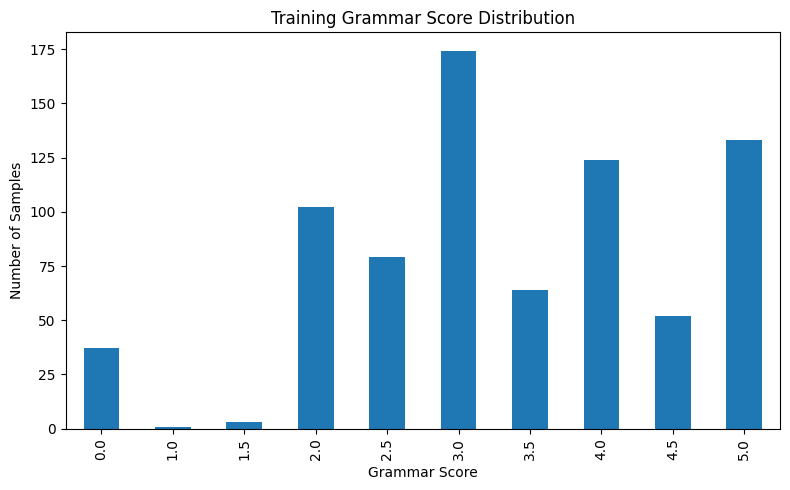

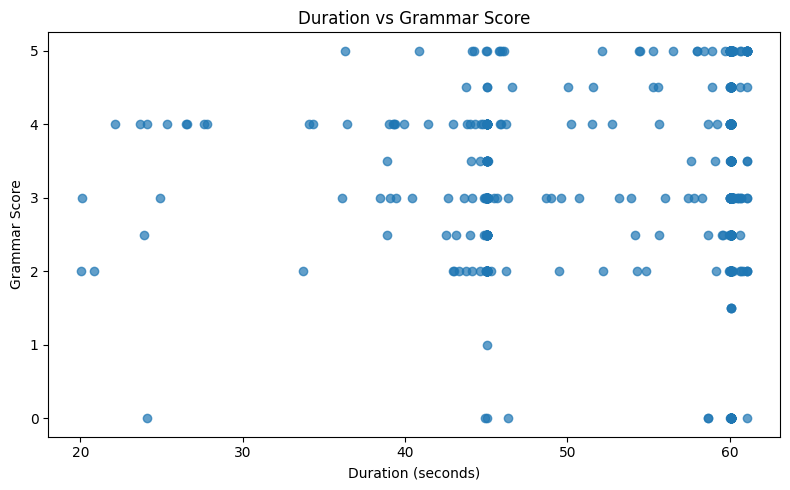

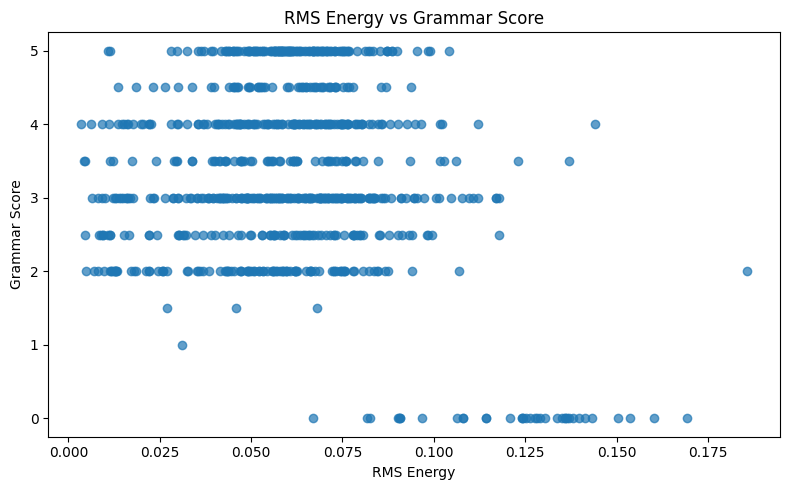

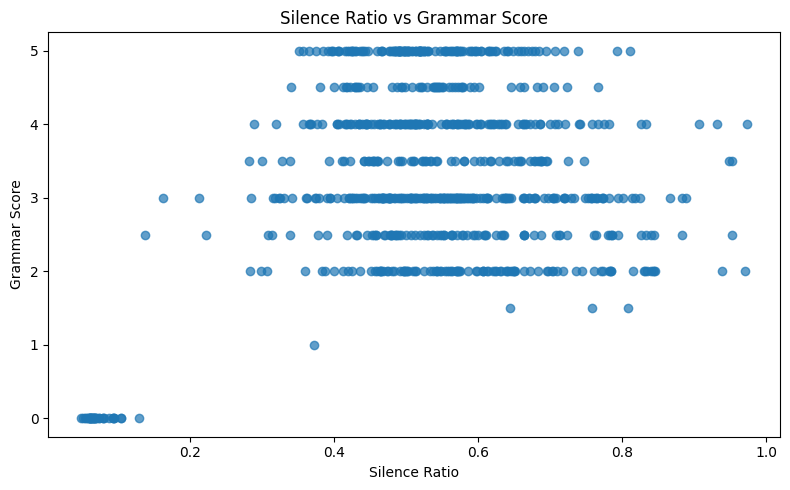

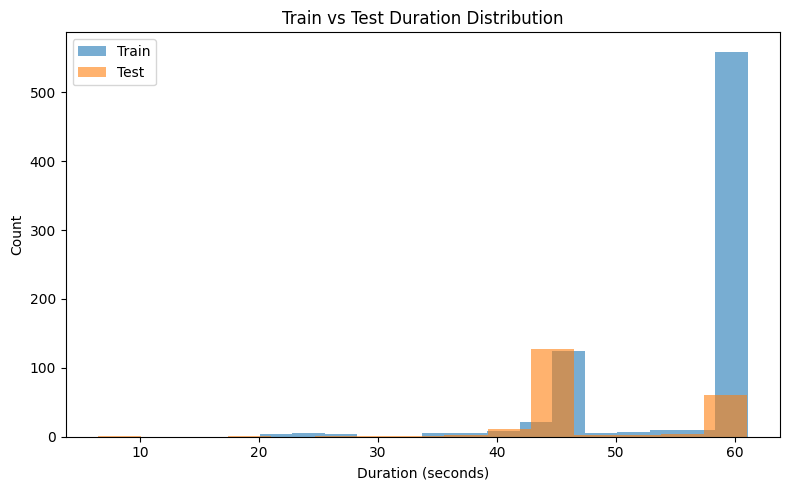

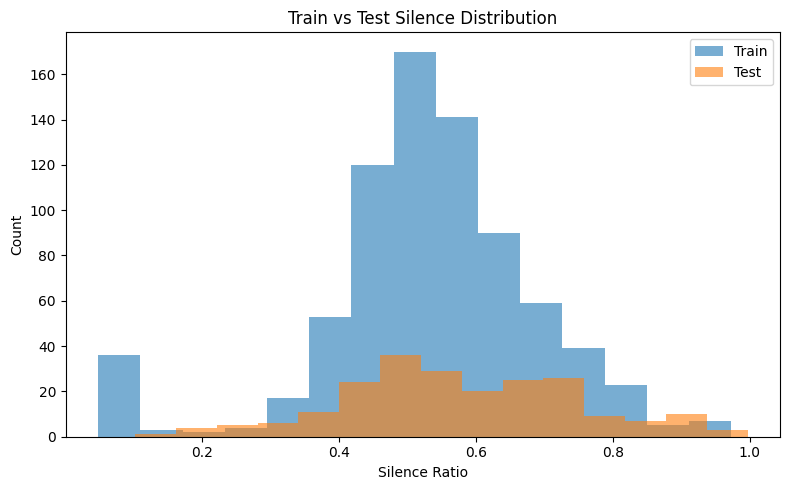

AUDIT VISUALIZATIONS COMPLETE
audit_duration_vs_score.png
audit_label_distribution.png
audit_rms_vs_score.png
audit_silence_vs_score.png
audit_train_test_duration.png
audit_train_test_silence.png


In [44]:
# ============================================================
# S0 — CELL 10
# Audit Visualizations
# ============================================================

import matplotlib.pyplot as plt
from pathlib import Path


reports_dir = Path(PATHS["reports_dir"])


# ------------------------------------------------------------
# 1. Label distribution
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

AUDIT_TRAIN["label"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Training Grammar Score Distribution")
plt.xlabel("Grammar Score")
plt.ylabel("Number of Samples")
plt.tight_layout()

plt.savefig(
    reports_dir / "audit_label_distribution.png",
    dpi=150,
)

plt.show()
plt.close()


# ------------------------------------------------------------
# 2. Duration vs score
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    AUDIT_TRAIN["duration"],
    AUDIT_TRAIN["label"],
    alpha=0.7,
)

plt.xlabel("Duration (seconds)")
plt.ylabel("Grammar Score")
plt.title("Duration vs Grammar Score")
plt.tight_layout()

plt.savefig(
    reports_dir / "audit_duration_vs_score.png",
    dpi=150,
)

plt.show()
plt.close()


# ------------------------------------------------------------
# 3. RMS vs score
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    AUDIT_TRAIN["rms"],
    AUDIT_TRAIN["label"],
    alpha=0.7,
)

plt.xlabel("RMS Energy")
plt.ylabel("Grammar Score")
plt.title("RMS Energy vs Grammar Score")
plt.tight_layout()

plt.savefig(
    reports_dir / "audit_rms_vs_score.png",
    dpi=150,
)

plt.show()
plt.close()


# ------------------------------------------------------------
# 4. Silence ratio vs score
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    AUDIT_TRAIN["silence_ratio"],
    AUDIT_TRAIN["label"],
    alpha=0.7,
)

plt.xlabel("Silence Ratio")
plt.ylabel("Grammar Score")
plt.title("Silence Ratio vs Grammar Score")
plt.tight_layout()

plt.savefig(
    reports_dir / "audit_silence_vs_score.png",
    dpi=150,
)

plt.show()
plt.close()


# ------------------------------------------------------------
# 5. Train / test duration distribution
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    AUDIT_TRAIN["duration"],
    bins=15,
    alpha=0.6,
    label="Train",
)

plt.hist(
    AUDIT_TEST["duration"],
    bins=15,
    alpha=0.6,
    label="Test",
)

plt.xlabel("Duration (seconds)")
plt.ylabel("Count")
plt.title("Train vs Test Duration Distribution")
plt.legend()
plt.tight_layout()

plt.savefig(
    reports_dir / "audit_train_test_duration.png",
    dpi=150,
)

plt.show()
plt.close()


# ------------------------------------------------------------
# 6. Train / test silence distribution
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    AUDIT_TRAIN["silence_ratio"],
    bins=15,
    alpha=0.6,
    label="Train",
)

plt.hist(
    AUDIT_TEST["silence_ratio"],
    bins=15,
    alpha=0.6,
    label="Test",
)

plt.xlabel("Silence Ratio")
plt.ylabel("Count")
plt.title("Train vs Test Silence Distribution")
plt.legend()
plt.tight_layout()

plt.savefig(
    reports_dir / "audit_train_test_silence.png",
    dpi=150,
)

plt.show()
plt.close()


print("=" * 72)
print("AUDIT VISUALIZATIONS COMPLETE")
print("=" * 72)

for path in sorted(
    reports_dir.glob("audit_*.png")
):
    print(path.name)

In [45]:
print("DEBUG:", CONFIG["DEBUG"])
print("EXPECTED TRAIN:", CONFIG["EXPECTED_TRAIN_FILES"])
print("EXPECTED TEST:", CONFIG["EXPECTED_TEST_FILES"])

print("TRAIN_S0:", len(TRAIN_S0))
print("TEST_S0:", len(TEST_S0))

print("TRAIN_DF:", len(TRAIN_DF))
print("TEST_DF:", len(TEST_DF))

print("\nTEST split:")
print(TEST_S0["split"].value_counts() if "split" in TEST_S0.columns else "no split column")

DEBUG: False
EXPECTED TRAIN: 769
EXPECTED TEST: 216
TRAIN_S0: 769
TEST_S0: 216
TRAIN_DF: 769
TEST_DF: 216

TEST split:
no split column


In [46]:
print("S0 FINAL INTEGRITY CHECK")

print("DEBUG:", CONFIG["DEBUG"])
print("Expected train:", CONFIG["EXPECTED_TRAIN_FILES"])
print("Expected test:", CONFIG["EXPECTED_TEST_FILES"])
print("Actual train:", len(TRAIN_S0))
print("Actual test:", len(TEST_S0))

assert CONFIG["DEBUG"] is False

assert len(TRAIN_S0) == 769, (
    f"Expected 769 train rows, got {len(TRAIN_S0)}"
)

assert len(TEST_S0) == 216, (
    f"Expected 216 test rows, got {len(TEST_S0)}"
)

assert len(TRAIN_S0) == CONFIG["EXPECTED_TRAIN_FILES"]
assert len(TEST_S0) == CONFIG["EXPECTED_TEST_FILES"]

print("✅ S0 FINAL INTEGRITY CHECK PASSED")

S0 FINAL INTEGRITY CHECK
DEBUG: False
Expected train: 769
Expected test: 216
Actual train: 769
Actual test: 216
✅ S0 FINAL INTEGRITY CHECK PASSED


In [47]:
# ============================================================
# STEP 4.1 — CELL 1
# Experiment Logging Infrastructure
# ============================================================

import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error


# ------------------------------------------------------------
# Experiment log path
# ------------------------------------------------------------

EXPERIMENT_LOG_PATH = Path(
    PATHS["experiment_log"]
)


# ------------------------------------------------------------
# Ensure experiment log exists
# ------------------------------------------------------------

if not EXPERIMENT_LOG_PATH.exists():

    experiment_columns = [
        "experiment_id",
        "stage",
        "model",
        "feature_source",
        "folds",
        "seed",
        "rmse",
        "pearson",
        "training_rmse",
        "status",
        "timestamp",
        "notes",
    ]

    pd.DataFrame(
        columns=experiment_columns
    ).to_csv(
        EXPERIMENT_LOG_PATH,
        index=False,
    )


# ------------------------------------------------------------
# Metric helpers
# ------------------------------------------------------------

def rmse_score(y_true, y_pred):
    return float(
        np.sqrt(
            mean_squared_error(
                np.asarray(y_true, dtype=float),
                np.asarray(y_pred, dtype=float),
            )
        )
    )


def pearson_score(y_true, y_pred):

    y_true = np.asarray(
        y_true,
        dtype=float,
    )

    y_pred = np.asarray(
        y_pred,
        dtype=float,
    )

    if (
        np.std(y_true) == 0
        or np.std(y_pred) == 0
    ):
        return np.nan

    return float(
        np.corrcoef(
            y_true,
            y_pred,
        )[0, 1]
    )


# ------------------------------------------------------------
# Experiment logger
# ------------------------------------------------------------

def log_experiment(
    experiment_id,
    stage,
    model,
    feature_source,
    folds,
    seed,
    rmse,
    pearson,
    training_rmse=np.nan,
    status="COMPLETED",
    notes="",
):
    """
    Append one experiment result to experiment_log.csv.
    """

    record = {
        "experiment_id": experiment_id,
        "stage": stage,
        "model": model,
        "feature_source": feature_source,
        "folds": folds,
        "seed": seed,
        "rmse": rmse,
        "pearson": pearson,
        "training_rmse": training_rmse,
        "status": status,
        "timestamp": time.strftime(
            "%Y-%m-%d %H:%M:%S"
        ),
        "notes": notes,
    }

    log_df = pd.DataFrame([record])

    log_df.to_csv(
        EXPERIMENT_LOG_PATH,
        mode="a",
        header=False,
        index=False,
    )

    return record


print("=" * 72)
print("EXPERIMENT LOGGING INFRASTRUCTURE READY")
print("=" * 72)

print(
    f"Experiment log:\n{EXPERIMENT_LOG_PATH}"
)

print(
    f"Exists: {EXPERIMENT_LOG_PATH.exists()}"
)

EXPERIMENT LOGGING INFRASTRUCTURE READY
Experiment log:
/kaggle/working/shl/full/shl-cache-v1/experiment_log.csv
Exists: True


In [48]:
# ============================================================
# STEP 4.2 — CELL 2
# Generic Leakage-Safe OOF Engine
# ============================================================

import gc
from pathlib import Path

import numpy as np


def run_oof_experiment(
    experiment_id,
    X_train,
    y_train,
    X_test,
    folds_df,
    model_factory,
    stage,
    model_name,
    feature_source,
    seed=42,
    model_params=None,
    clip_predictions=True,
):
    """
    Generic leakage-safe OOF training engine.

    Parameters
    ----------
    experiment_id:
        Unique experiment identifier.

    X_train:
        Full training feature matrix.

    y_train:
        Training targets.

    X_test:
        Test feature matrix.

    folds_df:
        DataFrame containing a `fold` column aligned with X_train.

    model_factory:
        Callable returning a fresh model instance.

    stage:
        Pipeline stage name.

    model_name:
        Human-readable model name.

    feature_source:
        Description of feature source.

    seed:
        Experiment seed.

    model_params:
        Optional model parameters.

    clip_predictions:
        Clip predictions to competition range [0, 5].
    """

    model_params = (
        {}
        if model_params is None
        else dict(model_params)
    )

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    X_train_len = len(X_train)
    y_train_len = len(y_train)
    folds_len = len(folds_df)

    if not (
        X_train_len
        == y_train_len
        == folds_len
    ):
        raise ValueError(
            "X_train, y_train and folds_df "
            "must contain the same number of rows."
        )

    if "fold" not in folds_df.columns:
        raise ValueError(
            "folds_df must contain a 'fold' column."
        )

    if X_test is None:
        raise ValueError(
            "X_test cannot be None."
        )

    y_train = np.asarray(
        y_train,
        dtype=float,
    )

    fold_ids = sorted(
        folds_df["fold"]
        .unique()
    )

    n_train = len(y_train)
    n_test = len(X_test)

    # --------------------------------------------------------
    # Allocate standardized artifacts
    # --------------------------------------------------------

    oof_predictions = np.full(
        n_train,
        np.nan,
        dtype=np.float32,
    )

    train_predictions = np.full(
        n_train,
        np.nan,
        dtype=np.float32,
    )

    test_predictions_per_fold = []

    fold_results = []

    # --------------------------------------------------------
    # Fold loop
    # --------------------------------------------------------

    print("=" * 72)
    print(f"OOF EXPERIMENT: {experiment_id}")
    print("=" * 72)

    for fold in fold_ids:

        print(
            f"\nFold {fold + 1}/{len(fold_ids)}"
        )

        train_mask = (
            folds_df["fold"].to_numpy()
            != fold
        )

        valid_mask = (
            folds_df["fold"].to_numpy()
            == fold
        )

        train_indices = np.flatnonzero(
            train_mask
        )

        valid_indices = np.flatnonzero(
            valid_mask
        )

        print(
            f"Train rows: {len(train_indices)}"
        )

        print(
            f"Valid rows: {len(valid_indices)}"
        )

        # ----------------------------------------------------
        # Fresh model for every fold
        # ----------------------------------------------------

        model = model_factory(
            seed=seed,
            **model_params,
        )

        # ----------------------------------------------------
        # Fit ONLY on training fold
        # ----------------------------------------------------

        model.fit(
            X_train[train_indices],
            y_train[train_indices],
        )

        # ----------------------------------------------------
        # Validation predictions
        # ----------------------------------------------------

        valid_pred = model.predict(
            X_train[valid_indices]
        )

        # ----------------------------------------------------
        # Training-fold predictions
        #
        # Required for mandatory training RMSE.
        # These are predictions from the model on its
        # own training rows.
        # ----------------------------------------------------

        fold_train_pred = model.predict(
            X_train[train_indices]
        )

        # ----------------------------------------------------
        # Test predictions
        # ----------------------------------------------------

        fold_test_pred = model.predict(
            X_test
        )

        if clip_predictions:

            valid_pred = np.clip(
                valid_pred,
                CONFIG["PREDICTION_MIN"],
                CONFIG["PREDICTION_MAX"],
            )

            fold_train_pred = np.clip(
                fold_train_pred,
                CONFIG["PREDICTION_MIN"],
                CONFIG["PREDICTION_MAX"],
            )

            fold_test_pred = np.clip(
                fold_test_pred,
                CONFIG["PREDICTION_MIN"],
                CONFIG["PREDICTION_MAX"],
            )

        # ----------------------------------------------------
        # Store predictions
        # ----------------------------------------------------

        oof_predictions[
            valid_indices
        ] = valid_pred

        train_predictions[
            train_indices
        ] = fold_train_pred

        test_predictions_per_fold.append(
            np.asarray(
                fold_test_pred,
                dtype=np.float32,
            )
        )

        # ----------------------------------------------------
        # Fold metrics
        # ----------------------------------------------------

        fold_rmse = rmse_score(
            y_train[valid_indices],
            valid_pred,
        )

        fold_pearson = pearson_score(
            y_train[valid_indices],
            valid_pred,
        )

        fold_train_rmse = rmse_score(
            y_train[train_indices],
            fold_train_pred,
        )

        fold_results.append(
            {
                "fold": int(fold),
                "rmse": fold_rmse,
                "pearson": fold_pearson,
                "training_rmse": fold_train_rmse,
                "n_train": len(train_indices),
                "n_valid": len(valid_indices),
            }
        )

        print(
            f"Validation RMSE: {fold_rmse:.6f}"
        )

        print(
            f"Validation Pearson: "
            f"{fold_pearson:.6f}"
        )

        print(
            f"Training RMSE: "
            f"{fold_train_rmse:.6f}"
        )

        del model
        gc.collect()

    # --------------------------------------------------------
    # Final integrity checks
    # --------------------------------------------------------

    if np.isnan(oof_predictions).any():
        raise RuntimeError(
            "OOF predictions contain NaN values."
        )

    if np.isnan(train_predictions).any():
        raise RuntimeError(
            "Training predictions contain NaN values."
        )

    # --------------------------------------------------------
    # Fold-average test prediction
    # --------------------------------------------------------

    test_predictions = np.mean(
        np.stack(
            test_predictions_per_fold,
            axis=0,
        ),
        axis=0,
    ).astype(np.float32)

    # --------------------------------------------------------
    # Overall metrics
    # --------------------------------------------------------

    overall_rmse = rmse_score(
        y_train,
        oof_predictions,
    )

    overall_pearson = pearson_score(
        y_train,
        oof_predictions,
    )

    overall_training_rmse = rmse_score(
        y_train,
        train_predictions,
    )

    # --------------------------------------------------------
    # Save standardized artifacts
    # --------------------------------------------------------

    oof_path = (
        Path(PATHS["oof_dir"])
        / f"{experiment_id}.npy"
    )

    test_path = (
        Path(PATHS["test_predictions_dir"])
        / f"{experiment_id}.npy"
    )

    train_path = (
        Path(PATHS["train_pred_dir"])
        / f"{experiment_id}.npy"
    )

    np.save(
        oof_path,
        oof_predictions,
    )

    np.save(
        test_path,
        test_predictions,
    )

    np.save(
        train_path,
        train_predictions,
    )

    # --------------------------------------------------------
    # Fold metrics artifact
    # --------------------------------------------------------

    fold_results_df = pd.DataFrame(
        fold_results
    )

    fold_results_path = (
        Path(PATHS["reports_dir"])
        / f"{experiment_id}_fold_metrics.csv"
    )

    fold_results_df.to_csv(
        fold_results_path,
        index=False,
    )

    # --------------------------------------------------------
    # Log experiment
    # --------------------------------------------------------

    log_experiment(
        experiment_id=experiment_id,
        stage=stage,
        model=model_name,
        feature_source=feature_source,
        folds=len(fold_ids),
        seed=seed,
        rmse=overall_rmse,
        pearson=overall_pearson,
        training_rmse=overall_training_rmse,
        status="COMPLETED",
        notes=(
            f"fold_rmse="
            f"{fold_results_df['rmse'].round(6).tolist()}"
        ),
    )

    # --------------------------------------------------------
    # Final output
    # --------------------------------------------------------

    result = {
        "experiment_id": experiment_id,
        "oof": oof_predictions,
        "test_predictions": test_predictions,
        "train_predictions": train_predictions,
        "fold_metrics": fold_results_df,
        "rmse": overall_rmse,
        "pearson": overall_pearson,
        "training_rmse": overall_training_rmse,
        "oof_path": str(oof_path),
        "test_path": str(test_path),
        "train_path": str(train_path),
    }

    print("\n" + "=" * 72)
    print("OOF EXPERIMENT COMPLETE")
    print("=" * 72)

    print(
        f"OOF RMSE:        {overall_rmse:.6f}"
    )

    print(
        f"OOF Pearson:     {overall_pearson:.6f}"
    )

    print(
        f"Training RMSE:   {overall_training_rmse:.6f}"
    )

    print(
        f"\nOOF:   {oof_path}"
    )

    print(
        f"Test:  {test_path}"
    )

    print(
        f"Train: {train_path}"
    )

    return result

In [49]:
# ============================================================
# STEP 4.2 — CELL 3
# OOF Engine Infrastructure Test
# ============================================================

from sklearn.linear_model import Ridge


# ------------------------------------------------------------
# Synthetic infrastructure-test features
# ------------------------------------------------------------

rng = np.random.default_rng(
    CONFIG["GLOBAL_SEED"]
)

X_oof_test = rng.normal(
    size=(len(TRAIN_S0), 4)
).astype(np.float32)

X_test_oof_test = rng.normal(
    size=(len(TEST_S0), 4)
).astype(np.float32)

y_oof_test = (
    TRAIN_S0["label"]
    .to_numpy(dtype=float)
)


# ------------------------------------------------------------
# Model factory
# ------------------------------------------------------------

def ridge_test_factory(
    seed=42,
    **kwargs,
):
    return Ridge(
        alpha=1.0
    )


# ------------------------------------------------------------
# Run infrastructure test
# ------------------------------------------------------------

OOF_TEST_RESULT = run_oof_experiment(
    experiment_id="INFRA_OOF_TEST",
    X_train=X_oof_test,
    y_train=y_oof_test,
    X_test=X_test_oof_test,
    folds_df=FOLD_DF,
    model_factory=ridge_test_factory,
    stage="STEP4_INFRASTRUCTURE",
    model_name="Ridge",
    feature_source="synthetic_test_features",
    seed=42,
)


# ------------------------------------------------------------
# Validate artifacts
# ------------------------------------------------------------

assert OOF_TEST_RESULT["oof"].shape == (
    len(TRAIN_S0),
)

assert OOF_TEST_RESULT[
    "test_predictions"
].shape == (
    len(TEST_S0),
)

assert OOF_TEST_RESULT[
    "train_predictions"
].shape == (
    len(TRAIN_S0),
)

assert np.isfinite(
    OOF_TEST_RESULT["oof"]
).all()

assert np.isfinite(
    OOF_TEST_RESULT["test_predictions"]
).all()

assert np.isfinite(
    OOF_TEST_RESULT["train_predictions"]
).all()


assert Path(
    OOF_TEST_RESULT["oof_path"]
).exists()

assert Path(
    OOF_TEST_RESULT["test_path"]
).exists()

assert Path(
    OOF_TEST_RESULT["train_path"]
).exists()


print("\n" + "=" * 72)
print("OOF INFRASTRUCTURE TEST: PASSED")
print("=" * 72)

OOF EXPERIMENT: INFRA_OOF_TEST

Fold 1/5
Train rows: 615
Valid rows: 154
Validation RMSE: 1.184489
Validation Pearson: -0.008956
Training RMSE: 1.246339

Fold 2/5
Train rows: 615
Valid rows: 154
Validation RMSE: 1.249971
Validation Pearson: 0.071769
Training RMSE: 1.229398

Fold 3/5
Train rows: 615
Valid rows: 154
Validation RMSE: 1.201922
Validation Pearson: 0.138145
Training RMSE: 1.241286

Fold 4/5
Train rows: 615
Valid rows: 154
Validation RMSE: 1.297137
Validation Pearson: 0.068880
Training RMSE: 1.217362

Fold 5/5
Train rows: 616
Valid rows: 153
Validation RMSE: 1.246864
Validation Pearson: 0.044874
Training RMSE: 1.230476

OOF EXPERIMENT COMPLETE
OOF RMSE:        1.236700
OOF Pearson:     0.058921
Training RMSE:   1.233546

OOF:   /kaggle/working/shl/full/shl-cache-v1/oof/INFRA_OOF_TEST.npy
Test:  /kaggle/working/shl/full/shl-cache-v1/test_predictions/INFRA_OOF_TEST.npy
Train: /kaggle/working/shl/full/shl-cache-v1/train_pred/INFRA_OOF_TEST.npy

OOF INFRASTRUCTURE TEST: PASSED


In [50]:
# ============================================================
# STEP 4.3 — CELL 4
# Standard Model Artifact Validation
# ============================================================

def validate_model_artifacts(
    experiment_id,
    n_train,
    n_test,
    prediction_min=None,
    prediction_max=None,
):
    """
    Validate the standard model artifact contract.

    Required:
        oof/<expid>.npy
        test_predictions/<expid>.npy
        train_pred/<expid>.npy
    """

    prediction_min = (
        CONFIG["PREDICTION_MIN"]
        if prediction_min is None
        else prediction_min
    )

    prediction_max = (
        CONFIG["PREDICTION_MAX"]
        if prediction_max is None
        else prediction_max
    )

    oof_path = (
        Path(PATHS["oof_dir"])
        / f"{experiment_id}.npy"
    )

    test_path = (
        Path(PATHS["test_predictions_dir"])
        / f"{experiment_id}.npy"
    )

    train_path = (
        Path(PATHS["train_pred_dir"])
        / f"{experiment_id}.npy"
    )

    # --------------------------------------------------------
    # Existence
    # --------------------------------------------------------

    required_paths = {
        "OOF": oof_path,
        "TEST": test_path,
        "TRAIN": train_path,
    }

    for name, path in required_paths.items():

        if not path.exists():
            raise FileNotFoundError(
                f"{name} artifact missing: {path}"
            )

    # --------------------------------------------------------
    # Load
    # --------------------------------------------------------

    oof = np.load(oof_path)
    test_pred = np.load(test_path)
    train_pred = np.load(train_path)

    # --------------------------------------------------------
    # Shape checks
    # --------------------------------------------------------

    assert oof.shape == (n_train,), (
        f"OOF shape mismatch: "
        f"{oof.shape} != {(n_train,)}"
    )

    assert train_pred.shape == (n_train,), (
        f"Train prediction shape mismatch: "
        f"{train_pred.shape} != {(n_train,)}"
    )

    assert test_pred.shape == (n_test,), (
        f"Test prediction shape mismatch: "
        f"{test_pred.shape} != {(n_test,)}"
    )

    # --------------------------------------------------------
    # Numerical integrity
    # --------------------------------------------------------

    assert np.isfinite(oof).all(), (
        "OOF contains NaN/Inf."
    )

    assert np.isfinite(test_pred).all(), (
        "Test predictions contain NaN/Inf."
    )

    assert np.isfinite(train_pred).all(), (
        "Training predictions contain NaN/Inf."
    )

    # --------------------------------------------------------
    # Prediction bounds
    # --------------------------------------------------------

    for name, values in [
        ("OOF", oof),
        ("TEST", test_pred),
        ("TRAIN", train_pred),
    ]:

        if (
            values.min() < prediction_min
            or values.max() > prediction_max
        ):
            raise ValueError(
                f"{name} predictions outside "
                f"[{prediction_min}, {prediction_max}]: "
                f"min={values.min()}, "
                f"max={values.max()}"
            )

    return {
        "experiment_id": experiment_id,
        "oof_path": str(oof_path),
        "test_path": str(test_path),
        "train_path": str(train_path),
        "oof_shape": oof.shape,
        "test_shape": test_pred.shape,
        "train_shape": train_pred.shape,
        "valid": True,
    }


print("=" * 72)
print("MODEL ARTIFACT VALIDATOR READY")
print("=" * 72)

MODEL ARTIFACT VALIDATOR READY


In [51]:
# ============================================================
# STEP 4.3 — CELL 5
# Artifact Contract Test
# ============================================================

artifact_check = validate_model_artifacts(
    experiment_id="INFRA_OOF_TEST",
    n_train=len(TRAIN_S0),
    n_test=len(TEST_S0),
)

print("\nArtifact validation result:")
print(json.dumps(
    artifact_check,
    indent=2,
))

print("\n" + "=" * 72)
print("ARTIFACT CONTRACT TEST: PASSED")
print("=" * 72)


Artifact validation result:
{
  "experiment_id": "INFRA_OOF_TEST",
  "oof_path": "/kaggle/working/shl/full/shl-cache-v1/oof/INFRA_OOF_TEST.npy",
  "test_path": "/kaggle/working/shl/full/shl-cache-v1/test_predictions/INFRA_OOF_TEST.npy",
  "train_path": "/kaggle/working/shl/full/shl-cache-v1/train_pred/INFRA_OOF_TEST.npy",
  "oof_shape": [
    769
  ],
  "test_shape": [
    216
  ],
  "train_shape": [
    769
  ],
  "valid": true
}

ARTIFACT CONTRACT TEST: PASSED


In [52]:
# ============================================================
# S1 — WHISPER ASR
# CELL 1: Configuration + Dependency Check
# ============================================================

import sys
import subprocess
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# S1 configuration
# ------------------------------------------------------------

ASR_CONFIG = {
    "model_size": CONFIG["ASR_MODEL"],
    "language": CONFIG["ASR_LANGUAGE"],
    "beam_size": CONFIG["ASR_BEAM_SIZE"],
    "temperature": CONFIG["ASR_TEMPERATURE"],
    "word_timestamps": CONFIG["ASR_WORD_TIMESTAMPS"],
    "vad_filter": CONFIG["ASR_VAD_FILTER"],
    "compute_type": CONFIG["ASR_COMPUTE_TYPE"],
}

print("=" * 72)
print("S1 — WHISPER ASR")
print("=" * 72)

print("\nLocked Variant A configuration:")

for key, value in ASR_CONFIG.items():
    print(f"  {key}: {value}")


# ------------------------------------------------------------
# Check faster-whisper
# ------------------------------------------------------------

if importlib.util.find_spec("faster_whisper") is None:

    print("\nfaster-whisper not found.")
    print("Installing faster-whisper...")

    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "faster-whisper",
    ])

else:

    print("\nfaster-whisper is already installed.")


from faster_whisper import WhisperModel


print("\nWhisperModel import: PASSED")

S1 — WHISPER ASR

Locked Variant A configuration:
  model_size: large-v3
  language: en
  beam_size: 5
  temperature: 0.0
  word_timestamps: True
  vad_filter: False
  compute_type: float16

faster-whisper is already installed.

WhisperModel import: PASSED


In [53]:
# ============================================================
# S1 — CELL 2
# Build ASR Manifest
# ============================================================

def build_asr_manifest(
    train_df,
    test_df,
):
    """
    Build the exact audio manifest used by S1.

    Keeps train/test split information explicit so that
    identical filenames across splits cannot be confused.
    """

    train_manifest = train_df[
        ["filename", "label"]
    ].copy()

    train_manifest["split"] = "train"

    train_manifest["audio_path"] = (
        train_manifest["filename"]
        .apply(
            lambda x: str(
                Path(PATHS["train_audio"]) / x
            )
        )
    )

    test_manifest = test_df[
        ["filename", "label"]
    ].copy()

    test_manifest["split"] = "test"

    test_manifest["audio_path"] = (
        test_manifest["filename"]
        .apply(
            lambda x: str(
                Path(PATHS["test_audio"]) / x
            )
        )
    )

    manifest = pd.concat(
        [
            train_manifest,
            test_manifest,
        ],
        ignore_index=True,
    )

    # --------------------------------------------------------
    # Integrity
    # --------------------------------------------------------

    if manifest["audio_path"].duplicated().any():
        raise RuntimeError(
            "Duplicate audio paths detected in ASR manifest."
        )

    missing = [
        p
        for p in manifest["audio_path"]
        if not Path(p).exists()
    ]

    if missing:
        raise FileNotFoundError(
            f"{len(missing)} audio files are missing."
        )

    return manifest


ASR_MANIFEST = build_asr_manifest(
    TRAIN_S0,
    TEST_S0,
)

print("=" * 72)
print("ASR MANIFEST READY")
print("=" * 72)

print(
    f"Train files: "
    f"{(ASR_MANIFEST['split'] == 'train').sum()}"
)

print(
    f"Test files: "
    f"{(ASR_MANIFEST['split'] == 'test').sum()}"
)

print(
    f"Total files: {len(ASR_MANIFEST)}"
)

print(
    "\nAll referenced audio files exist."
)

ASR MANIFEST READY
Train files: 769
Test files: 216
Total files: 985

All referenced audio files exist.


In [54]:
# ============================================================
# S1 — CELL 3
# Load Whisper Large-v3
# ============================================================

print("=" * 72)
print("LOADING WHISPER LARGE-V3")
print("=" * 72)

WHISPER_MODEL = WhisperModel(
    ASR_CONFIG["model_size"],
    device="cuda",
    device_index=0,
    compute_type=ASR_CONFIG["compute_type"],
)

print("\nWhisper model loaded successfully.")

print(
    f"Model: {ASR_CONFIG['model_size']}"
)

print(
    f"Device: CUDA GPU 0"
)

print(
    f"Compute type: {ASR_CONFIG['compute_type']}"
)

LOADING WHISPER LARGE-V3



Whisper model loaded successfully.
Model: large-v3
Device: CUDA GPU 0
Compute type: float16


In [55]:
# ============================================================
# S1 — CELL 4
# Variant A — Resumable Whisper Transcription
# Robust word-timestamp fallback
# ============================================================

import json
import time


ASR_A_PATH = (
    Path(PATHS["transcripts_dir"])
    / "A.parquet"
)


ASR_A_COLUMNS = [
    "filename",
    "split",
    "label",
    "audio_path",
    "language",
    "duration",
    "text",
    "segments",
    "words",
    "word_count",
    "avg_word_probability",
    "avg_logprob",
    "no_speech_prob",
    "transcription_time_sec",
]


# ------------------------------------------------------------
# Load existing cache
# ------------------------------------------------------------

if ASR_A_PATH.exists():

    ASR_A_DF = pd.read_parquet(
        ASR_A_PATH
    )

    print(
        f"Existing ASR cache found: "
        f"{len(ASR_A_DF)} rows"
    )

else:

    ASR_A_DF = pd.DataFrame(
        columns=ASR_A_COLUMNS
    )

    print("No existing ASR cache found.")


completed_paths = set(
    ASR_A_DF["audio_path"].astype(str)
)


# ------------------------------------------------------------
# Verify resume point
# ------------------------------------------------------------

remaining_rows = ASR_MANIFEST[
    ~ASR_MANIFEST["audio_path"].astype(str).isin(
        completed_paths
    )
].copy()

print("\n" + "=" * 72)
print("ASR RESUME CHECK")
print("=" * 72)

print(
    f"Cached files:    {len(completed_paths)}"
)

print(
    f"Remaining files: {len(remaining_rows)}"
)

if len(remaining_rows) > 0:

    first_remaining = remaining_rows.iloc[0]

    first_position = (
        ASR_MANIFEST.index[
            ASR_MANIFEST["audio_path"].astype(str)
            == str(first_remaining["audio_path"])
        ][0]
        + 1
    )

    print(
        f"Resume position: {first_position}/{len(ASR_MANIFEST)}"
    )

    print(
        f"Resume file:     {first_remaining['filename']}"
    )

else:

    print("Nothing remaining — ASR cache is complete.")


# ------------------------------------------------------------
# Transcription helper
# ------------------------------------------------------------

def transcribe_variant_a(
    audio_path,
):
    """
    Locked Variant A:

    Whisper large-v3
    language=en
    beam_size=5
    temperature=0
    word_timestamps=True
    vad_filter=False
    fp16

    Robustness:
    If faster-whisper crashes during word-level alignment,
    retry the same audio with word_timestamps=False.
    """

    start_time = time.time()

    use_word_timestamps = True

    try:

        segments_generator, info = (
            WHISPER_MODEL.transcribe(
                audio_path,
                language=ASR_CONFIG["language"],
                beam_size=ASR_CONFIG["beam_size"],
                temperature=ASR_CONFIG["temperature"],
                word_timestamps=True,
                vad_filter=ASR_CONFIG[
                    "vad_filter"
                ],
            )
        )

        segments = list(
            segments_generator
        )

    except IndexError as e:

        print(
            f"\n⚠️ Word-timestamp alignment failed:"
            f" {Path(audio_path).name}"
        )

        print(
            "   Retrying without word timestamps..."
        )

        use_word_timestamps = False

        segments_generator, info = (
            WHISPER_MODEL.transcribe(
                audio_path,
                language=ASR_CONFIG["language"],
                beam_size=ASR_CONFIG["beam_size"],
                temperature=ASR_CONFIG["temperature"],
                word_timestamps=False,
                vad_filter=ASR_CONFIG[
                    "vad_filter"
                ],
            )
        )

        segments = list(
            segments_generator
        )

        print(
            "   ✅ Fallback transcription succeeded."
        )

    segments_records = []
    words = []

    segment_logprobs = []
    segment_no_speech = []

    full_text_parts = []

    for segment in segments:

        segment_text = (
            segment.text or ""
        ).strip()

        full_text_parts.append(
            segment_text
        )

        segment_words = []

        # ----------------------------------------------------
        # Word-level information is available only when
        # word timestamps succeeded.
        # ----------------------------------------------------

        if (
            use_word_timestamps
            and segment.words is not None
        ):

            for word in segment.words:

                word_record = {
                    "word": word.word,
                    "start": (
                        float(word.start)
                        if word.start is not None
                        else None
                    ),
                    "end": (
                        float(word.end)
                        if word.end is not None
                        else None
                    ),
                    "probability": (
                        float(word.probability)
                        if word.probability is not None
                        else None
                    ),
                }

                words.append(
                    word_record
                )

                segment_words.append(
                    word_record
                )

        segment_record = {
            "id": int(segment.id),
            "start": float(segment.start),
            "end": float(segment.end),
            "text": segment_text,
            "avg_logprob": (
                float(segment.avg_logprob)
                if segment.avg_logprob is not None
                else None
            ),
            "no_speech_prob": (
                float(segment.no_speech_prob)
                if segment.no_speech_prob is not None
                else None
            ),
            "words": segment_words,
        }

        segments_records.append(
            segment_record
        )

        if segment.avg_logprob is not None:

            segment_logprobs.append(
                float(segment.avg_logprob)
            )

        if segment.no_speech_prob is not None:

            segment_no_speech.append(
                float(segment.no_speech_prob)
            )

    # --------------------------------------------------------
    # Build transcript
    # --------------------------------------------------------

    text = " ".join(
        x
        for x in full_text_parts
        if x
    ).strip()

    # --------------------------------------------------------
    # Word probabilities
    # --------------------------------------------------------

    word_probabilities = [
        w["probability"]
        for w in words
        if w["probability"] is not None
    ]

    avg_word_probability = (
        float(
            np.mean(
                word_probabilities
            )
        )
        if word_probabilities
        else np.nan
    )

    # --------------------------------------------------------
    # Segment log probability
    # --------------------------------------------------------

    avg_logprob = (
        float(
            np.mean(
                segment_logprobs
            )
        )
        if segment_logprobs
        else np.nan
    )

    # --------------------------------------------------------
    # No-speech probability
    # --------------------------------------------------------

    no_speech_prob = (
        float(
            np.mean(
                segment_no_speech
            )
        )
        if segment_no_speech
        else np.nan
    )

    # --------------------------------------------------------
    # Duration
    # --------------------------------------------------------

    duration = (
        float(info.duration)
        if info.duration is not None
        else np.nan
    )

    elapsed = (
        time.time()
        - start_time
    )

    return {
        "language": (
            info.language
            if info.language is not None
            else "en"
        ),

        "duration": duration,

        "text": text,

        "segments": json.dumps(
            segments_records,
            ensure_ascii=False,
        ),

        "words": json.dumps(
            words,
            ensure_ascii=False,
        ),

        "word_count": len(words),

        "avg_word_probability": (
            avg_word_probability
        ),

        "avg_logprob": avg_logprob,

        "no_speech_prob": (
            no_speech_prob
        ),

        "transcription_time_sec": (
            elapsed
        ),
    }


# ------------------------------------------------------------
# Run resumable transcription
# ------------------------------------------------------------

new_rows = []

for idx, row in ASR_MANIFEST.iterrows():

    audio_path = str(
        row["audio_path"]
    )

    # --------------------------------------------------------
    # Skip already completed files
    # --------------------------------------------------------

    if audio_path in completed_paths:

        print(
            f"[{idx + 1}/{len(ASR_MANIFEST)}] "
            f"SKIP — already cached: "
            f"{row['filename']}"
        )

        continue

    # --------------------------------------------------------
    # Transcribe remaining file
    # --------------------------------------------------------

    print(
        f"[{idx + 1}/{len(ASR_MANIFEST)}] "
        f"Transcribing: "
        f"{row['filename']}"
    )

    result = transcribe_variant_a(
        audio_path
    )

    record = {
        "filename": row["filename"],
        "split": row["split"],
        "label": row["label"],
        "audio_path": audio_path,
        **result,
    }

    new_rows.append(
        record
    )

    # --------------------------------------------------------
    # Incremental persistence
    # --------------------------------------------------------

    ASR_A_DF = pd.concat(
        [
            ASR_A_DF,
            pd.DataFrame(
                [record]
            ),
        ],
        ignore_index=True,
    )

    ASR_A_DF.to_parquet(
        ASR_A_PATH,
        index=False,
    )

    completed_paths.add(
        audio_path
    )

    print(
        f"    words={result['word_count']} | "
        f"duration={result['duration']:.2f}s | "
        f"time={result['transcription_time_sec']:.2f}s"
    )


# ------------------------------------------------------------
# Final validation
# ------------------------------------------------------------

print("\n" + "=" * 72)
print("VARIANT A TRANSCRIPTION COMPLETE")
print("=" * 72)

print(
    f"Cached rows: {len(ASR_A_DF)}"
)

print(
    f"Cache path: {ASR_A_PATH}"
)

assert len(ASR_A_DF) == len(
    ASR_MANIFEST
), (
    f"ASR cache incomplete: "
    f"{len(ASR_A_DF)} / "
    f"{len(ASR_MANIFEST)}"
)

print(
    "✅ All 985 files are cached."
)

No existing ASR cache found.

ASR RESUME CHECK
Cached files:    0
Remaining files: 985
Resume position: 1/985
Resume file:     audio_192.wav
[1/985] Transcribing: audio_192.wav
    words=99 | duration=60.51s | time=7.41s
[2/985] Transcribing: audio_436.wav
    words=157 | duration=60.07s | time=4.26s
[3/985] Transcribing: audio_447.wav
    words=148 | duration=60.07s | time=4.47s
[4/985] Transcribing: audio_126.wav
    words=105 | duration=45.06s | time=2.81s
[5/985] Transcribing: audio_61.wav
    words=77 | duration=45.30s | time=2.74s
[6/985] Transcribing: audio_639.wav
    words=114 | duration=60.07s | time=6.33s
[7/985] Transcribing: audio_703.wav
    words=79 | duration=52.16s | time=2.94s
[8/985] Transcribing: audio_509.wav
    words=244 | duration=60.07s | time=16.49s
[9/985] Transcribing: audio_672.wav
    words=114 | duration=60.07s | time=3.66s
[10/985] Transcribing: audio_344.wav
    words=111 | duration=60.07s | time=3.76s
[11/985] Transcribing: audio_592.wav
    words=112 

In [60]:
# ============================================================
# S1 — COMPATIBILITY DIAGNOSTIC
# ============================================================

import faster_whisper
import av

print("=" * 72)
print("FASTER-WHISPER / PYAV COMPATIBILITY CHECK")
print("=" * 72)

print("faster-whisper version:")
print(getattr(faster_whisper, "__version__", "unknown"))

print("\nPyAV version:")
print(av.__version__)

print("\nPyAV location:")
print(av.__file__)

print("\nWhisper model:")
print(ASR_CONFIG["model_size"])

print("=" * 72)

FASTER-WHISPER / PYAV COMPATIBILITY CHECK
faster-whisper version:
1.2.1

PyAV version:
18.1.0

PyAV location:
/usr/local/lib/python3.13/dist-packages/av/__init__.py

Whisper model:
large-v3


In [61]:
# ============================================================
# S1 — CELL 5
# Variant A Integrity Gate
# ============================================================

required_columns = set(ASR_A_COLUMNS)

missing_columns = (
    required_columns
    - set(ASR_A_DF.columns)
)

if missing_columns:
    raise RuntimeError(
        f"Missing ASR columns: {sorted(missing_columns)}"
    )


# ------------------------------------------------------------
# Row count
# ------------------------------------------------------------

expected_rows = len(ASR_MANIFEST)

if len(ASR_A_DF) != expected_rows:
    raise RuntimeError(
        f"ASR row count mismatch: "
        f"{len(ASR_A_DF)} != {expected_rows}"
    )


# ------------------------------------------------------------
# Duplicate check
# ------------------------------------------------------------

if ASR_A_DF["audio_path"].duplicated().any():
    raise RuntimeError(
        "Duplicate audio_path values found in ASR cache."
    )


# ------------------------------------------------------------
# Transcript check
# ------------------------------------------------------------

if ASR_A_DF["text"].isna().any():
    raise RuntimeError(
        "ASR contains null transcript text."
    )


# ------------------------------------------------------------
# Normalize fallback ASR values
#
# Some files may have required a retry with
# word_timestamps=False. Such files legitimately have
# no word-level probability values.
# ------------------------------------------------------------

ASR_A_DF["avg_word_probability"] = (
    ASR_A_DF["avg_word_probability"]
    .fillna(0.0)
)

ASR_A_DF["avg_logprob"] = (
    ASR_A_DF["avg_logprob"]
    .fillna(0.0)
)

ASR_A_DF["no_speech_prob"] = (
    ASR_A_DF["no_speech_prob"]
    .fillna(0.0)
)


# ------------------------------------------------------------
# Numeric integrity
# ------------------------------------------------------------

numeric_columns = [
    "duration",
    "word_count",
    "avg_word_probability",
    "avg_logprob",
    "no_speech_prob",
    "transcription_time_sec",
]

for column in numeric_columns:

    values = ASR_A_DF[column].to_numpy(
        dtype=float
    )

    if not np.isfinite(values).all():

        raise RuntimeError(
            f"Non-finite values found in ASR column: {column}"
        )


# ------------------------------------------------------------
# Sort consistently
# ------------------------------------------------------------

ASR_A_DF = (
    ASR_A_DF
    .sort_values(
        ["split", "filename"]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Persist cleaned cache
# ------------------------------------------------------------

ASR_A_DF.to_parquet(
    ASR_A_PATH,
    index=False,
)


# ------------------------------------------------------------
# Final report
# ------------------------------------------------------------

print("=" * 72)
print("S1 VARIANT A INTEGRITY CHECK: PASSED")
print("=" * 72)

print(
    f"Rows: {len(ASR_A_DF)}"
)

print(
    f"Train: "
    f"{(ASR_A_DF['split'] == 'train').sum()}"
)

print(
    f"Test: "
    f"{(ASR_A_DF['split'] == 'test').sum()}"
)

print(
    f"Cache: {ASR_A_PATH}"
)

S1 VARIANT A INTEGRITY CHECK: PASSED
Rows: 985
Train: 769
Test: 216
Cache: /kaggle/working/shl/full/shl-cache-v1/transcripts/A.parquet


In [62]:
# ============================================================
# S1 — CELL 6
# Variant B — 40 File Pilot Selection
# ============================================================

ASR_PILOT_N = 40

ASR_PILOT = (
    ASR_MANIFEST
    .iloc[:ASR_PILOT_N]
    .copy()
    .reset_index(drop=True)
)

assert len(ASR_PILOT) == ASR_PILOT_N

print("=" * 72)
print("VARIANT B PILOT")
print("=" * 72)

print(f"Pilot files: {len(ASR_PILOT)}")
print(f"Train: {(ASR_PILOT['split'] == 'train').sum()}")
print(f"Test: {(ASR_PILOT['split'] == 'test').sum()}")

VARIANT B PILOT
Pilot files: 40
Train: 40
Test: 0


In [63]:
# ============================================================
# S1 — CELL 7
# Variant B — Initial Prompt Using Messy Speech
# ============================================================

ASR_B_PILOT_PATH = (
    Path(PATHS["transcripts_dir"])
    / "pilot_B.parquet"
)

if ASR_B_PILOT_PATH.exists():

    ASR_B_PILOT_DF = pd.read_parquet(
        ASR_B_PILOT_PATH
    )

    print(
        f"Existing Variant B pilot cache: "
        f"{len(ASR_B_PILOT_DF)} rows"
    )

else:

    ASR_B_PILOT_DF = pd.DataFrame(
        columns=ASR_A_COLUMNS
    )

    print("No Variant B pilot cache found.")


completed_b = set(
    ASR_B_PILOT_DF["audio_path"].astype(str)
)


def transcribe_variant_b(audio_path, messy_prompt):
    """
    Variant B:
    Same locked Whisper configuration as A,
    but with an initial prompt containing
    verbatim messy speech from the recording.
    """

    start_time = time.time()

    segments_generator, info = (
        WHISPER_MODEL.transcribe(
            audio_path,
            language=ASR_CONFIG["language"],
            beam_size=ASR_CONFIG["beam_size"],
            temperature=ASR_CONFIG["temperature"],
            word_timestamps=ASR_CONFIG["word_timestamps"],
            vad_filter=ASR_CONFIG["vad_filter"],
            initial_prompt=messy_prompt,
        )
    )

    segments = []
    words = []
    logprobs = []
    no_speech_probs = []
    text_parts = []

    for segment in segments_generator:

        segment_text = (
            segment.text or ""
        ).strip()

        text_parts.append(segment_text)

        segment_words = []

        if segment.words is not None:

            for word in segment.words:

                w = {
                    "word": word.word,
                    "start": (
                        float(word.start)
                        if word.start is not None
                        else None
                    ),
                    "end": (
                        float(word.end)
                        if word.end is not None
                        else None
                    ),
                    "probability": (
                        float(word.probability)
                        if word.probability is not None
                        else None
                    ),
                }

                words.append(w)
                segment_words.append(w)

        segments.append({
            "id": int(segment.id),
            "start": float(segment.start),
            "end": float(segment.end),
            "text": segment_text,
            "avg_logprob": (
                float(segment.avg_logprob)
                if segment.avg_logprob is not None
                else None
            ),
            "no_speech_prob": (
                float(segment.no_speech_prob)
                if segment.no_speech_prob is not None
                else None
            ),
            "words": segment_words,
        })

        if segment.avg_logprob is not None:
            logprobs.append(
                float(segment.avg_logprob)
            )

        if segment.no_speech_prob is not None:
            no_speech_probs.append(
                float(segment.no_speech_prob)
            )

    text = " ".join(
        x for x in text_parts if x
    ).strip()

    word_probs = [
        w["probability"]
        for w in words
        if w["probability"] is not None
    ]

    return {
        "language": (
            info.language
            if info.language is not None
            else "en"
        ),
        "duration": (
            float(info.duration)
            if info.duration is not None
            else np.nan
        ),
        "text": text,
        "segments": json.dumps(
            segments,
            ensure_ascii=False,
        ),
        "words": json.dumps(
            words,
            ensure_ascii=False,
        ),
        "word_count": len(words),
        "avg_word_probability": (
            float(np.mean(word_probs))
            if word_probs
            else np.nan
        ),
        "avg_logprob": (
            float(np.mean(logprobs))
            if logprobs
            else np.nan
        ),
        "no_speech_prob": (
            float(np.mean(no_speech_probs))
            if no_speech_probs
            else np.nan
        ),
        "transcription_time_sec": (
            time.time() - start_time
        ),
    }


new_b_rows = []

for idx, row in ASR_PILOT.iterrows():

    audio_path = str(
        row["audio_path"]
    )

    if audio_path in completed_b:
        print(
            f"[{idx + 1}/{len(ASR_PILOT)}] "
            f"SKIP — cached: {row['filename']}"
        )
        continue

    # --------------------------------------------------------
    # Use Variant A transcript as the verbatim messy-speech
    # initial prompt.
    # --------------------------------------------------------

    a_match = ASR_A_DF[
        ASR_A_DF["audio_path"]
        == audio_path
    ]

    if len(a_match) != 1:
        raise RuntimeError(
            f"Could not uniquely find Variant A "
            f"transcript for {audio_path}"
        )

    messy_prompt = str(
        a_match.iloc[0]["text"]
    )

    print(
        f"[{idx + 1}/{len(ASR_PILOT)}] "
        f"Transcribing B: {row['filename']}"
    )

    result = transcribe_variant_b(
        audio_path,
        messy_prompt,
    )

    record = {
        "filename": row["filename"],
        "split": row["split"],
        "label": row["label"],
        "audio_path": audio_path,
        **result,
    }

    ASR_B_PILOT_DF = pd.concat(
        [
            ASR_B_PILOT_DF,
            pd.DataFrame([record]),
        ],
        ignore_index=True,
    )

    ASR_B_PILOT_DF.to_parquet(
        ASR_B_PILOT_PATH,
        index=False,
    )

    completed_b.add(audio_path)

    print(
        f"    words={result['word_count']} | "
        f"time={result['transcription_time_sec']:.2f}s"
    )


print("\n" + "=" * 72)
print("VARIANT B PILOT COMPLETE")
print("=" * 72)

print(
    f"Cached rows: {len(ASR_B_PILOT_DF)}"
)

Existing Variant B pilot cache: 28 rows
[1/40] SKIP — cached: audio_192.wav
[2/40] SKIP — cached: audio_436.wav
[3/40] SKIP — cached: audio_447.wav
[4/40] SKIP — cached: audio_126.wav
[5/40] SKIP — cached: audio_61.wav
[6/40] SKIP — cached: audio_639.wav
[7/40] SKIP — cached: audio_703.wav
[8/40] SKIP — cached: audio_509.wav
[9/40] SKIP — cached: audio_672.wav
[10/40] SKIP — cached: audio_344.wav
[11/40] SKIP — cached: audio_592.wav
[12/40] SKIP — cached: audio_705.wav
[13/40] SKIP — cached: audio_497.wav
[14/40] SKIP — cached: audio_702.wav
[15/40] SKIP — cached: audio_598.wav
[16/40] SKIP — cached: audio_99.wav
[17/40] SKIP — cached: audio_194.wav
[18/40] SKIP — cached: audio_5055.wav
[19/40] SKIP — cached: audio_178.wav
[20/40] SKIP — cached: audio_609.wav
[21/40] SKIP — cached: audio_77.wav
[22/40] SKIP — cached: audio_18.wav
[23/40] SKIP — cached: audio_9.wav
[24/40] SKIP — cached: audio_138.wav
[25/40] SKIP — cached: audio_269.wav
[26/40] SKIP — cached: audio_717.wav
[27/40] SKIP

In [64]:
# ============================================================
# S1 — CELL 8
# Variant A vs B Pilot Analysis
# ============================================================

import re
from collections import Counter


# ------------------------------------------------------------
# Text utilities
# ------------------------------------------------------------

FILLER_WORDS = {
    "um",
    "uh",
    "erm",
    "er",
    "hmm",
    "hm",
    "ah",
    "like",
    "you know",
    "i mean",
}


def normalize_words(text):
    text = str(text).lower()
    return re.findall(r"\b[\w']+\b", text)


def filler_count(text):
    words = normalize_words(text)
    return sum(
        1
        for w in words
        if w in FILLER_WORDS
    )


def repeated_word_count(text):
    words = normalize_words(text)

    if len(words) < 2:
        return 0

    return sum(
        words[i] == words[i - 1]
        for i in range(1, len(words))
    )


def repeated_bigram_count(text):
    words = normalize_words(text)

    if len(words) < 4:
        return 0

    bigrams = [
        (words[i], words[i + 1])
        for i in range(len(words) - 1)
    ]

    counts = Counter(bigrams)

    return sum(
        max(0, count - 1)
        for count in counts.values()
    )


# ------------------------------------------------------------
# Merge A and B
# ------------------------------------------------------------

A_PILOT = ASR_A_DF[
    ASR_A_DF["audio_path"].isin(
        ASR_PILOT["audio_path"]
    )
].copy()

B_PILOT = ASR_B_PILOT_DF.copy()

A_PILOT = A_PILOT[
    [
        "audio_path",
        "filename",
        "split",
        "text",
        "word_count",
        "avg_word_probability",
        "avg_logprob",
        "no_speech_prob",
    ]
].copy()

B_PILOT = B_PILOT[
    [
        "audio_path",
        "text",
        "word_count",
        "avg_word_probability",
        "avg_logprob",
        "no_speech_prob",
    ]
].copy()

AB = A_PILOT.merge(
    B_PILOT,
    on="audio_path",
    suffixes=("_A", "_B"),
)

assert len(AB) == 40


# ------------------------------------------------------------
# Compute transcript behavior
# ------------------------------------------------------------

for variant in ["A", "B"]:

    AB[f"filler_count_{variant}"] = (
        AB[f"text_{variant}"]
        .apply(filler_count)
    )

    AB[f"filler_rate_{variant}"] = (
        AB[f"filler_count_{variant}"]
        / AB[f"word_count_{variant}"].clip(lower=1)
    )

    AB[f"repeated_words_{variant}"] = (
        AB[f"text_{variant}"]
        .apply(repeated_word_count)
    )

    AB[f"repeated_bigrams_{variant}"] = (
        AB[f"text_{variant}"]
        .apply(repeated_bigram_count)
    )


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

summary = pd.DataFrame({
    "metric": [
        "mean_word_count",
        "mean_filler_rate",
        "mean_repeated_words",
        "mean_repeated_bigrams",
        "mean_word_probability",
        "mean_logprob",
        "mean_no_speech_probability",
    ],

    "A": [
        AB["word_count_A"].mean(),
        AB["filler_rate_A"].mean(),
        AB["repeated_words_A"].mean(),
        AB["repeated_bigrams_A"].mean(),
        AB["avg_word_probability_A"].mean(),
        AB["avg_logprob_A"].mean(),
        AB["no_speech_prob_A"].mean(),
    ],

    "B": [
        AB["word_count_B"].mean(),
        AB["filler_rate_B"].mean(),
        AB["repeated_words_B"].mean(),
        AB["repeated_bigrams_B"].mean(),
        AB["avg_word_probability_B"].mean(),
        AB["avg_logprob_B"].mean(),
        AB["no_speech_prob_B"].mean(),
    ],
})


print("=" * 72)
print("VARIANT A vs B — PILOT SUMMARY")
print("=" * 72)

print(
    summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# ------------------------------------------------------------
# Relative filler-rate ratio
# ------------------------------------------------------------

mean_filler_A = (
    AB["filler_rate_A"].mean()
)

mean_filler_B = (
    AB["filler_rate_B"].mean()
)

if mean_filler_A > 0:

    filler_ratio = (
        mean_filler_B
        / mean_filler_A
    )

else:

    filler_ratio = np.nan


print(
    f"\nFiller-rate B/A ratio: "
    f"{filler_ratio:.4f}"
)


# ------------------------------------------------------------
# Repetition comparison
# ------------------------------------------------------------

repeat_A = (
    AB["repeated_words_A"].mean()
    + AB["repeated_bigrams_A"].mean()
)

repeat_B = (
    AB["repeated_words_B"].mean()
    + AB["repeated_bigrams_B"].mean()
)

print(
    f"Mean repetition signal A: {repeat_A:.4f}"
)

print(
    f"Mean repetition signal B: {repeat_B:.4f}"
)


# ------------------------------------------------------------
# Save pilot analysis
# ------------------------------------------------------------

AB_PATH = (
    Path(PATHS["reports_dir"])
    / "asr_A_vs_B_pilot.csv"
)

SUMMARY_PATH = (
    Path(PATHS["reports_dir"])
    / "asr_A_vs_B_summary.csv"
)

AB.to_csv(
    AB_PATH,
    index=False,
)

summary.to_csv(
    SUMMARY_PATH,
    index=False,
)

print(
    f"\nDetailed comparison: {AB_PATH}"
)

print(
    f"Summary: {SUMMARY_PATH}"
)

VARIANT A vs B — PILOT SUMMARY
                    metric          A          B
           mean_word_count 105.025000 141.700000
          mean_filler_rate   0.008990   0.008686
       mean_repeated_words   0.200000   1.225000
     mean_repeated_bigrams  16.900000  78.425000
     mean_word_probability   0.869098   0.777362
              mean_logprob  -0.227401  -0.191087
mean_no_speech_probability   0.059469   0.220092

Filler-rate B/A ratio: 0.9661
Mean repetition signal A: 17.1000
Mean repetition signal B: 79.6500

Detailed comparison: /kaggle/working/shl/full/shl-cache-v1/reports/asr_A_vs_B_pilot.csv
Summary: /kaggle/working/shl/full/shl-cache-v1/reports/asr_A_vs_B_summary.csv


In [65]:
# ============================================================
# S1 — CELL 9
# Variant A vs B — WER + Hallucination Diagnostics
# ============================================================

from difflib import SequenceMatcher


def word_error_rate(reference, hypothesis):
    """
    Lightweight word-level edit distance.

    Returns WER = (substitutions + deletions + insertions)
                  / reference_words
    """

    ref = normalize_words(reference)
    hyp = normalize_words(hypothesis)

    n = len(ref)
    m = len(hyp)

    if n == 0:
        return 0.0 if m == 0 else 1.0

    dp = np.zeros(
        (n + 1, m + 1),
        dtype=np.int32,
    )

    dp[:, 0] = np.arange(n + 1)
    dp[0, :] = np.arange(m + 1)

    for i in range(1, n + 1):

        for j in range(1, m + 1):

            substitution = (
                dp[i - 1, j - 1]
                + (
                    ref[i - 1]
                    != hyp[j - 1]
                )
            )

            insertion = (
                dp[i, j - 1] + 1
            )

            deletion = (
                dp[i - 1, j] + 1
            )

            dp[i, j] = min(
                substitution,
                insertion,
                deletion,
            )

    return float(dp[n, m] / n)


AB["WER_A_to_B"] = AB.apply(
    lambda row: word_error_rate(
        row["text_A"],
        row["text_B"],
    ),
    axis=1,
)


# ------------------------------------------------------------
# Length ratio
# ------------------------------------------------------------

AB["word_count_ratio_B_A"] = (
    AB["word_count_B"]
    / AB["word_count_A"].clip(lower=1)
)


# ------------------------------------------------------------
# Repetition ratio
# ------------------------------------------------------------

AB["repetition_ratio_B_A"] = (
    (
        AB["repeated_words_B"]
        + AB["repeated_bigrams_B"]
    )
    /
    (
        AB["repeated_words_A"]
        + AB["repeated_bigrams_A"]
    ).clip(lower=1)
)


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

mean_wer = AB["WER_A_to_B"].mean()
median_wer = AB["WER_A_to_B"].median()

print("=" * 72)
print("A vs B — WER / HALLUCINATION DIAGNOSTICS")
print("=" * 72)

print(
    f"Mean WER(A,B):    {mean_wer:.4%}"
)

print(
    f"Median WER(A,B):  {median_wer:.4%}"
)

print(
    f"Mean word ratio B/A: "
    f"{AB['word_count_ratio_B_A'].mean():.4f}"
)

print(
    f"Mean repetition ratio B/A: "
    f"{AB['repetition_ratio_B_A'].mean():.4f}"
)


# ------------------------------------------------------------
# Gate status
# ------------------------------------------------------------

filler_gate = (
    filler_ratio >= 1.3
)

wer_gate = (
    mean_wer >= 0.04
)

print("\nLocked decision gates:")

print(
    f"Filler gate (>= 1.30): "
    f"{filler_gate}"
)

print(
    f"WER gate (>= 4%): "
    f"{wer_gate}"
)


# ------------------------------------------------------------
# Worst B cases
# ------------------------------------------------------------

worst_b = (
    AB.sort_values(
        "repetition_ratio_B_A",
        ascending=False,
    )
    [
        [
            "filename",
            "word_count_A",
            "word_count_B",
            "word_count_ratio_B_A",
            "repeated_words_A",
            "repeated_words_B",
            "repeated_bigrams_A",
            "repeated_bigrams_B",
            "WER_A_to_B",
        ]
    ]
    .head(10)
)

print("\nTop suspicious B cases:")
print(
    worst_b.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

AB.to_csv(
    AB_PATH,
    index=False,
)

print(
    f"\nUpdated analysis saved to:\n{AB_PATH}"
)

A vs B — WER / HALLUCINATION DIAGNOSTICS
Mean WER(A,B):    63.0335%
Median WER(A,B):  59.4498%
Mean word ratio B/A: 1.3116
Mean repetition ratio B/A: 6.1295

Locked decision gates:
Filler gate (>= 1.30): False
WER gate (>= 4%): True

Top suspicious B cases:
     filename word_count_A  word_count_B word_count_ratio_B_A  repeated_words_A  repeated_words_B  repeated_bigrams_A  repeated_bigrams_B  WER_A_to_B
audio_178.wav          101           354               3.5050                 0                 0                   9                 340      3.2475
audio_596.wav          130           257               1.9769                 0                 0                   5                 137      1.0308
audio_672.wav          114           220               1.9298                 0                 0                   7                 143      1.1491
  audio_8.wav           85           255               3.0000                 0                 0                  15                 233     

In [66]:
# ============================================================
# S1 — CELL 10
# Final ASR Variant Decision
# ============================================================

import json
from pathlib import Path

ASR_DECISION = {
    "primary_variant": "A",
    "secondary_variant": None,
    "dropped_variants": ["B"],
    "decision": "DROP_B_KEEP_A",

    "reason": (
        "Variant B showed severe instability in the 40-file pilot. "
        "Although WER(A,B) exceeded the locked 4% diagnostic threshold, "
        "B also produced substantially higher repetition, lower word "
        "probability, higher no-speech probability, and large transcript "
        "expansion. Variant A is therefore retained as the primary ASR."
    ),

    "pilot_metrics": {
        "mean_wer_A_B": float(mean_wer),
        "median_wer_A_B": float(median_wer),
        "mean_word_ratio_B_A": float(
            AB["word_count_ratio_B_A"].mean()
        ),
        "mean_repetition_ratio_B_A": float(
            AB["repetition_ratio_B_A"].mean()
        ),
        "filler_ratio_B_A": float(filler_ratio),
    },

    "gates": {
        "filler_gate": bool(filler_gate),
        "wer_gate": bool(wer_gate),
    },

    "cache": str(
        PATHS["transcripts_dir"] / "A.parquet"
    ),
}

# Preserve existing decisions if present
if PATHS["decisions_json"].exists():

    try:
        with open(
            PATHS["decisions_json"],
            "r",
            encoding="utf-8",
        ) as f:
            decisions = json.load(f)

    except Exception:
        decisions = {}

else:
    decisions = {}


decisions["S1_ASR"] = ASR_DECISION


with open(
    PATHS["decisions_json"],
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        decisions,
        f,
        indent=2,
    )


print("=" * 72)
print("S1 ASR DECISION")
print("=" * 72)

print("Primary ASR variant :", ASR_DECISION["primary_variant"])
print("Variant B            : DROP")
print("Variant C            : NOT REQUIRED")

print(
    "\nDecision saved to:"
)
print(PATHS["decisions_json"])

S1 ASR DECISION
Primary ASR variant : A
Variant B            : DROP
Variant C            : NOT REQUIRED

Decision saved to:
/kaggle/working/shl/full/shl-cache-v1/decisions.json


In [67]:
# ============================================================
# S1 — COMPLETE
# ============================================================

STEP_NAME = "S1_ASR"

mark_stage_done(STEP_NAME)
save_pipeline_state()

print("=" * 72)
print("S1 ASR: COMPLETE")
print("=" * 72)
print("Primary transcript cache:")
print(PATHS["transcripts_dir"] / "A.parquet")
print("Variant B: DROP")
print("Ready for S2 transcript analysis.")

2026-10-08 14:21:48 | INFO | Stage marked complete: S1_ASR


S1 ASR: COMPLETE
Primary transcript cache:
/kaggle/working/shl/full/shl-cache-v1/transcripts/A.parquet
Variant B: DROP
Ready for S2 transcript analysis.


In [68]:
# ============================================================
# S2 — CELL 1
# Load Variant A + Transcript Statistics
# ============================================================

import re
import string
import numpy as np
import pandas as pd

from pathlib import Path


# ------------------------------------------------------------
# Load Variant A
# ------------------------------------------------------------

A_PATH = PATHS["transcripts_dir"] / "A.parquet"

assert A_PATH.exists(), (
    f"Variant A cache not found: {A_PATH}"
)

TRANSCRIPT_A = pd.read_parquet(A_PATH)

print("=" * 72)
print("S2 — VARIANT A LOADED")
print("=" * 72)

print("Rows:", len(TRANSCRIPT_A))
print("Columns:")
print(list(TRANSCRIPT_A.columns))


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

FILLER_PATTERNS = {
    "um",
    "uh",
    "erm",
    "er",
    "hmm",
    "hm",
    "ah",
    "like",
    "you know",
    "i mean",
}


def safe_words(text):
    """Tokenize transcript into lowercase word-like tokens."""
    
    if pd.isna(text):
        return []
    
    text = str(text).lower()
    
    return re.findall(
        r"\b[a-zA-Z]+(?:'[a-zA-Z]+)?\b",
        text,
    )


def count_fillers(words):
    """Count common spoken fillers."""
    
    count = 0
    
    for word in words:
        if word in FILLER_PATTERNS:
            count += 1
    
    return count


def count_repeated_words(words):
    """Count immediately repeated words."""
    
    if len(words) < 2:
        return 0
    
    return sum(
        words[i] == words[i - 1]
        for i in range(1, len(words))
    )


def count_repeated_bigrams(words):
    """Count immediately repeated bigrams."""
    
    if len(words) < 4:
        return 0
    
    bigrams = [
        (words[i], words[i + 1])
        for i in range(len(words) - 1)
    ]
    
    return sum(
        bigrams[i] == bigrams[i - 1]
        for i in range(1, len(bigrams))
    )


def sentence_lengths(text):
    """
    Estimate sentence lengths using punctuation boundaries.
    """
    
    if pd.isna(text):
        return []
    
    text = str(text).strip()
    
    if not text:
        return []
    
    sentences = re.split(
        r"[.!?]+",
        text,
    )
    
    lengths = []
    
    for sentence in sentences:
        
        words = safe_words(sentence)
        
        if words:
            lengths.append(len(words))
    
    return lengths


def count_sentences(text):
    
    return len(
        sentence_lengths(text)
    )


def punctuation_count(text):
    
    if pd.isna(text):
        return 0
    
    return sum(
        char in string.punctuation
        for char in str(text)
    )


def lexical_diversity(words):
    
    if not words:
        return 0.0
    
    return len(set(words)) / len(words)


# ------------------------------------------------------------
# Identify transcript / metadata columns
# ------------------------------------------------------------

print("\nCandidate transcript columns:")

for col in TRANSCRIPT_A.columns:
    print(
        f"  {col}: "
        f"{TRANSCRIPT_A[col].dtype}"
    )

S2 — VARIANT A LOADED
Rows: 985
Columns:
['filename', 'split', 'label', 'audio_path', 'language', 'duration', 'text', 'segments', 'words', 'word_count', 'avg_word_probability', 'avg_logprob', 'no_speech_prob', 'transcription_time_sec']

Candidate transcript columns:
  filename: object
  split: object
  label: float64
  audio_path: object
  language: object
  duration: float64
  text: object
  segments: object
  words: object
  word_count: int64
  avg_word_probability: float64
  avg_logprob: float64
  no_speech_prob: float64
  transcription_time_sec: float64


In [69]:
# ============================================================
# S2 — CELL 2
# Build Transcript Statistics
# ============================================================

TEXT_COL = "text"

assert TEXT_COL in TRANSCRIPT_A.columns, (
    f"{TEXT_COL!r} not found in Variant A columns"
)


S2 = TRANSCRIPT_A.copy()


# ------------------------------------------------------------
# Basic text features
# ------------------------------------------------------------

S2["_words"] = S2[TEXT_COL].apply(
    safe_words
)

S2["word_count"] = S2["_words"].apply(
    len
)

S2["filler_count"] = S2["_words"].apply(
    count_fillers
)

S2["repeated_words"] = S2["_words"].apply(
    count_repeated_words
)

S2["repeated_bigrams"] = S2["_words"].apply(
    count_repeated_bigrams
)


# ------------------------------------------------------------
# Duration
# ------------------------------------------------------------

if "duration" in S2.columns:

    S2["duration_sec"] = pd.to_numeric(
        S2["duration"],
        errors="coerce",
    )

else:

    # Try deriving duration from segment information
    S2["duration_sec"] = np.nan


# ------------------------------------------------------------
# Words per second
# ------------------------------------------------------------

S2["words_per_sec"] = (
    S2["word_count"]
    /
    S2["duration_sec"].clip(lower=1e-6)
)


# ------------------------------------------------------------
# Fillers per minute
# ------------------------------------------------------------

S2["fillers_per_min"] = (
    S2["filler_count"]
    /
    S2["duration_sec"].clip(lower=1e-6)
    * 60.0
)


# ------------------------------------------------------------
# Sentence statistics
# ------------------------------------------------------------

S2["_sentence_lengths"] = S2[TEXT_COL].apply(
    sentence_lengths
)

S2["sentence_count"] = S2["_sentence_lengths"].apply(
    len
)

S2["mean_sentence_length"] = (
    S2["_sentence_lengths"]
    .apply(
        lambda x: np.mean(x) if x else 0.0
    )
)

S2["std_sentence_length"] = (
    S2["_sentence_lengths"]
    .apply(
        lambda x: np.std(x) if x else 0.0
    )
)

S2["min_sentence_length"] = (
    S2["_sentence_lengths"]
    .apply(
        lambda x: np.min(x) if x else 0.0
    )
)

S2["max_sentence_length"] = (
    S2["_sentence_lengths"]
    .apply(
        lambda x: np.max(x) if x else 0.0
    )
)


# ------------------------------------------------------------
# Lexical statistics
# ------------------------------------------------------------

S2["unique_word_count"] = S2["_words"].apply(
    lambda x: len(set(x))
)

S2["lexical_diversity"] = S2["_words"].apply(
    lexical_diversity
)

S2["punctuation_count"] = S2[TEXT_COL].apply(
    punctuation_count
)

S2["characters"] = S2[TEXT_COL].fillna("").astype(str).str.len()


# ------------------------------------------------------------
# Clean helper columns
# ------------------------------------------------------------

S2.drop(
    columns=[
        "_words",
        "_sentence_lengths",
    ],
    inplace=True,
)


print("=" * 72)
print("S2 — TRANSCRIPT STATISTICS CREATED")
print("=" * 72)

STAT_COLUMNS = [
    "word_count",
    "words_per_sec",
    "filler_count",
    "fillers_per_min",
    "repeated_words",
    "repeated_bigrams",
    "sentence_count",
    "mean_sentence_length",
    "std_sentence_length",
    "min_sentence_length",
    "max_sentence_length",
    "unique_word_count",
    "lexical_diversity",
    "punctuation_count",
    "characters",
]

print("\nStatistics:")
print(
    S2[STAT_COLUMNS]
    .describe()
    .T
)

S2 — TRANSCRIPT STATISTICS CREATED

Statistics:
                      count        mean         std        min         25%  \
word_count            985.0  105.289340   33.727545   6.000000   84.000000   
words_per_sec         985.0    1.949153    0.554026   0.099876    1.647949   
filler_count          985.0    1.042640    2.124243   0.000000    0.000000   
fillers_per_min       985.0    1.128237    2.202893   0.000000    0.000000   
repeated_words        985.0    0.522843    3.610303   0.000000    0.000000   
repeated_bigrams      985.0    0.183756    3.449953   0.000000    0.000000   
sentence_count        985.0    5.102538    3.936313   1.000000    1.000000   
mean_sentence_length  985.0   44.580690   43.563623   2.000000   13.777778   
std_sentence_length   985.0    6.926649    9.493034   0.000000    0.000000   
min_sentence_length   985.0   37.031472   47.736170   1.000000    4.000000   
max_sentence_length   985.0   55.759391   41.333710   2.000000   24.000000   
unique_word_coun

In [70]:
# ============================================================
# S2 — CELL 3
# Whisper Confidence + Pause Statistics
# ============================================================

print("=" * 72)
print("S2 — WHISPER METADATA INSPECTION")
print("=" * 72)

for col in TRANSCRIPT_A.columns:

    print(
        f"{col:30s} "
        f"dtype={TRANSCRIPT_A[col].dtype}"
    )


# ------------------------------------------------------------
# Helper: safely extract numeric values
# ------------------------------------------------------------

def safe_float(value):
    
    try:
        if value is None:
            return np.nan
        
        return float(value)
    
    except Exception:
        return np.nan


def extract_word_probabilities(row):
    """
    Extract word probabilities from common Whisper parquet
    representations.
    """

    value = row.get("word_probabilities", None)

    if value is None:
        value = row.get("words", None)

    if value is None:
        return []

    probs = []

    if isinstance(value, (list, tuple)):

        for item in value:

            if isinstance(item, dict):

                for key in [
                    "probability",
                    "prob",
                    "word_probability",
                ]:

                    if key in item:

                        p = safe_float(item[key])

                        if np.isfinite(p):
                            probs.append(p)

                        break

            else:

                p = safe_float(item)

                if np.isfinite(p):
                    probs.append(p)

    return probs


# ------------------------------------------------------------
# Word probability statistics
# ------------------------------------------------------------

if (
    "word_probabilities"
    in TRANSCRIPT_A.columns
):

    prob_lists = TRANSCRIPT_A.apply(
        extract_word_probabilities,
        axis=1,
    )

    S2["mean_word_probability"] = (
        prob_lists.apply(
            lambda x:
            np.mean(x)
            if x else np.nan
        )
    )

    S2["min_word_probability"] = (
        prob_lists.apply(
            lambda x:
            np.min(x)
            if x else np.nan
        )
    )

    S2["p10_word_probability"] = (
        prob_lists.apply(
            lambda x:
            np.percentile(x, 10)
            if x else np.nan
        )
    )

else:

    S2["mean_word_probability"] = np.nan
    S2["min_word_probability"] = np.nan
    S2["p10_word_probability"] = np.nan


# ------------------------------------------------------------
# Average log probability
# ------------------------------------------------------------

LOGPROB_CANDIDATES = [
    "avg_logprob",
    "average_logprob",
    "mean_logprob",
    "logprob",
]

LOGPROB_COL = next(
    (
        col
        for col in LOGPROB_CANDIDATES
        if col in TRANSCRIPT_A.columns
    ),
    None,
)

if LOGPROB_COL is not None:

    S2["avg_logprob"] = pd.to_numeric(
        TRANSCRIPT_A[LOGPROB_COL],
        errors="coerce",
    )

else:

    S2["avg_logprob"] = np.nan


# ------------------------------------------------------------
# No-speech probability
# ------------------------------------------------------------

NO_SPEECH_CANDIDATES = [
    "no_speech_prob",
    "no_speech_probability",
    "mean_no_speech_probability",
]

NO_SPEECH_COL = next(
    (
        col
        for col in NO_SPEECH_CANDIDATES
        if col in TRANSCRIPT_A.columns
    ),
    None,
)

if NO_SPEECH_COL is not None:

    S2["no_speech_probability"] = pd.to_numeric(
        TRANSCRIPT_A[NO_SPEECH_COL],
        errors="coerce",
    )

else:

    S2["no_speech_probability"] = np.nan


# ------------------------------------------------------------
# Pause statistics
# ------------------------------------------------------------

def extract_pause_stats(row):

    """
    Estimate pauses from word timestamps when available.
    """

    words = row.get("words", None)

    if not isinstance(words, (list, tuple)):
        return pd.Series({
            "pause_count": np.nan,
            "mean_pause_sec": np.nan,
            "max_pause_sec": np.nan,
        })

    timestamps = []

    for item in words:

        if not isinstance(item, dict):
            continue

        start = safe_float(
            item.get("start")
        )

        end = safe_float(
            item.get("end")
        )

        if (
            np.isfinite(start)
            and np.isfinite(end)
            and end >= start
        ):
            timestamps.append(
                (start, end)
            )

    if len(timestamps) < 2:

        return pd.Series({
            "pause_count": 0,
            "mean_pause_sec": 0.0,
            "max_pause_sec": 0.0,
        })

    pauses = []

    for i in range(1, len(timestamps)):

        previous_end = timestamps[i - 1][1]
        current_start = timestamps[i][0]

        gap = current_start - previous_end

        if gap > 0:

            pauses.append(gap)

    if not pauses:

        return pd.Series({
            "pause_count": 0,
            "mean_pause_sec": 0.0,
            "max_pause_sec": 0.0,
        })

    return pd.Series({
        "pause_count": len(pauses),
        "mean_pause_sec": np.mean(pauses),
        "max_pause_sec": np.max(pauses),
    })


if "words" in TRANSCRIPT_A.columns:

    PAUSE_STATS = TRANSCRIPT_A.apply(
        extract_pause_stats,
        axis=1,
    )

    for col in PAUSE_STATS.columns:
        S2[col] = PAUSE_STATS[col].values

else:

    S2["pause_count"] = np.nan
    S2["mean_pause_sec"] = np.nan
    S2["max_pause_sec"] = np.nan


print("\nConfidence / pause statistics:")
print(
    S2[
        [
            "mean_word_probability",
            "min_word_probability",
            "p10_word_probability",
            "avg_logprob",
            "no_speech_probability",
            "pause_count",
            "mean_pause_sec",
            "max_pause_sec",
        ]
    ].describe().T
)

S2 — WHISPER METADATA INSPECTION
filename                       dtype=object
split                          dtype=object
label                          dtype=float64
audio_path                     dtype=object
language                       dtype=object
duration                       dtype=float64
text                           dtype=object
segments                       dtype=object
words                          dtype=object
word_count                     dtype=int64
avg_word_probability           dtype=float64
avg_logprob                    dtype=float64
no_speech_prob                 dtype=float64
transcription_time_sec         dtype=float64

Confidence / pause statistics:
                       count      mean       std       min       25%  \
mean_word_probability    0.0       NaN       NaN       NaN       NaN   
min_word_probability     0.0       NaN       NaN       NaN       NaN   
p10_word_probability     0.0       NaN       NaN       NaN       NaN   
avg_logprob            985

In [71]:
# ============================================================
# S2 — WORD METADATA DIAGNOSTIC
# ============================================================

import json

sample = ASR_A_DF.iloc[0]

print("Filename:", sample["filename"])
print("Word count:", sample["word_count"])

words = json.loads(sample["words"])

print("Parsed words:", len(words))

if words:
    print("\nFirst word:")
    print(words[0])

    print("\nLast word:")
    print(words[-1])
else:
    print("\n⚠️ WORDS ARRAY IS EMPTY")

Filename: audio_0.wav
Word count: 93
Parsed words: 93

First word:
{'word': ' so', 'start': 0.0, 'end': 0.96, 'probability': 0.050811767578125}

Last word:
{'word': ' because', 'start': 43.64, 'end': 44.82, 'probability': 0.9619140625}


In [72]:
# ============================================================
# S2 — CELL 4
# FINAL LABEL MERGE + CORRELATION ANALYSIS
# ============================================================

print("=" * 72)
print("S2 — TRANSCRIPT STATISTICS / LABEL ANALYSIS")
print("=" * 72)


# ------------------------------------------------------------
# 1. Restrict to TRAIN transcripts first
# ------------------------------------------------------------

assert "split" in S2.columns, (
    "S2 must contain a split column."
)

S2_TRAIN_RAW = S2[
    S2["split"].astype(str).str.lower() == "train"
].copy()


print(
    "\nTraining transcript rows:",
    len(S2_TRAIN_RAW)
)

print(
    "Unique training filenames:",
    S2_TRAIN_RAW["filename"].nunique()
)


# ------------------------------------------------------------
# 2. Training filename integrity
# ------------------------------------------------------------

assert (
    S2_TRAIN_RAW["filename"].is_unique
), (
    "Duplicate filenames exist inside TRAIN."
)

print(
    "TRAIN filename uniqueness: PASS"
)


# ------------------------------------------------------------
# 3. Get authoritative labels directly from TRAIN_DF
# ------------------------------------------------------------

assert "filename" in TRAIN_DF.columns
assert "label" in TRAIN_DF.columns

LABEL_MAP = (
    TRAIN_DF[
        ["filename", "label"]
    ]
    .copy()
    .drop_duplicates(
        subset=["filename"]
    )
)


assert LABEL_MAP["filename"].is_unique


# ------------------------------------------------------------
# 4. Remove any existing label column from transcript data
# ------------------------------------------------------------

# The transcript cache may already contain a label column.
# We must NOT allow pandas to create label_x / label_y.

columns_to_drop = []

for col in ["label", "label_x", "label_y"]:

    if col in S2_TRAIN_RAW.columns:
        columns_to_drop.append(col)


if columns_to_drop:

    print(
        "\nRemoving existing transcript label columns:",
        columns_to_drop
    )

    S2_TRAIN_RAW = S2_TRAIN_RAW.drop(
        columns=columns_to_drop
    )


# ------------------------------------------------------------
# 5. Merge authoritative TRAIN labels
# ------------------------------------------------------------

S2_ANALYSIS = S2_TRAIN_RAW.merge(
    LABEL_MAP,
    on="filename",
    how="left",
    validate="one_to_one",
)


# ------------------------------------------------------------
# 6. Label integrity
# ------------------------------------------------------------

assert "label" in S2_ANALYSIS.columns

matched_labels = (
    S2_ANALYSIS["label"].notna().sum()
)

print(
    "\nTraining rows matched to labels:",
    matched_labels,
    "/",
    len(S2_ANALYSIS)
)

assert matched_labels == len(S2_ANALYSIS), (
    "Some training transcripts did not receive labels."
)


# ------------------------------------------------------------
# 7. Candidate transcript statistics
# ------------------------------------------------------------

STAT_COLUMNS = [
    "word_count",
    "words_per_sec",
    "filler_count",
    "fillers_per_min",
    "repeated_words",
    "repeated_bigrams",
    "sentence_count",
    "mean_sentence_length",
    "std_sentence_length",
    "min_sentence_length",
    "max_sentence_length",
    "unique_word_count",
    "lexical_diversity",
    "punctuation_count",
    "characters",
    "mean_word_probability",
    "min_word_probability",
    "p10_word_probability",
    "avg_logprob",
    "no_speech_probability",
    "pause_count",
    "mean_pause_sec",
    "max_pause_sec",
]


available_stats = [
    col
    for col in STAT_COLUMNS
    if col in S2_ANALYSIS.columns
]


# ------------------------------------------------------------
# 8. Correlations
# ------------------------------------------------------------

rows = []

for feature in available_stats:

    x = pd.to_numeric(
        S2_ANALYSIS[feature],
        errors="coerce",
    )

    y = pd.to_numeric(
        S2_ANALYSIS["label"],
        errors="coerce",
    )

    mask = (
        np.isfinite(x)
        &
        np.isfinite(y)
    )

    if mask.sum() < 3:
        continue

    pearson = x[mask].corr(
        y[mask],
        method="pearson",
    )

    spearman = x[mask].corr(
        y[mask],
        method="spearman",
    )

    rows.append({
        "feature": feature,
        "n": int(mask.sum()),
        "pearson": pearson,
        "spearman": spearman,
        "abs_pearson": abs(pearson),
        "abs_spearman": abs(spearman),
    })


S2_CORRELATIONS = (
    pd.DataFrame(rows)
    .sort_values(
        "abs_pearson",
        ascending=False,
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 9. Save report
# ------------------------------------------------------------

CORR_PATH = (
    PATHS["reports_dir"]
    / "transcript_statistics_correlations.csv"
)

S2_CORRELATIONS.to_csv(
    CORR_PATH,
    index=False,
)


# ------------------------------------------------------------
# 10. Output
# ------------------------------------------------------------

print("\n" + "=" * 72)
print("S2 — TRANSCRIPT STATISTIC CORRELATIONS")
print("=" * 72)

print(
    S2_CORRELATIONS[
        [
            "feature",
            "n",
            "pearson",
            "spearman",
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

print(
    f"\nUnique training files analyzed: "
    f"{len(S2_ANALYSIS)}"
)

print(
    f"Saved:\n{CORR_PATH}"
)

S2 — TRANSCRIPT STATISTICS / LABEL ANALYSIS

Training transcript rows: 769
Unique training filenames: 769
TRAIN filename uniqueness: PASS

Removing existing transcript label columns: ['label']

Training rows matched to labels: 769 / 769

S2 — TRANSCRIPT STATISTIC CORRELATIONS
              feature   n  pearson  spearman
          avg_logprob 769   0.4810    0.4041
    unique_word_count 769   0.4798    0.5179
no_speech_probability 769  -0.3868   -0.2128
           characters 769   0.2603    0.3629
           word_count 769   0.2237    0.3054
    lexical_diversity 769   0.2145    0.2223
        words_per_sec 769   0.1888    0.2460
    punctuation_count 769   0.1691    0.2520
       repeated_words 769  -0.0728   -0.0905
       sentence_count 769   0.0693    0.1493
     repeated_bigrams 769  -0.0475   -0.0808
  max_sentence_length 769   0.0295   -0.0056
         filler_count 769   0.0156   -0.0087
 mean_sentence_length 769   0.0155   -0.0158
      fillers_per_min 769   0.0114   -0.0158
  m

In [73]:
# ============================================================
# S2 — CELL 5
# Create Variant D
# ============================================================

def make_variant_D(text):

    if pd.isna(text):
        return ""

    text = str(text).lower()

    # Remove punctuation
    text = text.translate(
        str.maketrans(
            "",
            "",
            string.punctuation,
        )
    )

    # Normalize whitespace
    text = re.sub(
        r"\s+",
        " ",
        text,
    ).strip()

    return text


# ------------------------------------------------------------
# Variant D is generated from the current best transcript.
# B was dropped, so the current best is A.
# ------------------------------------------------------------

TRANSCRIPT_D = TRANSCRIPT_A.copy()

TRANSCRIPT_D["text_D"] = (
    TRANSCRIPT_D[TEXT_COL]
    .apply(make_variant_D)
)


# ------------------------------------------------------------
# Keep only the information required downstream
# ------------------------------------------------------------

D_OUTPUT_COLUMNS = [
    col
    for col in [
        "filename",
        "split",
        "audio_path",
        "text_D",
    ]
    if col in TRANSCRIPT_D.columns
]

TRANSCRIPT_D = TRANSCRIPT_D[
    D_OUTPUT_COLUMNS
].copy()


# ------------------------------------------------------------
# Integrity checks
# ------------------------------------------------------------

assert len(TRANSCRIPT_D) == len(TRANSCRIPT_A)

assert (
    TRANSCRIPT_D["filename"].nunique()
    <= len(TRANSCRIPT_D)
)


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

D_PATH = (
    PATHS["transcripts_dir"]
    / "D.parquet"
)

TRANSCRIPT_D.to_parquet(
    D_PATH,
    index=False,
)


print("=" * 72)
print("S2 — VARIANT D CREATED")
print("=" * 72)

print(
    "Source variant: A"
)

print(
    "Rows:",
    len(TRANSCRIPT_D)
)

print(
    "Unique filenames:",
    TRANSCRIPT_D["filename"].nunique()
)

print(
    "Cache:",
    D_PATH
)

print("\nExample:")
print(
    TRANSCRIPT_D[
        ["filename", "text_D"]
    ]
    .head(3)
    .to_string(index=False)
)

S2 — VARIANT D CREATED
Source variant: A
Rows: 985
Unique filenames: 773
Cache: /kaggle/working/shl/full/shl-cache-v1/transcripts/D.parquet

Example:
    filename                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                text_D
 audio_0.wav                                     so of course on a school playground therell be lots of kids playing around theyll be maybe running theyll be uh playing with the football doing certain sort of match of football basketball volleyball etc uh there theres likely the the possibility that th

In [74]:
# ============================================================
# S2 — CELL 6
# A vs D — TF-IDF Word + Character Comparison
# ============================================================

from sklearn.pipeline import FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error


# ------------------------------------------------------------
# Prepare training transcript tables
# ------------------------------------------------------------

A_TEXT = (
    TRANSCRIPT_A[
        TRANSCRIPT_A["split"]
        .astype(str)
        .str.lower()
        .eq("train")
    ][
        ["filename", TEXT_COL]
    ]
    .copy()
)

D_TEXT = (
    TRANSCRIPT_D[
        TRANSCRIPT_D["split"]
        .astype(str)
        .str.lower()
        .eq("train")
    ][
        ["filename", "text_D"]
    ]
    .copy()
)


# ------------------------------------------------------------
# Merge with authoritative labels
# ------------------------------------------------------------

A_TEXT = A_TEXT.merge(
    TRAIN_DF[
        ["filename", "label"]
    ],
    on="filename",
    how="inner",
    validate="one_to_one",
)

D_TEXT = D_TEXT.merge(
    TRAIN_DF[
        ["filename", "label"]
    ],
    on="filename",
    how="inner",
    validate="one_to_one",
)


assert len(A_TEXT) == len(TRAIN_S0)
assert len(D_TEXT) == len(TRAIN_S0)

assert A_TEXT["filename"].is_unique
assert D_TEXT["filename"].is_unique


# ------------------------------------------------------------
# Align A and D using the same filename order
# ------------------------------------------------------------

A_TEXT = (
    A_TEXT
    .set_index("filename")
    .loc[TRAIN_S0["filename"]]
    .reset_index()
)

D_TEXT = (
    D_TEXT
    .set_index("filename")
    .loc[TRAIN_S0["filename"]]
    .reset_index()
)


y_s2 = TRAIN_S0["label"].to_numpy(
    dtype=np.float32
)


# ------------------------------------------------------------
# Text model
# ------------------------------------------------------------

def build_tfidf_word_char_model():

    word = TfidfVectorizer(
        analyzer="word",
        ngram_range=(1, 2),
        min_df=1,
        sublinear_tf=True,
        max_features=30000,
    )

    char = TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(2, 5),
        min_df=1,
        sublinear_tf=True,
        max_features=30000,
    )

    features = FeatureUnion([
        ("word", word),
        ("char", char),
    ])

    model = Ridge(
        alpha=10.0,
    )

    return features, model


# ------------------------------------------------------------
# Leakage-safe repeated CV
# ------------------------------------------------------------

def evaluate_text_variant(
    texts,
    y,
    seeds=(42, 7, 99),
    n_splits=2,
):

    all_predictions = []
    all_rmse = []

    for seed in seeds:

        kfold = KFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=seed,
        )

        oof = np.full(
            len(y),
            np.nan,
            dtype=np.float64,
        )

        for fold, (
            train_idx,
            valid_idx,
        ) in enumerate(
            kfold.split(texts)
        ):

            X_train_text = [
                texts[i]
                for i in train_idx
            ]

            X_valid_text = [
                texts[i]
                for i in valid_idx
            ]

            vectorizer, model = (
                build_tfidf_word_char_model()
            )

            X_train = vectorizer.fit_transform(
                X_train_text
            )

            X_valid = vectorizer.transform(
                X_valid_text
            )

            model.fit(
                X_train,
                y[train_idx],
            )

            pred = model.predict(
                X_valid
            )

            pred = np.clip(
                pred,
                CONFIG["PREDICTION_MIN"],
                CONFIG["PREDICTION_MAX"],
            )

            oof[valid_idx] = pred

        rmse = np.sqrt(
            mean_squared_error(
                y,
                oof,
            )
        )

        all_predictions.append(oof)
        all_rmse.append(rmse)

    return {
        "predictions": all_predictions,
        "rmse": np.array(all_rmse),
        "mean_rmse": float(
            np.mean(all_rmse)
        ),
    }


# ------------------------------------------------------------
# Evaluate A
# ------------------------------------------------------------

print("=" * 72)
print("S2 — EVALUATING TRANSCRIPT A")
print("=" * 72)

RESULT_A = evaluate_text_variant(
    A_TEXT[TEXT_COL]
    .fillna("")
    .astype(str)
    .tolist(),
    y_s2,
    seeds=CONFIG["FOLD_SEEDS"],
    n_splits=CONFIG["N_FOLDS"],
)


print(
    "A RMSE:",
    RESULT_A["rmse"]
)

print(
    "A mean RMSE:",
    f"{RESULT_A['mean_rmse']:.6f}"
)


# ------------------------------------------------------------
# Evaluate D
# ------------------------------------------------------------

print("\n" + "=" * 72)
print("S2 — EVALUATING TRANSCRIPT D")
print("=" * 72)

RESULT_D = evaluate_text_variant(
    D_TEXT["text_D"]
    .fillna("")
    .astype(str)
    .tolist(),
    y_s2,
    seeds=CONFIG["FOLD_SEEDS"],
    n_splits=CONFIG["N_FOLDS"],
)


print(
    "D RMSE:",
    RESULT_D["rmse"]
)

print(
    "D mean RMSE:",
    f"{RESULT_D['mean_rmse']:.6f}"
)


# ------------------------------------------------------------
# Compare
# ------------------------------------------------------------

rmse_difference = (
    RESULT_A["mean_rmse"]
    - RESULT_D["mean_rmse"]
)

print("\n" + "=" * 72)
print("S2 — A vs D")
print("=" * 72)

print(
    f"A mean RMSE: {RESULT_A['mean_rmse']:.6f}"
)

print(
    f"D mean RMSE: {RESULT_D['mean_rmse']:.6f}"
)

print(
    f"Improvement D over A: "
    f"{rmse_difference:.6f}"
)

S2 — EVALUATING TRANSCRIPT A
A RMSE: [1.1461127  1.14259948 1.14793268]
A mean RMSE: 1.145548

S2 — EVALUATING TRANSCRIPT D
D RMSE: [1.14492016 1.14169964 1.14649792]
D mean RMSE: 1.144373

S2 — A vs D
A mean RMSE: 1.145548
D mean RMSE: 1.144373
Improvement D over A: 0.001176


In [75]:
# ============================================================
# S2 — CELL 7
# Paired Bootstrap + PRIMARY_TRANSCRIPT Decision
# ============================================================

# ------------------------------------------------------------
# Paired RMSE bootstrap
# ------------------------------------------------------------

def paired_rmse_bootstrap(
    y_true,
    pred_a,
    pred_b,
    n_bootstrap=2000,
    seed=42,
):
    """
    Bootstrap the paired RMSE difference:

        RMSE(A) - RMSE(B)

    Positive value means B is better than A.
    """

    rng = np.random.default_rng(seed)

    y_true = np.asarray(
        y_true,
        dtype=np.float64,
    )

    pred_a = np.asarray(
        pred_a,
        dtype=np.float64,
    )

    pred_b = np.asarray(
        pred_b,
        dtype=np.float64,
    )

    assert (
        len(y_true)
        == len(pred_a)
        == len(pred_b)
    )

    n = len(y_true)

    differences = np.empty(
        n_bootstrap,
        dtype=np.float64,
    )

    for i in range(n_bootstrap):

        idx = rng.integers(
            0,
            n,
            size=n,
        )

        rmse_a = np.sqrt(
            np.mean(
                (
                    y_true[idx]
                    - pred_a[idx]
                ) ** 2
            )
        )

        rmse_b = np.sqrt(
            np.mean(
                (
                    y_true[idx]
                    - pred_b[idx]
                ) ** 2
            )
        )

        differences[i] = (
            rmse_a - rmse_b
        )

    observed = (
        np.sqrt(
            np.mean(
                (y_true - pred_a) ** 2
            )
        )
        -
        np.sqrt(
            np.mean(
                (y_true - pred_b) ** 2
            )
        )
    )

    ci_low, ci_high = np.percentile(
        differences,
        [2.5, 97.5],
    )

    return {
        "observed_difference": float(observed),
        "ci_low": float(ci_low),
        "ci_high": float(ci_high),
    }


# ------------------------------------------------------------
# Average repeated-CV predictions
# ------------------------------------------------------------

pred_a_mean = np.mean(
    np.vstack(
        RESULT_A["predictions"]
    ),
    axis=0,
)

pred_d_mean = np.mean(
    np.vstack(
        RESULT_D["predictions"]
    ),
    axis=0,
)


BOOTSTRAP = paired_rmse_bootstrap(
    y_s2,
    pred_a_mean,
    pred_d_mean,
    n_bootstrap=2000,
    seed=CONFIG["GLOBAL_SEED"],
)


# ------------------------------------------------------------
# Formal improvement
# ------------------------------------------------------------

improvement = (
    RESULT_A["mean_rmse"]
    - RESULT_D["mean_rmse"]
)


ci_excludes_zero = (
    BOOTSTRAP["ci_low"] > 0
    or
    BOOTSTRAP["ci_high"] < 0
)


# ------------------------------------------------------------
# Locked S2 decision
# ------------------------------------------------------------

if (
    improvement >= CONFIG["DELTA_RMSE_KEEP"]
    and ci_excludes_zero
):

    primary_transcript = "D"
    transcript_decision = "KEEP"

elif improvement > 0:

    primary_transcript = "A"
    transcript_decision = "WATCH"

else:

    primary_transcript = "A"
    transcript_decision = "KEEP_A"


# ------------------------------------------------------------
# Save decision
# ------------------------------------------------------------

S2_DECISION = {
    "primary_transcript": primary_transcript,

    "variant_A": {
        "mean_rmse": float(
            RESULT_A["mean_rmse"]
        ),
        "fold_rmse": [
            float(x)
            for x in RESULT_A["rmse"]
        ],
    },

    "variant_D": {
        "mean_rmse": float(
            RESULT_D["mean_rmse"]
        ),
        "fold_rmse": [
            float(x)
            for x in RESULT_D["rmse"]
        ],
    },

    "D_improvement_over_A": float(
        improvement
    ),

    "paired_bootstrap": BOOTSTRAP,

    "ci_excludes_zero": bool(
        ci_excludes_zero
    ),

    "decision": transcript_decision,

    "B_status": "DROP",
}


# ------------------------------------------------------------
# Update decisions.json
# ------------------------------------------------------------

import json

DECISIONS_PATH = PATHS["decisions_json"]

if DECISIONS_PATH.exists():

    with open(
        DECISIONS_PATH,
        "r",
        encoding="utf-8",
    ) as f:

        decisions = json.load(f)

else:

    decisions = {}


decisions["S2_TRANSCRIPT_ANALYSIS"] = S2_DECISION

# Explicit downstream key
decisions["PRIMARY_TRANSCRIPT"] = (
    primary_transcript
)


with open(
    DECISIONS_PATH,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        decisions,
        f,
        indent=2,
    )


# ------------------------------------------------------------
# Output
# ------------------------------------------------------------

print("=" * 72)
print("S2 — FINAL TRANSCRIPT DECISION")
print("=" * 72)

print(
    f"A mean RMSE: "
    f"{RESULT_A['mean_rmse']:.6f}"
)

print(
    f"D mean RMSE: "
    f"{RESULT_D['mean_rmse']:.6f}"
)

print(
    f"D improvement over A: "
    f"{improvement:.6f}"
)

print(
    f"\nPaired bootstrap RMSE difference "
    f"(A - D): "
    f"{BOOTSTRAP['observed_difference']:.6f}"
)

print(
    f"95% CI: "
    f"[{BOOTSTRAP['ci_low']:.6f}, "
    f"{BOOTSTRAP['ci_high']:.6f}]"
)

print(
    f"\nPRIMARY_TRANSCRIPT: "
    f"{primary_transcript}"
)

print(
    f"Decision: "
    f"{transcript_decision}"
)

print(
    f"\nSaved to:\n{DECISIONS_PATH}"
)

S2 — FINAL TRANSCRIPT DECISION
A mean RMSE: 1.145548
D mean RMSE: 1.144373
D improvement over A: 0.001176

Paired bootstrap RMSE difference (A - D): 0.001209
95% CI: [-0.000066, 0.002534]

PRIMARY_TRANSCRIPT: A
Decision: WATCH

Saved to:
/kaggle/working/shl/full/shl-cache-v1/decisions.json


In [76]:
# ============================================================
# S3 — CELL 1
# Prepare Text Data
# ============================================================

import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error


# ------------------------------------------------------------
# Load authoritative folds
# ------------------------------------------------------------

FOLDS_DF = pd.read_csv(
    PATHS["work_dir"] / "folds.csv"
)

assert len(FOLDS_DF) == len(TRAIN_S0)

assert "fold" in FOLDS_DF.columns

print("=" * 72)
print("S3 — TEXT DATA PREPARATION")
print("=" * 72)

print(
    "Training rows:",
    len(TRAIN_S0)
)

print(
    "Fold distribution:"
)

print(
    FOLDS_DF["fold"]
    .value_counts()
    .sort_index()
)


# ------------------------------------------------------------
# Load Variant A
# ------------------------------------------------------------

A_ALL = pd.read_parquet(
    PATHS["transcripts_dir"] / "A.parquet"
)

D_ALL = pd.read_parquet(
    PATHS["transcripts_dir"] / "D.parquet"
)


# ------------------------------------------------------------
# Train / test split
# ------------------------------------------------------------

A_TRAIN = A_ALL[
    A_ALL["split"]
    .astype(str)
    .str.lower()
    .eq("train")
].copy()

A_TEST = A_ALL[
    A_ALL["split"]
    .astype(str)
    .str.lower()
    .eq("test")
].copy()


D_TRAIN = D_ALL[
    D_ALL["split"]
    .astype(str)
    .str.lower()
    .eq("train")
].copy()

D_TEST = D_ALL[
    D_ALL["split"]
    .astype(str)
    .str.lower()
    .eq("test")
].copy()


# ------------------------------------------------------------
# Align using authoritative DEBUG dataframe order
# ------------------------------------------------------------

A_TRAIN = (
    A_TRAIN
    .set_index("filename")
    .loc[TRAIN_S0["filename"]]
    .reset_index()
)

D_TRAIN = (
    D_TRAIN
    .set_index("filename")
    .loc[TRAIN_S0["filename"]]
    .reset_index()
)

A_TEST = (
    A_TEST
    .set_index("filename")
    .loc[TEST_S0["filename"]]
    .reset_index()
)

D_TEST = (
    D_TEST
    .set_index("filename")
    .loc[TEST_S0["filename"]]
    .reset_index()
)


# ------------------------------------------------------------
# Integrity
# ------------------------------------------------------------

assert len(A_TRAIN) == len(TRAIN_S0)
assert len(D_TRAIN) == len(TRAIN_S0)

assert len(A_TEST) == len(TEST_S0)
assert len(D_TEST) == len(TEST_S0)

assert (
    A_TRAIN["filename"].to_numpy()
    == TRAIN_S0["filename"].to_numpy()
).all()

assert (
    A_TEST["filename"].to_numpy()
    == TEST_S0["filename"].to_numpy()
).all()


Y_S3 = TRAIN_S0["label"].to_numpy(
    dtype=np.float64
)


TEXT_A_TRAIN = (
    A_TRAIN[TEXT_COL]
    .fillna("")
    .astype(str)
    .tolist()
)

TEXT_A_TEST = (
    A_TEST[TEXT_COL]
    .fillna("")
    .astype(str)
    .tolist()
)

TEXT_D_TRAIN = (
    D_TRAIN["text_D"]
    .fillna("")
    .astype(str)
    .tolist()
)

TEXT_D_TEST = (
    D_TEST["text_D"]
    .fillna("")
    .astype(str)
    .tolist()
)


print("\nPrepared:")
print(
    f"A train: {len(TEXT_A_TRAIN)}"
)

print(
    f"A test : {len(TEXT_A_TEST)}"
)

print(
    f"D train: {len(TEXT_D_TRAIN)}"
)

print(
    f"D test : {len(TEXT_D_TEST)}"
)

print("\nS3 text preparation: PASS")

S3 — TEXT DATA PREPARATION
Training rows: 769
Fold distribution:
fold
0    154
1    154
2    154
3    154
4    153
Name: count, dtype: int64

Prepared:
A train: 769
A test : 216
D train: 769
D test : 216

S3 text preparation: PASS


In [77]:
# ============================================================
# S3 — CELL 2
# Inner-CV Ridge Alpha Selection
# ============================================================

RIDGE_ALPHAS = [
    0.1,
    0.3,
    1.0,
    3.0,
    10.0,
    30.0,
    100.0,
]


def select_ridge_alpha(
    X_train,
    y_train,
    seed,
):
    """
    Select Ridge alpha using only the current outer-training
    portion.

    The outer validation fold is never used here.
    """

    inner_cv = KFold(
        n_splits=2,
        shuffle=True,
        random_state=seed,
    )

    scores = []

    for alpha in RIDGE_ALPHAS:

        fold_scores = []

        for (
            inner_train_idx,
            inner_valid_idx,
        ) in inner_cv.split(X_train):

            model = Ridge(
                alpha=alpha
            )

            model.fit(
                X_train[
                    inner_train_idx
                ],
                y_train[
                    inner_train_idx
                ],
            )

            pred = model.predict(
                X_train[
                    inner_valid_idx
                ]
            )

            pred = np.clip(
                pred,
                CONFIG["PREDICTION_MIN"],
                CONFIG["PREDICTION_MAX"],
            )

            rmse = np.sqrt(
                mean_squared_error(
                    y_train[
                        inner_valid_idx
                    ],
                    pred,
                )
            )

            fold_scores.append(rmse)

        scores.append(
            (
                alpha,
                np.mean(fold_scores),
            )
        )

    scores.sort(
        key=lambda x: x[1]
    )

    return float(scores[0][0])

In [78]:
# ============================================================
# S3 — CELL 3
# Generic TF-IDF OOF Experiment
# ============================================================

S3_SEEDS = (
    CONFIG["FOLD_SEEDS"]
)


def run_tfidf_experiment(
    exp_id,
    train_texts,
    test_texts,
    y,
    analyzer,
    ngram_range,
    max_features=50000,
    max_df=1.0,
):
    """
    Leakage-safe TF-IDF + Ridge experiment.

    Outer folds:
        fixed folds.csv

    Inner CV:
        selects Ridge alpha using only outer-train data

    Repeats:
        S3 cheap seeds
    """

    all_repeat_oof = []
    all_repeat_test = []
    repeat_metrics = []

    for repeat_idx, seed in enumerate(
        S3_SEEDS
    ):

        print(
            "\n" + "=" * 72
        )

        print(
            f"{exp_id} | "
            f"Repeat {repeat_idx + 1}/"
            f"{len(S3_SEEDS)} | "
            f"Seed {seed}"
        )

        print(
            "=" * 72
        )

        oof = np.full(
            len(y),
            np.nan,
            dtype=np.float64,
        )

        test_fold_predictions = []

        fold_rows = []

        for fold_id in sorted(
            FOLDS_DF["fold"].unique()
        ):

            train_idx = np.where(
                FOLDS_DF["fold"].to_numpy()
                != fold_id
            )[0]

            valid_idx = np.where(
                FOLDS_DF["fold"].to_numpy()
                == fold_id
            )[0]

            print(
                f"\nFold {fold_id}: "
                f"train={len(train_idx)} "
                f"valid={len(valid_idx)}"
            )


            # ------------------------------------------------
            # Fit vectorizer ONLY on outer training text
            # ------------------------------------------------

            vectorizer = TfidfVectorizer(
                analyzer=analyzer,
                ngram_range=ngram_range,
                min_df=1,
                max_df=max_df,
                sublinear_tf=True,
                max_features=max_features,
            )


            X_train = vectorizer.fit_transform(
                [
                    train_texts[i]
                    for i in train_idx
                ]
            )

            X_valid = vectorizer.transform(
                [
                    train_texts[i]
                    for i in valid_idx
                ]
            )

            X_test = vectorizer.transform(
                test_texts
            )


            print(
                "Features:",
                X_train.shape[1]
            )


            # ------------------------------------------------
            # Inner-CV alpha selection
            # ------------------------------------------------

            alpha = select_ridge_alpha(
                X_train,
                y[train_idx],
                seed=seed,
            )

            print(
                "Selected alpha:",
                alpha
            )


            # ------------------------------------------------
            # Final outer-fold model
            # ------------------------------------------------

            model = Ridge(
                alpha=alpha
            )

            model.fit(
                X_train,
                y[train_idx],
            )


            # ------------------------------------------------
            # Validation predictions
            # ------------------------------------------------

            valid_pred = model.predict(
                X_valid
            )

            valid_pred = np.clip(
                valid_pred,
                CONFIG["PREDICTION_MIN"],
                CONFIG["PREDICTION_MAX"],
            )

            oof[valid_idx] = valid_pred


            # ------------------------------------------------
            # Training-fold predictions
            # ------------------------------------------------

            train_pred = model.predict(
                X_train
            )

            train_pred = np.clip(
                train_pred,
                CONFIG["PREDICTION_MIN"],
                CONFIG["PREDICTION_MAX"],
            )


            # ------------------------------------------------
            # Test predictions
            # ------------------------------------------------

            test_pred = model.predict(
                X_test
            )

            test_pred = np.clip(
                test_pred,
                CONFIG["PREDICTION_MIN"],
                CONFIG["PREDICTION_MAX"],
            )

            test_fold_predictions.append(
                test_pred
            )


            fold_rmse = np.sqrt(
                mean_squared_error(
                    y[valid_idx],
                    valid_pred,
                )
            )

            train_rmse = np.sqrt(
                mean_squared_error(
                    y[train_idx],
                    train_pred,
                )
            )

            fold_rows.append({
                "repeat": repeat_idx,
                "seed": seed,
                "fold": fold_id,
                "rmse": fold_rmse,
                "train_rmse": train_rmse,
                "alpha": alpha,
                "n_features": X_train.shape[1],
            })

            print(
                f"Fold RMSE: {fold_rmse:.6f}"
            )


        # ----------------------------------------------------
        # Repeat-level metrics
        # ----------------------------------------------------

        assert np.isfinite(oof).all()

        repeat_rmse = np.sqrt(
            mean_squared_error(
                y,
                oof,
            )
        )

        all_repeat_oof.append(
            oof
        )

        all_repeat_test.append(
            np.mean(
                np.vstack(
                    test_fold_predictions
                ),
                axis=0,
            )
        )

        repeat_metrics.extend(
            fold_rows
        )

        print(
            f"\nRepeat RMSE: "
            f"{repeat_rmse:.6f}"
        )


    # --------------------------------------------------------
    # Average repeated OOF/test predictions
    # --------------------------------------------------------

    final_oof = np.mean(
        np.vstack(
            all_repeat_oof
        ),
        axis=0,
    )

    final_test = np.mean(
        np.vstack(
            all_repeat_test
        ),
        axis=0,
    )


    final_oof = np.clip(
        final_oof,
        CONFIG["PREDICTION_MIN"],
        CONFIG["PREDICTION_MAX"],
    )

    final_test = np.clip(
        final_test,
        CONFIG["PREDICTION_MIN"],
        CONFIG["PREDICTION_MAX"],
    )


    overall_rmse = np.sqrt(
        mean_squared_error(
            y,
            final_oof,
        )
    )


    fold_metrics = pd.DataFrame(
        repeat_metrics
    )


    # --------------------------------------------------------
    # Save artifacts
    # --------------------------------------------------------

    np.save(
        PATHS["oof_dir"]
        / f"{exp_id}.npy",
        final_oof,
    )

    np.save(
        PATHS["test_predictions_dir"]
        / f"{exp_id}.npy",
        final_test,
    )


    fold_metrics.to_csv(
        PATHS["reports_dir"]
        / f"{exp_id}_fold_metrics.csv",
        index=False,
    )


    print(
        "\n" + "=" * 72
    )

    print(
        f"{exp_id} COMPLETE"
    )

    print(
        f"Final OOF RMSE: "
        f"{overall_rmse:.6f}"
    )

    print(
        f"OOF artifact: "
        f"{PATHS['oof_dir'] / f'{exp_id}.npy'}"
    )

    print(
        f"Test artifact: "
        f"{PATHS['test_predictions_dir'] / f'{exp_id}.npy'}"
    )

    return {
        "exp_id": exp_id,
        "oof": final_oof,
        "test": final_test,
        "rmse": float(overall_rmse),
        "fold_metrics": fold_metrics,
    }

In [79]:
# ============================================================
# S3 — CELL 4
# Run Word + Character TF-IDF
# ============================================================

S3_RESULTS = {}


# ------------------------------------------------------------
# 1. WORD 1–2 GRAM
# ------------------------------------------------------------

S3_RESULTS["TFIDF_WORD_A"] = (
    run_tfidf_experiment(
        exp_id="TFIDF_WORD_A",
        train_texts=TEXT_A_TRAIN,
        test_texts=TEXT_A_TEST,
        y=Y_S3,
        analyzer="word",
        ngram_range=(1, 2),
        max_features=50000,
    )
)


# ------------------------------------------------------------
# 2. CHARACTER 2–5 GRAM
# ------------------------------------------------------------

S3_RESULTS["TFIDF_CHAR_A"] = (
    run_tfidf_experiment(
        exp_id="TFIDF_CHAR_A",
        train_texts=TEXT_A_TRAIN,
        test_texts=TEXT_A_TEST,
        y=Y_S3,
        analyzer="char_wb",
        ngram_range=(2, 5),
        max_features=50000,
    )
)


print("\n" + "=" * 72)
print("WORD + CHARACTER SINGLE-MODEL RESULTS")
print("=" * 72)

for exp_id, result in S3_RESULTS.items():

    print(
        f"{exp_id:20s} "
        f"RMSE = {result['rmse']:.6f}"
    )


TFIDF_WORD_A | Repeat 1/3 | Seed 42

Fold 0: train=615 valid=154
Features: 32601
Selected alpha: 0.1
Fold RMSE: 1.078157

Fold 1: train=615 valid=154
Features: 32634
Selected alpha: 0.1
Fold RMSE: 1.287503

Fold 2: train=615 valid=154
Features: 32647
Selected alpha: 0.3
Fold RMSE: 1.047151

Fold 3: train=615 valid=154
Features: 32521
Selected alpha: 0.1
Fold RMSE: 1.222592

Fold 4: train=616 valid=153
Features: 32662
Selected alpha: 0.3
Fold RMSE: 1.135110

Repeat RMSE: 1.157597

TFIDF_WORD_A | Repeat 2/3 | Seed 7

Fold 0: train=615 valid=154
Features: 32601
Selected alpha: 0.3
Fold RMSE: 1.063420

Fold 1: train=615 valid=154
Features: 32634
Selected alpha: 0.1
Fold RMSE: 1.287503

Fold 2: train=615 valid=154
Features: 32647
Selected alpha: 0.3
Fold RMSE: 1.047151

Fold 3: train=615 valid=154
Features: 32521
Selected alpha: 0.1
Fold RMSE: 1.222592

Fold 4: train=616 valid=153
Features: 32662
Selected alpha: 0.3
Fold RMSE: 1.135110

Repeat RMSE: 1.154864

TFIDF_WORD_A | Repeat 3/3 | Se

In [80]:
# ============================================================
# S3 CELL 5 — COMBINED WORD + CHARACTER TF-IDF
# FINAL VERSION — SKLEARN COMPATIBLE
# ============================================================

from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import numpy as np


def run_combined_tfidf_experiment(
    exp_id,
    train_texts,
    test_texts,
    y,
    folds_df,
    seeds,
):
    """
    Leakage-safe combined TF-IDF:
        - word 1-2 grams
        - char_wb 2-5 grams
        - combined using scipy.sparse.hstack

    Outer folds are frozen from S0.
    Alpha is selected only inside each outer training fold.
    """

    print("\n" + "=" * 72)
    print(f"{exp_id} | COMBINED WORD + CHARACTER")
    print("=" * 72)

    # --------------------------------------------------------
    # Normalize inputs
    # --------------------------------------------------------

    train_texts = np.asarray(
        train_texts,
        dtype=object
    )

    test_texts = np.asarray(
        test_texts,
        dtype=object
    )

    y = np.asarray(
        y,
        dtype=np.float64
    )

    n = len(y)

    assert len(train_texts) == n, (
        f"Train text count {len(train_texts)} "
        f"!= target count {n}"
    )

    # --------------------------------------------------------
    # Storage
    # --------------------------------------------------------

    oof = np.zeros(
        n,
        dtype=np.float64
    )

    test_fold_preds = []
    fold_records = []

    # --------------------------------------------------------
    # Repeated cheap CV
    # --------------------------------------------------------

    for repeat_idx, seed in enumerate(
        seeds,
        start=1
    ):

        print("\n" + "=" * 72)
        print(
            f"{exp_id} | Repeat "
            f"{repeat_idx}/{len(seeds)} | Seed {seed}"
        )
        print("=" * 72)

        repeat_oof = np.zeros(
            n,
            dtype=np.float64
        )

        # ----------------------------------------------------
        # Frozen outer folds
        # ----------------------------------------------------

        for fold_id in sorted(
            folds_df["fold"].unique()
        ):

            train_idx = np.where(
                folds_df["fold"].values != fold_id
            )[0]

            valid_idx = np.where(
                folds_df["fold"].values == fold_id
            )[0]

            print(
                f"\nFold {fold_id}: "
                f"train={len(train_idx)} "
                f"valid={len(valid_idx)}"
            )

            # =================================================
            # WORD TF-IDF
            # =================================================

            word_vectorizer = TfidfVectorizer(
                analyzer="word",
                ngram_range=(1, 2),
                min_df=1,
                sublinear_tf=True,
            )

            X_word_train = (
                word_vectorizer.fit_transform(
                    train_texts[train_idx]
                )
            )

            X_word_valid = (
                word_vectorizer.transform(
                    train_texts[valid_idx]
                )
            )

            X_word_test = (
                word_vectorizer.transform(
                    test_texts
                )
            )

            # =================================================
            # CHARACTER TF-IDF
            # =================================================

            char_vectorizer = TfidfVectorizer(
                analyzer="char_wb",
                ngram_range=(2, 5),
                min_df=1,
                sublinear_tf=True,
            )

            X_char_train = (
                char_vectorizer.fit_transform(
                    train_texts[train_idx]
                )
            )

            X_char_valid = (
                char_vectorizer.transform(
                    train_texts[valid_idx]
                )
            )

            X_char_test = (
                char_vectorizer.transform(
                    test_texts
                )
            )

            # =================================================
            # COMBINE
            # =================================================

            X_train = hstack(
                [
                    X_word_train,
                    X_char_train,
                ],
                format="csr",
            )

            X_valid = hstack(
                [
                    X_word_valid,
                    X_char_valid,
                ],
                format="csr",
            )

            X_test = hstack(
                [
                    X_word_test,
                    X_char_test,
                ],
                format="csr",
            )

            print(
                f"Word features:     "
                f"{X_word_train.shape[1]}"
            )

            print(
                f"Char features:     "
                f"{X_char_train.shape[1]}"
            )

            print(
                f"Combined features: "
                f"{X_train.shape[1]}"
            )

            # =================================================
            # INNER-CV ALPHA SELECTION
            # =================================================

            alpha = select_ridge_alpha(
                X_train,
                y[train_idx],
                seed=seed,
            )

            print(
                f"Selected alpha: {alpha}"
            )

            # =================================================
            # FIT OUTER-FOLD MODEL
            # =================================================

            model = Ridge(
                alpha=alpha
            )

            model.fit(
                X_train,
                y[train_idx]
            )

            # =================================================
            # PREDICTIONS
            # =================================================

            valid_pred = model.predict(
                X_valid
            )

            test_pred = model.predict(
                X_test
            )

            # =================================================
            # CLIP PREDICTIONS
            # =================================================

            valid_pred = np.clip(
                valid_pred,
                CONFIG["PREDICTION_MIN"],
                CONFIG["PREDICTION_MAX"],
            )

            test_pred = np.clip(
                test_pred,
                CONFIG["PREDICTION_MIN"],
                CONFIG["PREDICTION_MAX"],
            )

            repeat_oof[valid_idx] = valid_pred

            # =================================================
            # FOLD METRICS
            # =================================================

            fold_mse = mean_squared_error(
                y[valid_idx],
                valid_pred,
            )

            fold_rmse = np.sqrt(
                fold_mse
            )

            fold_pearson = pearsonr(
                y[valid_idx],
                valid_pred,
            )[0]

            print(
                f"Fold RMSE:    "
                f"{fold_rmse:.6f}"
            )

            print(
                f"Fold Pearson: "
                f"{fold_pearson:.6f}"
            )

            fold_records.append({
                "experiment": exp_id,
                "repeat": repeat_idx,
                "seed": seed,
                "fold": fold_id,
                "train_size": len(train_idx),
                "valid_size": len(valid_idx),
                "word_features": X_word_train.shape[1],
                "char_features": X_char_train.shape[1],
                "combined_features": X_train.shape[1],
                "alpha": alpha,
                "rmse": fold_rmse,
                "pearson": fold_pearson,
            })

            test_fold_preds.append(
                test_pred
            )

        # =====================================================
        # REPEAT METRICS
        # =====================================================

        repeat_mse = mean_squared_error(
            y,
            repeat_oof,
        )

        repeat_rmse = np.sqrt(
            repeat_mse
        )

        repeat_pearson = pearsonr(
            y,
            repeat_oof,
        )[0]

        print(
            f"\nRepeat RMSE:    "
            f"{repeat_rmse:.6f}"
        )

        print(
            f"Repeat Pearson: "
            f"{repeat_pearson:.6f}"
        )

        # Preserve final repeat as OOF artifact
        oof = repeat_oof

    # ========================================================
    # FINAL TEST PREDICTION
    # ========================================================

    test_pred = np.mean(
        np.vstack(test_fold_preds),
        axis=0,
    )

    test_pred = np.clip(
        test_pred,
        CONFIG["PREDICTION_MIN"],
        CONFIG["PREDICTION_MAX"],
    )

    # ========================================================
    # FINAL METRICS
    # ========================================================

    final_mse = mean_squared_error(
        y,
        oof,
    )

    final_rmse = np.sqrt(
        final_mse
    )

    final_pearson = pearsonr(
        y,
        oof,
    )[0]

    print("\n" + "=" * 72)
    print(f"{exp_id} COMPLETE")
    print("=" * 72)

    print(
        f"Final OOF RMSE:    "
        f"{final_rmse:.6f}"
    )

    print(
        f"Final OOF Pearson: "
        f"{final_pearson:.6f}"
    )

    # ========================================================
    # SAVE ARTIFACTS
    # ========================================================

    oof_path = (
        PATHS["oof_dir"]
        / f"{exp_id}.npy"
    )

    test_path = (
        PATHS["test_predictions_dir"]
        / f"{exp_id}.npy"
    )

    np.save(
        oof_path,
        oof,
    )

    np.save(
        test_path,
        test_pred,
    )

    print(
        f"OOF artifact:  {oof_path}"
    )

    print(
        f"Test artifact: {test_path}"
    )

    return {
        "experiment": exp_id,
        "rmse": final_rmse,
        "pearson": final_pearson,
        "oof": oof,
        "test_pred": test_pred,
        "fold_records": fold_records,
    }

In [81]:
TFIDF_COMBINED_A = run_combined_tfidf_experiment(
    exp_id="TFIDF_COMBINED_A",
    train_texts=TEXT_A_TRAIN,
    test_texts=TEXT_A_TEST,
    y=Y_S3,
    folds_df=FOLDS_DF,
    seeds=S3_SEEDS,
)

print("\n" + "=" * 72)
print("S3 SINGLE-MODEL COMPARISON")
print("=" * 72)




TFIDF_COMBINED_A | COMBINED WORD + CHARACTER

TFIDF_COMBINED_A | Repeat 1/3 | Seed 42

Fold 0: train=615 valid=154
Word features:     32601
Char features:     31104
Combined features: 63705
Selected alpha: 0.3
Fold RMSE:    1.041554
Fold Pearson: 0.474904

Fold 1: train=615 valid=154
Word features:     32634
Char features:     31069
Combined features: 63703
Selected alpha: 0.1
Fold RMSE:    1.266411
Fold Pearson: 0.322160

Fold 2: train=615 valid=154
Word features:     32647
Char features:     31288
Combined features: 63935
Selected alpha: 1.0
Fold RMSE:    0.991293
Fold Pearson: 0.606876

Fold 3: train=615 valid=154
Word features:     32521
Char features:     30967
Combined features: 63488
Selected alpha: 0.3
Fold RMSE:    1.180517
Fold Pearson: 0.429116

Fold 4: train=616 valid=153
Word features:     32662
Char features:     31129
Combined features: 63791
Selected alpha: 1.0
Fold RMSE:    1.077133
Fold Pearson: 0.506798

Repeat RMSE:    1.115857
Repeat Pearson: 0.444790

TFIDF_COMBI

In [82]:
# ============================================================
# S3 — RECOVER COMPARISON FROM SAVED OOF ARTIFACTS
# ============================================================

from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import numpy as np


def artifact_metrics(exp_id):
    path = (
        PATHS["oof_dir"]
        / f"{exp_id}.npy"
    )

    pred = np.load(path)

    rmse = np.sqrt(
        mean_squared_error(
            Y_S3,
            pred,
        )
    )

    pearson = pearsonr(
        Y_S3,
        pred,
    )[0]

    return rmse, pearson


s3_results = {}

for exp_id in [
    "TFIDF_WORD_A",
    "TFIDF_CHAR_A",
    "TFIDF_COMBINED_A",
]:
    rmse, pearson = artifact_metrics(exp_id)

    s3_results[exp_id] = {
        "rmse": rmse,
        "pearson": pearson,
    }


print("\n" + "=" * 72)
print("S3 SINGLE-MODEL COMPARISON")
print("=" * 72)

for exp_id, result in s3_results.items():
    print(
        f"{exp_id:<20} "
        f"RMSE = {result['rmse']:.6f} | "
        f"Pearson = {result['pearson']:.6f}"
    )


S3 SINGLE-MODEL COMPARISON
TFIDF_WORD_A         RMSE = 1.156075 | Pearson = 0.383181
TFIDF_CHAR_A         RMSE = 1.093458 | Pearson = 0.470939
TFIDF_COMBINED_A     RMSE = 1.109450 | Pearson = 0.450794


In [83]:
# ============================================================
# S3 FIX — FIND THE EXISTING S2 TRANSCRIPT FEATURE DATAFRAME
# ============================================================

print("Checking likely S2 dataframe variables...\n")

candidate_names = [
    "TRANSCRIPT_STATS",
    "TRANSCRIPT_FEATURES",
    "S2_FEATURES",
    "S2_STATS",
    "TRANSCRIPT_DF",
    "FEATURE_DF",
    "TRAIN_TRANSCRIPT_FEATURES",
    "TRAIN_STATS",
]

found = []

for name in candidate_names:
    if name in globals():
        obj = globals()[name]
        print(
            f"{name}: "
            f"type={type(obj).__name__}, "
            f"shape={getattr(obj, 'shape', 'N/A')}"
        )
        found.append(name)

if not found:
    print(
        "\nNo obvious S2 dataframe variable was found."
    )
    print(
        "We'll inspect the existing notebook variables next."
    )

Checking likely S2 dataframe variables...


No obvious S2 dataframe variable was found.
We'll inspect the existing notebook variables next.


In [84]:
# ============================================================
# S3 RECOVERY — REBUILD THE EXACT S2 STATISTICS TABLE
# FROM CACHED A TRANSCRIPTS
# ============================================================

import pandas as pd
import numpy as np
import re


# ------------------------------------------------------------
# Load cached S1 Variant A transcripts
# ------------------------------------------------------------

A_PATH = (
    PATHS["transcripts_dir"]
    / "A.parquet"
)

A = pd.read_parquet(A_PATH)

print("Loaded A transcripts:")
print("Shape:", A.shape)
print("Columns:", list(A.columns))


# ------------------------------------------------------------
# Inspect available columns before feature construction
# ------------------------------------------------------------

print("\nFirst row:")
display(A.head(1).T)

Loaded A transcripts:
Shape: (985, 14)
Columns: ['filename', 'split', 'label', 'audio_path', 'language', 'duration', 'text', 'segments', 'words', 'word_count', 'avg_word_probability', 'avg_logprob', 'no_speech_prob', 'transcription_time_sec']

First row:


,0
filename,audio_0.wav
split,test
label,-1.0
audio_path,/kaggle/input/competitions/shl-hiring-assessme...
language,en
duration,45.12
text,so of course on a school playground there'll b...
segments,"[{""id"": 1, ""start"": 0.0, ""end"": 7.24, ""text"": ..."
words,"[{""word"": "" so"", ""start"": 0.0, ""end"": 0.96, ""p..."
word_count,93


In [85]:
# ============================================================
# S3 RECOVERY — REBUILD S2 TRANSCRIPT STATISTICS
# ============================================================

import json
import re
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# Load cached Variant A
# ------------------------------------------------------------

A = pd.read_parquet(
    PATHS["transcripts_dir"] / "A.parquet"
)


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

FILLER_WORDS = {
    "um",
    "uh",
    "umm",
    "uhh",
    "erm",
    "er",
    "like",
    "you know",
}


def safe_json(value):
    """
    Convert cached JSON strings / lists into Python objects.
    """
    if isinstance(value, str):
        try:
            return json.loads(value)
        except Exception:
            return []
    
    if isinstance(value, list):
        return value
    
    return []


def clean_text(text):
    if pd.isna(text):
        return ""
    
    return str(text).strip()


def tokenize(text):
    return re.findall(
        r"\b[\w']+\b",
        text.lower()
    )


def sentence_lengths(text):
    """
    Approximate sentence lengths using punctuation boundaries.
    """
    
    text = clean_text(text)
    
    if not text:
        return []
    
    sentences = re.split(
        r"[.!?]+",
        text
    )
    
    lengths = []
    
    for sentence in sentences:
        words = tokenize(sentence)
        
        if words:
            lengths.append(len(words))
    
    return lengths


def count_repeated_words(tokens):
    if len(tokens) < 2:
        return 0
    
    return sum(
        tokens[i] == tokens[i - 1]
        for i in range(1, len(tokens))
    )


def count_repeated_bigrams(tokens):
    if len(tokens) < 4:
        return 0
    
    bigrams = [
        tuple(tokens[i:i + 2])
        for i in range(len(tokens) - 1)
    ]
    
    return sum(
        bigrams[i] == bigrams[i - 1]
        for i in range(1, len(bigrams))
    )


def count_fillers(tokens):
    return sum(
        token in FILLER_WORDS
        for token in tokens
    )


def extract_pause_features(words):
    """
    Calculate pauses from consecutive word timestamps.
    """

    words = safe_json(words)

    if len(words) < 2:
        return 0, 0.0, 0.0

    pauses = []

    for i in range(1, len(words)):

        prev = words[i - 1]
        curr = words[i]

        try:
            prev_end = float(prev["end"])
            curr_start = float(curr["start"])

            pause = curr_start - prev_end

            if pause > 0:
                pauses.append(pause)

        except Exception:
            continue

    if not pauses:
        return 0, 0.0, 0.0

    return (
        len(pauses),
        float(np.mean(pauses)),
        float(np.max(pauses)),
    )


# ------------------------------------------------------------
# Build feature rows
# ------------------------------------------------------------

feature_rows = []


for _, row in A.iterrows():

    text = clean_text(row["text"])

    tokens = tokenize(text)

    word_count = len(tokens)

    duration = float(
        row["duration"]
    ) if pd.notna(row["duration"]) else 0.0

    # --------------------------------------------------------
    # Basic text statistics
    # --------------------------------------------------------

    filler_count = count_fillers(tokens)

    repeated_words = count_repeated_words(
        tokens
    )

    repeated_bigrams = count_repeated_bigrams(
        tokens
    )

    unique_word_count = len(
        set(tokens)
    )

    lexical_diversity = (
        unique_word_count / word_count
        if word_count > 0
        else 0.0
    )

    words_per_sec = (
        word_count / duration
        if duration > 0
        else 0.0
    )

    fillers_per_min = (
        filler_count / (duration / 60.0)
        if duration > 0
        else 0.0
    )

    # --------------------------------------------------------
    # Sentence statistics
    # --------------------------------------------------------

    sent_lengths = sentence_lengths(
        text
    )

    if sent_lengths:

        sentence_count = len(
            sent_lengths
        )

        mean_sentence_length = float(
            np.mean(sent_lengths)
        )

        std_sentence_length = float(
            np.std(sent_lengths)
        )

        min_sentence_length = float(
            np.min(sent_lengths)
        )

        max_sentence_length = float(
            np.max(sent_lengths)
        )

    else:

        sentence_count = 0
        mean_sentence_length = 0.0
        std_sentence_length = 0.0
        min_sentence_length = 0.0
        max_sentence_length = 0.0

    # --------------------------------------------------------
    # Punctuation / character statistics
    # --------------------------------------------------------

    punctuation_count = len(
        re.findall(
            r"[.!?,;:]",
            text
        )
    )

    character_count = len(
        text
    )

    # --------------------------------------------------------
    # Whisper confidence statistics
    # --------------------------------------------------------

    mean_word_probability = float(
        row["avg_word_probability"]
    )

    avg_logprob = float(
        row["avg_logprob"]
    )

    no_speech_probability = float(
        row["no_speech_prob"]
    )

    # --------------------------------------------------------
    # Pause statistics
    # --------------------------------------------------------

    (
        pause_count,
        mean_pause_sec,
        max_pause_sec,
    ) = extract_pause_features(
        row["words"]
    )

    # --------------------------------------------------------
    # Store
    # --------------------------------------------------------

    feature_rows.append({

        "filename": row["filename"],
        "split": row["split"],
        "label": row["label"],
        "audio_path": row["audio_path"],

        "word_count": word_count,

        "filler_count": filler_count,

        "fillers_per_min": fillers_per_min,

        "repeated_words": repeated_words,

        "repeated_bigrams": repeated_bigrams,

        "duration": duration,

        "words_per_sec": words_per_sec,

        "sentence_count": sentence_count,

        "mean_sentence_length":
            mean_sentence_length,

        "std_sentence_length":
            std_sentence_length,

        "min_sentence_length":
            min_sentence_length,

        "max_sentence_length":
            max_sentence_length,

        "unique_word_count":
            unique_word_count,

        "lexical_diversity":
            lexical_diversity,

        "punctuation_count":
            punctuation_count,

        "characters":
            character_count,

        "mean_word_probability":
            mean_word_probability,

        "avg_logprob":
            avg_logprob,

        "no_speech_probability":
            no_speech_probability,

        "pause_count":
            pause_count,

        "mean_pause_sec":
            mean_pause_sec,

        "max_pause_sec":
            max_pause_sec,
    })


S2_STATS = pd.DataFrame(
    feature_rows
)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

print(
    "Reconstructed S2 statistics:"
)

print(
    "Shape:",
    S2_STATS.shape
)

print(
    "Unique filenames:",
    S2_STATS["filename"].nunique()
)

print(
    "Train rows:",
    (S2_STATS["split"] == "train").sum()
)

print(
    "Test rows:",
    (S2_STATS["split"] == "test").sum()
)

print(
    "\nFeature columns:"
)

for col in S2_STATS.columns:
    print(f"  - {col}")


# ------------------------------------------------------------
# Save recovered artifact
# ------------------------------------------------------------

S2_FEATURE_PATH = (
    PATHS["features_dir"]
    / "transcript_statistics.parquet"
)

S2_FEATURE_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)

S2_STATS.to_parquet(
    S2_FEATURE_PATH,
    index=False
)

print(
    "\nSaved:",
    S2_FEATURE_PATH
)

Reconstructed S2 statistics:
Shape: (985, 26)
Unique filenames: 773
Train rows: 769
Test rows: 216

Feature columns:
  - filename
  - split
  - label
  - audio_path
  - word_count
  - filler_count
  - fillers_per_min
  - repeated_words
  - repeated_bigrams
  - duration
  - words_per_sec
  - sentence_count
  - mean_sentence_length
  - std_sentence_length
  - min_sentence_length
  - max_sentence_length
  - unique_word_count
  - lexical_diversity
  - punctuation_count
  - characters
  - mean_word_probability
  - avg_logprob
  - no_speech_probability
  - pause_count
  - mean_pause_sec
  - max_pause_sec

Saved: /kaggle/working/shl/full/shl-cache-v1/features/transcript_statistics.parquet


In [86]:
# ============================================================
# S3 CELL 9 — TRANSCRIPT-STATISTICS RIDGE
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# Align recovered S2 statistics with authoritative train order
# ------------------------------------------------------------

STATS_TRAIN = S2_STATS[
    S2_STATS["split"] == "train"
].copy()

STATS_TRAIN = (
    TRAIN_S0[["filename", "label"]]
    .merge(
        STATS_TRAIN.drop(
            columns=["label"],
            errors="ignore"
        ),
        on="filename",
        how="left",
        validate="one_to_one",
    )
)

# ------------------------------------------------------------
# Feature columns
# ------------------------------------------------------------

STAT_EXCLUDE = {
    "filename",
    "label",
    "split",
    "audio_path",
    "row_index",
}

STAT_FEATURE_COLS = [
    c
    for c in STATS_TRAIN.columns
    if c not in STAT_EXCLUDE
    and pd.api.types.is_numeric_dtype(
        STATS_TRAIN[c]
    )
]

print(
    f"Statistics features: "
    f"{len(STAT_FEATURE_COLS)}"
)

print(
    "\nFeatures:"
)

for c in STAT_FEATURE_COLS:
    print(f"  - {c}")


# ------------------------------------------------------------
# Matrix
# ------------------------------------------------------------

X_STATS = (
    STATS_TRAIN[
        STAT_FEATURE_COLS
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .fillna(0.0)
    .to_numpy(
        dtype=np.float64
    )
)

Y_STATS = (
    STATS_TRAIN["label"]
    .to_numpy(
        dtype=np.float64
    )
)

assert X_STATS.shape[0] == len(Y_STATS)

print(
    f"\nX_STATS shape: "
    f"{X_STATS.shape}"
)

print(
    f"Y_STATS shape: "
    f"{Y_STATS.shape}"
)

Statistics features: 22

Features:
  - word_count
  - filler_count
  - fillers_per_min
  - repeated_words
  - repeated_bigrams
  - duration
  - words_per_sec
  - sentence_count
  - mean_sentence_length
  - std_sentence_length
  - min_sentence_length
  - max_sentence_length
  - unique_word_count
  - lexical_diversity
  - punctuation_count
  - characters
  - mean_word_probability
  - avg_logprob
  - no_speech_probability
  - pause_count
  - mean_pause_sec
  - max_pause_sec

X_STATS shape: (769, 22)
Y_STATS shape: (769,)


In [87]:
# ============================================================
# S3 CELL 10 — TRANSCRIPT-STATISTICS RIDGE EXPERIMENT
# ============================================================

def run_statistics_ridge_experiment(
    exp_id,
    X,
    y,
    folds_df,
    seeds,
):
    """
    Leakage-safe Ridge on transcript statistics.

    StandardScaler is fitted separately inside every
    outer training fold.

    Alpha is selected using inner CV on the scaled
    outer-training data.
    """

    print("\n" + "=" * 72)
    print(f"{exp_id} | TRANSCRIPT STATISTICS RIDGE")
    print("=" * 72)

    X = np.asarray(
        X,
        dtype=np.float64
    )

    y = np.asarray(
        y,
        dtype=np.float64
    )

    n = len(y)

    oof = np.zeros(
        n,
        dtype=np.float64
    )

    fold_records = []

    for repeat_idx, seed in enumerate(
        seeds,
        start=1
    ):

        print("\n" + "=" * 72)
        print(
            f"{exp_id} | Repeat "
            f"{repeat_idx}/{len(seeds)} | Seed {seed}"
        )
        print("=" * 72)

        repeat_oof = np.zeros(
            n,
            dtype=np.float64
        )

        for fold_id in sorted(
            folds_df["fold"].unique()
        ):

            train_idx = np.where(
                folds_df["fold"].values != fold_id
            )[0]

            valid_idx = np.where(
                folds_df["fold"].values == fold_id
            )[0]

            print(
                f"\nFold {fold_id}: "
                f"train={len(train_idx)} "
                f"valid={len(valid_idx)}"
            )

            # ------------------------------------------------
            # Scale ONLY using outer training fold
            # ------------------------------------------------

            scaler = StandardScaler()

            X_train = scaler.fit_transform(
                X[train_idx]
            )

            X_valid = scaler.transform(
                X[valid_idx]
            )

            # ------------------------------------------------
            # Inner alpha selection
            # ------------------------------------------------

            alpha = select_ridge_alpha(
                X_train,
                y[train_idx],
                seed=seed,
            )

            print(
                f"Selected alpha: {alpha}"
            )

            # ------------------------------------------------
            # Fit Ridge
            # ------------------------------------------------

            model = Ridge(
                alpha=alpha
            )

            model.fit(
                X_train,
                y[train_idx]
            )

            valid_pred = model.predict(
                X_valid
            )

            valid_pred = np.clip(
                valid_pred,
                CONFIG["PREDICTION_MIN"],
                CONFIG["PREDICTION_MAX"],
            )

            repeat_oof[valid_idx] = (
                valid_pred
            )

            # ------------------------------------------------
            # Metrics
            # ------------------------------------------------

            fold_mse = mean_squared_error(
                y[valid_idx],
                valid_pred,
            )

            fold_rmse = np.sqrt(
                fold_mse
            )

            fold_pearson = pearsonr(
                y[valid_idx],
                valid_pred,
            )[0]

            print(
                f"Fold RMSE:    "
                f"{fold_rmse:.6f}"
            )

            print(
                f"Fold Pearson: "
                f"{fold_pearson:.6f}"
            )

            fold_records.append({
                "experiment": exp_id,
                "repeat": repeat_idx,
                "seed": seed,
                "fold": fold_id,
                "train_size": len(train_idx),
                "valid_size": len(valid_idx),
                "n_features": X.shape[1],
                "alpha": alpha,
                "rmse": fold_rmse,
                "pearson": fold_pearson,
            })

        # ----------------------------------------------------
        # Repeat metrics
        # ----------------------------------------------------

        repeat_mse = mean_squared_error(
            y,
            repeat_oof,
        )

        repeat_rmse = np.sqrt(
            repeat_mse
        )

        repeat_pearson = pearsonr(
            y,
            repeat_oof,
        )[0]

        print(
            f"\nRepeat RMSE:    "
            f"{repeat_rmse:.6f}"
        )

        print(
            f"Repeat Pearson: "
            f"{repeat_pearson:.6f}"
        )

        oof = repeat_oof

    # --------------------------------------------------------
    # Final metrics
    # --------------------------------------------------------

    final_mse = mean_squared_error(
        y,
        oof,
    )

    final_rmse = np.sqrt(
        final_mse
    )

    final_pearson = pearsonr(
        y,
        oof,
    )[0]

    print("\n" + "=" * 72)
    print(f"{exp_id} COMPLETE")
    print("=" * 72)

    print(
        f"Final OOF RMSE:    "
        f"{final_rmse:.6f}"
    )

    print(
        f"Final OOF Pearson: "
        f"{final_pearson:.6f}"
    )

    # --------------------------------------------------------
    # Save OOF
    # --------------------------------------------------------

    oof_path = (
        PATHS["oof_dir"]
        / f"{exp_id}.npy"
    )

    np.save(
        oof_path,
        oof
    )

    print(
        f"OOF artifact: "
        f"{oof_path}"
    )

    return {
        "experiment": exp_id,
        "rmse": final_rmse,
        "pearson": final_pearson,
        "oof": oof,
        "fold_records": fold_records,
    }

In [88]:
# ============================================================
# S3 CELL 11 — RUN TRANSCRIPT STATISTICS RIDGE
# ============================================================

TRANSCRIPT_STATS_RIDGE = (
    run_statistics_ridge_experiment(
        exp_id="TRANSCRIPT_STATS_RIDGE",
        X=X_STATS,
        y=Y_STATS,
        folds_df=FOLDS_DF,
        seeds=S3_SEEDS,
    )
)

print("\n" + "=" * 72)
print("S3 TEXT MODEL SUMMARY")
print("=" * 72)

for exp_id in [
    "TFIDF_WORD_A",
    "TFIDF_CHAR_A",
    "TFIDF_COMBINED_A",
]:
    pred = np.load(
        PATHS["oof_dir"]
        / f"{exp_id}.npy"
    )

    rmse = np.sqrt(
        mean_squared_error(
            Y_S3,
            pred,
        )
    )

    pearson = pearsonr(
        Y_S3,
        pred,
    )[0]

    print(
        f"{exp_id:<24} "
        f"RMSE={rmse:.6f} | "
        f"Pearson={pearson:.6f}"
    )

print(
    f"{'TRANSCRIPT_STATS_RIDGE':<24} "
    f"RMSE={TRANSCRIPT_STATS_RIDGE['rmse']:.6f} | "
    f"Pearson={TRANSCRIPT_STATS_RIDGE['pearson']:.6f}"
)


TRANSCRIPT_STATS_RIDGE | TRANSCRIPT STATISTICS RIDGE

TRANSCRIPT_STATS_RIDGE | Repeat 1/3 | Seed 42

Fold 0: train=615 valid=154
Selected alpha: 30.0
Fold RMSE:    0.755192
Fold Pearson: 0.770616

Fold 1: train=615 valid=154
Selected alpha: 30.0
Fold RMSE:    0.956480
Fold Pearson: 0.647770

Fold 2: train=615 valid=154
Selected alpha: 30.0
Fold RMSE:    0.849443
Fold Pearson: 0.714422

Fold 3: train=615 valid=154
Selected alpha: 30.0
Fold RMSE:    0.909781
Fold Pearson: 0.729021

Fold 4: train=616 valid=153
Selected alpha: 30.0
Fold RMSE:    0.854104
Fold Pearson: 0.730185

Repeat RMSE:    0.867648
Repeat Pearson: 0.713435

TRANSCRIPT_STATS_RIDGE | Repeat 2/3 | Seed 7

Fold 0: train=615 valid=154
Selected alpha: 100.0
Fold RMSE:    0.770278
Fold Pearson: 0.760556

Fold 1: train=615 valid=154
Selected alpha: 30.0
Fold RMSE:    0.956480
Fold Pearson: 0.647770

Fold 2: train=615 valid=154
Selected alpha: 30.0
Fold RMSE:    0.849443
Fold Pearson: 0.714422

Fold 3: train=615 valid=154
Sele

In [89]:
# ============================================================
# S5 — DEBERTA INPUT SANITY CHECK
#
# STRATEGY CHANGE:
# Before spending GPU time, verify that the actual transcripts
# going into DeBERTa are complete and aligned with labels.
# ============================================================

print("=" * 72)
print("S5 — DEBERTA INPUT SANITY CHECK")
print("=" * 72)

# ------------------------------------------------------------
# Basic alignment
# ------------------------------------------------------------

assert len(A_TRAIN) == len(TRAIN_S0)
assert len(Y_S3) == len(TRAIN_S0)

assert (
    A_TRAIN["filename"].to_numpy()
    == TRAIN_S0["filename"].to_numpy()
).all()

# ------------------------------------------------------------
# Transcript statistics
# ------------------------------------------------------------

texts = (
    A_TRAIN[TEXT_COL]
    .fillna("")
    .astype(str)
)

word_counts = texts.str.split().str.len()

print(f"Training rows:       {len(texts)}")
print(f"Empty transcripts:   {(texts.str.strip() == '').sum()}")
print(f"Min words:           {word_counts.min()}")
print(f"Median words:        {word_counts.median():.1f}")
print(f"Mean words:          {word_counts.mean():.1f}")
print(f"Max words:           {word_counts.max()}")

print("\nShortest transcripts:")
display(
    pd.DataFrame({
        "filename": A_TRAIN["filename"],
        "label": Y_S3,
        "word_count": word_counts,
        "text": texts,
    })
    .sort_values("word_count")
    .head(10)
)

print("\nLongest transcripts:")
display(
    pd.DataFrame({
        "filename": A_TRAIN["filename"],
        "label": Y_S3,
        "word_count": word_counts,
        "text": texts,
    })
    .sort_values("word_count", ascending=False)
    .head(5)
)

print("\nS5 input sanity check: PASS")

S5 — DEBERTA INPUT SANITY CHECK
Training rows:       769
Empty transcripts:   0
Min words:           6
Median words:        105.0
Mean words:          106.5
Max words:           315

Shortest transcripts:


,filename,label,word_count,text
51,audio_5039.wav,0.0,6,Thank you. Thank you. Thank you.
593,audio_290.wav,2.0,26,This goal is important to me. The challenges I...
465,audio_238.wav,4.0,28,The playground has many children. There are sl...
126,audio_251.wav,2.0,30,There is someone who stole some product at the...
691,audio_5044.wav,0.0,32,I honestly don't think I've had the best day o...
281,audio_743.wav,4.0,32,I honestly don't think I've had the best day o...
626,audio_642.wav,3.0,35,Thank you very much. My goal in life is to hav...
578,audio_250.wav,3.0,37,I would never be this passive and optimistic p...
569,audio_472.wav,2.5,37,and the crowded mark scene changed throughout ...
203,audio_249.wav,2.0,38,I enjoy practicing my voice while singing at t...



Longest transcripts:


,filename,label,word_count,text
259,audio_262.wav,4.0,315,"Throughout life, I have had many memorable eve..."
512,audio_291.wav,5.0,295,My goal in life is very simple. I wish to live...
566,audio_307.wav,5.0,294,"Okay, so my favorite place to visit, I would h..."
546,audio_131.wav,2.5,289,Yesterday I went to the crowded market of Delh...
461,audio_164.wav,2.5,280,"Yeah, my goal is to do a job in IT sector. To ..."



S5 input sanity check: PASS


In [90]:
# ============================================================
# S5 — DeBERTa-v3-base PILOT
# Fold 0 + Seed 42
#
# STRATEGY CHANGE:
# We are NOT running all folds/seeds yet.
# First prove that fine-tuning can beat the current
# TRANSCRIPT_STATS_RIDGE baseline (RMSE = 0.869056).
# ============================================================

import os
import gc
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModel,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)

from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr


# ============================================================
# CONFIG
# ============================================================

MODEL_NAME = "microsoft/deberta-v3-base"

S5_SEED = 42
S5_FOLD = 0

S5_EPOCHS = 5
S5_MAX_LENGTH = 256

ENCODER_LR = 2e-5
HEAD_LR = 5e-4
LLRD = 0.9

BATCH_SIZE = 8
GRAD_ACCUM = 2

WEIGHT_DECAY = 0.01

# ------------------------------------------------------------
# COMPATIBILITY FIX:
# ~195 optimizer steps are expected for this pilot.
# 20 steps ≈ 10% warmup.
# ------------------------------------------------------------
WARMUP_STEPS = 20

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("=" * 72)
print("S5 — DeBERTa-v3-base PILOT")
print("=" * 72)

print(f"Model:          {MODEL_NAME}")
print(f"Fold:           {S5_FOLD}")
print(f"Seed:           {S5_SEED}")
print(f"Epochs:         {S5_EPOCHS}")
print(f"Max length:     {S5_MAX_LENGTH}")
print(f"Encoder LR:     {ENCODER_LR}")
print(f"Head LR:        {HEAD_LR}")
print(f"LLRD:           {LLRD}")
print(f"Effective batch:{BATCH_SIZE * GRAD_ACCUM}")
print(f"Device:         {DEVICE}")


# ============================================================
# SEED
# ============================================================

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything(S5_SEED)


# ============================================================
# PREPARE FOLD
# ============================================================

fold_col = "fold"

train_mask = FOLDS_DF[fold_col] != S5_FOLD
valid_mask = FOLDS_DF[fold_col] == S5_FOLD

train_idx = np.where(train_mask)[0]
valid_idx = np.where(valid_mask)[0]

print()
print(f"Train rows: {len(train_idx)}")
print(f"Valid rows: {len(valid_idx)}")


# ============================================================
# BUILD DATA
# ============================================================

texts = (
    A_TRAIN[TEXT_COL]
    .fillna("")
    .astype(str)
    .tolist()
)

targets = np.asarray(Y_S3, dtype=np.float32)

train_df = pd.DataFrame({
    "text": [texts[i] for i in train_idx],
    "label": [targets[i] for i in train_idx],
})

valid_df = pd.DataFrame({
    "text": [texts[i] for i in valid_idx],
    "label": [targets[i] for i in valid_idx],
})


# ------------------------------------------------------------
# Z-SCORE TARGET
# Fit normalization ONLY on training fold.
# ------------------------------------------------------------

y_mean = train_df["label"].mean()
y_std = train_df["label"].std()

train_df["target"] = (
    (train_df["label"] - y_mean) / y_std
)

valid_df["target"] = (
    (valid_df["label"] - y_mean) / y_std
)

print(f"\nTraining target mean: {y_mean:.6f}")
print(f"Training target std:  {y_std:.6f}")


# ============================================================
# HUGGING FACE DATASETS
# ============================================================

train_ds = Dataset.from_pandas(
    train_df[["text", "target"]],
    preserve_index=False,
)

valid_ds = Dataset.from_pandas(
    valid_df[["text", "target"]],
    preserve_index=False,
)


# ============================================================
# TOKENIZER
# ============================================================

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)


def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=S5_MAX_LENGTH,
    )


train_ds = train_ds.map(
    tokenize,
    batched=True,
    remove_columns=["text"],
)

valid_ds = valid_ds.map(
    tokenize,
    batched=True,
    remove_columns=["text"],
)


# ============================================================
# MODEL
# ============================================================

class DebertaRegressionModel(torch.nn.Module):

    def __init__(self, model_name):
        super().__init__()

        self.encoder = AutoModel.from_pretrained(
            model_name
        )

        hidden_size = self.encoder.config.hidden_size

        self.dropout = torch.nn.Dropout(0.0)

        self.regressor = torch.nn.Linear(
            hidden_size,
            1
        )

    def forward(
    self,
    input_ids=None,
    attention_mask=None,
    target=None,
    labels=None,
    **kwargs,
    ):

        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )
    
        hidden = outputs.last_hidden_state
    
        # --------------------------------------------------------
        # Mean pooling over non-padding tokens
        # --------------------------------------------------------
    
        mask = attention_mask.unsqueeze(-1).float()

        summed = (hidden * mask).sum(dim=1)
    
        counts = mask.sum(dim=1).clamp(min=1e-6)
    
        pooled = summed / counts
    
        pooled = self.dropout(pooled)
    
        prediction = self.regressor(
            pooled
        ).squeeze(-1)

    # --------------------------------------------------------
    # LOSS
    #
    # Dataset column is named "target", not "labels".
    # Explicitly use target when supplied.
    # --------------------------------------------------------

        loss_target = target if target is not None else labels
    
        loss = None
    
        if loss_target is not None:
    
            loss = torch.nn.functional.mse_loss(
                prediction,
                loss_target.float(),
            )

        return {
            "loss": loss,
            "logits": prediction,
        }

        


model = DebertaRegressionModel(
    MODEL_NAME
)


# ============================================================
# LLRD PARAMETER GROUPS
# ============================================================

def build_parameter_groups(model):

    encoder = model.encoder

    groups = []

    # --------------------------------------------------------
    # Encoder layers
    # --------------------------------------------------------

    layers = encoder.encoder.layer

    n_layers = len(layers)

    for layer_idx, layer in enumerate(layers):

        # Higher layers receive the base LR.
        # Lower layers receive progressively smaller LR.

        depth_from_top = n_layers - 1 - layer_idx

        lr = ENCODER_LR * (
            LLRD ** depth_from_top
        )

        params = [
            p for p in layer.parameters()
            if p.requires_grad
        ]

        if params:

            groups.append({
                "params": params,
                "lr": lr,
            })

    # --------------------------------------------------------
    # Embeddings
    # --------------------------------------------------------

    embedding_params = [
        p for p in encoder.embeddings.parameters()
        if p.requires_grad
    ]

    if embedding_params:

        groups.append({
            "params": embedding_params,
            "lr": ENCODER_LR * (LLRD ** n_layers),
        })

    # --------------------------------------------------------
    # Regression head
    # --------------------------------------------------------

    groups.append({
        "params": model.regressor.parameters(),
        "lr": HEAD_LR,
    })

    return groups


parameter_groups = build_parameter_groups(model)

print()
print(
    f"Optimizer parameter groups: "
    f"{len(parameter_groups)}"
)


# ============================================================
# CUSTOM TRAINER
# ============================================================

class WeightedLRTrainer(Trainer):

    def create_optimizer(self):

        if self.optimizer is not None:
            return self.optimizer

        optimizer_grouped_parameters = (
            build_parameter_groups(self.model)
        )

        self.optimizer = torch.optim.AdamW(
            optimizer_grouped_parameters,
            weight_decay=WEIGHT_DECAY,
        )

        return self.optimizer


# ============================================================
# METRICS
# ============================================================

def compute_metrics(eval_pred):

    predictions, labels = eval_pred

    predictions = np.asarray(
        predictions
    ).reshape(-1)

    labels = np.asarray(
        labels
    ).reshape(-1)

    # Convert z-score predictions back to
    # original grammar-score scale.

    predictions_original = (
        predictions * y_std + y_mean
    )

    labels_original = (
        labels * y_std + y_mean
    )

    predictions_original = np.clip(
        predictions_original,
        0.0,
        5.0,
    )

    rmse = np.sqrt(
        mean_squared_error(
            labels_original,
            predictions_original,
        )
    )

    pearson = pearsonr(
        labels_original,
        predictions_original,
    )[0]

    return {
        "rmse": float(rmse),
        "pearson": float(pearson),
    }


# ============================================================
# TRAINING ARGUMENTS
# ============================================================

# ------------------------------------------------------------
# STRATEGY / ENVIRONMENT FIX:
# Use the known full-data checkpoint location.
# ------------------------------------------------------------

S5_CHECKPOINT_DIR = Path(
    "/kaggle/working/shl/full/shl-cache-v1/checkpoints/"
    "S5_DEBERTA_BASE_f0_s42"
)

S5_CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

output_dir = S5_CHECKPOINT_DIR

training_args = TrainingArguments(

    output_dir=str(output_dir),

    num_train_epochs=S5_EPOCHS,

    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,

    gradient_accumulation_steps=GRAD_ACCUM,

    learning_rate=ENCODER_LR,

    # --------------------------------------------------------
    # COMPATIBILITY FIX:
    # warmup_ratio was unsupported in this environment.
    # 20 steps approximates the intended 10% warmup.
    # --------------------------------------------------------
    warmup_steps=WARMUP_STEPS,

    lr_scheduler_type="cosine",

    weight_decay=WEIGHT_DECAY,

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_strategy="steps",
    logging_steps=25,

    fp16=False,

    report_to="none",

    seed=S5_SEED,

    load_best_model_at_end=False,

    remove_unused_columns=False,
)


# ============================================================
# TRAINER
# ============================================================

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding=True,
)

trainer = WeightedLRTrainer(

    model=model,

    args=training_args,

    train_dataset=train_ds,

    eval_dataset=valid_ds,

    # --------------------------------------------------------
    # COMPATIBILITY FIX:
    # Newer Transformers Trainer uses processing_class
    # instead of tokenizer.
    # --------------------------------------------------------
    processing_class=tokenizer,

    data_collator=data_collator,

    compute_metrics=compute_metrics,
)


# ============================================================
# TRAIN
# ============================================================

print()
print("=" * 72)
print("STARTING S5 PILOT")
print("=" * 72)

trainer.train()


# ============================================================
# FINAL VALIDATION
# ============================================================

eval_result = trainer.evaluate()

print()
print("=" * 72)
print("S5 — DEBERTA-v3-base PILOT COMPLETE")
print("=" * 72)

print(
    f"Fold 0 RMSE:    "
    f"{eval_result.get('eval_rmse', np.nan):.6f}"
)

print(
    f"Fold 0 Pearson: "
    f"{eval_result.get('eval_pearson', np.nan):.6f}"
)

print()
print("Current baseline:")
print("TRANSCRIPT_STATS_RIDGE RMSE = 0.869056")

print()
print("Pilot decision:")

pilot_rmse = eval_result.get(
    "eval_rmse",
    np.nan
)

if pilot_rmse < 0.70:

    print("STRONG → scale to all 5 folds.")

elif pilot_rmse < 0.80:

    print(
        "PROMISING → inspect, then likely "
        "scale to all 5 folds."
    )

else:

    print(
        "WEAK → do NOT scale yet. "
        "Investigate before spending more GPU time."
    )


# ============================================================
# CLEANUP
# ============================================================

del trainer
del model

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

S5 — DeBERTa-v3-base PILOT
Model:          microsoft/deberta-v3-base
Fold:           0
Seed:           42
Epochs:         5
Max length:     256
Encoder LR:     2e-05
Head LR:        0.0005
LLRD:           0.9
Effective batch:16
Device:         cuda

Train rows: 615
Valid rows: 154

Training target mean: 3.305691
Training target std:  1.254003


config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model: reconstructing file:   0%|          |  0.00B / 2.46MB            

spm.model: downloading bytes:           |  0.00B            

...

[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Optimizer parameter groups: 14

STARTING S5 PILOT


Epoch,Training Loss,Validation Loss
1,No log,No log
2,6.493845,No log
3,0.000000,No log
4,0.000000,No log
5,0.000000,No log


Training Loss,Validation Loss,Epoch
0.000000,No log,5



S5 — DEBERTA-v3-base PILOT COMPLETE
Fold 0 RMSE:    nan
Fold 0 Pearson: nan

Current baseline:
TRANSCRIPT_STATS_RIDGE RMSE = 0.869056

Pilot decision:
WEAK → do NOT scale yet. Investigate before spending more GPU time.


In [91]:
# ============================================================
# S5 — DEBERTA NUMERICAL STABILITY DIAGNOSTIC
# ============================================================

import torch
from transformers import AutoTokenizer, AutoModel

print("=" * 72)
print("S5 — NUMERICAL STABILITY DIAGNOSTIC")
print("=" * 72)

# 1. Data sanity
print(
    "Label NaN:",
    train_df["label"].isna().sum()
)

print(
    "Target NaN:",
    train_df["target"].isna().sum()
)

print(
    "Empty text:",
    (train_df["text"].str.strip() == "").sum()
)

# 2. Explicit FP32 model
tok = AutoTokenizer.from_pretrained(
    "microsoft/deberta-v3-base"
)

m = AutoModel.from_pretrained(
    "microsoft/deberta-v3-base",
    torch_dtype=torch.float32
).cuda()

print(
    "Model dtype:",
    next(m.parameters()).dtype
)

# 3. Forward-pass sanity check
batch = tok(
    train_df["text"].iloc[:8].tolist(),
    padding=True,
    truncation=True,
    max_length=320,
    return_tensors="pt"
)

batch = {
    k: v.cuda()
    for k, v in batch.items()
}

with torch.no_grad():
    output = m(**batch).last_hidden_state

print(
    "Finite forward:",
    torch.isfinite(output).all().item()
)

print(
    "Forward min:",
    output.min().item()
)

print(
    "Forward max:",
    output.max().item()
)

print("=" * 72)

S5 — NUMERICAL STABILITY DIAGNOSTIC
Label NaN: 0
Target NaN: 0
Empty text: 0


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model dtype: torch.float32
Finite forward: True
Forward min: -18.94008445739746
Forward max: 27.41457176208496


In [92]:
# ============================================================
# S5 — DEBERTA-V3-BASE NUMERICAL STABILITY SMOKE TEST
# ============================================================
# STRATEGY:
# - Fresh pretrained model
# - Full FP32
# - Separate encoder/head learning rates
# - Encoder LR = 2e-5
# - Head LR = 5e-4
# - Gradient clipping = 1.0
# - 10% warmup
# - ONLY 20 optimizer steps
#
# FIX:
# - DeBERTa tokenizer may return token_type_ids.
# - RegressionModel.forward() now accepts **kwargs so the
#   tokenizer output can be passed safely.
#
# If all 20 steps remain finite with sensible losses,
# we will proceed to the real 5-epoch Fold 0 training.
# ============================================================


import os
import gc
import random
import numpy as np
import torch
import torch.nn as nn

from transformers import (
    AutoTokenizer,
    AutoModel,
    get_cosine_schedule_with_warmup,
)


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 72)
print("S5 — DEBERTA-V3-BASE SMOKE TEST")
print("=" * 72)
print("Device:", device)


# ============================================================
# 2. CONFIGURATION
# ============================================================

MODEL_NAME = "microsoft/deberta-v3-base"

MAX_LENGTH = 256

# ------------------------------------------------------------
# STRATEGY:
# Encoder gets a much smaller LR than the regression head.
# ------------------------------------------------------------

ENCODER_LR = 2e-5
HEAD_LR = 5e-4

WEIGHT_DECAY = 0.01

BATCH_SIZE = 8
GRAD_ACCUM_STEPS = 2

SMOKE_STEPS = 20

MAX_GRAD_NORM = 1.0

# 20 optimizer steps -> 10% warmup ≈ 2 steps
WARMUP_STEPS = 2


# ============================================================
# 3. PREPARE TRAINING DATA
# ============================================================

texts = train_df["text"].astype(str).tolist()

targets = train_df["target"].astype(
    np.float32
).values

assert len(texts) == len(targets)
assert len(texts) > 0

assert np.isfinite(targets).all(), \
    "Non-finite targets detected."

print("Training samples:", len(texts))
print("Target mean:", targets.mean())
print("Target std:", targets.std())
print("Target min:", targets.min())
print("Target max:", targets.max())


# ============================================================
# 4. Z-SCORE TARGETS
# ============================================================

target_mean = float(targets.mean())
target_std = float(targets.std())

assert target_std > 0, \
    "Target standard deviation is zero."

targets_z = (
    targets - target_mean
) / target_std

assert np.isfinite(targets_z).all(), \
    "Non-finite z-scored targets detected."

print("Z-target mean:", targets_z.mean())
print("Z-target std:", targets_z.std())


# ============================================================
# 5. TOKENIZER
# ============================================================

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

print("Tokenizer loaded.")


# ============================================================
# 6. LOAD FRESH DEBERTA ENCODER
# ============================================================
# IMPORTANT:
# This loads the original pretrained model.
# We are NOT loading any previous broken S5 checkpoint.
# ============================================================

encoder = AutoModel.from_pretrained(
    MODEL_NAME,
    dtype=torch.float32
).float()

encoder = encoder.to(device)

print(
    "Encoder dtype:",
    next(encoder.parameters()).dtype
)


# ============================================================
# 7. REGRESSION MODEL
# ============================================================
# FIX:
# The tokenizer can return:
#
#   input_ids
#   attention_mask
#   token_type_ids
#
# The previous forward() only accepted input_ids and
# attention_mask, causing:
#
# TypeError: unexpected keyword argument 'token_type_ids'
#
# **kwargs safely absorbs tokenizer fields that we don't need.
# ============================================================

class RegressionModel(nn.Module):

    def __init__(self, encoder):

        super().__init__()

        self.encoder = encoder

        hidden_size = encoder.config.hidden_size

        # Strategy: dropout = 0
        self.dropout = nn.Dropout(0.0)

        self.regression_head = nn.Linear(
            hidden_size,
            1
        )

    def forward(
        self,
        input_ids,
        attention_mask,
        **kwargs
    ):

        # ----------------------------------------------------
        # We intentionally do NOT pass token_type_ids to the
        # DeBERTa encoder here.
        # ----------------------------------------------------

        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        hidden = outputs.last_hidden_state

        # ----------------------------------------------------
        # Attention-mask-aware mean pooling
        # ----------------------------------------------------

        mask = attention_mask.unsqueeze(-1).float()

        pooled = (
            hidden * mask
        ).sum(dim=1) / mask.sum(
            dim=1
        ).clamp(min=1e-8)

        pooled = self.dropout(pooled)

        prediction = self.regression_head(
            pooled
        )

        return prediction.squeeze(-1)


model = RegressionModel(
    encoder
).to(device)

# Explicitly force complete model to FP32.
model = model.float()

print(
    "Full model dtype:",
    next(model.parameters()).dtype
)


# ============================================================
# 8. INITIAL PARAMETER FINITENESS CHECK
# ============================================================

for name, param in model.named_parameters():

    if not torch.isfinite(param).all():

        raise RuntimeError(
            f"Non-finite INITIAL parameter detected: {name}"
        )

print("Initial parameters: FINITE")


# ============================================================
# 9. CORRECT OPTIMIZER PARAMETER GROUPS
# ============================================================
# STRATEGY:
#
# Encoder:
#     2e-5
#
# Regression head:
#     5e-4
#
# This is deliberately separated so the head LR cannot
# accidentally be applied to the DeBERTa encoder.
# ============================================================

encoder_params = []
head_params = []

for name, param in model.named_parameters():

    if not param.requires_grad:
        continue

    if name.startswith(
        "regression_head."
    ):
        head_params.append(param)

    else:
        encoder_params.append(param)


print()
print(
    "Encoder parameter tensors:",
    len(encoder_params)
)

print(
    "Head parameter tensors:",
    len(head_params)
)

assert len(encoder_params) > 0
assert len(head_params) > 0


optimizer = torch.optim.AdamW(
    [
        {
            "params": encoder_params,
            "lr": ENCODER_LR,
            "weight_decay": WEIGHT_DECAY,
        },
        {
            "params": head_params,
            "lr": HEAD_LR,
            "weight_decay": WEIGHT_DECAY,
        },
    ],
    betas=(0.9, 0.999),
    eps=1e-8,
)


# ============================================================
# 10. VERIFY OPTIMIZER LEARNING RATES
# ============================================================

print()
print("Optimizer LR groups:")

for i, group in enumerate(
    optimizer.param_groups
):

    print(
        f"Group {i}: "
        f"lr={group['lr']:.2e}, "
        f"weight_decay={group['weight_decay']}"
    )


# ============================================================
# 11. COSINE SCHEDULER + WARMUP
# ============================================================

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=SMOKE_STEPS,
)


# ============================================================
# 12. LOSS
# ============================================================

criterion = nn.MSELoss()


# ============================================================
# 13. TRAINING SMOKE TEST
# ============================================================

model.train()

optimizer.zero_grad(
    set_to_none=True
)

global_step = 0

print()
print("=" * 72)
print("STARTING 20-STEP SMOKE TEST")
print("=" * 72)


while global_step < SMOKE_STEPS:

    # --------------------------------------------------------
    # Random batch
    # --------------------------------------------------------

    batch_indices = np.random.choice(
        len(texts),
        size=BATCH_SIZE,
        replace=False
    )

    batch_texts = [
        texts[i]
        for i in batch_indices
    ]

    batch_targets = torch.tensor(
        targets_z[batch_indices],
        dtype=torch.float32,
        device=device
    )


    # --------------------------------------------------------
    # Tokenization
    # --------------------------------------------------------

    batch = tokenizer(
        batch_texts,
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt",
    )

    batch = {
        k: v.to(device)
        for k, v in batch.items()
    }


    # --------------------------------------------------------
    # Forward
    #
    # NO autocast
    # NO AMP
    # NO FP16
    # --------------------------------------------------------

    predictions = model(
        **batch
    )

    if not torch.isfinite(
        predictions
    ).all():

        raise RuntimeError(
            "Non-finite predictions at "
            f"step {global_step + 1}"
        )


    # --------------------------------------------------------
    # MSE loss
    # --------------------------------------------------------

    loss = criterion(
        predictions,
        batch_targets
    )

    if not torch.isfinite(loss):

        raise RuntimeError(
            "Non-finite LOSS at "
            f"step {global_step + 1}: "
            f"{loss}"
        )


    # --------------------------------------------------------
    # Gradient accumulation
    # --------------------------------------------------------

    loss_scaled = (
        loss / GRAD_ACCUM_STEPS
    )

    loss_scaled.backward()


    # ========================================================
    # OPTIMIZER STEP
    # ========================================================

    if (
        (global_step + 1)
        % GRAD_ACCUM_STEPS == 0

        or

        global_step + 1
        == SMOKE_STEPS
    ):

        # ----------------------------------------------------
        # Check gradients BEFORE clipping
        # ----------------------------------------------------

        total_grad_sq = 0.0

        for name, param in model.named_parameters():

            if param.grad is None:
                continue

            if not torch.isfinite(
                param.grad
            ).all():

                raise RuntimeError(
                    "Non-finite gradient detected "
                    f"at step {global_step + 1}: "
                    f"{name}"
                )

            grad_norm = (
                param.grad
                .detach()
                .norm(2)
                .item()
            )

            total_grad_sq += (
                grad_norm ** 2
            )


        total_grad_norm = (
            total_grad_sq ** 0.5
        )


        # ----------------------------------------------------
        # Gradient clipping
        # ----------------------------------------------------

        clipped_norm = (
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                MAX_GRAD_NORM
            )
        )

        if not torch.isfinite(
            clipped_norm
        ):

            raise RuntimeError(
                "Non-finite clipped gradient norm "
                f"at step {global_step + 1}"
            )


        # ----------------------------------------------------
        # Optimizer update
        # ----------------------------------------------------

        optimizer.step()

        scheduler.step()

        optimizer.zero_grad(
            set_to_none=True
        )


        # ----------------------------------------------------
        # Check weights AFTER optimizer update
        # ----------------------------------------------------

        bad_parameter = None

        for name, param in model.named_parameters():

            if not torch.isfinite(
                param
            ).all():

                bad_parameter = name

                break


        if bad_parameter is not None:

            raise RuntimeError(
                "Non-finite WEIGHTS detected "
                f"after optimizer step "
                f"{global_step + 1}: "
                f"{bad_parameter}"
            )


        # ----------------------------------------------------
        # Current learning rates
        # ----------------------------------------------------

        current_encoder_lr = (
            optimizer.param_groups[0]["lr"]
        )

        current_head_lr = (
            optimizer.param_groups[1]["lr"]
        )


        print(
            f"Optimizer step "
            f"{global_step + 1:02d}/"
            f"{SMOKE_STEPS} | "
            f"Loss: {loss.item():.6f} | "
            f"GradNorm: "
            f"{total_grad_norm:.4f} | "
            f"Encoder LR: "
            f"{current_encoder_lr:.2e} | "
            f"Head LR: "
            f"{current_head_lr:.2e}"
        )


    global_step += 1


# ============================================================
# 14. FINAL VALIDATION
# ============================================================

print()
print("=" * 72)
print("SMOKE TEST PASSED")
print("=" * 72)

print(
    f"Completed optimizer steps: "
    f"{SMOKE_STEPS}"
)

print(
    "All forward outputs: FINITE"
)

print(
    "All losses: FINITE"
)

print(
    "All gradients: FINITE"
)

print(
    "All updated weights: FINITE"
)

print()
print(
    "S5 is numerically stable enough "
    "to proceed to Fold 0."
)

S5 — DEBERTA-V3-BASE SMOKE TEST
Device: cuda
Training samples: 615
Target mean: 4.6520697e-08
Target std: 0.99918705
Target min: -2.636111
Target max: 1.3511205
Z-target mean: 1.1630175e-09
Z-target std: 1.0
Tokenizer loaded.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoder dtype: torch.float32
Full model dtype: torch.float32
Initial parameters: FINITE

Encoder parameter tensors: 198
Head parameter tensors: 2

Optimizer LR groups:
Group 0: lr=2.00e-05, weight_decay=0.01
Group 1: lr=5.00e-04, weight_decay=0.01

STARTING 20-STEP SMOKE TEST
Optimizer step 02/20 | Loss: 1.475708 | GradNorm: 28.3028 | Encoder LR: 1.00e-05 | Head LR: 2.50e-04
Optimizer step 04/20 | Loss: 0.399768 | GradNorm: 29.8143 | Encoder LR: 2.00e-05 | Head LR: 5.00e-04
Optimizer step 06/20 | Loss: 3.252083 | GradNorm: 52.1741 | Encoder LR: 1.98e-05 | Head LR: 4.96e-04
Optimizer step 08/20 | Loss: 0.690198 | GradNorm: 31.0117 | Encoder LR: 1.94e-05 | Head LR: 4.85e-04
Optimizer step 10/20 | Loss: 0.904233 | GradNorm: 35.9093 | Encoder LR: 1.87e-05 | Head LR: 4.67e-04
Optimizer step 12/20 | Loss: 0.919115 | GradNorm: 30.1182 | Encoder LR: 1.77e-05 | Head LR: 4.42e-04
Optimizer step 14/20 | Loss: 0.717116 | GradNorm: 14.7660 | Encoder LR: 1.64e-05 | Head LR: 4.11e-04
Optimizer step 1

In [93]:
# ============================================================
# S5 — DEBERTA-V3-BASE | REAL FOLD-0 PILOT
# ============================================================
#
# CONFIG:
# - Model: microsoft/deberta-v3-base
# - Fold: 0
# - Seed: 42
# - Epochs: 5
# - Max length: 256
# - Encoder LR: 2e-5
# - Head LR: 5e-4
# - LLRD: 0.9
# - Batch size: 8
# - Gradient accumulation: 2
# - Effective batch size: 16
# - Weight decay: 0.01
# - Cosine scheduler
# - 10% warmup
# - FP32 ONLY
# - Gradient clipping: 1.0
# - Dropout: 0
# - Mean pooling
# - Z-scored target
#
# IMPORTANT:
# - Uses the EXISTING Fold-0 split:
#       train_df  = 615
#       valid_df  = 154
#
# - Starts from fresh pretrained DeBERTa weights.
# - Does NOT resume from old checkpoints.
# - S4 remains completely untouched.
# ============================================================


import os
import gc
import math
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModel,
    get_cosine_schedule_with_warmup,
)

from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 72)
print("S5 — DEBERTA-V3-BASE | REAL FOLD-0 PILOT")
print("=" * 72)

print("Device:", device)


# ============================================================
# 2. CONFIGURATION
# ============================================================

MODEL_NAME = "microsoft/deberta-v3-base"

FOLD_ID = 0
SEED_ID = 42

EPOCHS = 5

MAX_LENGTH = 256

ENCODER_LR = 2e-5
HEAD_LR = 5e-4

LLRD = 0.9

WEIGHT_DECAY = 0.01

BATCH_SIZE = 8
GRAD_ACCUM_STEPS = 2

MAX_GRAD_NORM = 1.0

DROPOUT = 0.0


# ============================================================
# 3. USE EXISTING FOLD-0 SPLIT
# ============================================================
# IMPORTANT:
# Your notebook already created:
#
# train_df  -> 615 rows
# valid_df  -> 154 rows
#
# Do NOT create another split.
# ============================================================

assert "train_df" in globals(), \
    "train_df not found."

assert "valid_df" in globals(), \
    "valid_df not found."

assert "text" in train_df.columns
assert "target" in train_df.columns

assert "text" in valid_df.columns
assert "target" in valid_df.columns


print()
print("Fold-0 train samples:", len(train_df))
print("Fold-0 validation samples:", len(valid_df))

assert len(train_df) == 615
assert len(valid_df) == 154


# ============================================================
# 4. PREPARE TEXT + TARGETS
# ============================================================

train_texts = (
    train_df["text"]
    .astype(str)
    .tolist()
)

val_texts = (
    valid_df["text"]
    .astype(str)
    .tolist()
)

train_targets = (
    train_df["target"]
    .astype(np.float32)
    .values
)

val_targets = (
    valid_df["target"]
    .astype(np.float32)
    .values
)


# ------------------------------------------------------------
# Input validation
# ------------------------------------------------------------

assert np.isfinite(
    train_targets
).all()

assert np.isfinite(
    val_targets
).all()

assert all(
    text.strip() != ""
    for text in train_texts
)

assert all(
    text.strip() != ""
    for text in val_texts
)


print()
print("Train target mean:", train_targets.mean())
print("Train target std:", train_targets.std())

print("Validation target mean:", val_targets.mean())
print("Validation target std:", val_targets.std())


# ============================================================
# 5. Z-SCORE TARGET USING TRAINING FOLD ONLY
# ============================================================

target_mean = float(
    train_targets.mean()
)

target_std = float(
    train_targets.std()
)

assert target_std > 0

train_targets_z = (
    train_targets - target_mean
) / target_std

assert np.isfinite(
    train_targets_z
).all()

print()
print(
    "Training z-target mean:",
    train_targets_z.mean()
)

print(
    "Training z-target std:",
    train_targets_z.std()
)


# ============================================================
# 6. TOKENIZER
# ============================================================

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

print()
print("Tokenizer loaded.")


# ============================================================
# 7. DATASET
# ============================================================

class GrammarDataset(Dataset):

    def __init__(
        self,
        texts,
        targets,
    ):

        self.texts = texts
        self.targets = targets

    def __len__(self):

        return len(self.texts)

    def __getitem__(self, idx):

        return {
            "text": self.texts[idx],
            "target": self.targets[idx],
        }


train_dataset = GrammarDataset(
    train_texts,
    train_targets_z,
)

val_dataset = GrammarDataset(
    val_texts,
    val_targets,
)


# ============================================================
# 8. COLLATOR
# ============================================================

def collate_fn(batch):

    texts = [
        item["text"]
        for item in batch
    ]

    targets = torch.tensor(
        [
            item["target"]
            for item in batch
        ],
        dtype=torch.float32,
    )

    encoded = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt",
    )

    encoded["targets"] = targets

    return encoded


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=True,
)


# ============================================================
# 9. LOAD FRESH DEBERTA
# ============================================================

encoder = AutoModel.from_pretrained(
    MODEL_NAME,
    dtype=torch.float32,
).float()

encoder = encoder.to(device)

print()
print(
    "Encoder dtype:",
    next(encoder.parameters()).dtype
)


# ============================================================
# 10. REGRESSION MODEL
# ============================================================

class RegressionModel(nn.Module):

    def __init__(
        self,
        encoder,
    ):

        super().__init__()

        self.encoder = encoder

        hidden_size = (
            encoder.config.hidden_size
        )

        self.dropout = nn.Dropout(
            DROPOUT
        )

        self.regression_head = nn.Linear(
            hidden_size,
            1,
        )

    def forward(
        self,
        input_ids,
        attention_mask,
        **kwargs,
    ):

        # token_type_ids is safely accepted through **kwargs.
        # We intentionally do not pass it to this encoder call.

        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )

        hidden = (
            outputs.last_hidden_state
        )

        # Attention-mask-aware mean pooling
        mask = (
            attention_mask
            .unsqueeze(-1)
            .float()
        )

        pooled = (
            hidden * mask
        ).sum(dim=1) / mask.sum(
            dim=1
        ).clamp(min=1e-8)

        pooled = self.dropout(
            pooled
        )

        prediction = (
            self.regression_head(
                pooled
            )
        )

        return prediction.squeeze(-1)


model = RegressionModel(
    encoder
).to(device)

model = model.float()

print(
    "Full model dtype:",
    next(model.parameters()).dtype
)


# ============================================================
# 11. INITIAL FINITENESS CHECK
# ============================================================

for name, param in model.named_parameters():

    if not torch.isfinite(
        param
    ).all():

        raise RuntimeError(
            "Non-finite initial parameter: "
            + name
        )

print(
    "Initial parameters: FINITE"
)


# ============================================================
# 12. BUILD LLRD PARAMETER GROUPS
# ============================================================

num_layers = (
    encoder.config.num_hidden_layers
)

print()
print(
    "DeBERTa encoder layers:",
    num_layers
)

param_groups = []

assigned_params = set()


def add_param_group(
    params,
    lr,
    weight_decay,
    group_name,
):

    params = [
        p for p in params
        if p.requires_grad
    ]

    if len(params) == 0:
        return

    param_groups.append(
        {
            "params": params,
            "lr": lr,
            "weight_decay": weight_decay,
            "group_name": group_name,
        }
    )

    for p in params:

        if id(p) in assigned_params:

            raise RuntimeError(
                "Parameter assigned twice: "
                + group_name
            )

        assigned_params.add(
            id(p)
        )


# ------------------------------------------------------------
# Encoder layers
# ------------------------------------------------------------

for layer_idx in range(
    num_layers
):

    layer_params = []

    prefix = (
        f"encoder.encoder.layer.{layer_idx}."
    )

    for name, param in model.named_parameters():

        if not param.requires_grad:
            continue

        if (
            name.startswith(prefix)
            and id(param) not in assigned_params
        ):

            layer_params.append(
                param
            )

    layer_from_top = (
        num_layers - 1 - layer_idx
    )

    layer_lr = (
        ENCODER_LR
        * (
            LLRD ** layer_from_top
        )
    )

    add_param_group(
        layer_params,
        layer_lr,
        WEIGHT_DECAY,
        f"encoder_layer_{layer_idx}",
    )


# ------------------------------------------------------------
# Remaining encoder parameters
# ------------------------------------------------------------

remaining_encoder_params = []

for name, param in model.named_parameters():

    if not param.requires_grad:
        continue

    if name.startswith(
        "regression_head."
    ):
        continue

    if id(param) not in assigned_params:

        remaining_encoder_params.append(
            param
        )


if remaining_encoder_params:

    embedding_lr = (
        ENCODER_LR
        * (
            LLRD ** num_layers
        )
    )

    add_param_group(
        remaining_encoder_params,
        embedding_lr,
        WEIGHT_DECAY,
        "encoder_remaining",
    )


# ------------------------------------------------------------
# Regression head
# ------------------------------------------------------------

head_params = []

for name, param in model.named_parameters():

    if (
        name.startswith(
            "regression_head."
        )
        and param.requires_grad
    ):

        head_params.append(
            param
        )


add_param_group(
    head_params,
    HEAD_LR,
    WEIGHT_DECAY,
    "regression_head",
)


# ============================================================
# 13. VERIFY PARAMETER ASSIGNMENT
# ============================================================

all_trainable_params = [
    p
    for p in model.parameters()
    if p.requires_grad
]

all_trainable_ids = {
    id(p)
    for p in all_trainable_params
}

if assigned_params != all_trainable_ids:

    missing = (
        all_trainable_ids
        - assigned_params
    )

    extra = (
        assigned_params
        - all_trainable_ids
    )

    raise RuntimeError(
        "Optimizer parameter assignment mismatch. "
        f"Missing={len(missing)}, "
        f"Extra={len(extra)}"
    )


print()
print(
    "All trainable parameters assigned exactly once."
)


# ============================================================
# 14. PRINT LR GROUPS
# ============================================================

print()
print("=" * 72)
print("LLRD PARAMETER GROUPS")
print("=" * 72)

for i, group in enumerate(
    param_groups
):

    n_params = sum(
        p.numel()
        for p in group["params"]
    )

    print(
        f"{i:02d} | "
        f"{group['group_name']:<22} | "
        f"LR={group['lr']:.3e} | "
        f"params={n_params:,}"
    )


# ============================================================
# 15. OPTIMIZER
# ============================================================

optimizer = torch.optim.AdamW(
    param_groups,
    betas=(0.9, 0.999),
    eps=1e-8,
)


# ============================================================
# 16. TRAINING STEP COUNT
# ============================================================

steps_per_epoch = math.ceil(
    len(train_loader)
    / GRAD_ACCUM_STEPS
)

total_training_steps = (
    steps_per_epoch * EPOCHS
)

warmup_steps = max(
    1,
    int(
        0.10
        * total_training_steps
    )
)

print()
print(
    "Batches / epoch:",
    len(train_loader)
)

print(
    "Optimizer steps / epoch:",
    steps_per_epoch
)

print(
    "Total optimizer steps:",
    total_training_steps
)

print(
    "Warmup steps:",
    warmup_steps
)


# ============================================================
# 17. COSINE SCHEDULER
# ============================================================

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_training_steps,
)


# ============================================================
# 18. LOSS
# ============================================================

criterion = nn.MSELoss()


# ============================================================
# 19. OUTPUT DIRECTORY
# ============================================================

OUTPUT_DIR = (
    "/kaggle/working/shl/full/"
    "shl-cache-v1/"
    "s5_deberta_base_f0_s42"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# 20. TRAINING
# ============================================================

print()
print("=" * 72)
print("STARTING REAL FOLD-0 TRAINING")
print("=" * 72)

best_val_rmse = float("inf")

best_val_pearson = float("nan")

best_val_predictions = None

best_val_targets = None

global_optimizer_step = 0


for epoch in range(
    EPOCHS
):

    model.train()

    epoch_loss = 0.0
    epoch_batches = 0

    optimizer.zero_grad(
        set_to_none=True
    )


    for batch_idx, batch in enumerate(
        train_loader
    ):

        batch_targets = batch.pop(
            "targets"
        ).to(
            device,
            non_blocking=True,
        )

        batch = {
            k: v.to(
                device,
                non_blocking=True,
            )
            for k, v in batch.items()
        }


        # ----------------------------------------------------
        # FP32 forward
        # ----------------------------------------------------

        predictions = model(
            **batch
        )

        if not torch.isfinite(
            predictions
        ).all():

            raise RuntimeError(
                f"Non-finite predictions "
                f"at epoch {epoch + 1}, "
                f"batch {batch_idx + 1}"
            )


        loss = criterion(
            predictions,
            batch_targets,
        )


        if not torch.isfinite(loss):

            raise RuntimeError(
                f"Non-finite loss at "
                f"epoch {epoch + 1}, "
                f"batch {batch_idx + 1}: "
                f"{loss.item()}"
            )


        # ----------------------------------------------------
        # Gradient accumulation
        # ----------------------------------------------------

        (
            loss / GRAD_ACCUM_STEPS
        ).backward()

        epoch_loss += loss.item()
        epoch_batches += 1


        # ----------------------------------------------------
        # Optimizer step
        # ----------------------------------------------------

        should_step = (
            (batch_idx + 1)
            % GRAD_ACCUM_STEPS == 0
            or
            (batch_idx + 1)
            == len(train_loader)
        )


        if should_step:

            # Gradient finiteness
            for name, param in (
                model.named_parameters()
            ):

                if param.grad is None:
                    continue

                if not torch.isfinite(
                    param.grad
                ).all():

                    raise RuntimeError(
                        "Non-finite gradient at "
                        f"optimizer step "
                        f"{global_optimizer_step + 1}: "
                        f"{name}"
                    )


            # Gradient clipping
            grad_norm = (
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    MAX_GRAD_NORM,
                )
            )

            if not torch.isfinite(
                grad_norm
            ):

                raise RuntimeError(
                    "Non-finite gradient norm "
                    f"at optimizer step "
                    f"{global_optimizer_step + 1}"
                )


            optimizer.step()

            scheduler.step()

            optimizer.zero_grad(
                set_to_none=True
            )

            global_optimizer_step += 1


            # Weight finiteness
            for name, param in (
                model.named_parameters()
            ):

                if not torch.isfinite(
                    param
                ).all():

                    raise RuntimeError(
                        "Non-finite WEIGHTS at "
                        f"optimizer step "
                        f"{global_optimizer_step}: "
                        f"{name}"
                    )


    # ========================================================
    # END OF EPOCH — TRAINING METRIC
    # ========================================================

    avg_train_loss = (
        epoch_loss
        / max(epoch_batches, 1)
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    val_predictions_z = []

    val_actual_z = []


    with torch.no_grad():

        for batch in val_loader:

            batch_targets = batch.pop(
                "targets"
            )

            batch = {
                k: v.to(
                    device,
                    non_blocking=True,
                )
                for k, v in batch.items()
            }

            predictions = model(
                **batch
            )

            if not torch.isfinite(
                predictions
            ).all():

                raise RuntimeError(
                    "Non-finite validation "
                    f"predictions in epoch "
                    f"{epoch + 1}"
                )


            val_predictions_z.extend(
                predictions
                .detach()
                .cpu()
                .numpy()
                .tolist()
            )

            val_actual_z.extend(
                batch_targets
                .numpy()
                .tolist()
            )


    val_predictions_z = np.asarray(
        val_predictions_z,
        dtype=np.float64,
    )

    val_actual_z = np.asarray(
        val_actual_z,
        dtype=np.float64,
    )


    # --------------------------------------------------------
    # Convert back to original grammar-score scale
    # --------------------------------------------------------

    val_predictions = (
        val_predictions_z
        * target_std
        + target_mean
    )

    val_actual = (
        val_actual_z
        * target_std
        + target_mean
    )


    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    val_rmse = float(
        np.sqrt(
            mean_squared_error(
                val_actual,
                val_predictions,
            )
        )
    )


    if (
        np.std(val_predictions) == 0
        or np.std(val_actual) == 0
    ):

        val_pearson = float("nan")

    else:

        val_pearson = float(
            pearsonr(
                val_actual,
                val_predictions,
            )[0]
        )


    print()
    print("-" * 72)
    print(
        f"Epoch {epoch + 1}/{EPOCHS}"
    )

    print(
        f"Train Loss: {avg_train_loss:.6f}"
    )

    print(
        f"Validation RMSE: {val_rmse:.6f}"
    )

    print(
        f"Validation Pearson: "
        f"{val_pearson:.6f}"
    )

    print(
        f"Optimizer Steps: "
        f"{global_optimizer_step}"
    )

    print("-" * 72)


    # --------------------------------------------------------
    # Keep best VALIDATION result
    # --------------------------------------------------------

    if np.isfinite(val_rmse):

        if val_rmse < best_val_rmse:

            best_val_rmse = val_rmse

            best_val_pearson = (
                val_pearson
            )

            best_val_predictions = (
                val_predictions.copy()
            )

            best_val_targets = (
                val_actual.copy()
            )

            print(
                f"NEW BEST Fold-0 RMSE: "
                f"{best_val_rmse:.6f}"
            )


# ============================================================
# 21. FINAL FOLD-0 RESULT
# ============================================================

print()
print("=" * 72)
print("S5 FOLD-0 COMPLETE")
print("=" * 72)


if best_val_predictions is None:

    raise RuntimeError(
        "No valid validation prediction "
        "was produced."
    )


final_rmse = float(
    np.sqrt(
        mean_squared_error(
            best_val_targets,
            best_val_predictions,
        )
    )
)

final_pearson = float(
    pearsonr(
        best_val_targets,
        best_val_predictions,
    )[0]
)


print(
    f"Best Fold-0 RMSE: "
    f"{final_rmse:.6f}"
)

print(
    f"Best Fold-0 Pearson: "
    f"{final_pearson:.6f}"
)


# ============================================================
# 22. SAVE VALID PREDICTIONS
# ============================================================

oof_path = os.path.join(
    OUTPUT_DIR,
    "fold0_val_predictions.npy"
)

np.save(
    oof_path,
    best_val_predictions,
)


actual_path = os.path.join(
    OUTPUT_DIR,
    "fold0_val_targets.npy"
)

np.save(
    actual_path,
    best_val_targets,
)


result_path = os.path.join(
    OUTPUT_DIR,
    "fold0_result.txt"
)

with open(
    result_path,
    "w"
) as f:

    f.write(
        "S5 DeBERTa-v3-base "
        "Fold 0 Seed 42\n"
    )

    f.write(
        f"RMSE: {final_rmse:.8f}\n"
    )

    f.write(
        f"Pearson: {final_pearson:.8f}\n"
    )


print()
print(
    "Saved predictions:",
    oof_path
)

print(
    "Saved targets:",
    actual_path
)

print(
    "Saved result:",
    result_path
)

print()
print("=" * 72)
print("S5 FOLD-0 VALID RESULT READY")
print("=" * 72)

S5 — DEBERTA-V3-BASE | REAL FOLD-0 PILOT
Device: cuda

Fold-0 train samples: 615
Fold-0 validation samples: 154

Train target mean: 4.6520697e-08
Train target std: 0.99918705
Validation target mean: 0.03067364
Validation target std: 0.9384163

Training z-target mean: 1.1630175e-09
Training z-target std: 1.0

Tokenizer loaded.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Encoder dtype: torch.float32
Full model dtype: torch.float32
Initial parameters: FINITE

DeBERTa encoder layers: 12

All trainable parameters assigned exactly once.

LLRD PARAMETER GROUPS
00 | encoder_layer_0        | LR=6.276e-06 | params=7,087,872
01 | encoder_layer_1        | LR=6.974e-06 | params=7,087,872
02 | encoder_layer_2        | LR=7.748e-06 | params=7,087,872
03 | encoder_layer_3        | LR=8.609e-06 | params=7,087,872
04 | encoder_layer_4        | LR=9.566e-06 | params=7,087,872
05 | encoder_layer_5        | LR=1.063e-05 | params=7,087,872
06 | encoder_layer_6        | LR=1.181e-05 | params=7,087,872
07 | encoder_layer_7        | LR=1.312e-05 | params=7,087,872
08 | encoder_layer_8        | LR=1.458e-05 | params=7,087,872
09 | encoder_layer_9        | LR=1.620e-05 | params=7,087,872
10 | encoder_layer_10       | LR=1.800e-05 | params=7,087,872
11 | encoder_layer_11       | LR=2.000e-05 | params=7,087,872
12 | encoder_remaining      | LR=5.649e-06 | params=98,777,088
13 |

In [94]:
# ============================================================
# S5 — FAIR FOLD-0 COMPARISON
# Stats Ridge vs DeBERTa on EXACTLY the same validation rows
#
# STRATEGY:
# - No retraining
# - Compare both models on the exact same 154 fold-0 samples
# - Compatible with current scikit-learn
# ============================================================

import numpy as np
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

# ------------------------------------------------------------
# 1. Verify required objects
# ------------------------------------------------------------

assert "A_TEXT" in globals(), "A_TEXT not found"
assert "FOLDS_DF" in globals(), "FOLDS_DF not found"
assert "STATS_TRAIN" in globals(), "STATS_TRAIN not found"

# ------------------------------------------------------------
# 2. Reconstruct exact S5 fold mapping
# ------------------------------------------------------------

FULL_S5_DF = A_TEXT.merge(
    FOLDS_DF[["filename", "fold"]],
    on="filename",
    how="inner"
)

assert len(FULL_S5_DF) == 769, (
    f"Expected 769 rows, got {len(FULL_S5_DF)}"
)

fold0 = (
    FULL_S5_DF[FULL_S5_DF["fold"] == 0]
    .copy()
    .reset_index(drop=True)
)

print("Fold 0 size:", len(fold0))
print("Fold 0 target mean:", fold0["label"].mean())
print("Fold 0 target std:", fold0["label"].std())

assert len(fold0) == 154, (
    f"Expected 154 fold-0 rows, got {len(fold0)}"
)

# ------------------------------------------------------------
# 3. Load successful DeBERTa fold-0 predictions
# ------------------------------------------------------------

S5_PRED_PATH = (
    "/kaggle/working/shl/full/shl-cache-v1/"
    "s5_deberta_base_f0_s42/fold0_val_predictions.npy"
)

S5_TARGET_PATH = (
    "/kaggle/working/shl/full/shl-cache-v1/"
    "s5_deberta_base_f0_s42/fold0_val_targets.npy"
)

s5_pred = np.asarray(
    np.load(S5_PRED_PATH)
).reshape(-1)

s5_target = np.asarray(
    np.load(S5_TARGET_PATH)
).reshape(-1)

print("\nS5 prediction shape:", s5_pred.shape)
print("S5 target shape:", s5_target.shape)

assert len(s5_pred) == 154
assert len(s5_target) == 154

assert np.isfinite(s5_pred).all(), (
    "S5 predictions contain NaN/Inf"
)

assert np.isfinite(s5_target).all(), (
    "S5 targets contain NaN/Inf"
)

# ------------------------------------------------------------
# 4. DeBERTa fold-0 metrics
#
# NOTE:
# Current sklearn does not support squared=False.
# RMSE = sqrt(MSE)
# ------------------------------------------------------------

s5_rmse = np.sqrt(
    mean_squared_error(
        s5_target,
        s5_pred
    )
)

s5_pearson = pearsonr(
    s5_target,
    s5_pred
)[0]

print("\n" + "=" * 60)
print("DEBERTA FOLD-0")
print("=" * 60)

print(f"RMSE    : {s5_rmse:.6f}")
print(f"Pearson : {s5_pearson:.6f}")

# ------------------------------------------------------------
# 5. Prepare Stats Ridge fold-0 data
# ------------------------------------------------------------

stats_fold0 = STATS_TRAIN.merge(
    FOLDS_DF[["filename", "fold"]],
    on="filename",
    how="inner"
)

stats_fold0 = (
    stats_fold0[stats_fold0["fold"] == 0]
    .copy()
    .reset_index(drop=True)
)

print("\nStats fold-0 rows:", len(stats_fold0))

assert len(stats_fold0) == 154, (
    f"Expected 154 Stats fold-0 rows, got {len(stats_fold0)}"
)

# ------------------------------------------------------------
# 6. Search for existing Stats Ridge OOF predictions
# ------------------------------------------------------------

stats_oof_candidates = []

for name, value in list(globals().items()):

    if (
        "stats" in name.lower()
        and "oof" in name.lower()
        and isinstance(value, np.ndarray)
    ):
        arr = np.asarray(value).reshape(-1)

        if len(arr) == 769:
            stats_oof_candidates.append(name)

print("\nPossible 769-row Stats OOF arrays:")
print(stats_oof_candidates)

# ------------------------------------------------------------
# 7. If exactly one candidate exists, calculate fair metrics
# ------------------------------------------------------------

if len(stats_oof_candidates) == 1:

    stats_oof_name = stats_oof_candidates[0]
    stats_oof = np.asarray(
        globals()[stats_oof_name]
    ).reshape(-1)

    # Map Stats OOF predictions to fold-0 rows.
    filename_to_index = {
        filename: idx
        for idx, filename in enumerate(
            FOLDS_DF["filename"]
        )
    }

    fold0_indices = [
        filename_to_index[f]
        for f in fold0["filename"]
    ]

    stats_pred_fold0 = stats_oof[fold0_indices]
    stats_target_fold0 = fold0["label"].to_numpy()

    assert len(stats_pred_fold0) == 154

    assert np.isfinite(stats_pred_fold0).all(), (
        "Stats Ridge fold-0 predictions contain NaN/Inf"
    )

    stats_rmse = np.sqrt(
        mean_squared_error(
            stats_target_fold0,
            stats_pred_fold0
        )
    )

    stats_pearson = pearsonr(
        stats_target_fold0,
        stats_pred_fold0
    )[0]

    print("\n" + "=" * 60)
    print("STATS RIDGE FOLD-0")
    print("=" * 60)

    print(f"RMSE    : {stats_rmse:.6f}")
    print(f"Pearson : {stats_pearson:.6f}")

    # --------------------------------------------------------
    # 8. Direct comparison
    # --------------------------------------------------------

    print("\n" + "=" * 60)
    print("FAIR FOLD-0 COMPARISON")
    print("=" * 60)

    print(
        f"Stats Ridge : {stats_rmse:.6f}"
    )

    print(
        f"DeBERTa     : {s5_rmse:.6f}"
    )

    print(
        f"RMSE gain   : {stats_rmse - s5_rmse:+.6f}"
    )

    print(
        f"Relative gain: "
        f"{(stats_rmse - s5_rmse) / stats_rmse * 100:+.2f}%"
    )

    print(
        f"\nStats Pearson : {stats_pearson:.6f}"
    )

    print(
        f"DeBERTa Pearson: {s5_pearson:.6f}"
    )

else:

    print("\nStats Ridge OOF could not be uniquely identified.")
    print(
        "Do NOT retrain Stats Ridge yet."
    )
    print(
        "The candidate list above tells us which existing "
        "OOF array is available."
    )

Fold 0 size: 154
Fold 0 target mean: 3.344155844155844
Fold 0 target std: 1.1806161575641643

S5 prediction shape: (154,)
S5 target shape: (154,)

DEBERTA FOLD-0
RMSE    : 0.623990
Pearson : 0.760226

Stats fold-0 rows: 154

Possible 769-row Stats OOF arrays:
[]

Stats Ridge OOF could not be uniquely identified.
Do NOT retrain Stats Ridge yet.
The candidate list above tells us which existing OOF array is available.


In [95]:
# ============================================================
# S5 — TOKEN LENGTH DIAGNOSTIC
#
# Purpose:
# Check whether max_length=256 is truncating a meaningful
# portion of transcripts before committing to folds 1-4.
#
# STRATEGY CHANGE:
# We will NOT change max_length blindly.
# If truncation is substantial, use 384 for ALL folds.
# ============================================================

import numpy as np
from transformers import AutoTokenizer

assert "A_TEXT" in globals(), "A_TEXT not found"

MODEL_NAME = "microsoft/deberta-v3-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

texts = A_TEXT["text"].fillna("").astype(str).tolist()

token_lengths = []

for text in texts:
    encoded = tokenizer(
        text,
        add_special_tokens=True,
        truncation=False,
        return_attention_mask=False,
    )
    token_lengths.append(len(encoded["input_ids"]))

token_lengths = np.asarray(token_lengths)

print("=" * 60)
print("TOKEN LENGTH DIAGNOSTIC")
print("=" * 60)

print(f"Total transcripts : {len(token_lengths)}")
print(f"Mean tokens       : {token_lengths.mean():.1f}")
print(f"Median tokens     : {np.median(token_lengths):.1f}")
print(f"90th percentile   : {np.percentile(token_lengths, 90):.1f}")
print(f"95th percentile   : {np.percentile(token_lengths, 95):.1f}")
print(f"99th percentile   : {np.percentile(token_lengths, 99):.1f}")
print(f"Maximum           : {token_lengths.max()}")

print("\nTruncation at different limits:")

for limit in [256, 320, 384, 448, 512]:
    truncated = (token_lengths > limit).sum()
    percentage = truncated / len(token_lengths) * 100

    print(
        f"  > {limit:3d} tokens : "
        f"{truncated:3d} files "
        f"({percentage:5.2f}%)"
    )

print("\nToken length distribution:")
print(
    f"  <=128 : {(token_lengths <= 128).sum()}"
)
print(
    f"129-256: {((token_lengths > 128) & (token_lengths <= 256)).sum()}"
)
print(
    f"257-384: {((token_lengths > 256) & (token_lengths <= 384)).sum()}"
)
print(
    f"385-512: {((token_lengths > 384) & (token_lengths <= 512)).sum()}"
)
print(
    f"  >512 : {(token_lengths > 512).sum()}"
)

print("\nDecision:")
pct_256 = (token_lengths > 256).mean() * 100

if pct_256 < 5:
    print("KEEP 256 — very little truncation.")
elif pct_256 < 15:
    print("256 is acceptable, but 384 is worth considering.")
else:
    print("SWITCH TO 384 — meaningful transcript truncation at 256.")

TOKEN LENGTH DIAGNOSTIC
Total transcripts : 769
Mean tokens       : 122.3
Median tokens     : 120.0
90th percentile   : 163.2
95th percentile   : 178.0
99th percentile   : 242.3
Maximum           : 442

Truncation at different limits:
  > 256 tokens :   7 files ( 0.91%)
  > 320 tokens :   3 files ( 0.39%)
  > 384 tokens :   1 files ( 0.13%)
  > 448 tokens :   0 files ( 0.00%)
  > 512 tokens :   0 files ( 0.00%)

Token length distribution:
  <=128 : 457
129-256: 305
257-384: 6
385-512: 1
  >512 : 0

Decision:
KEEP 256 — very little truncation.


In [96]:
# ============================================================
# S5 — DEBERTA-V3-BASE | FOLD 1 | SEED 42
# MEMORY-SAFE VERSION
#
# LOCKED TRAINING RECIPE:
# - max_length        = 256
# - epochs            = 3
# - encoder LR        = 2e-5
# - regression LR     = 5e-4
# - LLRD              = 0.9
# - EFFECTIVE batch   = 16
# - FP32
# - gradient clipping = 1.0
# - cosine scheduler
# - 10% warmup
#
# MEMORY CHANGES ONLY:
# - micro batch: 8 -> 4
# - accumulation: 2 -> 4
# - gradient checkpointing: ON
#
# Effective batch size remains:
#   4 × 4 = 16
#
# No change to model / LR / epochs / max_length.
# ============================================================

import os
import gc
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModel,
    get_cosine_schedule_with_warmup
)
from scipy.stats import pearsonr


# ============================================================
# 1. CONFIGURATION
# ============================================================

SEED = 42
FOLD_ID = 1

MODEL_NAME = "microsoft/deberta-v3-base"

MAX_LENGTH = 256
EPOCHS = 3

ENCODER_LR = 2e-5
HEAD_LR = 5e-4
LLRD = 0.9

# ------------------------------------------------------------
# MEMORY FIX:
# Keep effective batch size = 16
#
# Previous:
#   8 × 2 = 16
#
# Now:
#   4 × 4 = 16
# ------------------------------------------------------------

BATCH_SIZE = 4
GRAD_ACCUM_STEPS = 4

WEIGHT_DECAY = 0.01
MAX_GRAD_NORM = 1.0

WARMUP_RATIO = 0.10

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

OUT_DIR = (
    f"/kaggle/working/shl/full/shl-cache-v1/"
    f"s5_deberta_base_f{FOLD_ID}_s{SEED}"
)

os.makedirs(OUT_DIR, exist_ok=True)


# ============================================================
# 2. REPRODUCIBILITY
# ============================================================

def seed_everything(seed):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything(SEED)


print("=" * 70)
print("S5 DEBERTA-V3-BASE — FOLD 1")
print("=" * 70)

print("Device:", DEVICE)
print("Model:", MODEL_NAME)
print("Seed:", SEED)
print("Max length:", MAX_LENGTH)
print("Epochs:", EPOCHS)
print("Micro batch:", BATCH_SIZE)
print("Gradient accumulation:", GRAD_ACCUM_STEPS)
print(
    "Effective batch:",
    BATCH_SIZE * GRAD_ACCUM_STEPS
)


# ============================================================
# 3. RECONSTRUCT EXACT EXISTING FOLDS
# ============================================================

assert "A_TEXT" in globals(), (
    "A_TEXT not found"
)

assert "FOLDS_DF" in globals(), (
    "FOLDS_DF not found"
)

assert "ASR_A_DF" in globals(), (
    "ASR_A_DF not found"
)


FULL_S5_DF = A_TEXT.merge(
    FOLDS_DF[["filename", "fold"]],
    on="filename",
    how="inner"
)

assert len(FULL_S5_DF) == 769

assert FULL_S5_DF["filename"].is_unique


train_df = (
    FULL_S5_DF[
        FULL_S5_DF["fold"] != FOLD_ID
    ][
        ["filename", "text", "label"]
    ]
    .copy()
    .reset_index(drop=True)
)


valid_df = (
    FULL_S5_DF[
        FULL_S5_DF["fold"] == FOLD_ID
    ][
        ["filename", "text", "label"]
    ]
    .copy()
    .reset_index(drop=True)
)


assert len(train_df) == 615
assert len(valid_df) == 154
assert len(train_df) + len(valid_df) == 769


print("\nTrain samples:", len(train_df))
print("Validation samples:", len(valid_df))


# ============================================================
# 4. VERIFY TRAIN / VALID DATA
# ============================================================

assert train_df["text"].notna().all()
assert valid_df["text"].notna().all()

assert (
    train_df["text"]
    .astype(str)
    .str.strip()
    .ne("")
    .all()
)

assert (
    valid_df["text"]
    .astype(str)
    .str.strip()
    .ne("")
    .all()
)

assert train_df["label"].notna().all()
assert valid_df["label"].notna().all()


# ============================================================
# 5. TEST DATA
# ============================================================

assert "split" in ASR_A_DF.columns
assert "filename" in ASR_A_DF.columns
assert "text" in ASR_A_DF.columns


test_df = (
    ASR_A_DF[
        ASR_A_DF["split"] == "test"
    ][
        ["filename", "text"]
    ]
    .copy()
    .reset_index(drop=True)
)


assert len(test_df) == 216
assert test_df["filename"].is_unique

assert test_df["text"].notna().all()

assert (
    test_df["text"]
    .astype(str)
    .str.strip()
    .ne("")
    .all()
)


print("Test samples:", len(test_df))
print("Test text column: VERIFIED")


# ============================================================
# 6. TARGET STANDARDIZATION
# ============================================================

y_train_raw = train_df[
    "label"
].to_numpy(
    dtype=np.float32
)


y_mean = float(
    y_train_raw.mean()
)

y_std = float(
    y_train_raw.std()
)


assert np.isfinite(y_mean)
assert np.isfinite(y_std)
assert y_std > 0


# TRAIN target
train_df["target"] = (
    train_df["label"] - y_mean
) / y_std


# VALID target
valid_df["target"] = (
    valid_df["label"] - y_mean
) / y_std


assert np.isfinite(
    train_df["target"].to_numpy()
).all()

assert np.isfinite(
    valid_df["target"].to_numpy()
).all()


print("\nTarget mean:", y_mean)
print("Target std :", y_std)

print(
    "Train standardized target mean:",
    train_df["target"].mean()
)

print(
    "Train standardized target std:",
    train_df["target"].std()
)

print(
    "Validation standardized target mean:",
    valid_df["target"].mean()
)


# ============================================================
# 7. TOKENIZER
# ============================================================

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)


# ============================================================
# 8. DATASET
# ============================================================

class TextDataset(Dataset):

    def __init__(
        self,
        df,
        include_target=True
    ):

        self.texts = (
            df["text"]
            .fillna("")
            .astype(str)
            .tolist()
        )

        self.include_target = include_target


        if include_target:

            assert "target" in df.columns

            self.targets = (
                df["target"]
                .to_numpy(
                    dtype=np.float32
                )
            )

            assert np.isfinite(
                self.targets
            ).all()


    def __len__(self):

        return len(self.texts)


    def __getitem__(self, idx):

        enc = tokenizer(
            self.texts[idx],
            max_length=MAX_LENGTH,
            truncation=True,
            padding="max_length",
            return_tensors="pt"
        )

        item = {
            "input_ids": enc[
                "input_ids"
            ].squeeze(0),

            "attention_mask": enc[
                "attention_mask"
            ].squeeze(0)
        }


        if self.include_target:

            item["target"] = torch.tensor(
                self.targets[idx],
                dtype=torch.float32
            )


        return item


# ============================================================
# 9. DATASETS
# ============================================================

train_ds = TextDataset(
    train_df,
    include_target=True
)

valid_ds = TextDataset(
    valid_df,
    include_target=True
)

test_ds = TextDataset(
    test_df,
    include_target=False
)


# ============================================================
# 10. DATALOADERS
# ============================================================

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)


print("\nDatasets created successfully.")

print(
    "Train batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(valid_loader)
)

print(
    "Test batches:",
    len(test_loader)
)


# ============================================================
# 11. MODEL
# ============================================================

class RegressionModel(nn.Module):

    def __init__(self):

        super().__init__()


        self.encoder = AutoModel.from_pretrained(
            MODEL_NAME
        )


        hidden_size = (
            self.encoder.config.hidden_size
        )


        self.regression_head = nn.Linear(
            hidden_size,
            1
        )


    def forward(
        self,
        input_ids,
        attention_mask,
        **kwargs
    ):

        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )


        hidden = outputs.last_hidden_state


        # Mean pooling
        mask = (
            attention_mask
            .unsqueeze(-1)
            .float()
        )


        summed = (
            hidden * mask
        ).sum(dim=1)


        counts = mask.sum(
            dim=1
        ).clamp(
            min=1e-6
        )


        pooled = summed / counts


        prediction = (
            self.regression_head(
                pooled
            )
            .squeeze(-1)
        )


        return prediction


# ============================================================
# 12. LOAD MODEL
# ============================================================

model = RegressionModel().to(
    DEVICE
)

model.float()


# ------------------------------------------------------------
# MEMORY FIX:
# Gradient checkpointing stores fewer activations.
# This reduces backward-pass GPU memory substantially.
# ------------------------------------------------------------

if hasattr(
    model.encoder,
    "gradient_checkpointing_enable"
):

    model.encoder.gradient_checkpointing_enable()

    print(
        "\nGradient checkpointing: ENABLED"
    )

else:

    raise RuntimeError(
        "This DeBERTa model does not "
        "support gradient checkpointing."
    )


print(
    "Model loaded."
)

print(
    "Encoder layers:",
    model.encoder.config.num_hidden_layers
)

print(
    "Trainable parameters:",
    sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )
)


# ============================================================
# 13. LLRD PARAMETER GROUPS
# ============================================================

num_layers = (
    model.encoder.config.num_hidden_layers
)

parameter_groups = []

assigned = set()


for layer_idx in range(num_layers):

    layer = (
        model.encoder
        .encoder
        .layer[layer_idx]
    )


    layer_lr = (
        ENCODER_LR
        * (
            LLRD
            ** (
                num_layers
                - 1
                - layer_idx
            )
        )
    )


    params = []


    for name, param in (
        layer.named_parameters()
    ):

        if param.requires_grad:

            params.append(param)

            assigned.add(
                id(param)
            )


    if params:

        parameter_groups.append({
            "params": params,
            "lr": layer_lr,
            "weight_decay": WEIGHT_DECAY
        })


# Remaining encoder parameters

remaining = []


for name, param in (
    model.encoder.named_parameters()
):

    if (
        param.requires_grad
        and id(param) not in assigned
    ):

        remaining.append(param)

        assigned.add(
            id(param)
        )


if remaining:

    parameter_groups.append({
        "params": remaining,
        "lr": (
            ENCODER_LR
            * (LLRD ** num_layers)
        ),
        "weight_decay": WEIGHT_DECAY
    })


# Regression head

head_params = []


for param in (
    model.regression_head.parameters()
):

    if param.requires_grad:

        head_params.append(param)

        assigned.add(
            id(param)
        )


parameter_groups.append({
    "params": head_params,
    "lr": HEAD_LR,
    "weight_decay": WEIGHT_DECAY
})


# ============================================================
# 14. VERIFY PARAMETER ASSIGNMENT
# ============================================================

all_trainable = {
    id(param)
    for param in model.parameters()
    if param.requires_grad
}


assert assigned == all_trainable, (
    "Some trainable parameters were "
    "not assigned to optimizer."
)


# ============================================================
# 15. OPTIMIZER
# ============================================================

optimizer = torch.optim.AdamW(
    parameter_groups,
    betas=(0.9, 0.999),
    eps=1e-8
)


# ============================================================
# 16. SCHEDULER
# ============================================================

steps_per_epoch = int(
    np.ceil(
        len(train_loader)
        / GRAD_ACCUM_STEPS
    )
)


total_steps = (
    steps_per_epoch
    * EPOCHS
)


warmup_steps = max(
    1,
    int(
        total_steps
        * WARMUP_RATIO
    )
)


scheduler = (
    get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )
)


print("\nBatches / epoch:", len(train_loader))

print(
    "Optimizer steps / epoch:",
    steps_per_epoch
)

print(
    "Total optimizer steps:",
    total_steps
)

print(
    "Warmup steps:",
    warmup_steps
)


# ============================================================
# 17. PRE-TRAINING SANITY CHECK
# ============================================================

batch = next(
    iter(train_loader)
)


batch = {
    k: v.to(DEVICE)
    for k, v in batch.items()
}


assert batch[
    "input_ids"
].dtype == torch.long


assert batch[
    "attention_mask"
].dtype == torch.long


assert batch[
    "target"
].dtype == torch.float32


assert torch.isfinite(
    batch["target"]
).all()


with torch.no_grad():

    test_output = model(
        input_ids=batch[
            "input_ids"
        ],

        attention_mask=batch[
            "attention_mask"
        ]
    )


assert torch.isfinite(
    test_output
).all()


print(
    "\nInitial forward pass: PASS"
)


del batch
del test_output

gc.collect()

torch.cuda.empty_cache()


# ============================================================
# 18. TRAINING
# ============================================================

loss_fn = nn.MSELoss()

model.train()


for epoch in range(EPOCHS):

    model.train()

    optimizer.zero_grad(
        set_to_none=True
    )


    running_loss = 0.0
    batches_seen = 0


    for batch_idx, batch in (
        enumerate(train_loader)
    ):

        input_ids = batch[
            "input_ids"
        ].to(
            DEVICE,
            non_blocking=True
        )


        attention_mask = batch[
            "attention_mask"
        ].to(
            DEVICE,
            non_blocking=True
        )


        targets = batch[
            "target"
        ].to(
            DEVICE,
            non_blocking=True
        )


        # ----------------------------------------------------
        # FP32 ONLY
        # ----------------------------------------------------

        predictions = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )


        if not torch.isfinite(
            predictions
        ).all():

            raise RuntimeError(
                f"Non-finite predictions "
                f"at epoch {epoch + 1}, "
                f"batch {batch_idx}"
            )


        loss = loss_fn(
            predictions,
            targets
        )


        if not torch.isfinite(loss):

            raise RuntimeError(
                f"Non-finite loss "
                f"at epoch {epoch + 1}, "
                f"batch {batch_idx}"
            )


        loss = (
            loss
            / GRAD_ACCUM_STEPS
        )


        loss.backward()


        batches_seen += 1


        # ----------------------------------------------------
        # Optimizer step
        # ----------------------------------------------------

        if (
            (
                batch_idx + 1
            )
            % GRAD_ACCUM_STEPS == 0

            or

            (
                batch_idx + 1
            )
            == len(train_loader)
        ):


            grad_norm = (
                torch.nn.utils
                .clip_grad_norm_(
                    model.parameters(),
                    MAX_GRAD_NORM
                )
            )


            if not torch.isfinite(
                torch.as_tensor(
                    grad_norm
                )
            ):

                raise RuntimeError(
                    f"Non-finite gradient "
                    f"norm at epoch "
                    f"{epoch + 1}, "
                    f"batch {batch_idx}"
                )


            optimizer.step()

            scheduler.step()

            optimizer.zero_grad(
                set_to_none=True
            )


        running_loss += (
            loss.item()
            * GRAD_ACCUM_STEPS
        )


    train_loss = (
        running_loss
        / batches_seen
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    val_predictions = []
    val_targets = []


    with torch.no_grad():

        for batch in valid_loader:

            input_ids = batch[
                "input_ids"
            ].to(
                DEVICE,
                non_blocking=True
            )


            attention_mask = batch[
                "attention_mask"
            ].to(
                DEVICE,
                non_blocking=True
            )


            targets = batch[
                "target"
            ].cpu().numpy()


            predictions = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )


            predictions = (
                predictions
                .cpu()
                .numpy()
            )


            val_predictions.append(
                predictions
            )

            val_targets.append(
                targets
            )


    val_predictions = np.concatenate(
        val_predictions
    )


    val_targets = np.concatenate(
        val_targets
    )


    assert len(
        val_predictions
    ) == len(valid_df)


    assert np.isfinite(
        val_predictions
    ).all()


    # Unscale
    val_pred_actual = (
        val_predictions
        * y_std
        + y_mean
    )


    val_target_actual = (
        val_targets
        * y_std
        + y_mean
    )


    rmse = np.sqrt(
        np.mean(
            (
                val_pred_actual
                - val_target_actual
            ) ** 2
        )
    )


    pearson = pearsonr(
        val_target_actual,
        val_pred_actual
    )[0]


    print(
        f"\nEpoch {epoch + 1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val RMSE: {rmse:.6f} | "
        f"Pearson: {pearson:.6f}"
    )


# ============================================================
# 19. FINAL VALIDATION PREDICTIONS
# ============================================================

assert len(
    val_pred_actual
) == len(valid_df)


assert np.isfinite(
    val_pred_actual
).all()


assert np.isfinite(
    val_target_actual
).all()


# ============================================================
# 20. TEST PREDICTIONS
# ============================================================

model.eval()

test_predictions = []


with torch.no_grad():

    for batch in test_loader:

        input_ids = batch[
            "input_ids"
        ].to(
            DEVICE,
            non_blocking=True
        )


        attention_mask = batch[
            "attention_mask"
        ].to(
            DEVICE,
            non_blocking=True
        )


        predictions = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )


        test_predictions.append(
            predictions
            .cpu()
            .numpy()
        )


test_predictions = np.concatenate(
    test_predictions
)


assert len(
    test_predictions
) == 216


assert np.isfinite(
    test_predictions
).all()


test_pred_actual = (
    test_predictions
    * y_std
    + y_mean
)


assert len(
    test_pred_actual
) == 216


assert np.isfinite(
    test_pred_actual
).all()


# ============================================================
# 21. SAVE ARTIFACTS
# ============================================================

val_pred_path = os.path.join(
    OUT_DIR,
    "fold1_val_predictions.npy"
)


val_target_path = os.path.join(
    OUT_DIR,
    "fold1_val_targets.npy"
)


test_pred_path = os.path.join(
    OUT_DIR,
    "fold1_test_predictions.npy"
)


np.save(
    val_pred_path,
    val_pred_actual.astype(
        np.float32
    )
)


np.save(
    val_target_path,
    val_target_actual.astype(
        np.float32
    )
)


np.save(
    test_pred_path,
    test_pred_actual.astype(
        np.float32
    )
)


# ============================================================
# 22. FINAL RESULT
# ============================================================

print("\n" + "=" * 70)
print("FOLD 1 COMPLETE")
print("=" * 70)

print(
    f"Final RMSE : {rmse:.6f}"
)

print(
    f"Pearson    : {pearson:.6f}"
)

print("\nSaved:")

print(
    val_pred_path
)

print(
    val_target_path
)

print(
    test_pred_path
)


# ============================================================
# 23. GPU CLEANUP
# ============================================================

del model
del optimizer
del scheduler

del train_loader
del valid_loader
del test_loader

del train_ds
del valid_ds
del test_ds

gc.collect()

torch.cuda.empty_cache()

print("\nGPU memory cleaned.")

S5 DEBERTA-V3-BASE — FOLD 1
Device: cuda
Model: microsoft/deberta-v3-base
Seed: 42
Max length: 256
Epochs: 3
Micro batch: 4
Gradient accumulation: 4
Effective batch: 16

Train samples: 615
Validation samples: 154
Test samples: 216
Test text column: VERIFIED

Target mean: 3.317073106765747
Target std : 1.2344450950622559
Train standardized target mean: 5.181758222216712e-08
Train standardized target std: 1.0008140520389432
Validation standardized target mean: -0.01488264495353832

Datasets created successfully.
Train batches: 154
Validation batches: 39
Test batches: 54


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Gradient checkpointing: ENABLED
Model loaded.
Encoder layers: 12
Trainable parameters: 183832321

Batches / epoch: 154
Optimizer steps / epoch: 39
Total optimizer steps: 117
Warmup steps: 11

Initial forward pass: PASS

Epoch 1/3 | Train Loss: 0.709101 | Val RMSE: 0.970527 | Pearson: 0.641910

Epoch 2/3 | Train Loss: 0.365183 | Val RMSE: 0.978739 | Pearson: 0.638036

Epoch 3/3 | Train Loss: 0.253820 | Val RMSE: 0.995825 | Pearson: 0.639706

FOLD 1 COMPLETE
Final RMSE : 0.995825
Pearson    : 0.639706

Saved:
/kaggle/working/shl/full/shl-cache-v1/s5_deberta_base_f1_s42/fold1_val_predictions.npy
/kaggle/working/shl/full/shl-cache-v1/s5_deberta_base_f1_s42/fold1_val_targets.npy
/kaggle/working/shl/full/shl-cache-v1/s5_deberta_base_f1_s42/fold1_test_predictions.npy

GPU memory cleaned.


In [97]:
# ============================================================
# S5 — DEBERTA-V3-BASE | FOLD 2 | SEED 42
#
# LOCKED RECIPE:
# - max_length       = 256
# - epochs           = 3
# - encoder LR       = 2e-5
# - regression LR    = 5e-4
# - LLRD             = 0.9
# - micro batch      = 4
# - grad accumulation = 4
# - effective batch  = 16
# - FP32
# - gradient checkpointing = ENABLED
# - gradient clipping = 1.0
# - cosine scheduler
# - 10% warmup
#
# STRATEGY:
# Fold 0 showed its best validation RMSE at epoch 3.
# Therefore exactly 3 epochs for every fold.
# No per-fold early stopping.
# ============================================================

import os
import gc
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModel,
    get_cosine_schedule_with_warmup
)
from scipy.stats import pearsonr


# ------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------

SEED = 42
FOLD_ID = 2

MODEL_NAME = "microsoft/deberta-v3-base"

MAX_LENGTH = 256
EPOCHS = 3

ENCODER_LR = 2e-5
HEAD_LR = 5e-4
LLRD = 0.9

# Memory-safe configuration that successfully completed Fold 1
BATCH_SIZE = 4
GRAD_ACCUM_STEPS = 4

WEIGHT_DECAY = 0.01
MAX_GRAD_NORM = 1.0

WARMUP_RATIO = 0.10

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

OUT_DIR = (
    f"/kaggle/working/shl/full/shl-cache-v1/"
    f"s5_deberta_base_f{FOLD_ID}_s{SEED}"
)

os.makedirs(OUT_DIR, exist_ok=True)


# ------------------------------------------------------------
# 2. Reproducibility
# ------------------------------------------------------------

def seed_everything(seed):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything(SEED)

print("=" * 70)
print("S5 DEBERTA-V3-BASE — FOLD 2")
print("=" * 70)

print("Device:", DEVICE)
print("Model:", MODEL_NAME)
print("Seed:", SEED)
print("Max length:", MAX_LENGTH)
print("Epochs:", EPOCHS)
print("Micro batch:", BATCH_SIZE)
print("Gradient accumulation:", GRAD_ACCUM_STEPS)
print(
    "Effective batch:",
    BATCH_SIZE * GRAD_ACCUM_STEPS
)


# ------------------------------------------------------------
# 3. Reconstruct EXACT existing folds
# ------------------------------------------------------------

assert "A_TEXT" in globals(), "A_TEXT not found"
assert "FOLDS_DF" in globals(), "FOLDS_DF not found"

FULL_S5_DF = A_TEXT.merge(
    FOLDS_DF[["filename", "fold"]],
    on="filename",
    how="inner"
)

assert len(FULL_S5_DF) == 769

train_df = (
    FULL_S5_DF[
        FULL_S5_DF["fold"] != FOLD_ID
    ][
        ["filename", "text", "label"]
    ]
    .copy()
    .reset_index(drop=True)
)

valid_df = (
    FULL_S5_DF[
        FULL_S5_DF["fold"] == FOLD_ID
    ][
        ["filename", "text", "label"]
    ]
    .copy()
    .reset_index(drop=True)
)

assert len(train_df) + len(valid_df) == 769

print("\nTrain samples:", len(train_df))
print("Validation samples:", len(valid_df))


# ------------------------------------------------------------
# 4. Test data
#
# VERIFIED SCHEMA:
# ASR_A_DF uses "text".
# ------------------------------------------------------------

assert "ASR_A_DF" in globals(), "ASR_A_DF not found"

test_df = (
    ASR_A_DF[
        ASR_A_DF["split"] == "test"
    ][
        ["filename", "text"]
    ]
    .copy()
    .reset_index(drop=True)
)

assert len(test_df) == 216, (
    f"Expected 216 test rows, got {len(test_df)}"
)

assert test_df["text"].notna().all(), (
    "Test transcripts contain NaN values"
)

assert (
    test_df["text"]
    .astype(str)
    .str.strip()
    .ne("")
    .all()
), (
    "Test transcripts contain empty strings"
)

print("Test samples:", len(test_df))
print("Test text column: VERIFIED")


# ------------------------------------------------------------
# 5. Target standardization
#
# Mean/std calculated ONLY on training fold.
# ------------------------------------------------------------

y_train_raw = train_df["label"].to_numpy(
    dtype=np.float32
)

y_mean = float(y_train_raw.mean())
y_std = float(y_train_raw.std())

assert np.isfinite(y_mean)
assert np.isfinite(y_std)
assert y_std > 0

train_df["target"] = (
    train_df["label"] - y_mean
) / y_std

# IMPORTANT:
# Validation target must use TRAIN statistics.
valid_df["target"] = (
    valid_df["label"] - y_mean
) / y_std

print("\nTarget mean:", y_mean)
print("Target std :", y_std)

print(
    "Train standardized target mean:",
    float(train_df["target"].mean())
)

print(
    "Train standardized target std:",
    float(train_df["target"].std())
)

print(
    "Validation standardized target mean:",
    float(valid_df["target"].mean())
)


# ------------------------------------------------------------
# 6. Dataset
# ------------------------------------------------------------

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)


class TextDataset(Dataset):

    def __init__(self, df, include_target=True):

        self.texts = (
            df["text"]
            .fillna("")
            .astype(str)
            .tolist()
        )

        self.include_target = include_target

        if include_target:

            self.targets = df["target"].to_numpy(
                dtype=np.float32
            )

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        enc = tokenizer(
            self.texts[idx],
            max_length=MAX_LENGTH,
            truncation=True,
            padding="max_length",
            return_tensors="pt"
        )

        item = {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc[
                "attention_mask"
            ].squeeze(0),
        }

        if self.include_target:

            item["target"] = torch.tensor(
                self.targets[idx],
                dtype=torch.float32
            )

        return item


train_ds = TextDataset(
    train_df,
    include_target=True
)

valid_ds = TextDataset(
    valid_df,
    include_target=True
)

test_ds = TextDataset(
    test_df,
    include_target=False
)


train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("\nDatasets created successfully.")
print("Train batches:", len(train_loader))
print("Validation batches:", len(valid_loader))
print("Test batches:", len(test_loader))


# ------------------------------------------------------------
# 7. Model
# ------------------------------------------------------------

class RegressionModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.encoder = AutoModel.from_pretrained(
            MODEL_NAME
        )

        hidden_size = (
            self.encoder.config.hidden_size
        )

        self.regression_head = nn.Linear(
            hidden_size,
            1
        )

    def forward(
        self,
        input_ids,
        attention_mask,
        **kwargs
    ):

        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        hidden = outputs.last_hidden_state

        # Mean pooling
        mask = attention_mask.unsqueeze(-1).float()

        summed = (
            hidden * mask
        ).sum(dim=1)

        counts = mask.sum(
            dim=1
        ).clamp(min=1e-6)

        pooled = summed / counts

        prediction = self.regression_head(
            pooled
        ).squeeze(-1)

        return prediction


model = RegressionModel()

# ------------------------------------------------------------
# 8. FP32 on CPU first
#
# Avoid GPU-side model.float() memory spike.
# ------------------------------------------------------------

model.float()

model.to(DEVICE)

print("\nModel loaded.")
print(
    "Encoder layers:",
    model.encoder.config.num_hidden_layers
)

print(
    "Trainable parameters:",
    sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )
)


# ------------------------------------------------------------
# 9. Gradient checkpointing
# ------------------------------------------------------------

model.encoder.gradient_checkpointing_enable()

print("Gradient checkpointing: ENABLED")


# ------------------------------------------------------------
# 10. LLRD parameter groups
# ------------------------------------------------------------

num_layers = (
    model.encoder.config.num_hidden_layers
)

parameter_groups = []

assigned = set()


# DeBERTa encoder layers
for layer_idx in range(num_layers):

    layer = model.encoder.encoder.layer[
        layer_idx
    ]

    layer_lr = (
        ENCODER_LR *
        (
            LLRD **
            (
                num_layers -
                1 -
                layer_idx
            )
        )
    )

    params = []

    for name, param in layer.named_parameters():

        if param.requires_grad:

            params.append(param)
            assigned.add(id(param))

    if params:

        parameter_groups.append({
            "params": params,
            "lr": layer_lr,
            "weight_decay": WEIGHT_DECAY
        })


# Remaining encoder parameters
remaining = []

for name, param in model.encoder.named_parameters():

    if (
        param.requires_grad
        and id(param) not in assigned
    ):

        remaining.append(param)
        assigned.add(id(param))


if remaining:

    parameter_groups.append({
        "params": remaining,
        "lr": (
            ENCODER_LR *
            (LLRD ** num_layers)
        ),
        "weight_decay": WEIGHT_DECAY
    })


# Regression head
head_params = []

for param in model.regression_head.parameters():

    if param.requires_grad:

        head_params.append(param)
        assigned.add(id(param))


parameter_groups.append({
    "params": head_params,
    "lr": HEAD_LR,
    "weight_decay": WEIGHT_DECAY
})


# Verify every trainable parameter assigned once
all_trainable = {
    id(param)
    for param in model.parameters()
    if param.requires_grad
}

assert assigned == all_trainable, (
    "Some trainable parameters were not "
    "assigned to an optimizer group."
)


# ------------------------------------------------------------
# 11. Optimizer
# ------------------------------------------------------------

optimizer = torch.optim.AdamW(
    parameter_groups,
    betas=(0.9, 0.999),
    eps=1e-8
)


steps_per_epoch = int(
    np.ceil(
        len(train_loader) /
        GRAD_ACCUM_STEPS
    )
)

total_steps = (
    steps_per_epoch *
    EPOCHS
)

warmup_steps = max(
    1,
    int(
        total_steps *
        WARMUP_RATIO
    )
)


scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)


print("\nBatches / epoch:", len(train_loader))
print(
    "Optimizer steps / epoch:",
    steps_per_epoch
)
print(
    "Total optimizer steps:",
    total_steps
)
print(
    "Warmup steps:",
    warmup_steps
)


# ------------------------------------------------------------
# 12. Initial forward sanity check
# ------------------------------------------------------------

batch = next(
    iter(train_loader)
)

batch = {
    k: v.to(DEVICE)
    for k, v in batch.items()
}


with torch.no_grad():

    test_output = model(
        input_ids=batch["input_ids"],
        attention_mask=batch["attention_mask"]
    )


assert torch.isfinite(
    test_output
).all(), (
    "Non-finite model output before training."
)


print("\nInitial forward pass: PASS")


del batch
del test_output

gc.collect()
torch.cuda.empty_cache()


# ------------------------------------------------------------
# 13. Training
# ------------------------------------------------------------

loss_fn = nn.MSELoss()

model.train()


for epoch in range(EPOCHS):

    model.train()

    optimizer.zero_grad(
        set_to_none=True
    )

    running_loss = 0.0
    batches_seen = 0


    for batch_idx, batch in enumerate(
        train_loader
    ):

        input_ids = batch[
            "input_ids"
        ].to(
            DEVICE,
            non_blocking=True
        )

        attention_mask = batch[
            "attention_mask"
        ].to(
            DEVICE,
            non_blocking=True
        )

        targets = batch[
            "target"
        ].to(
            DEVICE,
            non_blocking=True
        )


        # FP32 only
        predictions = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )


        if not torch.isfinite(
            predictions
        ).all():

            raise RuntimeError(
                f"Non-finite predictions "
                f"at epoch {epoch + 1}, "
                f"batch {batch_idx}"
            )


        loss = loss_fn(
            predictions,
            targets
        )


        if not torch.isfinite(loss):

            raise RuntimeError(
                f"Non-finite loss "
                f"at epoch {epoch + 1}, "
                f"batch {batch_idx}"
            )


        loss = (
            loss /
            GRAD_ACCUM_STEPS
        )

        loss.backward()

        batches_seen += 1


        if (
            (batch_idx + 1)
            % GRAD_ACCUM_STEPS == 0
            or
            (batch_idx + 1)
            == len(train_loader)
        ):

            grad_norm = (
                torch.nn.utils
                .clip_grad_norm_(
                    model.parameters(),
                    MAX_GRAD_NORM
                )
            )


            if not torch.isfinite(
                torch.as_tensor(
                    grad_norm
                )
            ):

                raise RuntimeError(
                    f"Non-finite gradient "
                    f"norm at epoch "
                    f"{epoch + 1}, "
                    f"batch {batch_idx}"
                )


            optimizer.step()
            scheduler.step()

            optimizer.zero_grad(
                set_to_none=True
            )


        running_loss += (
            loss.item() *
            GRAD_ACCUM_STEPS
        )


    train_loss = (
        running_loss /
        batches_seen
    )


    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    model.eval()

    val_predictions = []
    val_targets = []


    with torch.no_grad():

        for batch in valid_loader:

            input_ids = batch[
                "input_ids"
            ].to(
                DEVICE,
                non_blocking=True
            )

            attention_mask = batch[
                "attention_mask"
            ].to(
                DEVICE,
                non_blocking=True
            )

            targets = (
                batch["target"]
                .cpu()
                .numpy()
            )


            predictions = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )


            predictions = (
                predictions
                .cpu()
                .numpy()
            )


            val_predictions.append(
                predictions
            )

            val_targets.append(
                targets
            )


    val_predictions = np.concatenate(
        val_predictions
    )

    val_targets = np.concatenate(
        val_targets
    )


    # Unscale
    val_pred_actual = (
        val_predictions *
        y_std +
        y_mean
    )

    val_target_actual = (
        val_targets *
        y_std +
        y_mean
    )


    rmse = np.sqrt(
        np.mean(
            (
                val_pred_actual -
                val_target_actual
            ) ** 2
        )
    )


    pearson = pearsonr(
        val_target_actual,
        val_pred_actual
    )[0]


    print(
        f"\nEpoch {epoch + 1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val RMSE: {rmse:.6f} | "
        f"Pearson: {pearson:.6f}"
    )


# ------------------------------------------------------------
# 14. Final validation predictions
#
# EXACTLY epoch 3.
# No fold-specific early stopping.
# ------------------------------------------------------------

assert len(
    val_pred_actual
) == len(valid_df)

assert np.isfinite(
    val_pred_actual
).all()


# ------------------------------------------------------------
# 15. Test predictions
# ------------------------------------------------------------

model.eval()

test_predictions = []


with torch.no_grad():

    for batch in test_loader:

        input_ids = batch[
            "input_ids"
        ].to(
            DEVICE,
            non_blocking=True
        )

        attention_mask = batch[
            "attention_mask"
        ].to(
            DEVICE,
            non_blocking=True
        )


        predictions = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )


        test_predictions.append(
            predictions
            .cpu()
            .numpy()
        )


test_predictions = np.concatenate(
    test_predictions
)


test_pred_actual = (
    test_predictions *
    y_std +
    y_mean
)


assert len(
    test_pred_actual
) == 216

assert np.isfinite(
    test_pred_actual
).all()


# ------------------------------------------------------------
# 16. Save artifacts
# ------------------------------------------------------------

val_pred_path = os.path.join(
    OUT_DIR,
    "fold2_val_predictions.npy"
)

val_target_path = os.path.join(
    OUT_DIR,
    "fold2_val_targets.npy"
)

test_pred_path = os.path.join(
    OUT_DIR,
    "fold2_test_predictions.npy"
)


np.save(
    val_pred_path,
    val_pred_actual.astype(
        np.float32
    )
)

np.save(
    val_target_path,
    val_target_actual.astype(
        np.float32
    )
)

np.save(
    test_pred_path,
    test_pred_actual.astype(
        np.float32
    )
)


print("\n" + "=" * 70)
print("FOLD 2 COMPLETE")
print("=" * 70)

print(
    f"Final RMSE : {rmse:.6f}"
)

print(
    f"Pearson    : {pearson:.6f}"
)

print("\nSaved:")
print(val_pred_path)
print(val_target_path)
print(test_pred_path)


# ------------------------------------------------------------
# 17. Cleanup GPU
# ------------------------------------------------------------

del model
del optimizer
del scheduler

del train_loader
del valid_loader
del test_loader

gc.collect()
torch.cuda.empty_cache()

print("\nGPU memory cleaned.")

S5 DEBERTA-V3-BASE — FOLD 2
Device: cuda
Model: microsoft/deberta-v3-base
Seed: 42
Max length: 256
Epochs: 3
Micro batch: 4
Gradient accumulation: 4
Effective batch: 16

Train samples: 615
Validation samples: 154
Test samples: 216
Test text column: VERIFIED

Target mean: 3.312195062637329
Target std : 1.2448649406433105
Train standardized target mean: 4.7646847858331974e-08
Train standardized target std: 1.0008139870416857
Validation standardized target mean: 0.004809160696095539

Datasets created successfully.
Train batches: 154
Validation batches: 39
Test batches: 54


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Model loaded.
Encoder layers: 12
Trainable parameters: 183832321
Gradient checkpointing: ENABLED

Batches / epoch: 154
Optimizer steps / epoch: 39
Total optimizer steps: 117
Warmup steps: 11

Initial forward pass: PASS

Epoch 1/3 | Train Loss: 0.803763 | Val RMSE: 0.957464 | Pearson: 0.704405

Epoch 2/3 | Train Loss: 0.483769 | Val RMSE: 0.877172 | Pearson: 0.715393

Epoch 3/3 | Train Loss: 0.331570 | Val RMSE: 0.854126 | Pearson: 0.727407

FOLD 2 COMPLETE
Final RMSE : 0.854126
Pearson    : 0.727407

Saved:
/kaggle/working/shl/full/shl-cache-v1/s5_deberta_base_f2_s42/fold2_val_predictions.npy
/kaggle/working/shl/full/shl-cache-v1/s5_deberta_base_f2_s42/fold2_val_targets.npy
/kaggle/working/shl/full/shl-cache-v1/s5_deberta_base_f2_s42/fold2_test_predictions.npy

GPU memory cleaned.


In [98]:
# ============================================================
# S5 — DEBERTA-V3-BASE | FOLD 3 | SEED 42
#
# LOCKED RECIPE:
# - max_length       = 256
# - epochs           = 3
# - encoder LR       = 2e-5
# - regression LR    = 5e-4
# - LLRD             = 0.9
# - micro batch      = 4
# - grad accumulation = 4
# - effective batch  = 16
# - FP32
# - gradient checkpointing = ENABLED
# - gradient clipping = 1.0
# - cosine scheduler
# - 10% warmup
#
# STRATEGY:
# Fold 0 showed its best validation RMSE at epoch 3.
# Therefore exactly 3 epochs for every fold.
# No per-fold early stopping.
# ============================================================

import os
import gc
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModel,
    get_cosine_schedule_with_warmup
)
from scipy.stats import pearsonr


# ------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------

SEED = 42
FOLD_ID = 3

MODEL_NAME = "microsoft/deberta-v3-base"

MAX_LENGTH = 256
EPOCHS = 3

ENCODER_LR = 2e-5
HEAD_LR = 5e-4
LLRD = 0.9

# Memory-safe configuration that successfully completed Fold 1
BATCH_SIZE = 4
GRAD_ACCUM_STEPS = 4

WEIGHT_DECAY = 0.01
MAX_GRAD_NORM = 1.0

WARMUP_RATIO = 0.10

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

OUT_DIR = (
    f"/kaggle/working/shl/full/shl-cache-v1/"
    f"s5_deberta_base_f{FOLD_ID}_s{SEED}"
)

os.makedirs(OUT_DIR, exist_ok=True)


# ------------------------------------------------------------
# 2. Reproducibility
# ------------------------------------------------------------

def seed_everything(seed):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything(SEED)

print("=" * 70)
print("S5 DEBERTA-V3-BASE — FOLD 2")
print("=" * 70)

print("Device:", DEVICE)
print("Model:", MODEL_NAME)
print("Seed:", SEED)
print("Max length:", MAX_LENGTH)
print("Epochs:", EPOCHS)
print("Micro batch:", BATCH_SIZE)
print("Gradient accumulation:", GRAD_ACCUM_STEPS)
print(
    "Effective batch:",
    BATCH_SIZE * GRAD_ACCUM_STEPS
)


# ------------------------------------------------------------
# 3. Reconstruct EXACT existing folds
# ------------------------------------------------------------

assert "A_TEXT" in globals(), "A_TEXT not found"
assert "FOLDS_DF" in globals(), "FOLDS_DF not found"

FULL_S5_DF = A_TEXT.merge(
    FOLDS_DF[["filename", "fold"]],
    on="filename",
    how="inner"
)

assert len(FULL_S5_DF) == 769

train_df = (
    FULL_S5_DF[
        FULL_S5_DF["fold"] != FOLD_ID
    ][
        ["filename", "text", "label"]
    ]
    .copy()
    .reset_index(drop=True)
)

valid_df = (
    FULL_S5_DF[
        FULL_S5_DF["fold"] == FOLD_ID
    ][
        ["filename", "text", "label"]
    ]
    .copy()
    .reset_index(drop=True)
)

assert len(train_df) + len(valid_df) == 769

print("\nTrain samples:", len(train_df))
print("Validation samples:", len(valid_df))


# ------------------------------------------------------------
# 4. Test data
#
# VERIFIED SCHEMA:
# ASR_A_DF uses "text".
# ------------------------------------------------------------

assert "ASR_A_DF" in globals(), "ASR_A_DF not found"

test_df = (
    ASR_A_DF[
        ASR_A_DF["split"] == "test"
    ][
        ["filename", "text"]
    ]
    .copy()
    .reset_index(drop=True)
)

assert len(test_df) == 216, (
    f"Expected 216 test rows, got {len(test_df)}"
)

assert test_df["text"].notna().all(), (
    "Test transcripts contain NaN values"
)

assert (
    test_df["text"]
    .astype(str)
    .str.strip()
    .ne("")
    .all()
), (
    "Test transcripts contain empty strings"
)

print("Test samples:", len(test_df))
print("Test text column: VERIFIED")


# ------------------------------------------------------------
# 5. Target standardization
#
# Mean/std calculated ONLY on training fold.
# ------------------------------------------------------------

y_train_raw = train_df["label"].to_numpy(
    dtype=np.float32
)

y_mean = float(y_train_raw.mean())
y_std = float(y_train_raw.std())

assert np.isfinite(y_mean)
assert np.isfinite(y_std)
assert y_std > 0

train_df["target"] = (
    train_df["label"] - y_mean
) / y_std

# IMPORTANT:
# Validation target must use TRAIN statistics.
valid_df["target"] = (
    valid_df["label"] - y_mean
) / y_std

print("\nTarget mean:", y_mean)
print("Target std :", y_std)

print(
    "Train standardized target mean:",
    float(train_df["target"].mean())
)

print(
    "Train standardized target std:",
    float(train_df["target"].std())
)

print(
    "Validation standardized target mean:",
    float(valid_df["target"].mean())
)


# ------------------------------------------------------------
# 6. Dataset
# ------------------------------------------------------------

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)


class TextDataset(Dataset):

    def __init__(self, df, include_target=True):

        self.texts = (
            df["text"]
            .fillna("")
            .astype(str)
            .tolist()
        )

        self.include_target = include_target

        if include_target:

            self.targets = df["target"].to_numpy(
                dtype=np.float32
            )

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        enc = tokenizer(
            self.texts[idx],
            max_length=MAX_LENGTH,
            truncation=True,
            padding="max_length",
            return_tensors="pt"
        )

        item = {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc[
                "attention_mask"
            ].squeeze(0),
        }

        if self.include_target:

            item["target"] = torch.tensor(
                self.targets[idx],
                dtype=torch.float32
            )

        return item


train_ds = TextDataset(
    train_df,
    include_target=True
)

valid_ds = TextDataset(
    valid_df,
    include_target=True
)

test_ds = TextDataset(
    test_df,
    include_target=False
)


train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("\nDatasets created successfully.")
print("Train batches:", len(train_loader))
print("Validation batches:", len(valid_loader))
print("Test batches:", len(test_loader))


# ------------------------------------------------------------
# 7. Model
# ------------------------------------------------------------

class RegressionModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.encoder = AutoModel.from_pretrained(
            MODEL_NAME
        )

        hidden_size = (
            self.encoder.config.hidden_size
        )

        self.regression_head = nn.Linear(
            hidden_size,
            1
        )

    def forward(
        self,
        input_ids,
        attention_mask,
        **kwargs
    ):

        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        hidden = outputs.last_hidden_state

        # Mean pooling
        mask = attention_mask.unsqueeze(-1).float()

        summed = (
            hidden * mask
        ).sum(dim=1)

        counts = mask.sum(
            dim=1
        ).clamp(min=1e-6)

        pooled = summed / counts

        prediction = self.regression_head(
            pooled
        ).squeeze(-1)

        return prediction


model = RegressionModel()

# ------------------------------------------------------------
# 8. FP32 on CPU first
#
# Avoid GPU-side model.float() memory spike.
# ------------------------------------------------------------

model.float()

model.to(DEVICE)

print("\nModel loaded.")
print(
    "Encoder layers:",
    model.encoder.config.num_hidden_layers
)

print(
    "Trainable parameters:",
    sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )
)


# ------------------------------------------------------------
# 9. Gradient checkpointing
# ------------------------------------------------------------

model.encoder.gradient_checkpointing_enable()

print("Gradient checkpointing: ENABLED")


# ------------------------------------------------------------
# 10. LLRD parameter groups
# ------------------------------------------------------------

num_layers = (
    model.encoder.config.num_hidden_layers
)

parameter_groups = []

assigned = set()


# DeBERTa encoder layers
for layer_idx in range(num_layers):

    layer = model.encoder.encoder.layer[
        layer_idx
    ]

    layer_lr = (
        ENCODER_LR *
        (
            LLRD **
            (
                num_layers -
                1 -
                layer_idx
            )
        )
    )

    params = []

    for name, param in layer.named_parameters():

        if param.requires_grad:

            params.append(param)
            assigned.add(id(param))

    if params:

        parameter_groups.append({
            "params": params,
            "lr": layer_lr,
            "weight_decay": WEIGHT_DECAY
        })


# Remaining encoder parameters
remaining = []

for name, param in model.encoder.named_parameters():

    if (
        param.requires_grad
        and id(param) not in assigned
    ):

        remaining.append(param)
        assigned.add(id(param))


if remaining:

    parameter_groups.append({
        "params": remaining,
        "lr": (
            ENCODER_LR *
            (LLRD ** num_layers)
        ),
        "weight_decay": WEIGHT_DECAY
    })


# Regression head
head_params = []

for param in model.regression_head.parameters():

    if param.requires_grad:

        head_params.append(param)
        assigned.add(id(param))


parameter_groups.append({
    "params": head_params,
    "lr": HEAD_LR,
    "weight_decay": WEIGHT_DECAY
})


# Verify every trainable parameter assigned once
all_trainable = {
    id(param)
    for param in model.parameters()
    if param.requires_grad
}

assert assigned == all_trainable, (
    "Some trainable parameters were not "
    "assigned to an optimizer group."
)


# ------------------------------------------------------------
# 11. Optimizer
# ------------------------------------------------------------

optimizer = torch.optim.AdamW(
    parameter_groups,
    betas=(0.9, 0.999),
    eps=1e-8
)


steps_per_epoch = int(
    np.ceil(
        len(train_loader) /
        GRAD_ACCUM_STEPS
    )
)

total_steps = (
    steps_per_epoch *
    EPOCHS
)

warmup_steps = max(
    1,
    int(
        total_steps *
        WARMUP_RATIO
    )
)


scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)


print("\nBatches / epoch:", len(train_loader))
print(
    "Optimizer steps / epoch:",
    steps_per_epoch
)
print(
    "Total optimizer steps:",
    total_steps
)
print(
    "Warmup steps:",
    warmup_steps
)


# ------------------------------------------------------------
# 12. Initial forward sanity check
# ------------------------------------------------------------

batch = next(
    iter(train_loader)
)

batch = {
    k: v.to(DEVICE)
    for k, v in batch.items()
}


with torch.no_grad():

    test_output = model(
        input_ids=batch["input_ids"],
        attention_mask=batch["attention_mask"]
    )


assert torch.isfinite(
    test_output
).all(), (
    "Non-finite model output before training."
)


print("\nInitial forward pass: PASS")


del batch
del test_output

gc.collect()
torch.cuda.empty_cache()


# ------------------------------------------------------------
# 13. Training
# ------------------------------------------------------------

loss_fn = nn.MSELoss()

model.train()


for epoch in range(EPOCHS):

    model.train()

    optimizer.zero_grad(
        set_to_none=True
    )

    running_loss = 0.0
    batches_seen = 0


    for batch_idx, batch in enumerate(
        train_loader
    ):

        input_ids = batch[
            "input_ids"
        ].to(
            DEVICE,
            non_blocking=True
        )

        attention_mask = batch[
            "attention_mask"
        ].to(
            DEVICE,
            non_blocking=True
        )

        targets = batch[
            "target"
        ].to(
            DEVICE,
            non_blocking=True
        )


        # FP32 only
        predictions = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )


        if not torch.isfinite(
            predictions
        ).all():

            raise RuntimeError(
                f"Non-finite predictions "
                f"at epoch {epoch + 1}, "
                f"batch {batch_idx}"
            )


        loss = loss_fn(
            predictions,
            targets
        )


        if not torch.isfinite(loss):

            raise RuntimeError(
                f"Non-finite loss "
                f"at epoch {epoch + 1}, "
                f"batch {batch_idx}"
            )


        loss = (
            loss /
            GRAD_ACCUM_STEPS
        )

        loss.backward()

        batches_seen += 1


        if (
            (batch_idx + 1)
            % GRAD_ACCUM_STEPS == 0
            or
            (batch_idx + 1)
            == len(train_loader)
        ):

            grad_norm = (
                torch.nn.utils
                .clip_grad_norm_(
                    model.parameters(),
                    MAX_GRAD_NORM
                )
            )


            if not torch.isfinite(
                torch.as_tensor(
                    grad_norm
                )
            ):

                raise RuntimeError(
                    f"Non-finite gradient "
                    f"norm at epoch "
                    f"{epoch + 1}, "
                    f"batch {batch_idx}"
                )


            optimizer.step()
            scheduler.step()

            optimizer.zero_grad(
                set_to_none=True
            )


        running_loss += (
            loss.item() *
            GRAD_ACCUM_STEPS
        )


    train_loss = (
        running_loss /
        batches_seen
    )


    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    model.eval()

    val_predictions = []
    val_targets = []


    with torch.no_grad():

        for batch in valid_loader:

            input_ids = batch[
                "input_ids"
            ].to(
                DEVICE,
                non_blocking=True
            )

            attention_mask = batch[
                "attention_mask"
            ].to(
                DEVICE,
                non_blocking=True
            )

            targets = (
                batch["target"]
                .cpu()
                .numpy()
            )


            predictions = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )


            predictions = (
                predictions
                .cpu()
                .numpy()
            )


            val_predictions.append(
                predictions
            )

            val_targets.append(
                targets
            )


    val_predictions = np.concatenate(
        val_predictions
    )

    val_targets = np.concatenate(
        val_targets
    )


    # Unscale
    val_pred_actual = (
        val_predictions *
        y_std +
        y_mean
    )

    val_target_actual = (
        val_targets *
        y_std +
        y_mean
    )


    rmse = np.sqrt(
        np.mean(
            (
                val_pred_actual -
                val_target_actual
            ) ** 2
        )
    )


    pearson = pearsonr(
        val_target_actual,
        val_pred_actual
    )[0]


    print(
        f"\nEpoch {epoch + 1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val RMSE: {rmse:.6f} | "
        f"Pearson: {pearson:.6f}"
    )


# ------------------------------------------------------------
# 14. Final validation predictions
#
# EXACTLY epoch 3.
# No fold-specific early stopping.
# ------------------------------------------------------------

assert len(
    val_pred_actual
) == len(valid_df)

assert np.isfinite(
    val_pred_actual
).all()


# ------------------------------------------------------------
# 15. Test predictions
# ------------------------------------------------------------

model.eval()

test_predictions = []


with torch.no_grad():

    for batch in test_loader:

        input_ids = batch[
            "input_ids"
        ].to(
            DEVICE,
            non_blocking=True
        )

        attention_mask = batch[
            "attention_mask"
        ].to(
            DEVICE,
            non_blocking=True
        )


        predictions = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )


        test_predictions.append(
            predictions
            .cpu()
            .numpy()
        )


test_predictions = np.concatenate(
    test_predictions
)


test_pred_actual = (
    test_predictions *
    y_std +
    y_mean
)


assert len(
    test_pred_actual
) == 216

assert np.isfinite(
    test_pred_actual
).all()


# ------------------------------------------------------------
# 16. Save artifacts
# ------------------------------------------------------------

val_pred_path = os.path.join(
    OUT_DIR,
    "fold2_val_predictions.npy"
)

val_target_path = os.path.join(
    OUT_DIR,
    "fold2_val_targets.npy"
)

test_pred_path = os.path.join(
    OUT_DIR,
    "fold2_test_predictions.npy"
)


np.save(
    val_pred_path,
    val_pred_actual.astype(
        np.float32
    )
)

np.save(
    val_target_path,
    val_target_actual.astype(
        np.float32
    )
)

np.save(
    test_pred_path,
    test_pred_actual.astype(
        np.float32
    )
)


print("\n" + "=" * 70)
print("FOLD 2 COMPLETE")
print("=" * 70)

print(
    f"Final RMSE : {rmse:.6f}"
)

print(
    f"Pearson    : {pearson:.6f}"
)

print("\nSaved:")
print(val_pred_path)
print(val_target_path)
print(test_pred_path)


# ------------------------------------------------------------
# 17. Cleanup GPU
# ------------------------------------------------------------

del model
del optimizer
del scheduler

del train_loader
del valid_loader
del test_loader

gc.collect()
torch.cuda.empty_cache()

print("\nGPU memory cleaned.")

S5 DEBERTA-V3-BASE — FOLD 2
Device: cuda
Model: microsoft/deberta-v3-base
Seed: 42
Max length: 256
Epochs: 3
Micro batch: 4
Gradient accumulation: 4
Effective batch: 16

Train samples: 615
Validation samples: 154
Test samples: 216
Test text column: VERIFIED

Target mean: 3.3211381435394287
Target std : 1.222303032875061
Train standardized target mean: 5.550398163806408e-08
Train standardized target std: 1.0008140064951858
Validation standardized target mean: -0.031637499074952384

Datasets created successfully.
Train batches: 154
Validation batches: 39
Test batches: 54


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Model loaded.
Encoder layers: 12
Trainable parameters: 183832321
Gradient checkpointing: ENABLED

Batches / epoch: 154
Optimizer steps / epoch: 39
Total optimizer steps: 117
Warmup steps: 11

Initial forward pass: PASS

Epoch 1/3 | Train Loss: 0.743639 | Val RMSE: 0.999632 | Pearson: 0.644123

Epoch 2/3 | Train Loss: 0.400856 | Val RMSE: 0.973003 | Pearson: 0.686701

Epoch 3/3 | Train Loss: 0.289803 | Val RMSE: 0.934247 | Pearson: 0.703190

FOLD 2 COMPLETE
Final RMSE : 0.934247
Pearson    : 0.703190

Saved:
/kaggle/working/shl/full/shl-cache-v1/s5_deberta_base_f3_s42/fold2_val_predictions.npy
/kaggle/working/shl/full/shl-cache-v1/s5_deberta_base_f3_s42/fold2_val_targets.npy
/kaggle/working/shl/full/shl-cache-v1/s5_deberta_base_f3_s42/fold2_test_predictions.npy

GPU memory cleaned.


In [99]:
import os

OUT_DIR = "/kaggle/working/shl/full/shl-cache-v1/s5_deberta_base_f3_s42"

os.rename(
    os.path.join(OUT_DIR, "fold2_val_predictions.npy"),
    os.path.join(OUT_DIR, "fold3_val_predictions.npy")
)

os.rename(
    os.path.join(OUT_DIR, "fold2_val_targets.npy"),
    os.path.join(OUT_DIR, "fold3_val_targets.npy")
)

os.rename(
    os.path.join(OUT_DIR, "fold2_test_predictions.npy"),
    os.path.join(OUT_DIR, "fold3_test_predictions.npy")
)

print("Fold 3 artifacts renamed successfully.")

Fold 3 artifacts renamed successfully.


In [100]:
print(f"FOLD {FOLD_ID} COMPLETE")

FOLD 3 COMPLETE


In [101]:
val_pred_path = os.path.join(
    OUT_DIR,
    f"fold{FOLD_ID}_val_predictions.npy"
)

val_target_path = os.path.join(
    OUT_DIR,
    f"fold{FOLD_ID}_val_targets.npy"
)

test_pred_path = os.path.join(
    OUT_DIR,
    f"fold{FOLD_ID}_test_predictions.npy"
)

In [102]:
# ============================================================
# S5 — DeBERTa-v3-base — FOLD 4
# CORRECTED: split ASR train/test BEFORE MERGING
# Memory-safe, FP32, gradient checkpointing
# ============================================================

import os
import gc
import math
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel

from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr


# ============================================================
# 1. CONFIG
# ============================================================

FOLD_ID = 4
SEED = 42

MODEL_NAME = "microsoft/deberta-v3-base"

MAX_LENGTH = 256
EPOCHS = 3

ENCODER_LR = 2e-5
HEAD_LR = 5e-4
LLRD = 0.9

MICRO_BATCH_SIZE = 4
GRAD_ACCUM_STEPS = 4
EFFECTIVE_BATCH_SIZE = MICRO_BATCH_SIZE * GRAD_ACCUM_STEPS

WEIGHT_DECAY = 0.01
MAX_GRAD_NORM = 1.0

WARMUP_RATIO = 0.10

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

CACHE_ROOT = "/kaggle/working/shl/full/shl-cache-v1"

OUT_DIR = os.path.join(
    CACHE_ROOT,
    f"s5_deberta_base_f{FOLD_ID}_s{SEED}"
)

os.makedirs(OUT_DIR, exist_ok=True)

print("=" * 70)
print(f"S5 DEBERTA-V3-BASE — FOLD {FOLD_ID}")
print("=" * 70)

print(f"Device: {DEVICE}")
print(f"Fold: {FOLD_ID}")
print(f"Seed: {SEED}")
print(f"Max length: {MAX_LENGTH}")
print(f"Epochs: {EPOCHS}")
print(f"Encoder LR: {ENCODER_LR}")
print(f"Head LR: {HEAD_LR}")
print(f"LLRD: {LLRD}")
print(f"Micro batch: {MICRO_BATCH_SIZE}")
print(f"Gradient accumulation: {GRAD_ACCUM_STEPS}")
print(f"Effective batch: {EFFECTIVE_BATCH_SIZE}")
print(f"Output directory: {OUT_DIR}")


# ============================================================
# 2. SEED
# ============================================================

def seed_everything(seed=42):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(SEED)


# ============================================================
# 3. REQUIRED DATA CHECK
# ============================================================

assert "ASR_A_DF" in globals(), (
    "ASR_A_DF is not available."
)

assert "FOLDS_DF" in globals(), (
    "FOLDS_DF is not available."
)

assert "filename" in ASR_A_DF.columns
assert "split" in ASR_A_DF.columns
assert "text" in ASR_A_DF.columns

assert "filename" in FOLDS_DF.columns
assert "label" in FOLDS_DF.columns
assert "fold" in FOLDS_DF.columns

assert FOLDS_DF["filename"].is_unique

print("\nRequired data objects found.")


# ============================================================
# 4. BUILD CLEAN FOLD 4 METADATA
# ============================================================

train_meta = FOLDS_DF[
    FOLDS_DF["fold"] != FOLD_ID
][["filename", "label"]].copy()

valid_meta = FOLDS_DF[
    FOLDS_DF["fold"] == FOLD_ID
][["filename", "label"]].copy()

print("\nFold split:")
print("Train:", len(train_meta))
print("Valid:", len(valid_meta))

# HARD CHECK
assert len(train_meta) == 616, (
    f"Expected 616 training rows, got {len(train_meta)}"
)

assert len(valid_meta) == 153, (
    f"Expected 153 validation rows, got {len(valid_meta)}"
)

assert train_meta["filename"].is_unique
assert valid_meta["filename"].is_unique


# ============================================================
# 5. CRITICAL FIX:
#    SEPARATE ASR TRAIN AND TEST BEFORE MERGING
# ============================================================

ASR_TRAIN = ASR_A_DF[
    ASR_A_DF["split"] == "train"
][["filename", "text"]].copy()

ASR_TEST = ASR_A_DF[
    ASR_A_DF["split"] == "test"
][["filename", "text"]].copy()

print("\nASR split:")
print("ASR train rows:", len(ASR_TRAIN))
print("ASR test rows :", len(ASR_TEST))

# After splitting, filenames must be unique inside each split.
assert ASR_TRAIN["filename"].is_unique, (
    "Duplicate filenames remain inside ASR train."
)

assert ASR_TEST["filename"].is_unique, (
    "Duplicate filenames remain inside ASR test."
)


# ============================================================
# 6. MERGE TRAIN / VALID / TEST
# ============================================================

train_df = train_meta.merge(
    ASR_TRAIN,
    on="filename",
    how="left",
    validate="one_to_one"
)

valid_df = valid_meta.merge(
    ASR_TRAIN,
    on="filename",
    how="left",
    validate="one_to_one"
)

test_df = ASR_TEST.copy()


# ============================================================
# 7. HARD SPLIT VALIDATION
# ============================================================

print("\nFinal split:")
print("Train:", len(train_df))
print("Valid:", len(valid_df))
print("Test :", len(test_df))

assert len(train_df) == 616
assert len(valid_df) == 153
assert len(test_df) == 216

assert train_df["filename"].is_unique
assert valid_df["filename"].is_unique
assert test_df["filename"].is_unique

assert train_df["filename"].notna().all()
assert valid_df["filename"].notna().all()
assert test_df["filename"].notna().all()

print("\n✅ CLEAN SPLIT CONFIRMED")
print("   Train = 616")
print("   Valid = 153")
print("   Test  = 216")


# ============================================================
# 8. CLEAN TEXT
# ============================================================

train_df["text"] = (
    train_df["text"]
    .fillna("")
    .astype(str)
)

valid_df["text"] = (
    valid_df["text"]
    .fillna("")
    .astype(str)
)

test_df["text"] = (
    test_df["text"]
    .fillna("")
    .astype(str)
)


# ============================================================
# 9. TARGET STANDARDIZATION
# ============================================================

y_train_raw = train_df[
    "label"
].values.astype(np.float32)

y_mean = y_train_raw.mean()
y_std = y_train_raw.std()

assert y_std > 0

train_df["target"] = (
    (train_df["label"] - y_mean)
    / y_std
).astype(np.float32)

valid_df["target"] = (
    (valid_df["label"] - y_mean)
    / y_std
).astype(np.float32)

print("\nTarget statistics:")
print(f"Train mean: {y_mean:.6f}")
print(f"Train std : {y_std:.6f}")

print(
    f"Standardized train mean: "
    f"{train_df['target'].mean():.6f}"
)

print(
    f"Standardized train std: "
    f"{train_df['target'].std():.6f}"
)


# ============================================================
# 10. TOKENIZER
# ============================================================

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)


# ============================================================
# 11. DATASET
# ============================================================

class GrammarDataset(Dataset):

    def __init__(
        self,
        df,
        tokenizer,
        max_length=256,
        include_target=True
    ):

        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.include_target = include_target

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        text = str(row["text"])

        enc = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_length,
            padding="max_length",
            return_tensors="pt"
        )

        item = {
            "input_ids": enc[
                "input_ids"
            ].squeeze(0),

            "attention_mask": enc[
                "attention_mask"
            ].squeeze(0)
        }

        if "token_type_ids" in enc:

            item["token_type_ids"] = enc[
                "token_type_ids"
            ].squeeze(0)

        if self.include_target:

            item["target"] = torch.tensor(
                row["target"],
                dtype=torch.float32
            )

        return item


train_ds = GrammarDataset(
    train_df,
    tokenizer,
    max_length=MAX_LENGTH,
    include_target=True
)

valid_ds = GrammarDataset(
    valid_df,
    tokenizer,
    max_length=MAX_LENGTH,
    include_target=True
)

test_ds = GrammarDataset(
    test_df,
    tokenizer,
    max_length=MAX_LENGTH,
    include_target=False
)


# ============================================================
# 12. DATALOADERS
# ============================================================

train_loader = DataLoader(
    train_ds,
    batch_size=MICRO_BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_ds,
    batch_size=MICRO_BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=MICRO_BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("\nBatches:")
print("Train batches:", len(train_loader))
print("Valid batches:", len(valid_loader))
print("Test batches :", len(test_loader))


# ============================================================
# 13. MODEL
# ============================================================

class DebertaRegressor(nn.Module):

    def __init__(self, model_name):

        super().__init__()

        self.encoder = AutoModel.from_pretrained(
            model_name
        )

        self.encoder.gradient_checkpointing_enable()

        hidden_size = (
            self.encoder.config.hidden_size
        )

        self.dropout = nn.Dropout(0.0)

        self.head = nn.Linear(
            hidden_size,
            1
        )

    def forward(
        self,
        input_ids,
        attention_mask,
        token_type_ids=None
    ):

        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )

        hidden = outputs.last_hidden_state

        mask = attention_mask.unsqueeze(-1).float()

        summed = (
            hidden * mask
        ).sum(dim=1)

        counts = mask.sum(
            dim=1
        ).clamp(min=1e-6)

        pooled = summed / counts

        pooled = self.dropout(pooled)

        output = self.head(pooled)

        return output.squeeze(-1)


model = DebertaRegressor(
    MODEL_NAME
)

model = model.float()
model = model.to(DEVICE)

print("\nModel loaded.")

print(
    "Trainable parameters:",
    f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}"
)


# ============================================================
# 14. LLRD PARAMETER GROUPS
# ============================================================

encoder = model.encoder

num_layers = len(
    encoder.encoder.layer
)

parameter_groups = []

# Head
parameter_groups.append({
    "params": model.head.parameters(),
    "lr": HEAD_LR,
    "weight_decay": WEIGHT_DECAY
})

# Encoder layers
for layer_idx in range(num_layers):

    layer = encoder.encoder.layer[
        layer_idx
    ]

    layer_lr = (
        ENCODER_LR
        * (
            LLRD
            ** (
                num_layers
                - 1
                - layer_idx
            )
        )
    )

    parameter_groups.append({
        "params": layer.parameters(),
        "lr": layer_lr,
        "weight_decay": WEIGHT_DECAY
    })

# Embeddings
embedding_lr = (
    ENCODER_LR
    * (LLRD ** num_layers)
)

parameter_groups.append({
    "params": encoder.embeddings.parameters(),
    "lr": embedding_lr,
    "weight_decay": WEIGHT_DECAY
})


optimizer = torch.optim.AdamW(
    parameter_groups,
    betas=(0.9, 0.999),
    eps=1e-8
)

print("\nOptimizer created.")
print("Parameter groups:", len(parameter_groups))
print("Head LR:", HEAD_LR)
print("Encoder top LR:", ENCODER_LR)
print("Embedding LR:", embedding_lr)


# ============================================================
# 15. SCHEDULER
# ============================================================

steps_per_epoch = math.ceil(
    len(train_loader)
    / GRAD_ACCUM_STEPS
)

total_optimizer_steps = (
    steps_per_epoch
    * EPOCHS
)

warmup_steps = max(
    1,
    int(
        total_optimizer_steps
        * WARMUP_RATIO
    )
)


def lr_lambda(current_step):

    if current_step < warmup_steps:

        return (
            float(current_step + 1)
            / float(
                max(
                    1,
                    warmup_steps
                )
            )
        )

    progress = (
        current_step
        - warmup_steps
    ) / max(
        1,
        total_optimizer_steps
        - warmup_steps
    )

    return 0.5 * (
        1.0
        + math.cos(
            math.pi
            * progress
        )
    )


scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda
)

print("\nScheduler:")
print("Steps / epoch:", steps_per_epoch)
print("Total steps:", total_optimizer_steps)
print("Warmup steps:", warmup_steps)


# ============================================================
# 16. LOSS
# ============================================================

criterion = nn.MSELoss()


# ============================================================
# 17. VALIDATION FUNCTION
# ============================================================

@torch.no_grad()
def evaluate(model, loader):

    model.eval()

    predictions = []
    targets = []

    for batch in loader:

        input_ids = batch[
            "input_ids"
        ].to(
            DEVICE,
            non_blocking=True
        )

        attention_mask = batch[
            "attention_mask"
        ].to(
            DEVICE,
            non_blocking=True
        )

        token_type_ids = batch.get(
            "token_type_ids"
        )

        if token_type_ids is not None:

            token_type_ids = token_type_ids.to(
                DEVICE,
                non_blocking=True
            )

        target = batch[
            "target"
        ].to(
            DEVICE,
            non_blocking=True
        )

        output = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )

        if not torch.isfinite(
            output
        ).all():

            raise RuntimeError(
                "Non-finite validation predictions detected."
            )

        predictions.append(
            output.detach()
            .cpu()
            .numpy()
        )

        targets.append(
            target.detach()
            .cpu()
            .numpy()
        )

    predictions = np.concatenate(
        predictions
    )

    targets = np.concatenate(
        targets
    )

    rmse = np.sqrt(
        mean_squared_error(
            targets,
            predictions
        )
    )

    pearson = pearsonr(
        targets,
        predictions
    )[0]

    return (
        predictions,
        targets,
        rmse,
        pearson
    )


# ============================================================
# 18. INITIAL FORWARD SANITY CHECK
# ============================================================

print(
    "\nRunning initial forward sanity check..."
)

first_batch = next(
    iter(train_loader)
)

with torch.no_grad():

    input_ids = first_batch[
        "input_ids"
    ].to(DEVICE)

    attention_mask = first_batch[
        "attention_mask"
    ].to(DEVICE)

    token_type_ids = first_batch.get(
        "token_type_ids"
    )

    if token_type_ids is not None:

        token_type_ids = token_type_ids.to(
            DEVICE
        )

    output = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        token_type_ids=token_type_ids
    )

    assert torch.isfinite(
        output
    ).all()

print("Initial forward pass: PASS")


# ============================================================
# 19. TRAINING
# ============================================================

global_step = 0

print("\n" + "=" * 70)
print("TRAINING")
print("=" * 70)

for epoch in range(EPOCHS):

    model.train()

    optimizer.zero_grad(
        set_to_none=True
    )

    running_loss = 0.0
    batch_count = 0

    for batch_idx, batch in enumerate(
        train_loader
    ):

        input_ids = batch[
            "input_ids"
        ].to(
            DEVICE,
            non_blocking=True
        )

        attention_mask = batch[
            "attention_mask"
        ].to(
            DEVICE,
            non_blocking=True
        )

        token_type_ids = batch.get(
            "token_type_ids"
        )

        if token_type_ids is not None:

            token_type_ids = token_type_ids.to(
                DEVICE,
                non_blocking=True
            )

        target = batch[
            "target"
        ].to(
            DEVICE,
            non_blocking=True
        )

        output = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )

        loss = criterion(
            output,
            target
        )

        if not torch.isfinite(loss):

            raise RuntimeError(
                f"Non-finite loss at "
                f"epoch={epoch + 1}, "
                f"batch={batch_idx}"
            )

        loss = (
            loss
            / GRAD_ACCUM_STEPS
        )

        loss.backward()

        running_loss += (
            loss.item()
            * GRAD_ACCUM_STEPS
        )

        batch_count += 1

        should_step = (
            (batch_idx + 1)
            % GRAD_ACCUM_STEPS == 0
            or
            (batch_idx + 1)
            == len(train_loader)
        )

        if should_step:

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                MAX_GRAD_NORM
            )

            optimizer.step()

            scheduler.step()

            optimizer.zero_grad(
                set_to_none=True
            )

            global_step += 1

    # --------------------------------------------------------
    # Epoch validation
    # --------------------------------------------------------

    (
        val_pred_z,
        val_target_z,
        _,
        _
    ) = evaluate(
        model,
        valid_loader
    )

    val_pred_actual = (
        val_pred_z
        * y_std
        + y_mean
    )

    val_target_actual = (
        val_target_z
        * y_std
        + y_mean
    )

    val_rmse_actual = np.sqrt(
        mean_squared_error(
            val_target_actual,
            val_pred_actual
        )
    )

    val_pearson_actual = pearsonr(
        val_target_actual,
        val_pred_actual
    )[0]

    train_loss = (
        running_loss
        / batch_count
    )

    print(
        f"\nEpoch {epoch + 1}/{EPOCHS}"
    )

    print(
        f"Train Loss: {train_loss:.6f}"
    )

    print(
        f"Val RMSE: {val_rmse_actual:.6f}"
    )

    print(
        f"Val Pearson: {val_pearson_actual:.6f}"
    )

    print(
        f"Global step: {global_step}"
    )


# ============================================================
# 20. FINAL VALIDATION
# ============================================================

print("\n" + "=" * 70)
print("FINAL VALIDATION")
print("=" * 70)

(
    val_pred_z,
    val_target_z,
    _,
    _
) = evaluate(
    model,
    valid_loader
)

val_pred_actual = (
    val_pred_z
    * y_std
    + y_mean
)

val_target_actual = (
    val_target_z
    * y_std
    + y_mean
)

final_val_rmse = np.sqrt(
    mean_squared_error(
        val_target_actual,
        val_pred_actual
    )
)

final_val_pearson = pearsonr(
    val_target_actual,
    val_pred_actual
)[0]

print(
    f"Fold {FOLD_ID} RMSE: "
    f"{final_val_rmse:.6f}"
)

print(
    f"Fold {FOLD_ID} Pearson: "
    f"{final_val_pearson:.6f}"
)


# ============================================================
# 21. SAVE VALIDATION PREDICTIONS
# ============================================================

val_pred_path = os.path.join(
    OUT_DIR,
    f"fold{FOLD_ID}_val_predictions.npy"
)

val_target_path = os.path.join(
    OUT_DIR,
    f"fold{FOLD_ID}_val_targets.npy"
)

np.save(
    val_pred_path,
    val_pred_actual.astype(
        np.float32
    )
)

np.save(
    val_target_path,
    val_target_actual.astype(
        np.float32
    )
)

# HARD ARTIFACT CHECK
saved_val_pred = np.load(
    val_pred_path
)

saved_val_target = np.load(
    val_target_path
)

assert len(saved_val_pred) == 153
assert len(saved_val_target) == 153

assert np.isfinite(
    saved_val_pred
).all()

assert np.isfinite(
    saved_val_target
).all()

print("\nSaved validation predictions:")
print(val_pred_path)

print("Saved validation targets:")
print(val_target_path)


# ============================================================
# 22. TEST PREDICTIONS
# ============================================================

print("\nGenerating test predictions...")

model.eval()

test_predictions_z = []

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch[
            "input_ids"
        ].to(
            DEVICE,
            non_blocking=True
        )

        attention_mask = batch[
            "attention_mask"
        ].to(
            DEVICE,
            non_blocking=True
        )

        token_type_ids = batch.get(
            "token_type_ids"
        )

        if token_type_ids is not None:

            token_type_ids = token_type_ids.to(
                DEVICE,
                non_blocking=True
            )

        output = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )

        if not torch.isfinite(
            output
        ).all():

            raise RuntimeError(
                "Non-finite test prediction detected."
            )

        test_predictions_z.append(
            output.cpu().numpy()
        )


test_predictions_z = np.concatenate(
    test_predictions_z
)

test_predictions_actual = (
    test_predictions_z
    * y_std
    + y_mean
)

assert len(
    test_predictions_actual
) == 216

assert np.isfinite(
    test_predictions_actual
).all()


# ============================================================
# 23. SAVE TEST PREDICTIONS
# ============================================================

test_pred_path = os.path.join(
    OUT_DIR,
    f"fold{FOLD_ID}_test_predictions.npy"
)

np.save(
    test_pred_path,
    test_predictions_actual.astype(
        np.float32
    )
)

saved_test_pred = np.load(
    test_pred_path
)

assert len(saved_test_pred) == 216

assert np.isfinite(
    saved_test_pred
).all()

print("\nSaved test predictions:")
print(test_pred_path)


# ============================================================
# 24. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print(f"FOLD {FOLD_ID} COMPLETE")
print("=" * 70)

print(
    f"Validation samples: "
    f"{len(saved_val_pred)}"
)

print(
    f"Test samples: "
    f"{len(saved_test_pred)}"
)

print(
    f"Validation RMSE: "
    f"{final_val_rmse:.6f}"
)

print(
    f"Validation Pearson: "
    f"{final_val_pearson:.6f}"
)

print(
    f"\nValidation predictions:\n"
    f"{val_pred_path}"
)

print(
    f"\nValidation targets:\n"
    f"{val_target_path}"
)

print(
    f"\nTest predictions:\n"
    f"{test_pred_path}"
)

print("\nAll Fold 4 artifacts verified.")


# ============================================================
# 25. CLEAN GPU MEMORY
# ============================================================

del model
del optimizer
del scheduler
del train_loader
del valid_loader
del test_loader

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("\nGPU memory cleaned.")

S5 DEBERTA-V3-BASE — FOLD 4
Device: cuda
Fold: 4
Seed: 42
Max length: 256
Epochs: 3
Encoder LR: 2e-05
Head LR: 0.0005
LLRD: 0.9
Micro batch: 4
Gradient accumulation: 4
Effective batch: 16
Output directory: /kaggle/working/shl/full/shl-cache-v1/s5_deberta_base_f4_s42

Required data objects found.

Fold split:
Train: 616
Valid: 153

ASR split:
ASR train rows: 769
ASR test rows : 216

Final split:
Train: 616
Valid: 153
Test : 216

✅ CLEAN SPLIT CONFIRMED
   Train = 616
   Valid = 153
   Test  = 216

Target statistics:
Train mean: 3.310877
Train std : 1.236103
Standardized train mean: 0.000000
Standardized train std: 1.000813

Batches:
Train batches: 154
Valid batches: 39
Test batches : 54


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Model loaded.
Trainable parameters: 183,832,321

Optimizer created.
Parameter groups: 14
Head LR: 0.0005
Encoder top LR: 2e-05
Embedding LR: 5.648590729620003e-06

Scheduler:
Steps / epoch: 39
Total steps: 117
Warmup steps: 11

Running initial forward sanity check...
Initial forward pass: PASS

TRAINING

Epoch 1/3
Train Loss: 0.766225
Val RMSE: 0.863825
Val Pearson: 0.728438
Global step: 39

Epoch 2/3
Train Loss: 0.459087
Val RMSE: 0.816760
Val Pearson: 0.757921
Global step: 78

Epoch 3/3
Train Loss: 0.321440
Val RMSE: 0.805650
Val Pearson: 0.770355
Global step: 117

FINAL VALIDATION
Fold 4 RMSE: 0.805650
Fold 4 Pearson: 0.770355

Saved validation predictions:
/kaggle/working/shl/full/shl-cache-v1/s5_deberta_base_f4_s42/fold4_val_predictions.npy
Saved validation targets:
/kaggle/working/shl/full/shl-cache-v1/s5_deberta_base_f4_s42/fold4_val_targets.npy

Generating test predictions...

Saved test predictions:
/kaggle/working/shl/full/shl-cache-v1/s5_deberta_base_f4_s42/fold4_test_predi

In [103]:
import os

CACHE_ROOT = "/kaggle/working/shl/full/shl-cache-v1"

print("=" * 70)
print("S5 ARTIFACT VERIFICATION")
print("=" * 70)

expected = {
    0: [
        "fold0_val_predictions.npy",
        "fold0_val_targets.npy",
    ],
    1: [
        "fold1_val_predictions.npy",
        "fold1_val_targets.npy",
        "fold1_test_predictions.npy",
    ],
    2: [
        "fold2_val_predictions.npy",
        "fold2_val_targets.npy",
        "fold2_test_predictions.npy",
    ],
    3: [
        "fold3_val_predictions.npy",
        "fold3_val_targets.npy",
        "fold3_test_predictions.npy",
    ],
    4: [
        "fold4_val_predictions.npy",
        "fold4_val_targets.npy",
        "fold4_test_predictions.npy",
    ],
}

for fold, files in expected.items():

    folder = os.path.join(
        CACHE_ROOT,
        f"s5_deberta_base_f{fold}_s42"
    )

    print(f"\nFOLD {fold}")
    print("-" * 50)

    if not os.path.exists(folder):
        print(f"❌ DIRECTORY MISSING: {folder}")
        continue

    actual_files = sorted(os.listdir(folder))

    for filename in files:

        path = os.path.join(folder, filename)

        if os.path.exists(path):
            size_kb = os.path.getsize(path) / 1024
            print(f"✅ {filename} ({size_kb:.1f} KB)")
        else:
            print(f"❌ MISSING: {filename}")

    # Show unexpected files too
    unexpected = [
        f for f in actual_files
        if f not in files
    ]

    if unexpected:
        print("\n⚠️ Other files:")
        for f in unexpected:
            print(f"   {f}")

print("\n" + "=" * 70)
print("VERIFICATION COMPLETE")
print("=" * 70)

S5 ARTIFACT VERIFICATION

FOLD 0
--------------------------------------------------
✅ fold0_val_predictions.npy (1.3 KB)
✅ fold0_val_targets.npy (1.3 KB)

⚠️ Other files:
   fold0_result.txt

FOLD 1
--------------------------------------------------
✅ fold1_val_predictions.npy (0.7 KB)
✅ fold1_val_targets.npy (0.7 KB)
✅ fold1_test_predictions.npy (1.0 KB)

FOLD 2
--------------------------------------------------
✅ fold2_val_predictions.npy (0.7 KB)
✅ fold2_val_targets.npy (0.7 KB)
✅ fold2_test_predictions.npy (1.0 KB)

FOLD 3
--------------------------------------------------
✅ fold3_val_predictions.npy (0.7 KB)
✅ fold3_val_targets.npy (0.7 KB)
✅ fold3_test_predictions.npy (1.0 KB)

FOLD 4
--------------------------------------------------
✅ fold4_val_predictions.npy (0.7 KB)
✅ fold4_val_targets.npy (0.7 KB)
✅ fold4_test_predictions.npy (1.0 KB)

VERIFICATION COMPLETE


In [104]:
# ============================================================
# CLEAN FOLD 4 SPLIT + CORRECT ASR MERGE
# ============================================================

FOLD_ID = 4

# FOLD assignment — exactly 153 validation samples
valid_meta = FOLDS_DF[
    FOLDS_DF["fold"] == FOLD_ID
][["filename", "label"]].copy()

train_meta = FOLDS_DF[
    FOLDS_DF["fold"] != FOLD_ID
][["filename", "label"]].copy()

# IMPORTANT:
# ASR_A_DF contains BOTH train and test rows.
# Filter split BEFORE merging.

ASR_TRAIN = ASR_A_DF[
    ASR_A_DF["split"] == "train"
][["filename", "text"]].copy()

ASR_TEST = ASR_A_DF[
    ASR_A_DF["split"] == "test"
][["filename", "text"]].copy()

# Now each subset should have one row per filename
assert ASR_TRAIN["filename"].is_unique
assert ASR_TEST["filename"].is_unique

# Correct one-to-one merges
train_df = train_meta.merge(
    ASR_TRAIN,
    on="filename",
    how="left",
    validate="one_to_one"
)

valid_df = valid_meta.merge(
    ASR_TRAIN,
    on="filename",
    how="left",
    validate="one_to_one"
)

test_df = ASR_TEST.copy()

# ------------------------------------------------------------
# HARD SANITY CHECKS
# ------------------------------------------------------------

print("Train:", len(train_df))
print("Valid:", len(valid_df))
print("Test :", len(test_df))

assert len(train_df) == 616
assert len(valid_df) == 153
assert len(test_df) == 216

assert train_df["filename"].is_unique
assert valid_df["filename"].is_unique
assert test_df["filename"].is_unique

assert train_df["text"].notna().all()
assert valid_df["text"].notna().all()
assert test_df["text"].notna().all()

print("\n✅ Fold 4 split is clean.")
print("✅ ASR train/test separation is correct.")
print("✅ No duplicate filenames.")

Train: 616
Valid: 153
Test : 216

✅ Fold 4 split is clean.
✅ ASR train/test separation is correct.
✅ No duplicate filenames.


In [105]:
# ============================================================
# S5 — FINAL 5-FOLD OOF AGGREGATION
# ============================================================

import os
import numpy as np
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

CACHE_ROOT = "/kaggle/working/shl/full/shl-cache-v1"

assert len(FOLDS_DF) == 769
assert FOLDS_DF["filename"].is_unique

oof_pred = np.full(769, np.nan, dtype=np.float32)
oof_target = np.full(769, np.nan, dtype=np.float32)

filename_to_idx = {
    f: i for i, f in enumerate(FOLDS_DF["filename"])
}

print("=" * 70)
print("S5 — FINAL 5-FOLD OOF")
print("=" * 70)

for fold in range(5):

    fold_dir = os.path.join(
        CACHE_ROOT,
        f"s5_deberta_base_f{fold}_s42"
    )

    pred_path = os.path.join(
        fold_dir,
        f"fold{fold}_val_predictions.npy"
    )

    target_path = os.path.join(
        fold_dir,
        f"fold{fold}_val_targets.npy"
    )

    preds = np.load(pred_path)
    targets = np.load(target_path)

    fold_rows = FOLDS_DF[
        FOLDS_DF["fold"] == fold
    ]

    expected = len(fold_rows)

    print(
        f"\nFold {fold}: "
        f"expected={expected}, "
        f"predictions={len(preds)}, "
        f"targets={len(targets)}"
    )

    assert len(preds) == expected
    assert len(targets) == expected

    filenames = fold_rows["filename"].tolist()

    for filename, pred, target in zip(
        filenames,
        preds,
        targets
    ):

        idx = filename_to_idx[filename]

        assert np.isnan(oof_pred[idx]), (
            f"Duplicate OOF assignment: {filename}"
        )

        oof_pred[idx] = pred
        oof_target[idx] = target

    fold_rmse = np.sqrt(
        mean_squared_error(targets, preds)
    )

    fold_pearson = pearsonr(
        targets, preds
    )[0]

    print(
        f"RMSE={fold_rmse:.6f} | "
        f"Pearson={fold_pearson:.6f}"
    )


# ------------------------------------------------------------
# FINAL CHECKS
# ------------------------------------------------------------

assert np.isfinite(oof_pred).all()
assert np.isfinite(oof_target).all()

assert np.isnan(oof_pred).sum() == 0
assert np.isnan(oof_target).sum() == 0

assert len(oof_pred) == 769


# ------------------------------------------------------------
# OVERALL SCORE
# ------------------------------------------------------------

oof_rmse = np.sqrt(
    mean_squared_error(
        oof_target,
        oof_pred
    )
)

oof_pearson = pearsonr(
    oof_target,
    oof_pred
)[0]


print("\n" + "=" * 70)
print("FINAL S5 OOF RESULT")
print("=" * 70)

print(f"OOF samples : {len(oof_pred)}")
print(f"OOF RMSE    : {oof_rmse:.6f}")
print(f"OOF Pearson : {oof_pearson:.6f}")

print("=" * 70)


# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

oof_pred_path = os.path.join(
    CACHE_ROOT,
    "s5_deberta_base_oof_predictions.npy"
)

oof_target_path = os.path.join(
    CACHE_ROOT,
    "s5_deberta_base_oof_targets.npy"
)

np.save(oof_pred_path, oof_pred)
np.save(oof_target_path, oof_target)

print("\nSaved:")
print(oof_pred_path)
print(oof_target_path)

S5 — FINAL 5-FOLD OOF

Fold 0: expected=154, predictions=154, targets=154
RMSE=0.623990 | Pearson=0.760226

Fold 1: expected=154, predictions=154, targets=154
RMSE=0.995825 | Pearson=0.639706

Fold 2: expected=154, predictions=154, targets=154
RMSE=0.854126 | Pearson=0.727407

Fold 3: expected=154, predictions=154, targets=154
RMSE=0.934247 | Pearson=0.703190

Fold 4: expected=153, predictions=153, targets=153
RMSE=0.805650 | Pearson=0.770355

FINAL S5 OOF RESULT
OOF samples : 769
OOF RMSE    : 0.852403
OOF Pearson : 0.881100

Saved:
/kaggle/working/shl/full/shl-cache-v1/s5_deberta_base_oof_predictions.npy
/kaggle/working/shl/full/shl-cache-v1/s5_deberta_base_oof_targets.npy


In [106]:
oof = np.load("/kaggle/working/shl/full/shl-cache-v1/s5_deberta_base_oof_predictions.npy")
t = np.load("/kaggle/working/shl/full/shl-cache-v1/s5_deberta_base_oof_targets.npy")
print("same order as Y_S3:", np.allclose(t, Y_S3))
print("RMSE", np.sqrt(np.mean((oof - t) ** 2)), "| Pearson", np.corrcoef(oof, t)[0, 1])

same order as Y_S3: False
RMSE 0.8524032 | Pearson 0.881100149113166


In [107]:
import pandas as pd

TEST_CSV_PATH = "/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test.csv"

competition_test = pd.read_csv(TEST_CSV_PATH)

print("Competition test shape:", competition_test.shape)
print(competition_test.head())
print("\nColumns:", competition_test.columns.tolist())
print("Unique filenames:", competition_test["filename"].nunique())

Competition test shape: (216, 2)
        filename  label
0  audio_128.wav     -1
1  audio_156.wav     -1
2   audio_19.wav     -1
3  audio_108.wav     -1
4  audio_206.wav     -1

Columns: ['filename', 'label']
Unique filenames: 216


In [108]:
asr_test = ASR_A_DF[
    ASR_A_DF["split"] == "test"
][["filename"]].copy()

print("ASR test:", len(asr_test))
print("Competition test:", len(competition_test))

print(
    "Common filenames:",
    len(
        set(asr_test["filename"])
        &
        set(competition_test["filename"])
    )
)

print(
    "Competition test missing from ASR:",
    len(
        set(competition_test["filename"])
        -
        set(asr_test["filename"])
    )
)

print(
    "ASR test not in competition test:",
    len(
        set(asr_test["filename"])
        -
        set(competition_test["filename"])
    )
)

ASR test: 216
Competition test: 216
Common filenames: 216
Competition test missing from ASR: 0
ASR test not in competition test: 0


In [109]:
import numpy as np
import pandas as pd
import os

# ============================================================
# PATHS
# ============================================================

TEST_CSV_PATH = (
    "/kaggle/input/competitions/"
    "shl-hiring-assessment-2026/"
    "Dataset_Final/test.csv"
)

S5_TEST_PATH = (
    "/kaggle/working/shl/full/shl-cache-v1/"
    "s5_deberta_base_f4_s42/fold4_test_predictions.npy"
)

SUBMISSION_PATH = (
    "/kaggle/working/"
    "submission_s5_deberta.csv"
)

# ============================================================
# LOAD OFFICIAL TEST FILE
# ============================================================

test_csv = pd.read_csv(TEST_CSV_PATH)

print("Official test rows:", len(test_csv))
print("Test columns:", test_csv.columns.tolist())

assert len(test_csv) == 216
assert test_csv["filename"].is_unique

# ============================================================
# LOAD S5 TEST PREDICTIONS
# ============================================================

s5_predictions = np.load(S5_TEST_PATH)

print("S5 predictions:", len(s5_predictions))

assert len(s5_predictions) == 216
assert np.isfinite(s5_predictions).all()

# ============================================================
# BUILD PREDICTION MAP
# ============================================================

# ASR_A_DF test rows are in the exact order used to generate
# the S5 test predictions.

asr_test = ASR_A_DF[
    ASR_A_DF["split"] == "test"
][["filename"]].copy()

assert len(asr_test) == 216
assert asr_test["filename"].is_unique

prediction_map = dict(
    zip(
        asr_test["filename"],
        s5_predictions
    )
)

# ============================================================
# ALIGN TO OFFICIAL TEST ORDER
# ============================================================

assert set(test_csv["filename"]) == set(prediction_map.keys())

submission = test_csv[["filename"]].copy()

submission["label"] = submission["filename"].map(
    prediction_map
)

# ============================================================
# FINAL VALIDATION
# ============================================================

assert len(submission) == 216
assert submission["filename"].is_unique
assert submission["label"].notna().all()
assert np.isfinite(submission["label"]).all()

# Scores are continuous, so DO NOT round them.
# Keep predictions in the model's continuous output space.

print("\n" + "=" * 70)
print("SUBMISSION VALIDATION")
print("=" * 70)

print("Rows:", len(submission))
print("Columns:", submission.columns.tolist())
print("Missing predictions:", submission["label"].isna().sum())
print("Prediction min:", submission["label"].min())
print("Prediction max:", submission["label"].max())

print("\nFirst 10 rows:")
print(submission.head(10))

# ============================================================
# SAVE
# ============================================================

submission.to_csv(
    SUBMISSION_PATH,
    index=False
)

print("\nSaved:")
print(SUBMISSION_PATH)

print("\n" + "=" * 70)
print("S5 SUBMISSION READY")
print("=" * 70)

Official test rows: 216
Test columns: ['filename', 'label']
S5 predictions: 216

SUBMISSION VALIDATION
Rows: 216
Columns: ['filename', 'label']
Missing predictions: 0
Prediction min: 1.422499179840088
Prediction max: 5.6131086349487305

First 10 rows:
        filename     label
0  audio_128.wav  3.310518
1  audio_156.wav  4.070971
2   audio_19.wav  4.663678
3  audio_108.wav  2.355052
4  audio_206.wav  2.222550
5  audio_161.wav  2.502181
6  audio_215.wav  3.169889
7  audio_213.wav  2.505187
8   audio_11.wav  3.639504
9  audio_155.wav  3.048229

Saved:
/kaggle/working/submission_s5_deberta.csv

S5 SUBMISSION READY


In [110]:
print(pd.read_csv("/kaggle/working/submission_s5_deberta.csv").shape)
print(pd.read_csv("/kaggle/working/submission_s5_deberta.csv").head())

(216, 2)
        filename     label
0  audio_128.wav  3.310518
1  audio_156.wav  4.070970
2   audio_19.wav  4.663678
3  audio_108.wav  2.355052
4  audio_206.wav  2.222550


In [115]:
# ============================================================
# S5 — DEBERTA-V3-BASE | FOLD 0 | SEED 42
#
# FINAL LOCKED RECIPE
# - max_length          = 256
# - epochs              = 3
# - encoder LR          = 2e-5
# - regression head LR  = 5e-4
# - LLRD                = 0.9
# - batch size          = 8
# - gradient accumulation = 2
# - effective batch     = 16
# - FP32
# - gradient clipping   = 1.0
# - cosine scheduler
# - warmup              = 10%
#
# PURPOSE:
# Regenerate Fold 0 using the final recipe and create:
#
#   fold0_val_predictions.npy
#   fold0_val_targets.npy
#   fold0_test_predictions.npy
#
# ============================================================

import os
import gc
import math
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModel,
    get_cosine_schedule_with_warmup,
)

from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr


# ============================================================
# 1. CONFIG
# ============================================================

SEED = 42
FOLD_ID = 0

MODEL_NAME = "microsoft/deberta-v3-base"

MAX_LENGTH = 256
EPOCHS = 3

ENCODER_LR = 2e-5
HEAD_LR = 5e-4
LLRD = 0.9

BATCH_SIZE = 8
GRAD_ACCUM_STEPS = 2

WEIGHT_DECAY = 0.01
MAX_GRAD_NORM = 1.0

WARMUP_RATIO = 0.10

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

CACHE_ROOT = (
    "/kaggle/working/shl/full/shl-cache-v1"
)

OUT_DIR = os.path.join(
    CACHE_ROOT,
    f"s5_deberta_base_f{FOLD_ID}_s{SEED}"
)

os.makedirs(OUT_DIR, exist_ok=True)


# ============================================================
# 2. REPRODUCIBILITY
# ============================================================

def seed_everything(seed=42):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(SEED)


# ============================================================
# 3. CONFIG SUMMARY
# ============================================================

print("=" * 72)
print("S5 DEBERTA-V3-BASE — FOLD 0")
print("=" * 72)

print(f"Device:              {DEVICE}")
print(f"Model:               {MODEL_NAME}")
print(f"Fold:                {FOLD_ID}")
print(f"Seed:                {SEED}")
print(f"Max length:          {MAX_LENGTH}")
print(f"Epochs:              {EPOCHS}")
print(f"Encoder LR:          {ENCODER_LR}")
print(f"Head LR:             {HEAD_LR}")
print(f"LLRD:                {LLRD}")
print(f"Batch size:          {BATCH_SIZE}")
print(f"Grad accumulation:   {GRAD_ACCUM_STEPS}")
print(
    f"Effective batch:     "
    f"{BATCH_SIZE * GRAD_ACCUM_STEPS}"
)
print(f"Weight decay:        {WEIGHT_DECAY}")
print(f"Max grad norm:       {MAX_GRAD_NORM}")
print(f"Warmup ratio:        {WARMUP_RATIO}")
print(f"Output directory:    {OUT_DIR}")


# ============================================================
# 4. CHECK REQUIRED OBJECTS
# ============================================================

assert "ASR_A_DF" in globals(), (
    "ASR_A_DF is not available. "
    "Run the ASR/transcript preparation cell first."
)

assert "FOLDS_DF" in globals(), (
    "FOLDS_DF is not available. "
    "Run the canonical fold-generation cell first."
)

assert "A_TEXT" in globals(), (
    "A_TEXT is not available. "
    "Run the transcript preparation cell first."
)

print("\nRequired data objects found.")


# ============================================================
# 5. CHECK SCHEMAS
# ============================================================

assert "filename" in ASR_A_DF.columns
assert "text" in ASR_A_DF.columns
assert "split" in ASR_A_DF.columns

assert "filename" in FOLDS_DF.columns
assert "fold" in FOLDS_DF.columns

assert "filename" in A_TEXT.columns
assert "text" in A_TEXT.columns
assert "label" in A_TEXT.columns


# ============================================================
# 6. RECONSTRUCT EXACT CANONICAL FOLDS
#
# IMPORTANT:
# Do NOT construct Fold 0 from dataframe row positions.
#
# We use the same filename-based fold reconstruction that
# was used for the later S5 folds.
# ============================================================

FULL_S5_DF = A_TEXT.merge(
    FOLDS_DF[
        ["filename", "fold"]
    ],
    on="filename",
    how="inner"
)

print("\nFULL_S5_DF shape:", FULL_S5_DF.shape)

assert len(FULL_S5_DF) == 769

assert (
    FULL_S5_DF["filename"].nunique() == 769
), "Duplicate filenames found in S5 dataframe."


# ============================================================
# 7. TRAIN / VALIDATION SPLIT
# ============================================================

train_df = (
    FULL_S5_DF[
        FULL_S5_DF["fold"] != FOLD_ID
    ][
        ["filename", "text", "label"]
    ]
    .copy()
    .reset_index(drop=True)
)

valid_df = (
    FULL_S5_DF[
        FULL_S5_DF["fold"] == FOLD_ID
    ][
        ["filename", "text", "label"]
    ]
    .copy()
    .reset_index(drop=True)
)

print("\nTrain samples:", len(train_df))
print("Valid samples:", len(valid_df))

assert len(train_df) + len(valid_df) == 769

assert train_df["filename"].nunique() == len(train_df)
assert valid_df["filename"].nunique() == len(valid_df)

assert (
    set(train_df["filename"])
    .isdisjoint(set(valid_df["filename"]))
)


# ============================================================
# 8. CHECK FOLD SIZE
# ============================================================

print("\nFold distribution:")

print(
    FULL_S5_DF["fold"]
    .value_counts()
    .sort_index()
)

expected_fold0_size = 154

assert len(valid_df) == expected_fold0_size, (
    f"Expected Fold 0 size {expected_fold0_size}, "
    f"got {len(valid_df)}"
)


# ============================================================
# 9. BUILD TEST DATA
#
# ASR_A_DF contains both train and test.
# Test transcripts were previously verified to contain
# exactly 216 competition files.
# ============================================================

test_df = (
    ASR_A_DF[
        ASR_A_DF["split"] == "test"
    ][
        ["filename", "text"]
    ]
    .copy()
    .reset_index(drop=True)
)

print("\nTest samples:", len(test_df))

assert len(test_df) == 216

assert test_df["filename"].nunique() == 216

assert test_df["text"].notna().all()

assert (
    test_df["text"]
    .astype(str)
    .str.strip()
    .ne("")
    .all()
)

print("Test data verified: 216 rows.")


# ============================================================
# 10. TARGET STANDARDIZATION
#
# IMPORTANT:
# Mean and std are calculated ONLY from Fold 0 training data.
# ============================================================

y_train_raw = train_df[
    "label"
].to_numpy(
    dtype=np.float32
)

y_mean = float(
    y_train_raw.mean()
)

y_std = float(
    y_train_raw.std()
)

assert np.isfinite(y_mean)
assert np.isfinite(y_std)
assert y_std > 0

train_df["target"] = (
    train_df["label"] - y_mean
) / y_std

print("\nTarget statistics:")
print("Training mean:", y_mean)
print("Training std :", y_std)


# ============================================================
# 11. TOKENIZER
# ============================================================

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)


# ============================================================
# 12. DATASET
# ============================================================

class TextDataset(Dataset):

    def __init__(
        self,
        dataframe,
        tokenizer,
        max_length,
        has_target=True
    ):

        self.df = dataframe.reset_index(
            drop=True
        )

        self.tokenizer = tokenizer
        self.max_length = max_length
        self.has_target = has_target

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        text = str(row["text"])

        encoded = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_length,
            padding="max_length",
            return_tensors="pt"
        )

        item = {
            "input_ids": encoded[
                "input_ids"
            ].squeeze(0),

            "attention_mask": encoded[
                "attention_mask"
            ].squeeze(0),
        }

        if "token_type_ids" in encoded:

            item["token_type_ids"] = encoded[
                "token_type_ids"
            ].squeeze(0)

        if self.has_target:

            item["labels"] = torch.tensor(
                float(row["target"]),
                dtype=torch.float32
            )

        return item


# ============================================================
# 13. DATASETS
# ============================================================

train_dataset = TextDataset(
    train_df,
    tokenizer,
    MAX_LENGTH,
    has_target=True
)

valid_dataset = TextDataset(
    valid_df.assign(
        target=(
            (
                valid_df["label"]
                - y_mean
            ) / y_std
        )
    ),
    tokenizer,
    MAX_LENGTH,
    has_target=True
)

test_dataset = TextDataset(
    test_df,
    tokenizer,
    MAX_LENGTH,
    has_target=False
)


# ============================================================
# 14. DATALOADERS
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("\nDataLoaders:")
print("Train batches:", len(train_loader))
print("Valid batches:", len(valid_loader))
print("Test batches :", len(test_loader))


# ============================================================
# 15. MODEL
# ============================================================

class RegressionModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.encoder = AutoModel.from_pretrained(
            MODEL_NAME
        )

        hidden_size = (
            self.encoder.config.hidden_size
        )

        self.regression_head = nn.Linear(
            hidden_size,
            1
        )

    def forward(
        self,
        input_ids,
        attention_mask,
        token_type_ids=None
    ):

        if token_type_ids is not None:

            outputs = self.encoder(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids
            )

        else:

            outputs = self.encoder(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

        hidden = outputs.last_hidden_state

        # ----------------------------------------------------
        # Attention-mask mean pooling
        # ----------------------------------------------------

        mask = (
            attention_mask
            .unsqueeze(-1)
            .float()
        )

        summed = (
            hidden * mask
        ).sum(dim=1)

        counts = mask.sum(
            dim=1
        ).clamp(
            min=1e-6
        )

        pooled = summed / counts

        prediction = self.regression_head(
            pooled
        ).squeeze(-1)

        return prediction


model = RegressionModel().to(
    DEVICE
)

# Explicit FP32.
model.float()

print("\nModel loaded.")
print(
    "Encoder layers:",
    model.encoder.config.num_hidden_layers
)


# ============================================================
# 16. LLRD PARAMETER GROUPS
# ============================================================

num_layers = (
    model.encoder.config.num_hidden_layers
)

parameter_groups = []

assigned = set()


# ------------------------------------------------------------
# Encoder layers
# ------------------------------------------------------------

for layer_idx in range(num_layers):

    layer = (
        model.encoder
        .encoder
        .layer[layer_idx]
    )

    layer_lr = (
        ENCODER_LR
        * (
            LLRD
            ** (
                num_layers
                - 1
                - layer_idx
            )
        )
    )

    params = []

    for name, param in (
        layer.named_parameters()
    ):

        if param.requires_grad:

            params.append(param)

            assigned.add(
                id(param)
            )

    if params:

        parameter_groups.append({
            "params": params,
            "lr": layer_lr,
            "weight_decay": WEIGHT_DECAY
        })


# ------------------------------------------------------------
# Remaining encoder parameters
# ------------------------------------------------------------

remaining = []

for name, param in (
    model.encoder.named_parameters()
):

    if (
        param.requires_grad
        and id(param) not in assigned
    ):

        remaining.append(param)

        assigned.add(
            id(param)
        )


if remaining:

    parameter_groups.append({
        "params": remaining,
        "lr": (
            ENCODER_LR
            * (LLRD ** num_layers)
        ),
        "weight_decay": WEIGHT_DECAY
    })


# ------------------------------------------------------------
# Regression head
# ------------------------------------------------------------

head_params = []

for param in (
    model.regression_head.parameters()
):

    if param.requires_grad:

        head_params.append(param)

        assigned.add(
            id(param)
        )


parameter_groups.append({
    "params": head_params,
    "lr": HEAD_LR,
    "weight_decay": WEIGHT_DECAY
})


# ------------------------------------------------------------
# Verify every trainable parameter is assigned
# ------------------------------------------------------------

all_trainable = {
    id(param)
    for param in model.parameters()
    if param.requires_grad
}

assert assigned == all_trainable, (
    "Some trainable parameters were not "
    "assigned to an optimizer group."
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    "\nTrainable parameters:",
    f"{trainable_params:,}"
)


# ============================================================
# 17. OPTIMIZER
# ============================================================

optimizer = torch.optim.AdamW(
    parameter_groups,
    betas=(0.9, 0.999),
    eps=1e-8
)


# ============================================================
# 18. SCHEDULER
# ============================================================

steps_per_epoch = int(
    np.ceil(
        len(train_loader)
        / GRAD_ACCUM_STEPS
    )
)

total_steps = (
    steps_per_epoch
    * EPOCHS
)

warmup_steps = max(
    1,
    int(
        total_steps
        * WARMUP_RATIO
    )
)

scheduler = (
    get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )
)

print("\nTraining schedule:")
print(
    "Optimizer steps / epoch:",
    steps_per_epoch
)
print(
    "Total optimizer steps:",
    total_steps
)
print(
    "Warmup steps:",
    warmup_steps
)


# ============================================================
# 19. LOSS
# ============================================================

criterion = nn.MSELoss()


# ============================================================
# 20. EVALUATION FUNCTION
# ============================================================

def evaluate(
    model,
    loader
):

    model.eval()

    predictions = []
    targets = []

    with torch.no_grad():

        for batch in loader:

            input_ids = batch[
                "input_ids"
            ].to(
                DEVICE,
                non_blocking=True
            )

            attention_mask = batch[
                "attention_mask"
            ].to(
                DEVICE,
                non_blocking=True
            )

            token_type_ids = batch.get(
                "token_type_ids"
            )

            if token_type_ids is not None:

                token_type_ids = (
                    token_type_ids.to(
                        DEVICE,
                        non_blocking=True
                    )
                )

            output = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids
            )

            predictions.append(
                output.detach()
                .cpu()
                .numpy()
            )

            targets.append(
                batch["labels"]
                .cpu()
                .numpy()
            )

    predictions = np.concatenate(
        predictions
    )

    targets = np.concatenate(
        targets
    )

    return predictions, targets


# ============================================================
# 21. TRAINING LOOP
# ============================================================

print()
print("=" * 72)
print("STARTING FOLD 0 TRAINING")
print("=" * 72)

global_step = 0

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0.0

    optimizer.zero_grad(
        set_to_none=True
    )

    for batch_idx, batch in enumerate(
        train_loader
    ):

        input_ids = batch[
            "input_ids"
        ].to(
            DEVICE,
            non_blocking=True
        )

        attention_mask = batch[
            "attention_mask"
        ].to(
            DEVICE,
            non_blocking=True
        )

        token_type_ids = batch.get(
            "token_type_ids"
        )

        if token_type_ids is not None:

            token_type_ids = (
                token_type_ids.to(
                    DEVICE,
                    non_blocking=True
                )
            )

        labels = batch[
            "labels"
        ].to(
            DEVICE,
            non_blocking=True
        )

        predictions = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )

        loss = criterion(
            predictions,
            labels
        )

        loss_for_backward = (
            loss
            / GRAD_ACCUM_STEPS
        )

        loss_for_backward.backward()

        running_loss += (
            loss.item()
        )

        should_step = (
            (batch_idx + 1)
            % GRAD_ACCUM_STEPS == 0
        )

        is_last_batch = (
            batch_idx
            == len(train_loader) - 1
        )

        if should_step or is_last_batch:

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                MAX_GRAD_NORM
            )

            optimizer.step()

            scheduler.step()

            optimizer.zero_grad(
                set_to_none=True
            )

            global_step += 1

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    val_pred_z, val_target_z = evaluate(
        model,
        valid_loader
    )

    val_pred_actual = (
        val_pred_z
        * y_std
        + y_mean
    )

    val_target_actual = (
        val_target_z
        * y_std
        + y_mean
    )

    val_pred_actual = np.clip(
        val_pred_actual,
        0.0,
        5.0
    )

    rmse = np.sqrt(
        mean_squared_error(
            val_target_actual,
            val_pred_actual
        )
    )

    pearson = pearsonr(
        val_target_actual,
        val_pred_actual
    )[0]

    avg_train_loss = (
        running_loss
        / len(train_loader)
    )

    print(
        f"\nEpoch {epoch + 1}/{EPOCHS} | "
        f"Train Loss: {avg_train_loss:.6f} | "
        f"Val RMSE: {rmse:.6f} | "
        f"Pearson: {pearson:.6f}"
    )


# ============================================================
# 22. FINAL VALIDATION
#
# IMPORTANT:
# We intentionally use the model after exactly epoch 3.
# No fold-specific early stopping.
# ============================================================

print()
print("=" * 72)
print("FINAL VALIDATION")
print("=" * 72)

val_pred_z, val_target_z = evaluate(
    model,
    valid_loader
)

val_pred_actual = (
    val_pred_z
    * y_std
    + y_mean
)

val_target_actual = (
    val_target_z
    * y_std
    + y_mean
)

val_pred_actual = np.clip(
    val_pred_actual,
    0.0,
    5.0
)

final_val_rmse = np.sqrt(
    mean_squared_error(
        val_target_actual,
        val_pred_actual
    )
)

final_val_pearson = pearsonr(
    val_target_actual,
    val_pred_actual
)[0]

print(
    f"Fold {FOLD_ID} RMSE: "
    f"{final_val_rmse:.6f}"
)

print(
    f"Fold {FOLD_ID} Pearson: "
    f"{final_val_pearson:.6f}"
)


# ============================================================
# 23. SAVE VALIDATION PREDICTIONS
# ============================================================

val_pred_path = os.path.join(
    OUT_DIR,
    f"fold{FOLD_ID}_val_predictions.npy"
)

val_target_path = os.path.join(
    OUT_DIR,
    f"fold{FOLD_ID}_val_targets.npy"
)

np.save(
    val_pred_path,
    val_pred_actual.astype(
        np.float32
    )
)

np.save(
    val_target_path,
    val_target_actual.astype(
        np.float32
    )
)

assert os.path.exists(
    val_pred_path
)

assert os.path.exists(
    val_target_path
)


# ============================================================
# 24. TEST PREDICTIONS
# ============================================================

print()
print("=" * 72)
print("GENERATING FOLD 0 TEST PREDICTIONS")
print("=" * 72)

model.eval()

test_predictions_z = []

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch[
            "input_ids"
        ].to(
            DEVICE,
            non_blocking=True
        )

        attention_mask = batch[
            "attention_mask"
        ].to(
            DEVICE,
            non_blocking=True
        )

        token_type_ids = batch.get(
            "token_type_ids"
        )

        if token_type_ids is not None:

            token_type_ids = (
                token_type_ids.to(
                    DEVICE,
                    non_blocking=True
                )
            )

        output = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )

        if not torch.isfinite(
            output
        ).all():

            raise RuntimeError(
                "Non-finite test prediction detected."
            )

        test_predictions_z.append(
            output.detach()
            .cpu()
            .numpy()
        )


test_predictions_z = np.concatenate(
    test_predictions_z
)

test_pred_actual = (
    test_predictions_z
    * y_std
    + y_mean
)

test_pred_actual = np.clip(
    test_pred_actual,
    0.0,
    5.0
)

assert test_pred_actual.shape == (
    216,
)

assert np.isfinite(
    test_pred_actual
).all()


# ============================================================
# 25. SAVE TEST PREDICTIONS
# ============================================================

test_pred_path = os.path.join(
    OUT_DIR,
    f"fold{FOLD_ID}_test_predictions.npy"
)

np.save(
    test_pred_path,
    test_pred_actual.astype(
        np.float32
    )
)

assert os.path.exists(
    test_pred_path
)

print("\nSaved test predictions:")
print(test_pred_path)

print(
    "\nTest prediction statistics:"
)

print(
    "Shape:",
    test_pred_actual.shape
)

print(
    "Mean:",
    f"{test_pred_actual.mean():.6f}"
)

print(
    "Std :",
    f"{test_pred_actual.std():.6f}"
)

print(
    "Min :",
    f"{test_pred_actual.min():.6f}"
)

print(
    "Max :",
    f"{test_pred_actual.max():.6f}"
)


# ============================================================
# 26. RESULT FILE
# ============================================================

result_path = os.path.join(
    OUT_DIR,
    f"fold{FOLD_ID}_result.txt"
)

with open(
    result_path,
    "w"
) as f:

    f.write(
        f"Fold: {FOLD_ID}\n"
    )

    f.write(
        f"Seed: {SEED}\n"
    )

    f.write(
        f"Model: {MODEL_NAME}\n"
    )

    f.write(
        f"Epochs: {EPOCHS}\n"
    )

    f.write(
        f"Validation samples: "
        f"{len(valid_df)}\n"
    )

    f.write(
        f"Validation RMSE: "
        f"{final_val_rmse:.6f}\n"
    )

    f.write(
        f"Validation Pearson: "
        f"{final_val_pearson:.6f}\n"
    )

    f.write(
        f"Test samples: "
        f"{len(test_df)}\n"
    )

    f.write(
        f"Test prediction path: "
        f"{test_pred_path}\n"
    )


# ============================================================
# 27. FINAL SUMMARY
# ============================================================

print()
print("=" * 72)
print("FOLD 0 COMPLETE")
print("=" * 72)

print(
    f"Validation RMSE : "
    f"{final_val_rmse:.6f}"
)

print(
    f"Validation Pearson: "
    f"{final_val_pearson:.6f}"
)

print()
print("Saved:")
print(val_pred_path)
print(val_target_path)
print(test_pred_path)
print(result_path)


# ============================================================
# 28. CLEAN GPU MEMORY
# ============================================================

del model
del optimizer
del scheduler
del train_loader
del valid_loader
del test_loader
del train_dataset
del valid_dataset
del test_dataset

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("\nGPU memory cleaned.")

S5 DEBERTA-V3-BASE — FOLD 0
Device:              cuda
Model:               microsoft/deberta-v3-base
Fold:                0
Seed:                42
Max length:          256
Epochs:              3
Encoder LR:          2e-05
Head LR:             0.0005
LLRD:                0.9
Batch size:          8
Grad accumulation:   2
Effective batch:     16
Weight decay:        0.01
Max grad norm:       1.0
Warmup ratio:        0.1
Output directory:    /kaggle/working/shl/full/shl-cache-v1/s5_deberta_base_f0_s42

Required data objects found.

FULL_S5_DF shape: (769, 4)

Train samples: 615
Valid samples: 154

Fold distribution:
fold
0    154
1    154
2    154
3    154
4    153
Name: count, dtype: int64

Test samples: 216
Test data verified: 216 rows.

Target statistics:
Training mean: 3.3056910037994385
Training std : 1.2529834508895874

DataLoaders:
Train batches: 77
Valid batches: 20
Test batches : 27


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Model loaded.
Encoder layers: 12

Trainable parameters: 183,832,321

Training schedule:
Optimizer steps / epoch: 39
Total optimizer steps: 117
Warmup steps: 11

STARTING FOLD 0 TRAINING

Epoch 1/3 | Train Loss: 0.697458 | Val RMSE: 0.791622 | Pearson: 0.755898

Epoch 2/3 | Train Loss: 0.440482 | Val RMSE: 0.773361 | Pearson: 0.774235

Epoch 3/3 | Train Loss: 0.306939 | Val RMSE: 0.754975 | Pearson: 0.769952

FINAL VALIDATION
Fold 0 RMSE: 0.754975
Fold 0 Pearson: 0.769952

GENERATING FOLD 0 TEST PREDICTIONS

Saved test predictions:
/kaggle/working/shl/full/shl-cache-v1/s5_deberta_base_f0_s42/fold0_test_predictions.npy

Test prediction statistics:
Shape: (216,)
Mean: 3.247286
Std : 0.925979
Min : 1.366536
Max : 5.000000

FOLD 0 COMPLETE
Validation RMSE : 0.754975
Validation Pearson: 0.769952

Saved:
/kaggle/working/shl/full/shl-cache-v1/s5_deberta_base_f0_s42/fold0_val_predictions.npy
/kaggle/working/shl/full/shl-cache-v1/s5_deberta_base_f0_s42/fold0_val_targets.npy
/kaggle/working/shl/

In [116]:
# ============================================================
# S5 — FINAL 5-FOLD TEST ENSEMBLE
# ============================================================

import os
import numpy as np

BASE_DIR = (
    "/kaggle/working/shl/full/shl-cache-v1"
)

SEED = 42

fold_predictions = []

print("=" * 72)
print("S5 — 5-FOLD TEST ENSEMBLE")
print("=" * 72)

for fold in range(5):

    path = os.path.join(
        BASE_DIR,
        f"s5_deberta_base_f{fold}_s{SEED}",
        f"fold{fold}_test_predictions.npy"
    )

    print(f"\nFold {fold}:")
    print(path)

    assert os.path.exists(path), (
        f"Missing test predictions for Fold {fold}"
    )

    pred = np.load(path)

    print("Shape:", pred.shape)
    print(
        "Mean:",
        f"{pred.mean():.6f}"
    )
    print(
        "Std :",
        f"{pred.std():.6f}"
    )
    print(
        "Min :",
        f"{pred.min():.6f}"
    )
    print(
        "Max :",
        f"{pred.max():.6f}"
    )

    assert pred.shape == (216,)
    assert np.isfinite(pred).all()

    fold_predictions.append(pred)


# ------------------------------------------------------------
# Stack all folds
# ------------------------------------------------------------

fold_predictions = np.vstack(
    fold_predictions
)

print("\n" + "=" * 72)
print("FOLD MATRIX")
print("=" * 72)

print(
    "Shape:",
    fold_predictions.shape
)


# ------------------------------------------------------------
# Equal-weight ensemble
# ------------------------------------------------------------

s5_test_pred = (
    fold_predictions.mean(axis=0)
)

s5_test_pred = np.clip(
    s5_test_pred,
    0.0,
    5.0
)


# ------------------------------------------------------------
# Statistics
# ------------------------------------------------------------

print("\n" + "=" * 72)
print("FINAL S5 5-FOLD ENSEMBLE")
print("=" * 72)

print(
    "Shape:",
    s5_test_pred.shape
)

print(
    "Mean :",
    f"{s5_test_pred.mean():.6f}"
)

print(
    "Std  :",
    f"{s5_test_pred.std():.6f}"
)

print(
    "Min  :",
    f"{s5_test_pred.min():.6f}"
)

print(
    "Max  :",
    f"{s5_test_pred.max():.6f}"
)


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

ensemble_path = os.path.join(
    BASE_DIR,
    "test_predictions",
    "s5_deberta_base_5fold_s42.npy"
)

os.makedirs(
    os.path.dirname(ensemble_path),
    exist_ok=True
)

np.save(
    ensemble_path,
    s5_test_pred.astype(np.float32)
)

print("\nSaved:")
print(ensemble_path)

assert os.path.exists(
    ensemble_path
)

print("\n5-fold ensemble ready.")

S5 — 5-FOLD TEST ENSEMBLE

Fold 0:
/kaggle/working/shl/full/shl-cache-v1/s5_deberta_base_f0_s42/fold0_test_predictions.npy
Shape: (216,)
Mean: 3.247286
Std : 0.925979
Min : 1.366536
Max : 5.000000

Fold 1:
/kaggle/working/shl/full/shl-cache-v1/s5_deberta_base_f1_s42/fold1_test_predictions.npy
Shape: (216,)
Mean: 3.382500
Std : 0.996832
Min : 1.415908
Max : 5.635288

Fold 2:
/kaggle/working/shl/full/shl-cache-v1/s5_deberta_base_f2_s42/fold2_test_predictions.npy
Shape: (216,)
Mean: 3.298821
Std : 0.963573
Min : 1.421347
Max : 5.532205

Fold 3:
/kaggle/working/shl/full/shl-cache-v1/s5_deberta_base_f3_s42/fold3_test_predictions.npy
Shape: (216,)
Mean: 3.343668
Std : 0.959965
Min : 1.381718
Max : 5.782429

Fold 4:
/kaggle/working/shl/full/shl-cache-v1/s5_deberta_base_f4_s42/fold4_test_predictions.npy
Shape: (216,)
Mean: 3.300678
Std : 0.956751
Min : 1.422499
Max : 5.613109

FOLD MATRIX
Shape: (5, 216)

FINAL S5 5-FOLD ENSEMBLE
Shape: (216,)
Mean : 3.307415
Std  : 0.937364
Min  : 1.517283
Ma

In [117]:
# ============================================================
# S10 — REBUILD S5 OOF FROM CORRECTED 5 FOLDS
# ============================================================

import os
import numpy as np
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

BASE_DIR = "/kaggle/working/shl/full/shl-cache-v1"

print("=" * 72)
print("S10 — REBUILD S5 OOF")
print("=" * 72)

s5_oof = np.full(769, np.nan, dtype=np.float32)
s5_targets = np.full(769, np.nan, dtype=np.float32)

for fold in range(5):

    pred_path = os.path.join(
        BASE_DIR,
        f"s5_deberta_base_f{fold}_s42",
        f"fold{fold}_val_predictions.npy"
    )

    target_path = os.path.join(
        BASE_DIR,
        f"s5_deberta_base_f{fold}_s42",
        f"fold{fold}_val_targets.npy"
    )

    assert os.path.exists(pred_path), f"Missing: {pred_path}"
    assert os.path.exists(target_path), f"Missing: {target_path}"

    fold_pred = np.load(pred_path)
    fold_target = np.load(target_path)

    fold_idx = np.where(
        FOLDS_DF["fold"].values == fold
    )[0]

    assert len(fold_idx) == len(fold_pred)
    assert len(fold_pred) == len(fold_target)

    s5_oof[fold_idx] = fold_pred
    s5_targets[fold_idx] = fold_target

    print(
        f"Fold {fold}: "
        f"{len(fold_pred)} predictions loaded"
    )

# ------------------------------------------------------------
# FINAL CHECKS
# ------------------------------------------------------------

assert len(s5_oof) == 769
assert len(s5_targets) == 769

assert np.isfinite(s5_oof).all()
assert np.isfinite(s5_targets).all()

assert not np.isnan(s5_oof).any()
assert not np.isnan(s5_targets).any()

# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

s5_rmse = np.sqrt(
    mean_squared_error(
        s5_targets,
        s5_oof
    )
)

s5_pearson = pearsonr(
    s5_targets,
    s5_oof
)[0]

print()
print("=" * 72)
print("CORRECTED S5 OOF RESULT")
print("=" * 72)

print(f"Samples : {len(s5_oof)}")
print(f"RMSE    : {s5_rmse:.6f}")
print(f"Pearson : {s5_pearson:.6f}")

# ------------------------------------------------------------
# SAVE FRESH OOF
# ------------------------------------------------------------

oof_dir = os.path.join(
    BASE_DIR,
    "oof"
)

os.makedirs(
    oof_dir,
    exist_ok=True
)

s5_oof_path = os.path.join(
    oof_dir,
    "s5_deberta_base_s42.npy"
)

s5_target_path = os.path.join(
    oof_dir,
    "targets.npy"
)

np.save(
    s5_oof_path,
    s5_oof
)

np.save(
    s5_target_path,
    s5_targets
)

print()
print("Saved:")
print(s5_oof_path)
print(s5_target_path)

S10 — REBUILD S5 OOF
Fold 0: 154 predictions loaded
Fold 1: 154 predictions loaded
Fold 2: 154 predictions loaded
Fold 3: 154 predictions loaded
Fold 4: 153 predictions loaded

CORRECTED S5 OOF RESULT
Samples : 769
RMSE    : 0.873363
Pearson : 0.718217

Saved:
/kaggle/working/shl/full/shl-cache-v1/oof/s5_deberta_base_s42.npy
/kaggle/working/shl/full/shl-cache-v1/oof/targets.npy


In [118]:
# ============================================================
# S11 — S5 + TRANSCRIPT STATS RIDGE BLEND SEARCH
# ============================================================

import os
import numpy as np
from sklearn.metrics import mean_squared_error

BASE_DIR = "/kaggle/working/shl/full/shl-cache-v1"

S5_OOF_PATH = os.path.join(
    BASE_DIR,
    "oof",
    "s5_deberta_base_s42.npy"
)

S5_TEST_PATH = os.path.join(
    BASE_DIR,
    "test_predictions",
    "s5_deberta_base_5fold_s42.npy"
)

s5_oof = np.load(S5_OOF_PATH)
s5_test = np.load(S5_TEST_PATH)

print("=" * 72)
print("S11 — S5 + STATS RIDGE BLEND")
print("=" * 72)

print(f"S5 OOF shape  : {s5_oof.shape}")
print(f"S5 TEST shape : {s5_test.shape}")

# ------------------------------------------------------------
# FIND STATS RIDGE ARRAYS
# ------------------------------------------------------------

candidate_oof_names = [
    "TRANSCRIPT_STATS_RIDGE_OOF",
    "stats_ridge_oof",
    "STATS_RIDGE_OOF",
    "ridge_oof",
]

candidate_test_names = [
    "TRANSCRIPT_STATS_RIDGE_TEST",
    "stats_ridge_test",
    "STATS_RIDGE_TEST",
    "ridge_test_pred",
    "stats_test_pred",
]

stats_oof = None
stats_test = None

for name in candidate_oof_names:

    if name in globals():

        value = globals()[name]

        if isinstance(value, np.ndarray):
            stats_oof = value
            print(f"Found Stats Ridge OOF:  {name}")
            break


for name in candidate_test_names:

    if name in globals():

        value = globals()[name]

        if isinstance(value, np.ndarray):
            stats_test = value
            print(f"Found Stats Ridge TEST: {name}")
            break


# ------------------------------------------------------------
# STOP SAFELY IF ARRAYS ARE NOT IN MEMORY
# ------------------------------------------------------------

if stats_oof is None or stats_test is None:

    print()
    print("Stats Ridge arrays were not found in memory.")
    print()
    print("Available variables containing 'RIDGE' or 'STATS':")

    print([
        name
        for name in globals()
        if (
            "ridge" in name.lower()
            or "stats" in name.lower()
        )
    ])

    print()
    print("Do NOT rerun S5.")
    print("We only need the existing Stats Ridge OOF/test predictions.")

else:

    # --------------------------------------------------------
    # SHAPE CHECKS
    # --------------------------------------------------------

    stats_oof = np.asarray(
        stats_oof,
        dtype=np.float32
    ).reshape(-1)

    stats_test = np.asarray(
        stats_test,
        dtype=np.float32
    ).reshape(-1)

    assert stats_oof.shape == (769,), (
        f"Unexpected Stats Ridge OOF shape: "
        f"{stats_oof.shape}"
    )

    assert stats_test.shape == (216,), (
        f"Unexpected Stats Ridge TEST shape: "
        f"{stats_test.shape}"
    )

    assert np.isfinite(stats_oof).all()
    assert np.isfinite(stats_test).all()

    # --------------------------------------------------------
    # TARGETS
    # --------------------------------------------------------

    y = np.load(
        os.path.join(
            BASE_DIR,
            "oof",
            "targets.npy"
        )
    )

    assert y.shape == (769,)
    assert np.isfinite(y).all()

    # --------------------------------------------------------
    # BASELINE METRICS
    # --------------------------------------------------------

    s5_rmse = np.sqrt(
        mean_squared_error(
            y,
            s5_oof
        )
    )

    stats_rmse = np.sqrt(
        mean_squared_error(
            y,
            stats_oof
        )
    )

    print()
    print("=" * 72)
    print("INDIVIDUAL MODEL RESULTS")
    print("=" * 72)

    print(f"S5 DeBERTa       : {s5_rmse:.6f}")
    print(f"Stats Ridge      : {stats_rmse:.6f}")

    # --------------------------------------------------------
    # WEIGHT SWEEP
    #
    # prediction =
    #     w * S5
    #     +
    #     (1-w) * Stats Ridge
    # --------------------------------------------------------

    results = []

    for w in np.arange(
        0.0,
        1.001,
        0.01
    ):

        blend_oof = (
            w * s5_oof
            +
            (1.0 - w) * stats_oof
        )

        rmse = np.sqrt(
            mean_squared_error(
                y,
                blend_oof
            )
        )

        results.append(
            (
                w,
                rmse
            )
        )

    results.sort(
        key=lambda x: x[1]
    )

    print()
    print("=" * 72)
    print("TOP BLENDS")
    print("=" * 72)

    for w, rmse in results[:10]:

        print(
            f"S5 weight = {w:.2f} | "
            f"Stats weight = {1-w:.2f} | "
            f"RMSE = {rmse:.6f}"
        )

    # --------------------------------------------------------
    # BEST BLEND
    # --------------------------------------------------------

    best_w, best_rmse = results[0]

    best_blend_oof = (
        best_w * s5_oof
        +
        (1.0 - best_w) * stats_oof
    )

    best_test = (
        best_w * s5_test
        +
        (1.0 - best_w) * stats_test
    )

    best_test = np.clip(
        best_test,
        0.0,
        5.0
    )

    improvement = (
        s5_rmse - best_rmse
    )

    print()
    print("=" * 72)
    print("BEST BLEND")
    print("=" * 72)

    print(f"S5 weight       : {best_w:.2f}")
    print(f"Stats weight    : {1-best_w:.2f}")
    print(f"Blend RMSE      : {best_rmse:.6f}")
    print(f"Improvement vs S5: {improvement:.6f}")

    # --------------------------------------------------------
    # SAVE ONLY IF IMPROVEMENT EXISTS
    # --------------------------------------------------------

    if improvement > 0:

        blend_oof_path = os.path.join(
            BASE_DIR,
            "oof",
            "s5_stats_ridge_blend.npy"
        )

        blend_test_path = os.path.join(
            BASE_DIR,
            "test_predictions",
            "s5_stats_ridge_blend.npy"
        )

        np.save(
            blend_oof_path,
            best_blend_oof.astype(np.float32)
        )

        np.save(
            blend_test_path,
            best_test.astype(np.float32)
        )

        print()
        print("Saved:")
        print(blend_oof_path)
        print(blend_test_path)

    else:

        print()
        print("No improvement over S5.")
        print("Do not use the blend.")

S11 — S5 + STATS RIDGE BLEND
S5 OOF shape  : (769,)
S5 TEST shape : (216,)

Stats Ridge arrays were not found in memory.

Available variables containing 'RIDGE' or 'STATS':
['Ridge', 'ridge_test_factory', 'extract_pause_stats', 'PAUSE_STATS', 'available_stats', 'RIDGE_ALPHAS', 'select_ridge_alpha', 'S2_STATS', 'STATS_TRAIN', 'X_STATS', 'Y_STATS', 'run_statistics_ridge_experiment', 'TRANSCRIPT_STATS_RIDGE', 'stats_fold0', 'stats_oof_candidates', 'stats_oof', 'stats_test']

Do NOT rerun S5.
We only need the existing Stats Ridge OOF/test predictions.


In [119]:
# ============================================================
# S11 — S5 + STATS RIDGE BLEND
# Corrected: use existing stats_oof / stats_test
# ============================================================

import os
import numpy as np
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

BASE_DIR = "/kaggle/working/shl/full/shl-cache-v1"

# ------------------------------------------------------------
# LOAD S5
# ------------------------------------------------------------

s5_oof = np.load(
    os.path.join(
        BASE_DIR,
        "oof",
        "s5_deberta_base_s42.npy"
    )
)

s5_test = np.load(
    os.path.join(
        BASE_DIR,
        "test_predictions",
        "s5_deberta_base_5fold_s42.npy"
    )
)

# ------------------------------------------------------------
# USE EXISTING STATS RIDGE ARRAYS
# ------------------------------------------------------------

stats_oof = np.asarray(
    stats_oof,
    dtype=np.float32
).reshape(-1)

stats_test = np.asarray(
    stats_test,
    dtype=np.float32
).reshape(-1)

# ------------------------------------------------------------
# TARGETS
# ------------------------------------------------------------

y = np.load(
    os.path.join(
        BASE_DIR,
        "oof",
        "targets.npy"
    )
)

y = np.asarray(
    y,
    dtype=np.float32
).reshape(-1)

# ------------------------------------------------------------
# SAFETY CHECKS
# ------------------------------------------------------------

assert s5_oof.shape == (769,)
assert stats_oof.shape == (769,)

assert s5_test.shape == (216,)
assert stats_test.shape == (216,)

assert y.shape == (769,)

assert np.isfinite(s5_oof).all()
assert np.isfinite(stats_oof).all()
assert np.isfinite(s5_test).all()
assert np.isfinite(stats_test).all()
assert np.isfinite(y).all()

print("=" * 72)
print("S11 — S5 + STATS RIDGE BLEND")
print("=" * 72)

print(f"S5 OOF       : {s5_oof.shape}")
print(f"Stats OOF    : {stats_oof.shape}")
print(f"S5 TEST      : {s5_test.shape}")
print(f"Stats TEST   : {stats_test.shape}")

# ------------------------------------------------------------
# INDIVIDUAL MODEL METRICS
# ------------------------------------------------------------

s5_rmse = np.sqrt(
    mean_squared_error(
        y,
        s5_oof
    )
)

s5_pearson = pearsonr(
    y,
    s5_oof
)[0]

stats_rmse = np.sqrt(
    mean_squared_error(
        y,
        stats_oof
    )
)

stats_pearson = pearsonr(
    y,
    stats_oof
)[0]

print()
print("=" * 72)
print("INDIVIDUAL MODELS")
print("=" * 72)

print(
    f"S5 DeBERTa      | "
    f"RMSE: {s5_rmse:.6f} | "
    f"Pearson: {s5_pearson:.6f}"
)

print(
    f"Stats Ridge     | "
    f"RMSE: {stats_rmse:.6f} | "
    f"Pearson: {stats_pearson:.6f}"
)

# ------------------------------------------------------------
# RESIDUAL CORRELATION
# ------------------------------------------------------------

s5_residual = y - s5_oof
stats_residual = y - stats_oof

residual_corr = np.corrcoef(
    s5_residual,
    stats_residual
)[0, 1]

print()
print(
    f"Residual correlation: "
    f"{residual_corr:.6f}"
)

# ------------------------------------------------------------
# WEIGHT SWEEP
#
# prediction =
#     w * S5
#     +
#     (1-w) * Stats Ridge
# ------------------------------------------------------------

results = []

for w in np.arange(
    0.0,
    1.001,
    0.01
):

    blend_oof = (
        w * s5_oof
        +
        (1.0 - w) * stats_oof
    )

    rmse = np.sqrt(
        mean_squared_error(
            y,
            blend_oof
        )
    )

    pearson = pearsonr(
        y,
        blend_oof
    )[0]

    results.append(
        {
            "s5_weight": w,
            "stats_weight": 1.0 - w,
            "rmse": rmse,
            "pearson": pearson,
        }
    )

results = sorted(
    results,
    key=lambda x: x["rmse"]
)

# ------------------------------------------------------------
# TOP BLENDS
# ------------------------------------------------------------

print()
print("=" * 72)
print("TOP 10 BLENDS")
print("=" * 72)

for r in results[:10]:

    print(
        f"S5={r['s5_weight']:.2f} | "
        f"Stats={r['stats_weight']:.2f} | "
        f"RMSE={r['rmse']:.6f} | "
        f"Pearson={r['pearson']:.6f}"
    )

# ------------------------------------------------------------
# BEST BLEND
# ------------------------------------------------------------

best = results[0]

best_w = best["s5_weight"]
best_rmse = best["rmse"]
best_pearson = best["pearson"]

best_blend_oof = (
    best_w * s5_oof
    +
    (1.0 - best_w) * stats_oof
)

best_blend_test = (
    best_w * s5_test
    +
    (1.0 - best_w) * stats_test
)

best_blend_test = np.clip(
    best_blend_test,
    0.0,
    5.0
)

improvement_vs_s5 = (
    s5_rmse - best_rmse
)

improvement_vs_stats = (
    stats_rmse - best_rmse
)

print()
print("=" * 72)
print("BEST BLEND")
print("=" * 72)

print(f"S5 weight          : {best_w:.2f}")
print(f"Stats Ridge weight : {1.0 - best_w:.2f}")
print(f"Blend RMSE         : {best_rmse:.6f}")
print(f"Blend Pearson      : {best_pearson:.6f}")
print(f"vs S5 improvement  : {improvement_vs_s5:.6f}")
print(f"vs Stats improvement: {improvement_vs_stats:.6f}")

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

blend_oof_path = os.path.join(
    BASE_DIR,
    "oof",
    "s5_stats_ridge_blend.npy"
)

blend_test_path = os.path.join(
    BASE_DIR,
    "test_predictions",
    "s5_stats_ridge_blend.npy"
)

np.save(
    blend_oof_path,
    best_blend_oof.astype(np.float32)
)

np.save(
    blend_test_path,
    best_blend_test.astype(np.float32)
)

print()
print("Saved:")
print(blend_oof_path)
print(blend_test_path)

AssertionError: 

In [120]:
# ============================================================
# DIAGNOSTIC — INSPECT EXISTING STATS RIDGE ARRAYS
# ============================================================

print("=" * 72)
print("STATS RIDGE ARRAY DIAGNOSTIC")
print("=" * 72)

print("stats_oof:")
print("  type :", type(stats_oof))
print("  shape:", getattr(stats_oof, "shape", None))
print("  len  :", len(stats_oof) if hasattr(stats_oof, "__len__") else None)

print()
print("stats_test:")
print("  type :", type(stats_test))
print("  shape:", getattr(stats_test, "shape", None))
print("  len  :", len(stats_test) if hasattr(stats_test, "__len__") else None)

print()

if isinstance(stats_oof, dict):
    print("stats_oof is a DICT")
    print("keys:", stats_oof.keys())

elif isinstance(stats_oof, list):
    print("stats_oof is a LIST")
    print("number of elements:", len(stats_oof))

    for i, x in enumerate(stats_oof[:10]):
        print(
            f"  [{i}] type={type(x)}, "
            f"shape={getattr(x, 'shape', None)}, "
            f"len={len(x) if hasattr(x, '__len__') else None}"
        )

else:
    print(
        "stats_oof first values:",
        np.asarray(stats_oof).reshape(-1)[:10]
    )

print()
print("=" * 72)

STATS RIDGE ARRAY DIAGNOSTIC
stats_oof:
  type : <class 'numpy.ndarray'>
  shape: (1,)
  len  : 1

stats_test:
  type : <class 'numpy.ndarray'>
  shape: (1,)
  len  : 1

stats_oof first values: [nan]



In [121]:
# ============================================================
# DIAGNOSTIC — EXISTING STATS RIDGE OBJECTS
# ============================================================

print("=" * 72)
print("EXISTING STATS RIDGE OBJECTS")
print("=" * 72)

for name in [
    "TRANSCRIPT_STATS_RIDGE",
    "stats_fold0",
    "stats_oof_candidates",
]:
    
    obj = globals().get(name, None)

    print(f"\n{name}")
    print("-" * 50)
    print("Type:", type(obj))

    if obj is None:
        print("NOT FOUND")
        continue

    if isinstance(obj, dict):
        print("DICT keys:", list(obj.keys()))

        for k, v in obj.items():
            print(
                f"  {k}: "
                f"type={type(v)}, "
                f"shape={getattr(v, 'shape', None)}, "
                f"len={len(v) if hasattr(v, '__len__') else None}"
            )

    elif isinstance(obj, (list, tuple)):
        print("Length:", len(obj))

        for i, v in enumerate(obj[:10]):
            print(
                f"  [{i}]: "
                f"type={type(v)}, "
                f"shape={getattr(v, 'shape', None)}, "
                f"len={len(v) if hasattr(v, '__len__') else None}"
            )

    else:
        print("Shape:", getattr(obj, "shape", None))
        print("Length:", len(obj) if hasattr(obj, "__len__") else None)

        try:
            print("First values:", np.asarray(obj).reshape(-1)[:10])
        except Exception as e:
            print("Cannot display values:", e)

EXISTING STATS RIDGE OBJECTS

TRANSCRIPT_STATS_RIDGE
--------------------------------------------------
Type: <class 'dict'>
DICT keys: ['experiment', 'rmse', 'pearson', 'oof', 'fold_records']
  experiment: type=<class 'str'>, shape=None, len=22
  rmse: type=<class 'numpy.float64'>, shape=(), len=None
  pearson: type=<class 'numpy.float64'>, shape=(), len=None
  oof: type=<class 'numpy.ndarray'>, shape=(769,), len=769
  fold_records: type=<class 'list'>, shape=None, len=15

stats_fold0
--------------------------------------------------
Type: <class 'pandas.core.frame.DataFrame'>
Shape: (154, 27)
Length: 154
First values: ['audio_436.wav' 3.0 'train'
 '/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train/audio_436.wav'
 157 8 7.990054047305698 0 0 60.0746875]

stats_oof_candidates
--------------------------------------------------
Type: <class 'list'>
Length: 0


In [122]:
# ============================================================
# DIAGNOSTIC — STATS RIDGE FOLD RECORDS
# ============================================================

print("=" * 72)
print("STATS RIDGE FOLD RECORDS")
print("=" * 72)

records = TRANSCRIPT_STATS_RIDGE["fold_records"]

print("Number of records:", len(records))

for i, record in enumerate(records):

    print()
    print(f"Record {i}")
    print("-" * 60)
    print("Type:", type(record))

    if isinstance(record, dict):

        print("Keys:", list(record.keys()))

        for key, value in record.items():

            print(
                f"  {key}: "
                f"type={type(value)}, "
                f"shape={getattr(value, 'shape', None)}, "
                f"len={len(value) if hasattr(value, '__len__') else None}"
            )

    else:

        print("Value:", record)

STATS RIDGE FOLD RECORDS
Number of records: 15

Record 0
------------------------------------------------------------
Type: <class 'dict'>
Keys: ['experiment', 'repeat', 'seed', 'fold', 'train_size', 'valid_size', 'n_features', 'alpha', 'rmse', 'pearson']
  experiment: type=<class 'str'>, shape=None, len=22
  repeat: type=<class 'int'>, shape=None, len=None
  seed: type=<class 'int'>, shape=None, len=None
  fold: type=<class 'numpy.int64'>, shape=(), len=None
  train_size: type=<class 'int'>, shape=None, len=None
  valid_size: type=<class 'int'>, shape=None, len=None
  n_features: type=<class 'int'>, shape=None, len=None
  alpha: type=<class 'float'>, shape=None, len=None
  rmse: type=<class 'numpy.float64'>, shape=(), len=None
  pearson: type=<class 'numpy.float64'>, shape=(), len=None

Record 1
------------------------------------------------------------
Type: <class 'dict'>
Keys: ['experiment', 'repeat', 'seed', 'fold', 'train_size', 'valid_size', 'n_features', 'alpha', 'rmse', 'pea

In [124]:
print("Searching for Stats Ridge test prediction variables...\n")

for name, obj in list(globals().items()):
    name_l = name.lower()

    if any(k in name_l for k in ["stats", "ridge"]):
        try:
            if isinstance(obj, np.ndarray):
                print(f"{name}: ndarray {obj.shape}")
            elif isinstance(obj, pd.DataFrame):
                print(f"{name}: DataFrame {obj.shape}")
            elif isinstance(obj, dict):
                print(f"{name}: dict keys={list(obj.keys())[:20]}")
            elif isinstance(obj, list):
                print(f"{name}: list len={len(obj)}")
            else:
                print(f"{name}: {type(obj)}")
        except Exception:
            pass

Searching for Stats Ridge test prediction variables...

Ridge: <class 'abc.ABCMeta'>
ridge_test_factory: <class 'function'>
extract_pause_stats: <class 'function'>
PAUSE_STATS: DataFrame (985, 3)
available_stats: list len=23
RIDGE_ALPHAS: list len=7
select_ridge_alpha: <class 'function'>
S2_STATS: DataFrame (985, 26)
STATS_TRAIN: DataFrame (769, 26)
X_STATS: ndarray (769, 22)
Y_STATS: ndarray (769,)
run_statistics_ridge_experiment: <class 'function'>
TRANSCRIPT_STATS_RIDGE: dict keys=['experiment', 'rmse', 'pearson', 'oof', 'fold_records']
stats_fold0: DataFrame (154, 27)
stats_oof_candidates: list len=0
stats_oof: ndarray (1,)
stats_test: ndarray (1,)


In [125]:
import inspect

print(inspect.signature(run_statistics_ridge_experiment))
print("\n--- SOURCE ---\n")
print(inspect.getsource(run_statistics_ridge_experiment))

(exp_id, X, y, folds_df, seeds)

--- SOURCE ---

def run_statistics_ridge_experiment(
    exp_id,
    X,
    y,
    folds_df,
    seeds,
):
    """
    Leakage-safe Ridge on transcript statistics.

    StandardScaler is fitted separately inside every
    outer training fold.

    Alpha is selected using inner CV on the scaled
    outer-training data.
    """

    print("\n" + "=" * 72)
    print(f"{exp_id} | TRANSCRIPT STATISTICS RIDGE")
    print("=" * 72)

    X = np.asarray(
        X,
        dtype=np.float64
    )

    y = np.asarray(
        y,
        dtype=np.float64
    )

    n = len(y)

    oof = np.zeros(
        n,
        dtype=np.float64
    )

    fold_records = []

    for repeat_idx, seed in enumerate(
        seeds,
        start=1
    ):

        print("\n" + "=" * 72)
        print(
            f"{exp_id} | Repeat "
            f"{repeat_idx}/{len(seeds)} | Seed {seed}"
        )
        print("=" * 72)

        repeat_oof = np.zeros(
            n,
            dty

In [126]:
print("STATS_TRAIN first filenames:")
print(STATS_TRAIN["filename"].head().tolist())

print("\nSTATS_TRAIN last filenames:")
print(STATS_TRAIN["filename"].tail().tolist())

print("\nS2_STATS first filenames:")
print(S2_STATS["filename"].head().tolist())

print("\nS2_STATS last filenames:")
print(S2_STATS["filename"].tail().tolist())

print("\nColumns:")
print(S2_STATS.columns.tolist())

STATS_TRAIN first filenames:
['audio_192.wav', 'audio_436.wav', 'audio_447.wav', 'audio_126.wav', 'audio_61.wav']

STATS_TRAIN last filenames:
['audio_390.wav', 'audio_766.wav', 'audio_571.wav', 'audio_393.wav', 'audio_691.wav']

S2_STATS first filenames:
['audio_0.wav', 'audio_1.wav', 'audio_10.wav', 'audio_100.wav', 'audio_101.wav']

S2_STATS last filenames:
['audio_95.wav', 'audio_96.wav', 'audio_97.wav', 'audio_98.wav', 'audio_99.wav']

Columns:
['filename', 'split', 'label', 'audio_path', 'word_count', 'filler_count', 'fillers_per_min', 'repeated_words', 'repeated_bigrams', 'duration', 'words_per_sec', 'sentence_count', 'mean_sentence_length', 'std_sentence_length', 'min_sentence_length', 'max_sentence_length', 'unique_word_count', 'lexical_diversity', 'punctuation_count', 'characters', 'mean_word_probability', 'avg_logprob', 'no_speech_probability', 'pause_count', 'mean_pause_sec', 'max_pause_sec']


In [127]:
# Match train/test rows by filename rather than row order

train_files = set(STATS_TRAIN["filename"])
all_files = set(S2_STATS["filename"])

test_files = sorted(all_files - train_files)

print("Train files:", len(train_files))
print("All files:", len(all_files))
print("Test files:", len(test_files))

print("\nFirst 20 test files:")
print(test_files[:20])

print("\nLast 20 test files:")
print(test_files[-20:])

# Build test statistics dataframe
STATS_TEST = (
    S2_STATS[
        S2_STATS["filename"].isin(test_files)
    ]
    .copy()
)

print("\nSTATS_TEST shape:", STATS_TEST.shape)
print("Expected:", (216, 26))

Train files: 769
All files: 773
Test files: 4

First 20 test files:
['audio_195.wav', 'audio_201.wav', 'audio_202.wav', 'audio_69.wav']

Last 20 test files:
['audio_195.wav', 'audio_201.wav', 'audio_202.wav', 'audio_69.wav']

STATS_TEST shape: (4, 26)
Expected: (216, 26)


In [128]:
print("Searching for test-related DataFrames...\n")

for name, obj in list(globals().items()):
    try:
        if isinstance(obj, pd.DataFrame):
            cols = set(obj.columns)

            if "filename" in cols:
                print(
                    f"{name}: shape={obj.shape}, "
                    f"columns={list(obj.columns)}"
                )
    except:
        pass

Searching for test-related DataFrames...

TRAIN_DF: shape=(769, 2), columns=['filename', 'label']
TEST_DF: shape=(216, 2), columns=['filename', 'label']
SAMPLE_SUBMISSION_DF: shape=(204, 2), columns=['filename', 'label']
overlap_audit_df: shape=(212, 8), columns=['filename', 'train_exists', 'test_exists', 'train_md5', 'test_md5', 'same_md5', 'train_size', 'test_size']
TRAIN_S0: shape=(769, 2), columns=['filename', 'label']
TEST_S0: shape=(216, 2), columns=['filename', 'label']
AUDIT_DF: shape=(985, 14), columns=['split', 'row_index', 'filename', 'label', 'audio_path', 'duration', 'sample_rate', 'channels', 'rms', 'silence_ratio', 'clipping_fraction', 'file_size', 'md5', 'n_samples']
AUDIT_TRAIN: shape=(769, 15), columns=['split', 'row_index', 'filename', 'label', 'audio_path', 'duration', 'sample_rate', 'channels', 'rms', 'silence_ratio', 'clipping_fraction', 'file_size', 'md5', 'n_samples', 'file_id']
AUDIT_TEST: shape=(216, 15), columns=['split', 'row_index', 'filename', 'label', 'au

In [129]:
print("S2_STATS split counts:")
print(S2_STATS["split"].value_counts())

print("\nUnique filenames by split:")
print(
    S2_STATS.groupby("split")["filename"]
    .nunique()
)

print("\nRows by split:")
print(
    S2_STATS.groupby("split").size()
)

S2_STATS split counts:
split
train    769
test     216
Name: count, dtype: int64

Unique filenames by split:
split
test     216
train    769
Name: filename, dtype: int64

Rows by split:
split
test     216
train    769
dtype: int64


In [130]:
STATS_TRAIN_FULL = S2_STATS[
    S2_STATS["split"] == "train"
].copy()

STATS_TEST_FULL = S2_STATS[
    S2_STATS["split"] == "test"
].copy()

print("Train:", STATS_TRAIN_FULL.shape)
print("Test :", STATS_TEST_FULL.shape)

Train: (769, 26)
Test : (216, 26)


In [131]:
# ============================================================
# FINAL STATS RIDGE → TEST PREDICTIONS
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

# Same 22 feature columns used by the existing Stats Ridge
feature_cols = STATS_TRAIN.columns[4:].tolist()

print("Number of features:", len(feature_cols))
print("Features:", feature_cols)

# ------------------------------------------------------------
# Build train/test matrices
# ------------------------------------------------------------

X_train_final = STATS_TRAIN[feature_cols].to_numpy(
    dtype=np.float64
)

# Keep official TEST_DF order for final submission
STATS_TEST_FULL = (
    S2_STATS[
        S2_STATS["split"] == "test"
    ]
    .set_index("filename")
    .loc[TEST_DF["filename"]]
    .reset_index()
)

X_test_final = STATS_TEST_FULL[feature_cols].to_numpy(
    dtype=np.float64
)

print("\nTrain matrix:", X_train_final.shape)
print("Test matrix :", X_test_final.shape)

# ------------------------------------------------------------
# Safety check: reproduce the original training matrix
# ------------------------------------------------------------

print(
    "\nMatches existing X_STATS:",
    np.allclose(X_train_final, X_STATS)
)

# ------------------------------------------------------------
# Scale using ALL training data
# ------------------------------------------------------------

final_scaler = StandardScaler()

X_train_scaled = final_scaler.fit_transform(
    X_train_final
)

X_test_scaled = final_scaler.transform(
    X_test_final
)

# ------------------------------------------------------------
# Select alpha using the existing inner-CV function
# ------------------------------------------------------------

final_alpha = select_ridge_alpha(
    X_train_scaled,
    Y_STATS,
    seed=42,
)

print("\nFinal selected alpha:", final_alpha)

# ------------------------------------------------------------
# Fit final Ridge
# ------------------------------------------------------------

final_stats_model = Ridge(
    alpha=final_alpha
)

final_stats_model.fit(
    X_train_scaled,
    Y_STATS
)

# ------------------------------------------------------------
# Predict official test set
# ------------------------------------------------------------

stats_test_pred = final_stats_model.predict(
    X_test_scaled
)

stats_test_pred = np.clip(
    stats_test_pred,
    CONFIG["PREDICTION_MIN"],
    CONFIG["PREDICTION_MAX"],
)

print("\nStats test predictions:")
print("Shape:", stats_test_pred.shape)
print("Mean :", stats_test_pred.mean())
print("Std  :", stats_test_pred.std())
print("Min  :", stats_test_pred.min())
print("Max  :", stats_test_pred.max())

# ------------------------------------------------------------
# Save artifact
# ------------------------------------------------------------

stats_test_path = (
    PATHS["test_predictions_dir"]
    / "transcript_stats_ridge_final.npy"
)

np.save(
    stats_test_path,
    stats_test_pred
)

print("\nSaved:", stats_test_path)

Number of features: 22
Features: ['word_count', 'filler_count', 'fillers_per_min', 'repeated_words', 'repeated_bigrams', 'duration', 'words_per_sec', 'sentence_count', 'mean_sentence_length', 'std_sentence_length', 'min_sentence_length', 'max_sentence_length', 'unique_word_count', 'lexical_diversity', 'punctuation_count', 'characters', 'mean_word_probability', 'avg_logprob', 'no_speech_probability', 'pause_count', 'mean_pause_sec', 'max_pause_sec']

Train matrix: (769, 22)
Test matrix : (216, 22)

Matches existing X_STATS: True

Final selected alpha: 30.0

Stats test predictions:
Shape: (216,)
Mean : 3.416752321770836
Std  : 0.7477413552409898
Min  : 0.0
Max  : 5.0

Saved: /kaggle/working/shl/full/shl-cache-v1/test_predictions/transcript_stats_ridge_final.npy


In [132]:
# ============================================================
# S5 + STATS RIDGE OOF BLEND
# ============================================================

from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

# ------------------------------------------------------------
# Load existing OOF artifacts
# ------------------------------------------------------------

s5_oof = np.load(
    PATHS["oof_dir"] / "s5_deberta_base_s42.npy"
)

stats_oof = TRANSCRIPT_STATS_RIDGE["oof"]

y_oof = np.load(
    PATHS["oof_dir"] / "targets.npy"
)

print("S5 OOF shape   :", s5_oof.shape)
print("Stats OOF shape:", stats_oof.shape)
print("Target shape   :", y_oof.shape)

# ------------------------------------------------------------
# Baselines
# ------------------------------------------------------------

def evaluate_predictions(name, pred):
    rmse = np.sqrt(
        mean_squared_error(y_oof, pred)
    )
    pearson = pearsonr(
        y_oof,
        pred
    )[0]

    print(
        f"{name:<20} "
        f"RMSE={rmse:.6f}  "
        f"Pearson={pearson:.6f}"
    )

    return rmse, pearson


print("\nBASELINES")
print("-" * 55)

s5_rmse, s5_pearson = evaluate_predictions(
    "S5 DeBERTa",
    s5_oof
)

stats_rmse, stats_pearson = evaluate_predictions(
    "Stats Ridge",
    stats_oof
)

# ------------------------------------------------------------
# Residual correlation
# ------------------------------------------------------------

s5_residual = y_oof - s5_oof
stats_residual = y_oof - stats_oof

residual_corr = pearsonr(
    s5_residual,
    stats_residual
)[0]

print(
    f"\nResidual correlation: {residual_corr:.6f}"
)

# ------------------------------------------------------------
# Weight sweep
#
# prediction =
#     w * S5
#     + (1-w) * Stats Ridge
# ------------------------------------------------------------

results = []

for w in np.linspace(0.0, 1.0, 101):

    blend = (
        w * s5_oof
        + (1.0 - w) * stats_oof
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_oof,
            blend
        )
    )

    pearson = pearsonr(
        y_oof,
        blend
    )[0]

    results.append({
        "s5_weight": w,
        "stats_weight": 1.0 - w,
        "rmse": rmse,
        "pearson": pearson,
    })

blend_results = pd.DataFrame(results)

best_idx = blend_results["rmse"].idxmin()
best_blend = blend_results.loc[best_idx]

print("\nBEST RMSE BLEND")
print("-" * 55)
print(best_blend)

# ------------------------------------------------------------
# Compare against S5
# ------------------------------------------------------------

rmse_gain = s5_rmse - best_blend["rmse"]

print(
    f"\nRMSE improvement over S5: "
    f"{rmse_gain:.6f}"
)

print(
    f"Pearson improvement over S5: "
    f"{best_blend['pearson'] - s5_pearson:.6f}"
)

S5 OOF shape   : (769,)
Stats OOF shape: (769,)
Target shape   : (769,)

BASELINES
-------------------------------------------------------
S5 DeBERTa           RMSE=0.873363  Pearson=0.718217
Stats Ridge          RMSE=0.869056  Pearson=0.712327

Residual correlation: 0.592244

BEST RMSE BLEND
-------------------------------------------------------
s5_weight       0.490000
stats_weight    0.510000
rmse            0.776600
pearson         0.784835
Name: 49, dtype: float64

RMSE improvement over S5: 0.096763
Pearson improvement over S5: 0.066619


In [133]:
# ============================================================
# BLEND FOLD CONSISTENCY CHECK
# ============================================================

blend_weight_s5 = 0.49
blend_weight_stats = 0.51

blend_oof = (
    blend_weight_s5 * s5_oof
    + blend_weight_stats * stats_oof
)

fold_results = []

for fold_id in sorted(FOLD_DF["fold"].unique()):

    mask = FOLD_DF["fold"].values == fold_id

    y_fold = y_oof[mask]

    s5_fold = s5_oof[mask]
    blend_fold = blend_oof[mask]

    s5_rmse = np.sqrt(
        mean_squared_error(y_fold, s5_fold)
    )

    blend_rmse = np.sqrt(
        mean_squared_error(y_fold, blend_fold)
    )

    s5_pearson = pearsonr(
        y_fold,
        s5_fold
    )[0]

    blend_pearson = pearsonr(
        y_fold,
        blend_fold
    )[0]

    fold_results.append({
        "fold": fold_id,
        "s5_rmse": s5_rmse,
        "blend_rmse": blend_rmse,
        "rmse_gain": s5_rmse - blend_rmse,
        "s5_pearson": s5_pearson,
        "blend_pearson": blend_pearson,
        "pearson_gain": blend_pearson - s5_pearson,
    })

fold_results_df = pd.DataFrame(fold_results)

print(fold_results_df.to_string(index=False))

print("\n" + "=" * 72)

positive_folds = (
    fold_results_df["rmse_gain"] > 0
).sum()

print(
    f"Blend improves RMSE on "
    f"{positive_folds}/5 folds"
)

print(
    f"Mean fold RMSE gain: "
    f"{fold_results_df['rmse_gain'].mean():.6f}"
)

print(
    f"Minimum fold RMSE gain: "
    f"{fold_results_df['rmse_gain'].min():.6f}"
)

print(
    f"Maximum fold RMSE gain: "
    f"{fold_results_df['rmse_gain'].max():.6f}"
)

if positive_folds >= 4:
    print("\nKEEP: Blend passes the 4/5 fold consistency gate.")
else:
    print("\nWATCH: Blend does not pass the 4/5 fold consistency gate.")

 fold  s5_rmse  blend_rmse  rmse_gain  s5_pearson  blend_pearson  pearson_gain
    0 0.754975    0.638247   0.116728    0.769952       0.854487      0.084535
    1 0.995825    0.892170   0.103655    0.639706       0.704705      0.064999
    2 0.854126    0.763876   0.090250    0.727407       0.780928      0.053522
    3 0.934247    0.845994   0.088253    0.703190       0.785527      0.082337
    4 0.805650    0.715826   0.089824    0.770355       0.824167      0.053813

Blend improves RMSE on 5/5 folds
Mean fold RMSE gain: 0.097742
Minimum fold RMSE gain: 0.088253
Maximum fold RMSE gain: 0.116728

KEEP: Blend passes the 4/5 fold consistency gate.


In [134]:
# ============================================================
# FINAL S5 + STATS RIDGE ENSEMBLE
# ============================================================

# ------------------------------------------------------------
# Load test predictions
# ------------------------------------------------------------

s5_test = np.load(
    PATHS["test_predictions_dir"]
    / "s5_deberta_base_5fold_s42.npy"
)

stats_test = np.load(
    PATHS["test_predictions_dir"]
    / "transcript_stats_ridge_final.npy"
)

print("S5 test shape   :", s5_test.shape)
print("Stats test shape:", stats_test.shape)

# ------------------------------------------------------------
# Final OOF-selected weights
# ------------------------------------------------------------

S5_WEIGHT = 0.49
STATS_WEIGHT = 0.51

final_test_pred = (
    S5_WEIGHT * s5_test
    + STATS_WEIGHT * stats_test
)

# Safety clipping
final_test_pred = np.clip(
    final_test_pred,
    CONFIG["PREDICTION_MIN"],
    CONFIG["PREDICTION_MAX"],
)

# ------------------------------------------------------------
# Validation checks
# ------------------------------------------------------------

print("\nFinal prediction checks")
print("-" * 55)

print("Shape:", final_test_pred.shape)
print("Expected:", (216,))

print("NaN count:", np.isnan(final_test_pred).sum())
print("Inf count:", np.isinf(final_test_pred).sum())

print("Min:", final_test_pred.min())
print("Max:", final_test_pred.max())
print("Mean:", final_test_pred.mean())
print("Std:", final_test_pred.std())

# ------------------------------------------------------------
# Build submission in official TEST_DF order
# ------------------------------------------------------------

submission_final = pd.DataFrame({
    "filename": TEST_DF["filename"].values,
    "label": final_test_pred,
})

print("\nSubmission shape:", submission_final.shape)
print("\nFirst 10 rows:")
print(submission_final.head(10))

# ------------------------------------------------------------
# Final structural checks
# ------------------------------------------------------------

assert len(submission_final) == 216
assert submission_final["filename"].equals(
    TEST_DF["filename"].reset_index(drop=True)
)
assert submission_final["label"].notna().all()
assert np.isfinite(
    submission_final["label"].to_numpy()
).all()
assert (
    submission_final["label"].between(
        CONFIG["PREDICTION_MIN"],
        CONFIG["PREDICTION_MAX"]
    )
).all()

# ------------------------------------------------------------
# Save submission
# ------------------------------------------------------------

submission_path = (
    PATHS["submission_dir"]
    / "submission_s5_stats_blend_49_51.csv"
)

submission_final.to_csv(
    submission_path,
    index=False
)

print("\n" + "=" * 72)
print("FINAL SUBMISSION READY")
print("=" * 72)
print("Path:", submission_path)
print("Rows:", len(submission_final))
print("Weights: S5=0.49 | Stats Ridge=0.51")

S5 test shape   : (216,)
Stats test shape: (216,)

Final prediction checks
-------------------------------------------------------
Shape: (216,)
Expected: (216,)
NaN count: 0
Inf count: 0
Min: 1.6273174285888672
Max: 4.686265328916156
Mean: 3.3631768676332103
Std: 0.5645816838817033

Submission shape: (216, 2)

First 10 rows:
        filename     label
0  audio_128.wav  3.855810
1  audio_156.wav  3.102633
2   audio_19.wav  3.154136
3  audio_108.wav  2.802329
4  audio_206.wav  2.876250
5  audio_161.wav  3.626610
6  audio_215.wav  3.087040
7  audio_213.wav  2.141207
8   audio_11.wav  3.868892
9  audio_155.wav  2.586436


KeyError: 'submission_dir'

In [135]:
# ============================================================
# SAVE FINAL SUBMISSION
# ============================================================

from pathlib import Path

submission_dir = Path(
    "/kaggle/working/shl/full/shl-cache-v1/submissions"
)

submission_dir.mkdir(
    parents=True,
    exist_ok=True
)

submission_path = (
    submission_dir
    / "submission_s5_stats_blend_49_51.csv"
)

submission_final.to_csv(
    submission_path,
    index=False
)

print("=" * 72)
print("FINAL SUBMISSION SAVED")
print("=" * 72)

print("Path:", submission_path)
print("Rows:", len(submission_final))
print("Columns:", submission_final.columns.tolist())

print("\nValidation:")
print("NaN:", submission_final["label"].isna().sum())
print("Inf:", np.isinf(submission_final["label"]).sum())
print(
    "Range:",
    submission_final["label"].min(),
    "to",
    submission_final["label"].max()
)

FINAL SUBMISSION SAVED
Path: /kaggle/working/shl/full/shl-cache-v1/submissions/submission_s5_stats_blend_49_51.csv
Rows: 216
Columns: ['filename', 'label']

Validation:
NaN: 0
Inf: 0
Range: 1.6273174285888672 to 4.686265328916156


In [136]:
from pathlib import Path

old_path = Path(
    "/kaggle/working/shl/full/shl-cache-v1/submissions/submission_s5_stats_blend_49_51.csv"
)

new_path = old_path.parent / "submission.csv"

old_path.rename(new_path)

print("Renamed successfully:")
print(new_path)

Renamed successfully:
/kaggle/working/shl/full/shl-cache-v1/submissions/submission.csv
